### 1. Подключение Google Drive

Монтируем Google Drive. Это всегда первая отдельная ячейка ноутбука.


In [ ]:
# Ячейка 1 — подключение Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Настройка путей проекта и checkpoint

Определяем проект в `MyDrive/komus-credit-risk` и отдельную папку для промежуточных результатов.
После потери соединения со средой промежуточные данные остаются на Google Drive, поэтому не требуется пересчитывать всё с нуля.


In [ ]:
# Ячейка 2 — настройка путей проекта и папки checkpoint
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'

CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Проект:', PROJECT_ROOT)
print('Исходные данные:', DATA_PATH)
print('Checkpoint:', CHECKPOINT_DIR)
print('Результаты:', RESULTS_DIR)

Проект: /content/drive/MyDrive/komus-credit-risk
Исходные данные: /content/drive/MyDrive/komus-credit-risk/data/raw/3.csv
Checkpoint: /content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_checkpoints
Результаты: /content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_results


### 3. Загрузка исходного датасета

Загружаем `3.csv`, сортируем историю по компании и году и сразу сохраняем подготовленную копию.
Если среда выполнения будет перезапущена, следующие ячейки смогут загрузить этот checkpoint напрямую.


In [ ]:
# Ячейка 3 — загрузка исходного датасета
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Не найден датасет: {DATA_PATH}\n'
        'Ожидаемый путь: MyDrive/komus-credit-risk/data/raw/3.csv'
    )

df = pd.read_csv(DATA_PATH)
df['инн'] = df['инн'].astype(str)
df['год'] = pd.to_numeric(df['год'], errors='coerce')
df = df.sort_values(['инн', 'год']).reset_index(drop=True)

checkpoint = CHECKPOINT_DIR / 'traffic_light_v2_stage_03_loaded_data.pkl'
df.to_pickle(checkpoint)

print('Строк:', len(df))
print('Компаний:', df['инн'].nunique())
print('Годы:', int(df['год'].min()), '—', int(df['год'].max()))
print('Колонок:', len(df.columns))
print('Checkpoint сохранён:', checkpoint)

Строк: 8440
Компаний: 800
Годы: 1999 — 2025
Колонок: 37
Checkpoint сохранён: /content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_checkpoints/traffic_light_v2_stage_03_loaded_data.pkl


### 4. Проверка структуры и качества данных

Проверяем наличие обязательных показателей и долю пропусков. Этот этап не изменяет исходные значения.


In [ ]:
# Ячейка 4 — проверка структуры и качества данных
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

# Ячейка 4 работает независимо: после перезапуска среды загружаем checkpoint.
df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_03_loaded_data.pkl')

required = [
    "инн", "год", "активы", "капитал", "обязательства", "выручка",
    "чистая_прибыль", "операционный_денежный_поток",
    "доля_обязательств_в_активах", "обязательства_к_капиталу",
    "долговая_нагрузка_к_выручке", "текущая_ликвидность",
    "быстрая_ликвидность",
    "денежные_средства_к_краткосрочным_обязательствам",
    "покрытие_процентов_прибылью",
    "операционный_денежный_поток_к_обязательствам",
    "рентабельность_по_чистой_прибыли"
]

missing = [c for c in required if c not in df.columns]
print('Отсутствующие обязательные поля:', missing)

print('\nПропуски в ключевых полях:')
print(df[required].isna().mean().sort_values(ascending=False).round(3))

if missing:
    raise ValueError(f'Не хватает обязательных полей: {missing}')

Отсутствующие обязательные поля: []

Пропуски в ключевых полях:
покрытие_процентов_прибылью                         0.866
операционный_денежный_поток_к_обязательствам        0.701
операционный_денежный_поток                         0.694
быстрая_ликвидность                                 0.405
долговая_нагрузка_к_выручке                         0.391
денежные_средства_к_краткосрочным_обязательствам    0.376
текущая_ликвидность                                 0.364
доля_обязательств_в_активах                         0.362
обязательства_к_капиталу                            0.359
обязательства                                       0.353
рентабельность_по_чистой_прибыли                    0.113
выручка                                             0.083
чистая_прибыль                                      0.038
активы                                              0.038
капитал                                             0.036
инн                                                 0.000
год     

### 5. Настройка параметров V2

Задаём экспериментальные веса и пороги.
Это рабочая гипотеза первого эксперимента, а не финальная валидация.


In [ ]:
# Ячейка 5 — настройка параметров V2
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_03_loaded_data.pkl')

BLOCK_WEIGHTS = {
    "current": 0.60,
    "dynamics": 0.25,
    "events": 0.15,
}

CURRENT_RULES = {
    "доля_обязательств_в_активах": ("lower_is_better", [0.60, 0.70, 0.85]),
    "долговая_нагрузка_к_выручке": ("lower_is_better", [0.50, 1.00, 2.00]),
    "текущая_ликвидность": ("higher_is_better", [1.50, 1.00, 0.70]),
    "быстрая_ликвидность": ("higher_is_better", [1.00, 0.70, 0.50]),
    "денежные_средства_к_краткосрочным_обязательствам": ("higher_is_better", [0.30, 0.15, 0.05]),
    "покрытие_процентов_прибылью": ("higher_is_better", [3.00, 1.50, 1.00]),
    "операционный_денежный_поток_к_обязательствам": ("higher_is_better", [0.10, 0.00, -0.10]),
    "рентабельность_по_чистой_прибыли": ("higher_is_better", [0.10, 0.00, -0.10]),
}

CURRENT_GROUPS = {
    "debt": [
        "доля_обязательств_в_активах",
        "долговая_нагрузка_к_выручке",
    ],
    "liquidity": [
        "текущая_ликвидность",
        "быстрая_ликвидность",
        "денежные_средства_к_краткосрочным_обязательствам",
    ],
    "ability_to_pay": [
        "покрытие_процентов_прибылью",
        "операционный_денежный_поток_к_обязательствам",
    ],
    "profitability": [
        "рентабельность_по_чистой_прибыли",
    ],
}

print('Вес текущего состояния:', BLOCK_WEIGHTS['current'])
print('Вес динамики:', BLOCK_WEIGHTS['dynamics'])
print('Вес событий:', BLOCK_WEIGHTS['events'])
print('Сумма весов:', sum(BLOCK_WEIGHTS.values()))

Вес текущего состояния: 0.6
Вес динамики: 0.25
Вес событий: 0.15
Сумма весов: 1.0


### 6. Расчёт шкал текущего состояния

Создаём функции перевода каждого показателя в нормированную шкалу 0–1 и функцию определения цвета.


In [ ]:
# Ячейка 6 — расчёт шкал текущего состояния
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

def risk_level(score):
    if pd.isna(score):
        return np.nan
    if score < 25:
        return "GREEN"
    if score < 50:
        return "YELLOW"
    if score < 75:
        return "ORANGE"
    return "RED"

def risk_from_thresholds(value, direction, thresholds):
    if pd.isna(value):
        return np.nan

    a, b, c = thresholds

    if direction == "lower_is_better":
        if value <= a:
            return 0.0
        if value <= b:
            return 1/3
        if value <= c:
            return 2/3
        return 1.0

    if direction == "higher_is_better":
        if value >= a:
            return 0.0
        if value >= b:
            return 1/3
        if value >= c:
            return 2/3
        return 1.0

    raise ValueError(f'Неизвестное направление: {direction}')

def safe_mean(values):
    values = [v for v in values if not pd.isna(v)]
    return np.mean(values) if values else np.nan

print('Функции шкалирования готовы.')

Функции шкалирования готовы.


### 7. Расчёт текущего состояния

Рассчитываем четыре экономических блока: долговая нагрузка, ликвидность, способность обслуживать обязательства и прибыльность.
Отрицательный капитал обрабатывается отдельно и не смешивается напрямую с Debt/Equity.


In [ ]:
# Ячейка 7 — расчёт текущего состояния компании
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_03_loaded_data.pkl')

CURRENT_RULES = {
    "доля_обязательств_в_активах": ("lower_is_better", [0.60, 0.70, 0.85]),
    "долговая_нагрузка_к_выручке": ("lower_is_better", [0.50, 1.00, 2.00]),
    "текущая_ликвидность": ("higher_is_better", [1.50, 1.00, 0.70]),
    "быстрая_ликвидность": ("higher_is_better", [1.00, 0.70, 0.50]),
    "денежные_средства_к_краткосрочным_обязательствам": ("higher_is_better", [0.30, 0.15, 0.05]),
    "покрытие_процентов_прибылью": ("higher_is_better", [3.00, 1.50, 1.00]),
    "операционный_денежный_поток_к_обязательствам": ("higher_is_better", [0.10, 0.00, -0.10]),
    "рентабельность_по_чистой_прибыли": ("higher_is_better", [0.10, 0.00, -0.10]),
}
CURRENT_GROUPS = {
    "debt": ["доля_обязательств_в_активах", "долговая_нагрузка_к_выручке"],
    "liquidity": ["текущая_ликвидность", "быстрая_ликвидность", "денежные_средства_к_краткосрочным_обязательствам"],
    "ability_to_pay": ["покрытие_процентов_прибылью", "операционный_денежный_поток_к_обязательствам"],
    "profitability": ["рентабельность_по_чистой_прибыли"],
}

def safe_mean(values):
    values = [v for v in values if not pd.isna(v)]
    return np.mean(values) if values else np.nan

def risk_from_thresholds(value, direction, thresholds):
    if pd.isna(value):
        return np.nan
    a, b, c = thresholds
    if direction == "lower_is_better":
        if value <= a: return 0.0
        if value <= b: return 1/3
        if value <= c: return 2/3
        return 1.0
    if direction == "higher_is_better":
        if value >= a: return 0.0
        if value >= b: return 1/3
        if value >= c: return 2/3
        return 1.0
    raise ValueError(direction)

def calculate_current_score(row):
    group_scores = {}
    for group, fields in CURRENT_GROUPS.items():
        vals = []
        for field in fields:
            direction, thresholds = CURRENT_RULES[field]
            vals.append(risk_from_thresholds(row.get(field), direction, thresholds))
        group_scores[group] = safe_mean(vals)

    negative_equity = 1.0 if pd.notna(row.get("капитал")) and row["капитал"] < 0 else 0.0
    available = [v for v in group_scores.values() if not pd.isna(v)]
    base = np.mean(available) if available else np.nan

    if pd.isna(base):
        current = negative_equity
    else:
        current = min(1.0, 0.85 * base + 0.15 * negative_equity)

    return current, group_scores, negative_equity

current_scores = []
group_details = []

for _, row in df.iterrows():
    score, groups, neg_eq = calculate_current_score(row)
    current_scores.append(score)
    group_details.append(groups)

df["current_norm"] = current_scores
for group in CURRENT_GROUPS:
    df[f"current_{group}"] = [d[group] for d in group_details]
df["negative_equity_signal"] = [
    1.0 if pd.notna(x) and x < 0 else 0.0 for x in df["капитал"]
]

checkpoint = CHECKPOINT_DIR / 'traffic_light_v2_stage_07_current_state.pkl'
df.to_pickle(checkpoint)

print(df[[
    "инн", "год", "current_norm",
    "current_debt", "current_liquidity",
    "current_ability_to_pay", "current_profitability",
    "negative_equity_signal"
]].head())
print('Checkpoint сохранён:', checkpoint)

         инн   год  current_norm  current_debt  current_liquidity  \
0  100000156  2022      0.566667           1.0           0.666667   
1  100000156  2023      0.964583           1.0           1.000000   
2  100000156  2024      0.929167           1.0           1.000000   
3  100000156  2025      0.929167           1.0           1.000000   
4  100000170  2022      0.393519           0.5           0.555556   

   current_ability_to_pay  current_profitability  negative_equity_signal  
0                1.000000               0.000000                     0.0  
1                0.833333               1.000000                     1.0  
2                0.666667               1.000000                     1.0  
3                0.666667               1.000000                     1.0  
4                     NaN               0.333333                     0.0  
Checkpoint сохранён: /content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_checkpoints/traffic_light_v2_stage_07_curren

### 8. Расчёт динамики

Восстанавливаем историю из предыдущего checkpoint и считаем год-к-году изменение выручки, капитала, денежных средств, ликвидности и доли обязательств.
Отсутствие предыдущего года не считается ухудшением.


In [ ]:
# Ячейка 8 — расчёт динамики
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_07_current_state.pkl')
df = df.sort_values(["инн", "год"]).reset_index(drop=True)

g = df.groupby("инн", group_keys=False)

for col in [
    "выручка", "чистая_прибыль", "операционный_денежный_поток",
    "капитал", "денежные_средства",
    "доля_обязательств_в_активах", "текущая_ликвидность"
]:
    df[f"_prev_{col}"] = g[col].shift(1)

df["delta_выручка_pct"] = np.where(
    df["_prev_выручка"].abs() > 0,
    (df["выручка"] - df["_prev_выручка"]) / df["_prev_выручка"].abs(),
    np.nan
)
df["delta_капитал"] = df["капитал"] - df["_prev_капитал"]
df["delta_cash"] = df["денежные_средства"] - df["_prev_денежные_средства"]
df["delta_ликвидность"] = df["текущая_ликвидность"] - df["_prev_текущая_ликвидность"]
df["delta_debt_assets"] = (
    df["доля_обязательств_в_активах"] -
    df["_prev_доля_обязательств_в_активах"]
)

df["profit_to_loss"] = (
    (df["_prev_чистая_прибыль"] > 0) &
    (df["чистая_прибыль"] < 0)
)
df["loss_size_increased"] = (
    (df["_prev_чистая_прибыль"] < 0) &
    (df["чистая_прибыль"] < df["_prev_чистая_прибыль"])
)
df["loss_reduced"] = (
    (df["_prev_чистая_прибыль"] < 0) &
    (df["чистая_прибыль"] > df["_prev_чистая_прибыль"]) &
    (df["чистая_прибыль"] < 0)
)
df["exit_loss"] = (
    (df["_prev_чистая_прибыль"] < 0) &
    (df["чистая_прибыль"] >= 0)
)
df["revenue_drop_50"] = df["delta_выручка_pct"] < -0.50

checkpoint = CHECKPOINT_DIR / 'traffic_light_v2_stage_08_dynamics.pkl'
df.to_pickle(checkpoint)

print('Динамические признаки рассчитаны.')
print('Checkpoint сохранён:', checkpoint)

Динамические признаки рассчитаны.
Checkpoint сохранён: /content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_checkpoints/traffic_light_v2_stage_08_dynamics.pkl


### 9. Расчёт динамического риска

Ухудшение повышает динамический риск, улучшение его снижает.
Положительная динамика не создаёт отрицательный score; она только уменьшает динамический компонент.


In [ ]:
# Ячейка 9 — расчёт динамического риска
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_08_dynamics.pkl')

def dynamic_component(row):
    signals = []
    positive = []

    if pd.notna(row["delta_выручка_pct"]):
        signals.append(float(row["delta_выручка_pct"] < 0))
        positive.append(float(row["delta_выручка_pct"] > 0))
    if pd.notna(row["delta_капитал"]):
        signals.append(float(row["delta_капитал"] < 0))
        positive.append(float(row["delta_капитал"] > 0))
    if pd.notna(row["delta_cash"]):
        signals.append(float(row["delta_cash"] < 0))
        positive.append(float(row["delta_cash"] > 0))
    if pd.notna(row["delta_ликвидность"]):
        signals.append(float(row["delta_ликвидность"] < 0))
        positive.append(float(row["delta_ликвидность"] > 0))
    if pd.notna(row["delta_debt_assets"]):
        signals.append(float(row["delta_debt_assets"] > 0))
        positive.append(float(row["delta_debt_assets"] < 0))

    if bool(row["profit_to_loss"]):
        signals.append(1.0)
    if bool(row["loss_reduced"]) or bool(row["exit_loss"]):
        positive.append(1.0)

    if not signals and not positive:
        return np.nan

    neg = np.mean(signals) if signals else 0.0
    pos = np.mean(positive) if positive else 0.0
    return float(np.clip(neg - 0.50 * pos, 0, 1))

df["dynamic_norm"] = df.apply(dynamic_component, axis=1)

checkpoint = CHECKPOINT_DIR / 'traffic_light_v2_stage_09_dynamic_risk.pkl'
df.to_pickle(checkpoint)

print(df[["инн", "год", "delta_выручка_pct", "delta_капитал", "dynamic_norm"]].head(10))
print('Checkpoint сохранён:', checkpoint)

         инн   год  delta_выручка_pct  delta_капитал  dynamic_norm
0  100000156  2022                NaN            NaN           NaN
1  100000156  2023         108.393082      -113910.0      0.466667
2  100000156  2024           0.537220      -123613.0      0.400000
3  100000156  2025           0.065527       -85901.0      0.350000
4  100000170  2022                NaN            NaN           NaN
5  100000170  2023          -0.965648         -391.0      0.733333
6  100000170  2024          -1.000000        -1201.0      0.700000
7  100000170  2025                NaN         1336.0      0.000000
8  100000491  2022                NaN            NaN           NaN
9  100000491  2023                NaN       -43642.0      0.250000
Checkpoint сохранён: /content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_checkpoints/traffic_light_v2_stage_09_dynamic_risk.pkl


### 10. Расчёт событий и комбинаций

Учитываем сильные события отдельно и ограничиваем вклад комбинаций, чтобы не получить неконтролируемый двойной учёт.


In [ ]:
# Ячейка 10 — расчёт событий и комбинаций
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_09_dynamic_risk.pkl')

def event_component(row):
    events = []

    if bool(row["revenue_drop_50"]):
        events.append(0.50)
    if bool(row["profit_to_loss"]):
        events.append(0.50)
    if bool(row["loss_size_increased"]):
        events.append(0.50)
    if pd.notna(row["капитал"]) and row["капитал"] < 0:
        events.append(0.40)

    combo = 0.0

    if bool(row["revenue_drop_50"]) and (
        bool(row["profit_to_loss"]) or bool(row["loss_size_increased"])
    ):
        combo += 0.25

    if (
        pd.notna(row["delta_выручка_pct"])
        and row["delta_выручка_pct"] > 0
        and (bool(row["loss_reduced"]) or bool(row["exit_loss"]))
    ):
        combo -= 0.15

    base = min(1.0, sum(events))
    return float(np.clip(base + combo, 0, 1))

df["events_norm"] = df.apply(event_component, axis=1)

checkpoint = CHECKPOINT_DIR / 'traffic_light_v2_stage_10_events.pkl'
df.to_pickle(checkpoint)

print(df[[
    "инн", "год", "revenue_drop_50", "profit_to_loss",
    "loss_size_increased", "events_norm"
]].head(10))
print('Checkpoint сохранён:', checkpoint)

         инн   год  revenue_drop_50  profit_to_loss  loss_size_increased  \
0  100000156  2022            False           False                False   
1  100000156  2023            False            True                False   
2  100000156  2024            False           False                 True   
3  100000156  2025            False           False                False   
4  100000170  2022            False           False                False   
5  100000170  2023             True            True                False   
6  100000170  2024             True           False                 True   
7  100000170  2025            False           False                False   
8  100000491  2022            False           False                False   
9  100000491  2023            False           False                 True   

   events_norm  
0         0.00  
1         0.90  
2         0.90  
3         0.25  
4         0.00  
5         1.00  
6         1.00  
7         0.00  
8         

### 11. Формирование итогового score

Объединяем текущее состояние, динамику и события в единую шкалу 0–100.
Каждая следующая ячейка может загрузить этот checkpoint независимо от предыдущих вычислений.


In [ ]:
# Ячейка 11 — формирование итогового score
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_10_events.pkl')

BLOCK_WEIGHTS = {
    "current": 0.60,
    "dynamics": 0.25,
    "events": 0.15,
}

def risk_level(score):
    if pd.isna(score):
        return np.nan
    if score < 25:
        return "GREEN"
    if score < 50:
        return "YELLOW"
    if score < 75:
        return "ORANGE"
    return "RED"

def combine_score(row):
    components = []
    weights = []

    if pd.notna(row["current_norm"]):
        components.append(row["current_norm"])
        weights.append(BLOCK_WEIGHTS["current"])
    if pd.notna(row["dynamic_norm"]):
        components.append(row["dynamic_norm"])
        weights.append(BLOCK_WEIGHTS["dynamics"])
    if pd.notna(row["events_norm"]):
        components.append(row["events_norm"])
        weights.append(BLOCK_WEIGHTS["events"])

    if not components:
        return np.nan

    score_norm = np.average(components, weights=weights)
    return float(np.clip(score_norm * 100, 0, 100))

df["risk_score_v2"] = df.apply(combine_score, axis=1)
df["risk_level_v2"] = df["risk_score_v2"].apply(risk_level)

checkpoint = CHECKPOINT_DIR / 'traffic_light_v2_stage_11_final_score.pkl'
df.to_pickle(checkpoint)

print(df[[
    "инн", "год", "risk_score_v2", "risk_level_v2",
    "current_norm", "dynamic_norm", "events_norm",
    "negative_equity_signal"
]].head(20))
print('Checkpoint сохранён:', checkpoint)

          инн   год  risk_score_v2 risk_level_v2  current_norm  dynamic_norm  \
0   100000156  2022      45.333333        YELLOW      0.566667           NaN   
1   100000156  2023      83.041667           RED      0.964583      0.466667   
2   100000156  2024      79.250000           RED      0.929167      0.400000   
3   100000156  2025      68.250000        ORANGE      0.929167      0.350000   
4   100000170  2022      31.481481        YELLOW      0.393519           NaN   
5   100000170  2023      87.666667           RED      0.905556      0.733333   
6   100000170  2024      84.000000           RED      0.858333      0.700000   
7   100000170  2025      21.722222         GREEN      0.362037      0.000000   
8   100000491  2022      75.407407           RED      0.842593           NaN   
9   100000491  2023      74.083333        ORANGE      0.905556      0.250000   
10  100000491  2024      62.750000        ORANGE      0.716667      0.250000   
11  100000491  2025      94.722222      

### 12. Распределение score

Проверяем распределение итоговой оценки и доли наблюдений по цветам.


In [ ]:
# Ячейка 12 — проверка распределения score
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_11_final_score.pkl')

print(df["risk_score_v2"].describe(percentiles=[.25, .5, .75, .9, .95]).round(2))

colors = ["GREEN", "YELLOW", "ORANGE", "RED"]
share = (
    df["risk_level_v2"]
    .value_counts(normalize=True)
    .reindex(colors)
    .fillna(0)
    .mul(100)
)

print("\nДоля наблюдений по цветам, %:")
print(share.round(2))

count    8440.00
mean       28.36
std        23.39
min         0.00
25%        12.75
50%        22.67
75%        39.22
90%        65.81
95%        79.80
max       100.00
Name: risk_score_v2, dtype: float64

Доля наблюдений по цветам, %:
risk_level_v2
GREEN     54.24
YELLOW    29.38
ORANGE    10.17
RED        6.21
Name: proportion, dtype: float64


### 13. Гистограмма score

Строим распределение итогового score.


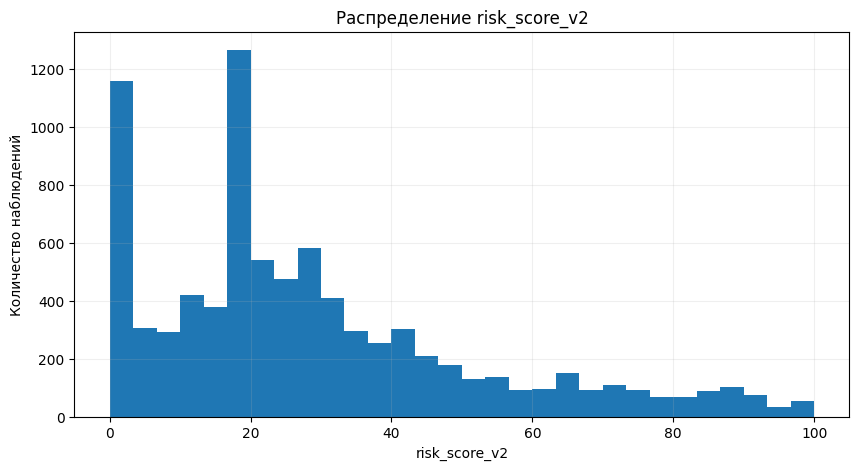

In [ ]:
# Ячейка 13 — гистограмма score
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_11_final_score.pkl')

plt.figure(figsize=(10, 5))
plt.hist(df["risk_score_v2"].dropna(), bins=30)
plt.xlabel("risk_score_v2")
plt.ylabel("Количество наблюдений")
plt.title("Распределение risk_score_v2")
plt.grid(alpha=0.2)
plt.show()

### 14. Проверка поведения во времени

Оставляем компании минимум с тремя годами истории и формируем таблицу для анализа временного поведения.


In [ ]:
# Ячейка 14 — проверка поведения во времени
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_11_final_score.pkl')

history = df.groupby("инн")["год"].nunique()
eligible_ids = history[history >= 3].index
df_hist = df[df["инн"].isin(eligible_ids)].copy()

annual = (
    df_hist.groupby("год")["risk_score_v2"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

df_hist.to_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_14_history.pkl')
annual.to_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_14_annual_summary.pkl')

print('Компаний с минимум 3 годами истории:', len(eligible_ids))
print(annual.tail(15))
print('Checkpoint сохранён:', checkpoint)

Компаний с минимум 3 годами истории: 790
     год       mean     median  count
5   2011  32.068250  28.333333    155
6   2012  29.964180  26.916667    175
7   2013  28.746085  22.666667    337
8   2014  28.752540  22.666667    401
9   2015  28.976260  23.250000    469
10  2016  28.879945  23.611111    499
11  2017  28.717481  23.159722    540
12  2018  29.323866  22.854167    600
13  2019  29.489244  23.847222    662
14  2020  28.350405  22.666667    707
15  2021  29.380106  21.625000    729
16  2022  28.248809  21.722222    750
17  2023  29.196273  22.444444    729
18  2024  27.937718  21.673611    700
19  2025  30.574229  25.000000    659
Checkpoint сохранён: /content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_checkpoints/traffic_light_v2_stage_11_final_score.pkl


### 15. Средний score по годам

Показываем изменение среднего risk_score_v2 по годам.


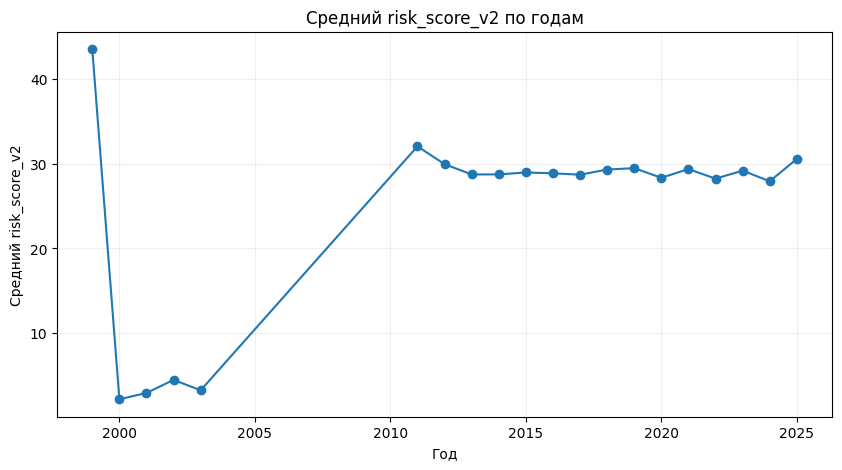

In [ ]:
# Ячейка 15 — средний score по годам
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

annual = pd.read_pickle(
    CHECKPOINT_DIR / 'traffic_light_v2_stage_14_annual_summary.pkl'
)

plt.figure(figsize=(10, 5))
plt.plot(annual["год"], annual["mean"], marker="o")
plt.xlabel("Год")
plt.ylabel("Средний risk_score_v2")
plt.title("Средний risk_score_v2 по годам")
plt.grid(alpha=0.2)
plt.show()

### 16. Разбор одной компании

Выбираем компанию с максимальным числом наблюдений и показываем её траекторию риска и основные показатели.


In [ ]:
# Ячейка 16 — разбор одной компании
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_11_final_score.pkl')

example_inn = (
    df.groupby("инн").size()
    .sort_values(ascending=False)
    .index[0]
)

example = df[df["инн"] == example_inn].copy()

cols = [
    "инн", "год", "risk_score_v2", "risk_level_v2",
    "current_norm", "dynamic_norm", "events_norm",
    "доля_обязательств_в_активах", "долговая_нагрузка_к_выручке",
    "текущая_ликвидность", "быстрая_ликвидность",
    "покрытие_процентов_прибылью", "рентабельность_по_чистой_прибыли",
    "капитал", "выручка", "чистая_прибыль"
]

display(example[cols])

,инн,год,risk_score_v2,risk_level_v2,current_norm,dynamic_norm,events_norm,доля_обязательств_в_активах,долговая_нагрузка_к_выручке,текущая_ликвидность,быстрая_ликвидность,покрытие_процентов_прибылью,рентабельность_по_чистой_прибыли,капитал,выручка,чистая_прибыль
47,101000776,1999,52.888889,ORANGE,0.661111,NaN,0.0,NaN,NaN,0.772213,0.185637,NaN,NaN,NaN,NaN,NaN
48,101000776,2000,0.000000,GREEN,0.000000,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
49,101000776,2001,0.000000,GREEN,0.000000,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3266.0
50,101000776,2002,0.000000,GREEN,0.000000,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16169.0
51,101000776,2003,0.000000,GREEN,0.000000,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6119.0
52,101000776,2011,17.000000,GREEN,0.212500,NaN,0.0,0.526853,0.189247,1.067007,0.692882,NaN,0.055163,183028.0,1076914.0,59406.0
53,101000776,2012,13.833333,GREEN,0.188889,0.1,0.0,0.505519,0.166600,1.053744,0.668496,NaN,0.029734,181022.0,1110822.0,33029.0
54,101000776,2013,28.833333,YELLOW,0.188889,0.7,0.0,0.545163,0.157833,1.053447,0.728907,NaN,0.018074,180844.0,1373336.0,24822.0
55,101000776,2014,9.916667,GREEN,0.165278,0.0,0.0,0.430845,0.121432,1.401561,0.949165,NaN,0.054706,251672.0,1568891.0,85828.0
56,101000776,2015,5.666667,GREEN,0.094444,0.0,0.0,0.328384,0.084018,2.340722,1.708795,9.508989,0.043419,269860.0,1570459.0,68188.0


### 17. Проверка переходов между цветами

Строим матрицу переходов между уровнями риска по последовательным годам компании.


In [ ]:
# Ячейка 17 — проверка переходов между цветами
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_11_final_score.pkl')

colors = ["GREEN", "YELLOW", "ORANGE", "RED"]

transitions = df.sort_values(["инн", "год"]).copy()
transitions["prev_level"] = transitions.groupby("инн")["risk_level_v2"].shift(1)

transition_table = (
    pd.crosstab(
        transitions["prev_level"],
        transitions["risk_level_v2"],
        normalize="index"
    )
    .reindex(index=colors, columns=colors)
    .fillna(0)
    .mul(100)
    .round(2)
)

display(transition_table)

transition_path = RESULTS_DIR / 'traffic_light_v2_transition_matrix.csv'
transition_table.to_csv(transition_path, encoding='utf-8-sig')
print('Матрица сохранена:', transition_path)

risk_level_v2,GREEN,YELLOW,ORANGE,RED
prev_level,,,,
GREEN,70.08,22.40,4.94,2.59
YELLOW,41.71,42.79,10.54,4.95
ORANGE,26.17,35.42,24.09,14.32
RED,17.58,22.15,31.51,28.77


Матрица сохранена: /content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_results/traffic_light_v2_transition_matrix.csv


### 18. Сохранение итогового результата

Сохраняем полный результат и компактную таблицу для дальнейшего анализа.
Это позволяет после потери соединения сразу продолжить работу с готовым результатом.


In [ ]:
# Ячейка 18 — сохранение итогового результата
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np

df = pd.read_pickle(CHECKPOINT_DIR / 'traffic_light_v2_stage_11_final_score.pkl')

full_result_path = RESULTS_DIR / 'traffic_light_v2_full_result.csv'
compact_result_path = RESULTS_DIR / 'traffic_light_v2_company_year_scores.csv'

df.to_csv(full_result_path, index=False, encoding='utf-8-sig')

compact_cols = [
    "инн", "год", "risk_score_v2", "risk_level_v2",
    "current_norm", "dynamic_norm", "events_norm",
    "current_debt", "current_liquidity",
    "current_ability_to_pay", "current_profitability",
    "negative_equity_signal"
]
df[compact_cols].to_csv(
    compact_result_path,
    index=False,
    encoding='utf-8-sig'
)

print('Полный результат:', full_result_path)
print('Компактный результат:', compact_result_path)

Полный результат: /content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_results/traffic_light_v2_full_result.csv
Компактный результат: /content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_results/traffic_light_v2_company_year_scores.csv


### 19. Контроль возможности продолжить после отключения среды

Эта ячейка показывает, какие этапы уже сохранены на Google Drive.
После разрыва соединения достаточно снова выполнить ячейки 1–2 и затем начать с нужного этапа: предыдущие результаты не потеряются.


In [ ]:
# Ячейка 19 — контроль возможности продолжить после отключения среды
# Путь к проекту задаётся здесь повторно, чтобы ячейка могла продолжить работу после перезапуска среды.
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PATH = RAW_DATA_DIR / '3.csv'
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_results'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

from pathlib import Path

checkpoint_files = sorted(CHECKPOINT_DIR.glob('traffic_light_v2_stage_*.pkl'))

print('Сохранённые этапы:')
for path in checkpoint_files:
    print('✓', path.name)

print('\nЕсли среда была перезапущена:')
print('1. Выполните ячейку 1 — подключение Google Drive.')
print('2. Выполните ячейку 2 — настройка путей.')
print('3. Запускайте нужный этап: каждая расчётная ячейка сама загружает свой предыдущий checkpoint.')
print('\nПересчитывать уже сохранённые этапы не требуется.')

Сохранённые этапы:
✓ traffic_light_v2_stage_03_loaded_data.pkl
✓ traffic_light_v2_stage_07_current_state.pkl
✓ traffic_light_v2_stage_08_dynamics.pkl
✓ traffic_light_v2_stage_09_dynamic_risk.pkl
✓ traffic_light_v2_stage_10_events.pkl
✓ traffic_light_v2_stage_11_final_score.pkl
✓ traffic_light_v2_stage_14_annual_summary.pkl
✓ traffic_light_v2_stage_14_history.pkl

Если среда была перезапущена:
1. Выполните ячейку 1 — подключение Google Drive.
2. Выполните ячейку 2 — настройка путей.
3. Запускайте нужный этап: каждая расчётная ячейка сама загружает свой предыдущий checkpoint.

Пересчитывать уже сохранённые этапы не требуется.


Загружены сохранённые результаты:
  Итоговый checkpoint: /content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_checkpoints/traffic_light_v2_stage_11_final_score.pkl
  История: /content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_checkpoints/traffic_light_v2_stage_14_history.pkl

Строк итогового результата: 8,440
Компаний: 800

Распределение по цветам:


,Количество,"Доля, %"
risk_level_v2,,
GREEN,4578,54.24
YELLOW,2480,29.38
ORANGE,858,10.17
RED,524,6.21


Статистика risk_score_v2:


,risk_score_v2
count,8440.00
mean,28.36
std,23.39
min,0.00
25%,12.75
50%,22.67
75%,39.22
90%,65.81
95%,79.80
max,100.00


Средний риск по годам:


,год,средний_risk_score,медианный_risk_score,компаний
0,1999,43.56,45.33,51
1,2000,2.16,0.00,59
2,2001,2.90,0.00,63
3,2002,4.44,0.00,72
4,2003,3.21,0.00,63
5,2011,32.07,28.33,155
6,2012,29.96,26.92,175
7,2013,28.75,22.67,337
8,2014,28.75,22.67,401
9,2015,28.98,23.25,469


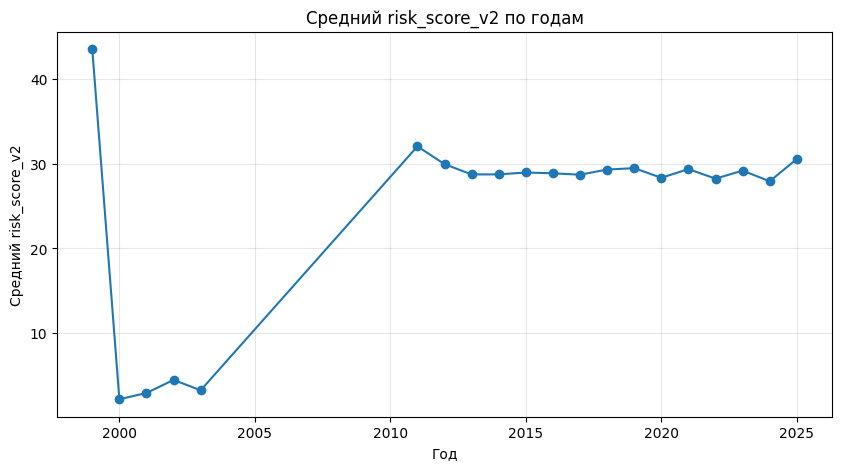

Переходы между уровнями риска:


risk_level_v2,GREEN,YELLOW,ORANGE,RED
previous_level,,,,
GREEN,2948,942,208,108
YELLOW,925,950,233,110
ORANGE,201,272,185,110
RED,77,97,138,126


Диапазон risk_score_v2:
  Минимум: 0.00
  Максимум: 100.00


In [ ]:
# Ячейка 15 — первичная проверка результатов V2

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'

FINAL_PATH = CHECKPOINT_DIR / 'traffic_light_v2_stage_11_final_score.pkl'
HISTORY_PATH = CHECKPOINT_DIR / 'traffic_light_v2_stage_14_history.pkl'

# Загружаем уже рассчитанные результаты
final_df = pd.read_pickle(FINAL_PATH)
history_df = pd.read_pickle(HISTORY_PATH)

print('Загружены сохранённые результаты:')
print(f'  Итоговый checkpoint: {FINAL_PATH}')
print(f'  История: {HISTORY_PATH}')
print()
print(f'Строк итогового результата: {len(final_df):,}')
print(f'Компаний: {final_df["инн"].nunique():,}')
print()

# ---------------------------------------------------------
# 1. Распределение по цветам
# ---------------------------------------------------------

print('Распределение по цветам:')

colors = ['GREEN', 'YELLOW', 'ORANGE', 'RED']

color_distribution = (
    final_df['risk_level_v2']
    .value_counts(dropna=False)
    .reindex(colors)
    .fillna(0)
    .astype(int)
    .to_frame('Количество')
)

color_distribution['Доля, %'] = (
    color_distribution['Количество']
    / len(final_df)
    * 100
).round(2)

display(color_distribution)

# ---------------------------------------------------------
# 2. Статистика итогового risk_score_v2
# ---------------------------------------------------------

print('Статистика risk_score_v2:')

display(
    final_df['risk_score_v2']
    .describe(percentiles=[.25, .5, .75, .90, .95])
    .round(2)
)

# ---------------------------------------------------------
# 3. Средний риск по годам
# ---------------------------------------------------------

annual = (
    history_df
    .groupby('год', as_index=False)
    .agg(
        средний_risk_score=('risk_score_v2', 'mean'),
        медианный_risk_score=('risk_score_v2', 'median'),
        компаний=('инн', 'nunique')
    )
    .sort_values('год')
)

print('Средний риск по годам:')
display(annual.round(2))

# ---------------------------------------------------------
# 4. График среднего risk_score_v2 по годам
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    annual['год'],
    annual['средний_risk_score'],
    marker='o'
)

plt.title('Средний risk_score_v2 по годам')
plt.xlabel('Год')
plt.ylabel('Средний risk_score_v2')
plt.grid(True, alpha=0.3)
plt.show()

# ---------------------------------------------------------
# 5. Переходы между цветами
# ---------------------------------------------------------

transition_history = (
    history_df
    .sort_values(['инн', 'год'])
    .copy()
)

transition_history['previous_level'] = (
    transition_history
    .groupby('инн')['risk_level_v2']
    .shift(1)
)

transition = (
    transition_history
    .dropna(subset=['previous_level'])
    .groupby(['previous_level', 'risk_level_v2'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=colors, columns=colors, fill_value=0)
)

print('Переходы между уровнями риска:')
display(transition)

# ---------------------------------------------------------
# 6. Проверка диапазона итогового score
# ---------------------------------------------------------

print('Диапазон risk_score_v2:')
print(f'  Минимум: {final_df["risk_score_v2"].min():.2f}')
print(f'  Максимум: {final_df["risk_score_v2"].max():.2f}')

### 20. Траектории конкретных компаний из красной зоны

Выбираем несколько компаний с максимальным `risk_score_v2` и показываем их полную финансовую траекторию по годам: итоговый балл, цвет, ключевые финансовые показатели и динамику.

Цель — найти конкретные повторяющиеся сценарии ухудшения, а не анализировать общую статистику.

In [ ]:
# Ячейка 20 — траектории конкретных компаний из красной зоны

import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'

FINAL_PATH = CHECKPOINT_DIR / 'traffic_light_v2_stage_11_final_score.pkl'
HISTORY_PATH = CHECKPOINT_DIR / 'traffic_light_v2_stage_14_history.pkl'

final_df = pd.read_pickle(FINAL_PATH)
history_df = pd.read_pickle(HISTORY_PATH)

# Выбираем 10 компаний с максимальным risk_score_v2
top_red = (
    final_df[
        final_df['risk_level_v2'] == 'RED'
    ]
    .sort_values('risk_score_v2', ascending=False)
    .drop_duplicates('инн')
    .head(10)
)

companies = top_red['инн'].tolist()

print('Компании для анализа:')
display(
    top_red[
        ['инн', 'год', 'risk_score_v2', 'risk_level_v2']
    ]
)

# Полная траектория каждой компании
trajectory_columns = [
    'инн',
    'год',
    'risk_score_v2',
    'risk_level_v2',
    'доля_обязательств_в_активах',
    'долговая_нагрузка_к_выручке',
    'текущая_ликвидность',
    'быстрая_ликвидность',
    'денежные_средства_к_краткосрочным_обязательствам',
    'покрытие_процентов_прибылью',
    'операционный_денежный_поток_к_обязательствам',
    'рентабельность_по_чистой_прибыли',
    'изменение_выручки',
    'изменение_прибыли',
    'изменение_операционного_денежного_потока',
    'изменение_доли_обязательств',
    'изменение_текущей_ликвидности',
    'капитал'
]

trajectory_columns = [
    c for c in trajectory_columns
    if c in history_df.columns
]

for inn in companies:

    company = (
        history_df[
            history_df['инн'] == inn
        ]
        .sort_values('год')
        [trajectory_columns]
        .copy()
    )

    print()
    print('=' * 100)
    print(f'ИНН: {inn}')
    print('=' * 100)

    display(company)

Компании для анализа:


,инн,год,risk_score_v2,risk_level_v2
8401,261022785,2022,100.0,RED
1816,105071619,2020,100.0,RED
7005,258007963,2024,100.0,RED
1487,105063706,2023,100.0,RED
6844,257009598,2022,100.0,RED
2076,105077297,2021,100.0,RED
6385,254013028,2024,100.0,RED
4331,239950675,2025,100.0,RED
2557,204995160,2022,100.0,RED
6072,245962735,2024,100.0,RED



ИНН: 261022785


,инн,год,risk_score_v2,risk_level_v2,доля_обязательств_в_активах,долговая_нагрузка_к_выручке,текущая_ликвидность,быстрая_ликвидность,денежные_средства_к_краткосрочным_обязательствам,покрытие_процентов_прибылью,операционный_денежный_поток_к_обязательствам,рентабельность_по_чистой_прибыли,изменение_выручки,изменение_прибыли,изменение_операционного_денежного_потока,изменение_доли_обязательств,изменение_текущей_ликвидности,капитал
8394,261022785,2015,0.000000,GREEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
8395,261022785,2016,26.444444,YELLOW,0.998981,0.643334,1.001020,0.866712,0.026692,NaN,NaN,0.000109,NaN,NaN,NaN,NaN,NaN,12.0
8396,261022785,2017,17.000000,GREEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002492,6194.0,59.0,NaN,NaN,NaN,73.0
8397,261022785,2018,17.000000,GREEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007859,-4757.0,94.0,NaN,NaN,NaN,228.0
8398,261022785,2019,24.500000,GREEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.014554,-13058.0,-58.0,NaN,NaN,NaN,325.0
8399,261022785,2020,17.000000,GREEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.009718,5992.0,26.0,NaN,NaN,NaN,3751.0
8400,261022785,2021,17.000000,GREEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006480,12959.0,43.0,NaN,NaN,NaN,3780.0
8401,261022785,2022,100.000000,RED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.778055,-24814.0,-3196.0,NaN,NaN,NaN,-4.0
8402,261022785,2023,30.222222,YELLOW,0.953255,8.267481,0.961321,0.689030,0.022891,NaN,NaN,0.300048,3374.0,4283.0,NaN,NaN,NaN,1693.0
8403,261022785,2024,38.333333,YELLOW,0.953577,17.894096,1.051781,0.733486,0.007005,NaN,0.000000,0.077320,-2042.0,-1088.0,NaN,0.000322,0.090460,1859.0



ИНН: 105071619


...

,инн,год,risk_score_v2,risk_level_v2,доля_обязательств_в_активах,долговая_нагрузка_к_выручке,текущая_ликвидность,быстрая_ликвидность,денежные_средства_к_краткосрочным_обязательствам,покрытие_процентов_прибылью,операционный_денежный_поток_к_обязательствам,рентабельность_по_чистой_прибыли,изменение_выручки,изменение_прибыли,изменение_операционного_денежного_потока,изменение_доли_обязательств,изменение_текущей_ликвидности,капитал
4324,239950675,2018,0.000000,GREEN,0.089372,0.027963,9.612613,NaN,3.486486,NaN,2.819820,0.283663,NaN,NaN,NaN,NaN,NaN,2262.0
4325,239950675,2019,22.750000,GREEN,0.167502,0.033626,2.889764,0.128084,0.000000,NaN,0.000000,0.127198,48713.0,4954.0,-626.0,0.078130,-6.722849,9468.0
4326,239950675,2020,15.666667,GREEN,0.389940,0.293061,1.465784,1.232336,0.015650,NaN,0.431429,0.201552,-19803.0,221.0,4659.0,0.222438,-1.423980,16895.0
4327,239950675,2021,19.833333,GREEN,0.295250,0.126605,2.867348,2.867348,0.084374,NaN,-0.107108,0.039553,67720.0,-3291.0,-6077.0,-0.094690,1.401565,31600.0
4328,239950675,2022,34.500000,YELLOW,0.441840,0.405590,2.298421,2.210404,0.002039,NaN,-0.181265,0.112159,-25610.0,4720.0,-4387.0,0.146590,-0.568927,40456.0
4329,239950675,2023,8.166667,GREEN,0.458665,0.392724,2.695182,2.358637,0.001116,NaN,NaN,0.163458,55871.0,13183.0,NaN,0.016825,0.396761,62495.0
4330,239950675,2024,27.000000,YELLOW,0.687731,0.622043,3.976729,2.772584,0.000051,NaN,NaN,0.011625,41772.0,-19986.0,NaN,0.229066,1.281547,49880.0
4331,239950675,2025,100.000000,RED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.973876,-109766.0,-67143.0,NaN,NaN,NaN,-42745.0



ИНН: 204995160


,инн,год,risk_score_v2,risk_level_v2,доля_обязательств_в_активах,долговая_нагрузка_к_выручке,текущая_ликвидность,быстрая_ликвидность,денежные_средства_к_краткосрочным_обязательствам,покрытие_процентов_прибылью,операционный_денежный_поток_к_обязательствам,рентабельность_по_чистой_прибыли,изменение_выручки,изменение_прибыли,изменение_операционного_денежного_потока,изменение_доли_обязательств,изменение_текущей_ликвидности,капитал
2554,204995160,2019,0.000000,GREEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.173762,NaN,NaN,NaN,NaN,NaN,361.0
2555,204995160,2020,17.000000,GREEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.019587,21414.0,108.0,NaN,NaN,NaN,830.0
2556,204995160,2021,89.583333,RED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.503240,-22045.0,-3936.0,NaN,NaN,NaN,-4991.0
2557,204995160,2022,100.000000,RED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1389.0,-3196.0,NaN,NaN,NaN,-11907.0
2558,204995160,2023,66.000000,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6673.0,NaN,NaN,NaN,-11907.0
2559,204995160,2024,66.000000,ORANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-11907.0
2560,204995160,2025,91.000000,RED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-16486.0



ИНН: 245962735


,инн,год,risk_score_v2,risk_level_v2,доля_обязательств_в_активах,долговая_нагрузка_к_выручке,текущая_ликвидность,быстрая_ликвидность,денежные_средства_к_краткосрочным_обязательствам,покрытие_процентов_прибылью,операционный_денежный_поток_к_обязательствам,рентабельность_по_чистой_прибыли,изменение_выручки,изменение_прибыли,изменение_операционного_денежного_потока,изменение_доли_обязательств,изменение_текущей_ликвидности,капитал
6068,245962735,2020,0.000000,GREEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.110386,NaN,NaN,NaN,NaN,NaN,237.0
6069,245962735,2021,64.208333,ORANGE,1.332075,1.205366,0.782370,0.137495,0.053564,NaN,0.023068,-0.380000,365.0,-965.0,NaN,NaN,NaN,-616.0
6070,245962735,2022,41.791667,YELLOW,1.001849,0.364775,0.958596,0.685852,0.002785,NaN,-0.020487,0.014206,12803.0,990.0,-168.0,-0.330226,0.176226,-10.0
6071,245962735,2023,24.083333,GREEN,0.896074,0.513182,1.025663,0.863073,0.021357,NaN,0.018729,0.026100,-3512.0,85.0,220.0,-0.105775,0.067067,675.0
6072,245962735,2024,100.000000,RED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-11341.0,-1364.0,NaN,NaN,NaN,-619.0


### 21. Разложение риска по компонентам для конкретных компаний

Разбираем четыре характерные траектории:

- `257009598` — постепенная деградация;
- `254013028` — резкий обвал;
- `105071619` — кризис с частичным восстановлением;
- `258007963` — кратковременный всплеск риска.

Для каждого года показываем, из каких компонентов складывается итоговый `risk_score_v2`: текущее состояние, динамика, события и специальные условия.

Цель — понять, какие именно сигналы переводят компанию из одного уровня риска в другой и где возникает максимальный вклад отдельных правил.

In [ ]:
# Ячейка 21 — разложение risk_score_v2 по компонентам

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path('/content/drive/MyDrive/komus-credit-risk')
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments' / 'traffic_light_v2_checkpoints'

FINAL_PATH = CHECKPOINT_DIR / 'traffic_light_v2_stage_11_final_score.pkl'
HISTORY_PATH = CHECKPOINT_DIR / 'traffic_light_v2_stage_14_history.pkl'

final_df = pd.read_pickle(FINAL_PATH)
history_df = pd.read_pickle(HISTORY_PATH)

# Четыре компании, которые разбираем вручную
TARGET_COMPANIES = [
    '257009598',  # постепенная деградация
    '254013028',  # резкий обвал
    '105071619',  # кризис и восстановление
    '258007963',  # кратковременный всплеск
]

# ---------------------------------------------------------
# 1. Сначала посмотрим, какие компоненты реально сохранены
# ---------------------------------------------------------

print('Колонки итогового checkpoint:')
print(list(final_df.columns))

print('\nКолонки истории:')
print(list(history_df.columns))


# ---------------------------------------------------------
# 2. Ищем колонки, связанные с компонентами расчёта
# ---------------------------------------------------------

component_keywords = [
    'current',
    'dynamic',
    'event',
    'special',
    'negative',
    'group',
    'risk',
    'score'
]

component_columns = []

for column in history_df.columns:
    column_lower = str(column).lower()

    if any(keyword in column_lower for keyword in component_keywords):
        component_columns.append(column)

print('\nНайденные потенциальные компонентные колонки:')
for column in component_columns:
    print(' -', column)


# ---------------------------------------------------------
# 3. Показываем четыре траектории
# ---------------------------------------------------------

for inn in TARGET_COMPANIES:

    company = (
        history_df[
            history_df['инн'].astype(str) == str(inn)
        ]
        .sort_values('год')
        .copy()
    )

    print()
    print('=' * 120)
    print(f'ИНН: {inn}')
    print('=' * 120)

    if company.empty:
        print('Компания не найдена в history checkpoint.')
        continue

    # Основные поля
    base_columns = [
        'инн',
        'год',
        'risk_score_v2',
        'risk_level_v2'
    ]

    # Добавляем все реально существующие компонентные поля
    selected_columns = base_columns + [
        c for c in component_columns
        if c not in base_columns
    ]

    selected_columns = [
        c for c in selected_columns
        if c in company.columns
    ]

    display(company[selected_columns])


# ---------------------------------------------------------
# 4. Отдельно проверяем, есть ли сохранённые детали групп
# ---------------------------------------------------------

print()
print('=' * 120)
print('Проверка структуры сохранённых результатов')
print('=' * 120)

for column in history_df.columns:

    sample = history_df[column].dropna()

    if len(sample) == 0:
        continue

    value = sample.iloc[0]

    # Словари могут содержать детализацию групп
    if isinstance(value, dict):
        print(f'\nКолонка "{column}" содержит словари.')
        print('Пример структуры:')
        print(value)

Колонки итогового checkpoint:
['инн', 'год', 'активы', 'оборотные_активы', 'запасы', 'денежные_средства', 'капитал', 'долгосрочные_обязательства', 'краткосрочные_обязательства', 'выручка', 'прибыль_до_налогообложения', 'проценты_к_получению', 'проценты_к_уплате', 'чистая_прибыль', 'операционный_денежный_поток', 'погашение_кредитов_и_займов', 'стандарт', 'прибыль_до_процентов_и_налогов', 'обязательства', 'доля_обязательств_в_активах', 'обязательства_к_капиталу', 'долговая_нагрузка_к_выручке', 'текущая_ликвидность', 'быстрая_ликвидность', 'денежные_средства_к_краткосрочным_обязательствам', 'оборотный_капитал_к_активам', 'покрытие_процентов_прибылью', 'операционный_денежный_поток_к_краткосрочным_обязательствам', 'операционный_денежный_поток_к_обязательствам', 'рентабельность_по_чистой_прибыли', 'доля_денежных_средств_в_активах', 'изменение_выручки', 'изменение_прибыли', 'изменение_операционного_денежного_потока', 'изменение_доли_обязательств', 'изменение_текущей_ликвидности', 'контроль_ба

,инн,год,risk_score_v2,risk_level_v2,current_norm,current_debt,current_liquidity,current_ability_to_pay,current_profitability,negative_equity_signal,dynamic_norm,events_norm
6836,257009598,2013,35.259259,YELLOW,0.440741,0.666667,0.555556,NaN,0.333333,0.0,NaN,0.0
6837,257009598,2014,25.500000,YELLOW,0.425000,0.500000,0.666667,NaN,0.333333,0.0,0.000000,0.0
6838,257009598,2015,23.041667,GREEN,0.342361,0.500000,0.444444,0.333333,0.333333,0.0,0.100000,0.0
6839,257009598,2016,39.277778,YELLOW,0.487963,0.833333,0.555556,NaN,0.333333,0.0,0.400000,0.0
6840,257009598,2017,20.541667,GREEN,0.342361,0.833333,0.444444,0.000000,0.333333,0.0,0.000000,0.0
6841,257009598,2019,22.666667,GREEN,0.377778,0.666667,0.777778,0.000000,0.333333,0.0,0.000000,0.0
6842,257009598,2020,72.000000,ORANGE,0.669444,1.000000,0.777778,0.000000,0.666667,1.0,0.733333,0.9
6843,257009598,2021,62.000000,ORANGE,0.669444,1.000000,0.777778,0.333333,0.333333,1.0,0.633333,0.4
6844,257009598,2022,100.000000,RED,1.000000,NaN,NaN,NaN,1.000000,1.0,1.000000,1.0
6845,257009598,2023,75.583333,RED,1.000000,1.000000,1.000000,NaN,NaN,1.0,0.083333,0.9



ИНН: 254013028


,инн,год,risk_score_v2,risk_level_v2,current_norm,current_debt,current_liquidity,current_ability_to_pay,current_profitability,negative_equity_signal,dynamic_norm,events_norm
6377,254013028,2016,0.000000,GREEN,0.000000,NaN,NaN,NaN,NaN,0.0,NaN,0.0
6378,254013028,2017,0.000000,GREEN,0.000000,NaN,NaN,NaN,0.000000,0.0,0.000000,0.0
6379,254013028,2018,73.083333,ORANGE,0.850000,NaN,NaN,NaN,1.000000,0.0,0.583333,0.5
6380,254013028,2019,12.277778,GREEN,0.204630,0.5,0.222222,NaN,0.000000,0.0,0.000000,0.0
6381,254013028,2020,5.666667,GREEN,0.094444,0.0,0.333333,NaN,0.000000,0.0,0.000000,0.0
6382,254013028,2021,15.722222,GREEN,0.220370,0.0,0.444444,NaN,0.333333,0.0,0.100000,0.0
6383,254013028,2022,17.000000,GREEN,0.283333,NaN,NaN,NaN,0.333333,0.0,0.000000,0.0
6384,254013028,2023,98.500000,RED,1.000000,NaN,NaN,NaN,1.000000,1.0,1.000000,0.9
6385,254013028,2024,100.000000,RED,1.000000,NaN,NaN,NaN,1.000000,1.0,1.000000,1.0
6386,254013028,2025,78.708333,RED,1.000000,NaN,NaN,NaN,NaN,1.0,0.208333,0.9



ИНН: 105071619


,инн,год,risk_score_v2,risk_level_v2,current_norm,current_debt,current_liquidity,current_ability_to_pay,current_profitability,negative_equity_signal,dynamic_norm,events_norm
1810,105071619,2014,0.000000,GREEN,0.000000,NaN,NaN,NaN,NaN,0.0,NaN,0.00
1811,105071619,2015,0.000000,GREEN,0.000000,NaN,NaN,NaN,NaN,0.0,0.000000,0.00
1812,105071619,2016,0.000000,GREEN,0.000000,NaN,NaN,NaN,NaN,0.0,0.000000,0.00
1813,105071619,2017,26.208333,YELLOW,0.436806,0.5,0.222222,1.000000,0.333333,0.0,0.000000,0.00
1814,105071619,2018,24.458333,GREEN,0.365972,0.5,0.222222,0.666667,0.333333,0.0,0.100000,0.00
1815,105071619,2019,24.791667,GREEN,0.413194,0.5,0.111111,1.000000,0.333333,0.0,0.000000,0.00
1816,105071619,2020,100.000000,RED,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.00
1817,105071619,2021,82.166667,RED,0.952778,1.0,0.777778,1.000000,1.000000,1.0,0.400000,1.00
1818,105071619,2022,70.333333,ORANGE,0.905556,1.0,0.666667,NaN,1.000000,1.0,0.100000,0.90
1819,105071619,2023,75.805556,RED,0.937037,1.0,0.777778,NaN,1.000000,1.0,0.633333,0.25



ИНН: 258007963


,инн,год,risk_score_v2,risk_level_v2,current_norm,current_debt,current_liquidity,current_ability_to_pay,current_profitability,negative_equity_signal,dynamic_norm,events_norm
6995,258007963,2000,0.000000,GREEN,0.000000,NaN,NaN,NaN,NaN,0.0,NaN,0.00
6996,258007963,2001,32.500000,YELLOW,0.000000,NaN,NaN,NaN,NaN,0.0,1.0,0.50
6997,258007963,2016,21.722222,GREEN,0.362037,0.5,0.444444,NaN,0.333333,0.0,0.0,0.00
6998,258007963,2017,33.611111,YELLOW,0.393519,0.5,0.555556,NaN,0.333333,0.0,0.1,0.50
6999,258007963,2018,29.500000,YELLOW,0.283333,NaN,NaN,NaN,0.333333,0.0,0.5,0.00
7000,258007963,2019,32.000000,YELLOW,0.433333,NaN,NaN,NaN,0.333333,1.0,0.0,0.40
7001,258007963,2020,32.000000,YELLOW,0.433333,NaN,NaN,NaN,0.333333,1.0,0.0,0.40
7002,258007963,2021,52.000000,ORANGE,0.433333,NaN,NaN,NaN,0.333333,1.0,0.5,0.90
7003,258007963,2022,39.500000,YELLOW,0.433333,NaN,NaN,NaN,0.333333,1.0,0.0,0.90
7004,258007963,2023,32.000000,YELLOW,0.433333,NaN,NaN,NaN,0.333333,1.0,0.0,0.40



Проверка структуры сохранённых результатов


### 22. Вклад компонентов в итоговый балл риска

Для выбранных компаний разложим `risk_score_v2` на фактический вклад основных частей модели:

- текущее финансовое состояние — 60%;
- динамика — 25%;
- события — 15%.

Внутри текущего состояния отдельно покажем:
- долговую нагрузку;
- ликвидность;
- способность обслуживать обязательства;
- прибыльность;
- специальный сигнал отрицательного капитала.

Цель — понять, за счёт каких именно компонентов формируется высокий балл и где возникает потенциальное двойное учёта одного и того же ухудшения.

In [ ]:
# Ячейка 22 — фактический вклад компонентов в risk_score_v2

import pandas as pd
import numpy as np

# Загружаем историю с уже рассчитанными компонентами
df = pd.read_pickle(HISTORY_PATH).copy()

TARGET_COMPANIES = [
    '257009598',
    '254013028',
    '105071619',
    '258007963'
]

# ---------------------------------------------------------
# 1. Пересчитываем вклад каждого компонента
# ---------------------------------------------------------

# Текущая часть модели = 60%
df['contribution_current'] = df['current_norm'] * 60

# Внутри current_norm:
df['contribution_debt'] = df['current_debt'] * 60
df['contribution_liquidity'] = df['current_liquidity'] * 60
df['contribution_ability_to_pay'] = df['current_ability_to_pay'] * 60
df['contribution_profitability'] = df['current_profitability'] * 60

# Специальный сигнал отрицательного капитала
df['contribution_negative_equity'] = df['negative_equity_signal'] * 60

# Динамика = 25%
df['contribution_dynamic'] = df['dynamic_norm'] * 25

# События = 15%
df['contribution_events'] = df['events_norm'] * 15


# ---------------------------------------------------------
# 2. Выбираем четыре конкретные компании
# ---------------------------------------------------------

result = df[
    df['инн'].astype(str).isin(TARGET_COMPANIES)
].copy()

result = result.sort_values(['инн', 'год'])


# ---------------------------------------------------------
# 3. Таблица с фактическими вкладами
# ---------------------------------------------------------

columns = [
    'инн',
    'год',
    'risk_score_v2',
    'risk_level_v2',

    'current_norm',
    'contribution_current',

    'current_debt',
    'contribution_debt',

    'current_liquidity',
    'contribution_liquidity',

    'current_ability_to_pay',
    'contribution_ability_to_pay',

    'current_profitability',
    'contribution_profitability',

    'negative_equity_signal',
    'contribution_negative_equity',

    'dynamic_norm',
    'contribution_dynamic',

    'events_norm',
    'contribution_events'
]

columns = [c for c in columns if c in result.columns]

display(
    result[columns]
    .round(2)
)


# ---------------------------------------------------------
# 4. Разбираем только годы с высоким риском
# ---------------------------------------------------------

high_risk = result[
    result['risk_score_v2'] >= 50
].copy()

print()
print('=' * 120)
print('ТОЛЬКО ГОДЫ С RISK_SCORE_V2 >= 50')
print('=' * 120)

display(
    high_risk[columns]
    .round(2)
)


# ---------------------------------------------------------
# 5. Для каждого года показываем основные источники риска
# ---------------------------------------------------------

print()
print('=' * 120)
print('КРАТКОЕ РАЗЛОЖЕНИЕ ВКЛАДА')
print('=' * 120)

summary = result[
    [
        'инн',
        'год',
        'risk_score_v2',
        'risk_level_v2',
        'contribution_current',
        'contribution_dynamic',
        'contribution_events',
        'contribution_negative_equity'
    ]
].copy()

summary['top_source'] = summary[
    [
        'contribution_current',
        'contribution_dynamic',
        'contribution_events',
        'contribution_negative_equity'
    ]
].idxmax(axis=1)

summary['top_source'] = summary['top_source'].replace({
    'contribution_current': 'Текущее состояние',
    'contribution_dynamic': 'Динамика',
    'contribution_events': 'События',
    'contribution_negative_equity': 'Отрицательный капитал'
})

display(summary.round(2))

,инн,год,risk_score_v2,risk_level_v2,current_norm,contribution_current,current_debt,contribution_debt,current_liquidity,contribution_liquidity,current_ability_to_pay,contribution_ability_to_pay,current_profitability,contribution_profitability,negative_equity_signal,contribution_negative_equity,dynamic_norm,contribution_dynamic,events_norm,contribution_events
1810,105071619,2014,0.00,GREEN,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.00,0.00
1811,105071619,2015,0.00,GREEN,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.00,0.00,0.00,0.00
1812,105071619,2016,0.00,GREEN,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.00,0.00,0.00,0.00
1813,105071619,2017,26.21,YELLOW,0.44,26.21,0.50,30.0,0.22,13.33,1.00,60.0,0.33,20.0,0.0,0.0,0.00,0.00,0.00,0.00
1814,105071619,2018,24.46,GREEN,0.37,21.96,0.50,30.0,0.22,13.33,0.67,40.0,0.33,20.0,0.0,0.0,0.10,2.50,0.00,0.00
1815,105071619,2019,24.79,GREEN,0.41,24.79,0.50,30.0,0.11,6.67,1.00,60.0,0.33,20.0,0.0,0.0,0.00,0.00,0.00,0.00
1816,105071619,2020,100.00,RED,1.00,60.00,1.00,60.0,1.00,60.00,1.00,60.0,1.00,60.0,1.0,60.0,1.00,25.00,1.00,15.00
1817,105071619,2021,82.17,RED,0.95,57.17,1.00,60.0,0.78,46.67,1.00,60.0,1.00,60.0,1.0,60.0,0.40,10.00,1.00,15.00
1818,105071619,2022,70.33,ORANGE,0.91,54.33,1.00,60.0,0.67,40.00,NaN,NaN,1.00,60.0,1.0,60.0,0.10,2.50,0.90,13.50
1819,105071619,2023,75.81,RED,0.94,56.22,1.00,60.0,0.78,46.67,NaN,NaN,1.00,60.0,1.0,60.0,0.63,15.83,0.25,3.75



ТОЛЬКО ГОДЫ С RISK_SCORE_V2 >= 50


,инн,год,risk_score_v2,risk_level_v2,current_norm,contribution_current,current_debt,contribution_debt,current_liquidity,contribution_liquidity,current_ability_to_pay,contribution_ability_to_pay,current_profitability,contribution_profitability,negative_equity_signal,contribution_negative_equity,dynamic_norm,contribution_dynamic,events_norm,contribution_events
1816,105071619,2020,100.00,RED,1.00,60.00,1.0,60.0,1.00,60.00,1.00,60.0,1.00,60.0,1.0,60.0,1.00,25.00,1.00,15.00
1817,105071619,2021,82.17,RED,0.95,57.17,1.0,60.0,0.78,46.67,1.00,60.0,1.00,60.0,1.0,60.0,0.40,10.00,1.00,15.00
1818,105071619,2022,70.33,ORANGE,0.91,54.33,1.0,60.0,0.67,40.00,NaN,NaN,1.00,60.0,1.0,60.0,0.10,2.50,0.90,13.50
1819,105071619,2023,75.81,RED,0.94,56.22,1.0,60.0,0.78,46.67,NaN,NaN,1.00,60.0,1.0,60.0,0.63,15.83,0.25,3.75
1820,105071619,2024,70.33,ORANGE,0.91,54.33,1.0,60.0,0.67,40.00,NaN,NaN,1.00,60.0,1.0,60.0,0.10,2.50,0.90,13.50
1821,105071619,2025,67.19,ORANGE,0.87,52.44,1.0,60.0,0.56,33.33,NaN,NaN,1.00,60.0,1.0,60.0,0.35,8.75,0.40,6.00
6379,254013028,2018,73.08,ORANGE,0.85,51.00,NaN,NaN,NaN,NaN,NaN,NaN,1.00,60.0,0.0,0.0,0.58,14.58,0.50,7.50
6384,254013028,2023,98.50,RED,1.00,60.00,NaN,NaN,NaN,NaN,NaN,NaN,1.00,60.0,1.0,60.0,1.00,25.00,0.90,13.50
6385,254013028,2024,100.00,RED,1.00,60.00,NaN,NaN,NaN,NaN,NaN,NaN,1.00,60.0,1.0,60.0,1.00,25.00,1.00,15.00
6386,254013028,2025,78.71,RED,1.00,60.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,60.0,0.21,5.21,0.90,13.50



КРАТКОЕ РАЗЛОЖЕНИЕ ВКЛАДА


,инн,год,risk_score_v2,risk_level_v2,contribution_current,contribution_dynamic,contribution_events,contribution_negative_equity,top_source
1810,105071619,2014,0.00,GREEN,0.00,NaN,0.00,0.0,Текущее состояние
1811,105071619,2015,0.00,GREEN,0.00,0.00,0.00,0.0,Текущее состояние
1812,105071619,2016,0.00,GREEN,0.00,0.00,0.00,0.0,Текущее состояние
1813,105071619,2017,26.21,YELLOW,26.21,0.00,0.00,0.0,Текущее состояние
1814,105071619,2018,24.46,GREEN,21.96,2.50,0.00,0.0,Текущее состояние
1815,105071619,2019,24.79,GREEN,24.79,0.00,0.00,0.0,Текущее состояние
1816,105071619,2020,100.00,RED,60.00,25.00,15.00,60.0,Текущее состояние
1817,105071619,2021,82.17,RED,57.17,10.00,15.00,60.0,Отрицательный капитал
1818,105071619,2022,70.33,ORANGE,54.33,2.50,13.50,60.0,Отрицательный капитал
1819,105071619,2023,75.81,RED,56.22,15.83,3.75,60.0,Отрицательный капитал


### 23. Проверка влияния отрицательного капитала на всей выборке

Проверяем, насколько часто `negative_equity_signal` влияет на итоговую оценку и какой цвет риска получается у компаний с отрицательным капиталом.

Цель — определить, не даёт ли специальный сигнал отрицательного капитала чрезмерный вклад в итоговый риск.

На этом шаге формулу V2 не изменяем.

In [ ]:
# Ячейка 23 — влияние отрицательного капитала на всей выборке

import pandas as pd
import numpy as np

# Используем уже рассчитанную историю
df = pd.read_pickle(HISTORY_PATH).copy()

# ---------------------------------------------------------
# 1. Проверяем наличие необходимых колонок
# ---------------------------------------------------------

required_columns = [
    'инн',
    'год',
    'капитал',
    'negative_equity_signal',
    'risk_score_v2',
    'risk_level_v2'
]

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

if missing_columns:
    raise ValueError(
        f'В checkpoint отсутствуют необходимые колонки: {missing_columns}'
    )

# ---------------------------------------------------------
# 2. Формируем признак отрицательного капитала напрямую
# ---------------------------------------------------------

df['has_negative_equity'] = (
    pd.to_numeric(df['капитал'], errors='coerce') < 0
)

# Проверяем совпадение с рассчитанным специальным сигналом
signal_mismatch = (
    df['has_negative_equity'].astype(float)
    != pd.to_numeric(
        df['negative_equity_signal'],
        errors='coerce'
    ).fillna(0)
)

print('Количество строк:', len(df))
print(
    'Несовпадений между капиталом < 0 и negative_equity_signal:',
    int(signal_mismatch.sum())
)

# ---------------------------------------------------------
# 3. Доля отрицательного капитала
# ---------------------------------------------------------

negative_df = df[df['has_negative_equity']].copy()
positive_df = df[~df['has_negative_equity']].copy()

print()
print('=' * 100)
print('ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ')
print('=' * 100)

print(
    f'Строк с отрицательным капиталом: '
    f'{len(negative_df):,} '
    f'({len(negative_df) / len(df) * 100:.2f}%)'
)

print(
    f'Строк без отрицательного капитала: '
    f'{len(positive_df):,} '
    f'({len(positive_df) / len(df) * 100:.2f}%)'
)

# ---------------------------------------------------------
# 4. Распределение цветов среди компаний с отрицательным капиталом
# ---------------------------------------------------------

color_order = ['GREEN', 'YELLOW', 'ORANGE', 'RED']

negative_color_counts = (
    negative_df['risk_level_v2']
    .value_counts()
    .reindex(color_order, fill_value=0)
)

negative_color_share = (
    negative_color_counts
    / len(negative_df)
    * 100
)

negative_color_table = pd.DataFrame({
    'Количество': negative_color_counts.astype(int),
    'Доля_%': negative_color_share.round(2)
})

print()
print('Цвет риска при отрицательном капитале:')
display(negative_color_table)

# ---------------------------------------------------------
# 5. Сравнение с компаниями без отрицательного капитала
# ---------------------------------------------------------

comparison = pd.DataFrame({
    'С_отрицательным_капиталом': {
        'Количество': len(negative_df),
        'Средний_score': negative_df['risk_score_v2'].mean(),
        'Медиана_score': negative_df['risk_score_v2'].median(),
        'ORANGE_RED_%': (
            negative_df['risk_level_v2']
            .isin(['ORANGE', 'RED'])
            .mean() * 100
        )
    },
    'Без_отрицательного_капитала': {
        'Количество': len(positive_df),
        'Средний_score': positive_df['risk_score_v2'].mean(),
        'Медиана_score': positive_df['risk_score_v2'].median(),
        'ORANGE_RED_%': (
            positive_df['risk_level_v2']
            .isin(['ORANGE', 'RED'])
            .mean() * 100
        )
    }
}).round(2)

print()
print('=' * 100)
print('СРАВНЕНИЕ')
print('=' * 100)

display(comparison)

# ---------------------------------------------------------
# 6. Проверяем, насколько часто отрицательный капитал
#    встречается вместе с высоким текущим риском
# ---------------------------------------------------------

negative_summary = (
    negative_df
    .assign(
        high_current=lambda x: x['current_norm'] >= 0.75,
        high_dynamic=lambda x: x['dynamic_norm'] >= 0.75,
        high_events=lambda x: x['events_norm'] >= 0.75
    )
    .agg({
        'high_current': 'mean',
        'high_dynamic': 'mean',
        'high_events': 'mean'
    })
    * 100
)

print()
print('Среди строк с отрицательным капиталом:')
display(
    negative_summary
    .rename({
        'high_current': 'current_norm >= 0.75',
        'high_dynamic': 'dynamic_norm >= 0.75',
        'high_events': 'events_norm >= 0.75'
    })
    .round(2)
    .to_frame('Доля_%')
)

# ---------------------------------------------------------
# 7. Компании, где отрицательный капитал сохраняется
#    несколько лет подряд
# ---------------------------------------------------------

negative_history = (
    df[df['has_negative_equity']]
    .groupby('инн')
    .agg(
        first_negative_year=('год', 'min'),
        last_negative_year=('год', 'max'),
        negative_years=('год', 'count'),
        max_score=('risk_score_v2', 'max')
    )
    .reset_index()
)

negative_history['negative_duration'] = (
    negative_history['last_negative_year']
    - negative_history['first_negative_year']
    + 1
)

print()
print('=' * 100)
print('ПРОДОЛЖИТЕЛЬНЫЙ ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ')
print('=' * 100)

display(
    negative_history
    .sort_values(
        ['negative_duration', 'negative_years'],
        ascending=False
    )
    .head(20)
)

Количество строк: 8420
Несовпадений между капиталом < 0 и negative_equity_signal: 0

ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ
Строк с отрицательным капиталом: 1,179 (14.00%)
Строк без отрицательного капитала: 7,241 (86.00%)

Цвет риска при отрицательном капитале:


,Количество,Доля_%
risk_level_v2,,
GREEN,18,1.53
YELLOW,283,24.00
ORANGE,424,35.96
RED,454,38.51



СРАВНЕНИЕ


,С_отрицательным_капиталом,Без_отрицательного_капитала
Количество,1179.00,7241.00
Средний_score,66.33,22.17
Медиана_score,68.25,18.42
ORANGE_RED_%,74.47,6.93



Среди строк с отрицательным капиталом:


,Доля_%
current_norm >= 0.75,54.96
dynamic_norm >= 0.75,16.62
events_norm >= 0.75,43.17



ПРОДОЛЖИТЕЛЬНЫЙ ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ


,инн,first_negative_year,last_negative_year,negative_years,max_score,negative_duration
197,245957140,2011,2025,15,88.875000,15
261,258011906,2011,2025,15,84.277778,15
44,105063745,2011,2025,11,74.541667,15
143,239005417,2011,2025,10,98.500000,15
151,242009683,2012,2025,14,87.166667,14
37,105054772,2011,2024,12,92.833333,14
32,105050070,2013,2025,13,75.666667,13
49,105069810,2013,2025,13,87.875000,13
166,245013286,2011,2023,13,94.250000,13
240,256021810,2013,2025,13,91.000000,13


### 24. Проверка устойчивости риск-сценариев

Для каждой компании определяем последовательность уровней риска по годам и ищем повторяющиеся сценарии:

- постепенное ухудшение;
- резкий переход в высокий риск;
- восстановление после кризиса;
- устойчивое нахождение в ORANGE/RED;
- кратковременный всплеск.

Цель — проверить, действительно ли V2 описывает разные типы финансовых траекторий, а не только отдельные экстремальные годы.

На этом шаге формулу V2 также не изменяем.

In [ ]:
# Ячейка 24 — устойчивость риск-сценариев по компаниям

import pandas as pd
import numpy as np

df = pd.read_pickle(HISTORY_PATH).copy()

required_columns = [
    'инн',
    'год',
    'risk_score_v2',
    'risk_level_v2'
]

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

if missing_columns:
    raise ValueError(
        f'В checkpoint отсутствуют необходимые колонки: {missing_columns}'
    )

# ---------------------------------------------------------
# 1. Порядок цветов как порядковая шкала риска
# ---------------------------------------------------------

level_to_num = {
    'GREEN': 0,
    'YELLOW': 1,
    'ORANGE': 2,
    'RED': 3
}

num_to_level = {
    0: 'GREEN',
    1: 'YELLOW',
    2: 'ORANGE',
    3: 'RED'
}

df['risk_level_num'] = (
    df['risk_level_v2']
    .map(level_to_num)
)

df = df.sort_values(['инн', 'год']).copy()

# ---------------------------------------------------------
# 2. Строим последовательность цветов каждой компании
# ---------------------------------------------------------

trajectories = (
    df.groupby('инн')
    .agg(
        first_year=('год', 'min'),
        last_year=('год', 'max'),
        years=('год', 'count'),
        max_score=('risk_score_v2', 'max'),
        mean_score=('risk_score_v2', 'mean'),
        red_years=(
            'risk_level_v2',
            lambda x: (x == 'RED').sum()
        ),
        orange_red_years=(
            'risk_level_v2',
            lambda x: x.isin(['ORANGE', 'RED']).sum()
        )
    )
    .reset_index()
)

trajectories['orange_red_share'] = (
    trajectories['orange_red_years']
    / trajectories['years']
)

# ---------------------------------------------------------
# 3. Определяем наличие последовательных ухудшений
# ---------------------------------------------------------

def analyze_trajectory(group):
    group = group.sort_values('год')

    levels = group['risk_level_num'].dropna().astype(int).tolist()

    if len(levels) < 2:
        return pd.Series({
            'max_upward_jump': np.nan,
            'max_downward_jump': np.nan,
            'has_gradual_deterioration': False,
            'has_recovery': False,
            'has_red': False,
            'has_short_spike': False
        })

    changes = np.diff(levels)

    max_upward_jump = changes.max()
    max_downward_jump = changes.min()

    # GREEN -> YELLOW -> ORANGE -> RED
    gradual = any(
        levels[i] < levels[i + 1] <= 3
        and i + 2 < len(levels)
        and levels[i + 1] <= levels[i + 2]
        for i in range(len(levels) - 2)
    )

    # Был высокий риск, затем снижение минимум на один уровень
    recovery = any(
        levels[i] >= 2
        and levels[i + 1] < levels[i]
        for i in range(len(levels) - 1)
    )

    has_red = 3 in levels

    # Краткий всплеск:
    # высокий риск между двумя более низкими уровнями
    short_spike = any(
        levels[i] >= 2
        and levels[i - 1] < levels[i]
        and levels[i + 1] < levels[i]
        for i in range(1, len(levels) - 1)
    )

    return pd.Series({
        'max_upward_jump': max_upward_jump,
        'max_downward_jump': max_downward_jump,
        'has_gradual_deterioration': gradual,
        'has_recovery': recovery,
        'has_red': has_red,
        'has_short_spike': short_spike
    })

trajectory_features = (
    df.groupby('инн', group_keys=False)
    .apply(analyze_trajectory)
    .reset_index()
)

trajectory_summary = trajectories.merge(
    trajectory_features,
    on='инн',
    how='left'
)

# ---------------------------------------------------------
# 4. Сводка сценариев
# ---------------------------------------------------------

scenario_counts = pd.Series({
    'Есть RED': trajectory_summary['has_red'].sum(),
    'Есть восстановление': trajectory_summary['has_recovery'].sum(),
    'Есть краткий всплеск': trajectory_summary['has_short_spike'].sum(),
    'Есть постепенное ухудшение': trajectory_summary['has_gradual_deterioration'].sum()
})

scenario_table = pd.DataFrame({
    'Компаний': scenario_counts.astype(int),
    'Доля_%': (
        scenario_counts
        / len(trajectory_summary)
        * 100
    ).round(2)
})

print('=' * 100)
print('ПОВТОРЯЮЩИЕСЯ СЦЕНАРИИ')
print('=' * 100)

display(scenario_table)

# ---------------------------------------------------------
# 5. Показываем компании с устойчивым высоким риском
# ---------------------------------------------------------

persistent_high_risk = trajectory_summary[
    trajectory_summary['orange_red_share'] >= 0.50
].copy()

print()
print('=' * 100)
print('КОМПАНИИ: ORANGE/RED НЕ МЕНЕЕ 50% НАБЛЮДАЕМЫХ ЛЕТ')
print('=' * 100)

display(
    persistent_high_risk
    .sort_values(
        ['orange_red_share', 'max_score'],
        ascending=False
    )
    .head(30)
)

# ---------------------------------------------------------
# 6. Показываем компании с RED и последующим восстановлением
# ---------------------------------------------------------

recovered_from_red = trajectory_summary[
    trajectory_summary['has_red']
    & trajectory_summary['has_recovery']
].copy()

print()
print('=' * 100)
print('RED → ПОСЛЕДУЮЩЕЕ СНИЖЕНИЕ РИСКА')
print('=' * 100)

display(
    recovered_from_red
    .sort_values(
        ['max_score', 'years'],
        ascending=[False, False]
    )
    .head(30)
)

# ---------------------------------------------------------
# 7. Показываем конкретные траектории для выбранных компаний
# ---------------------------------------------------------

TARGET_COMPANIES = [
    '257009598',
    '254013028',
    '105071619',
    '258007963'
]

print()
print('=' * 100)
print('ЧЕТЫРЕ КОНКРЕТНЫЕ ТРАЕКТОРИИ')
print('=' * 100)

for inn in TARGET_COMPANIES:

    company = (
        df[df['инн'].astype(str) == str(inn)]
        .sort_values('год')
        [['инн', 'год', 'risk_score_v2', 'risk_level_v2']]
    )

    print()
    print(f'ИНН {inn}')
    display(company)

ПОВТОРЯЮЩИЕСЯ СЦЕНАРИИ


/tmp/ipykernel_523/1476039098.py:140: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(analyze_trajectory)


,Компаний,Доля_%
Есть RED,280,35.44
Есть восстановление,452,57.22
Есть краткий всплеск,323,40.89
Есть постепенное ухудшение,400,50.63



КОМПАНИИ: ORANGE/RED НЕ МЕНЕЕ 50% НАБЛЮДАЕМЫХ ЛЕТ


,инн,first_year,last_year,years,max_score,mean_score,red_years,orange_red_years,orange_red_share,max_upward_jump,max_downward_jump,has_gradual_deterioration,has_recovery,has_red,has_short_spike
188,107019389,2012,2021,10,98.500000,81.606944,6,10,1.000000,1,-1,True,True,True,False
101,105055744,2013,2024,12,97.166667,79.947917,8,12,1.000000,1,-1,True,True,True,True
2,100000491,2022,2025,4,94.722222,76.740741,2,4,1.000000,1,-1,False,True,True,False
208,201014170,2018,2020,3,92.833333,81.305556,2,3,1.000000,1,0,True,False,True,False
324,225995228,2018,2021,4,92.500000,85.020833,3,4,1.000000,1,-1,False,True,True,False
192,107028400,2015,2018,4,91.000000,79.666667,2,4,1.000000,1,-1,False,True,True,False
518,245957140,2011,2025,15,88.875000,76.161111,9,15,1.000000,1,-1,True,True,True,True
611,256021810,2013,2025,13,91.000000,74.275641,9,12,0.923077,1,-2,True,True,True,True
135,105069810,2013,2025,13,87.875000,75.217949,7,12,0.923077,2,-1,True,True,True,False
89,105050070,2013,2025,13,75.666667,60.149573,1,12,0.923077,1,-1,True,True,True,True


...

,инн,год,risk_score_v2,risk_level_v2
6377,254013028,2016,0.000000,GREEN
6378,254013028,2017,0.000000,GREEN
6379,254013028,2018,73.083333,ORANGE
6380,254013028,2019,12.277778,GREEN
6381,254013028,2020,5.666667,GREEN
6382,254013028,2021,15.722222,GREEN
6383,254013028,2022,17.000000,GREEN
6384,254013028,2023,98.500000,RED
6385,254013028,2024,100.000000,RED
6386,254013028,2025,78.708333,RED



ИНН 105071619


,инн,год,risk_score_v2,risk_level_v2
1810,105071619,2014,0.000000,GREEN
1811,105071619,2015,0.000000,GREEN
1812,105071619,2016,0.000000,GREEN
1813,105071619,2017,26.208333,YELLOW
1814,105071619,2018,24.458333,GREEN
1815,105071619,2019,24.791667,GREEN
1816,105071619,2020,100.000000,RED
1817,105071619,2021,82.166667,RED
1818,105071619,2022,70.333333,ORANGE
1819,105071619,2023,75.805556,RED



ИНН 258007963


,инн,год,risk_score_v2,risk_level_v2
6995,258007963,2000,0.000000,GREEN
6996,258007963,2001,32.500000,YELLOW
6997,258007963,2016,21.722222,GREEN
6998,258007963,2017,33.611111,YELLOW
6999,258007963,2018,29.500000,YELLOW
7000,258007963,2019,32.000000,YELLOW
7001,258007963,2020,32.000000,YELLOW
7002,258007963,2021,52.000000,ORANGE
7003,258007963,2022,39.500000,YELLOW
7004,258007963,2023,32.000000,YELLOW


### 25. Рабочий вывод по конструкции V2

На основании проведённого эксперимента фиксируем рабочие выводы по механике модели:

1. Текущее финансовое состояние является основным источником итогового риска.
2. Динамика позволяет отличать ухудшение от относительно стабильного состояния и должна оставаться отдельным источником риска.
3. События полезны как усилители значимых изменений, но их вклад должен быть ограничен.
4. Отрицательный капитал является самостоятельным критическим сигналом, однако его текущий вклад требует ограничения, чтобы не создавать двойное начисление вместе с текущим финансовым состоянием.
5. Улучшение состояния действительно может снижать итоговый риск.
6. Недостаток истории сам по себе не должен увеличивать риск.
7. Финальные веса и пороги пока считаются рабочими гипотезами и требуют проверки на независимом событии.

Следующий этап после этой проверки — не дальнейший подбор отдельных компаний, а проверка V2 на независимой выборке юридических банкротств.

In [ ]:
# Ячейка 25 — итоговая техническая проверка V2

df = pd.read_pickle(HISTORY_PATH).copy()

# ---------------------------------------------------------
# 1. Проверяем наличие необходимых колонок
# ---------------------------------------------------------

required_columns = [
    'инн',
    'год',
    'капитал',
    'risk_score_v2',
    'risk_level_v2',
    'current_norm',
    'dynamic_norm',
    'events_norm',
    'negative_equity_signal'
]

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

if missing_columns:
    raise ValueError(
        f'В checkpoint отсутствуют необходимые колонки: {missing_columns}'
    )

# ---------------------------------------------------------
# 2. Проверяем диапазон итогового score
# ---------------------------------------------------------

score_min = df['risk_score_v2'].min()
score_max = df['risk_score_v2'].max()

print('=' * 100)
print('1. ПРОВЕРКА ДИАПАЗОНА RISK_SCORE_V2')
print('=' * 100)

print(f'Min: {score_min:.2f}')
print(f'Max: {score_max:.2f}')

assert score_min >= 0, (
    'risk_score_v2 содержит значения ниже 0'
)

assert score_max <= 100, (
    'risk_score_v2 содержит значения выше 100'
)

print('Проверка диапазона: OK')


# ---------------------------------------------------------
# 3. Проверяем соответствие score и цвета
# ---------------------------------------------------------

def expected_level(score):
    if score < 25:
        return 'GREEN'
    elif score < 50:
        return 'YELLOW'
    elif score < 75:
        return 'ORANGE'
    else:
        return 'RED'


expected_levels = df['risk_score_v2'].apply(expected_level)

level_mismatch = (
    expected_levels != df['risk_level_v2']
)

print()
print('=' * 100)
print('2. ПРОВЕРКА СООТВЕТСТВИЯ SCORE И ЦВЕТА')
print('=' * 100)

print(
    'Несовпадений:',
    int(level_mismatch.sum())
)

assert level_mismatch.sum() == 0, (
    'Есть несоответствия между risk_score_v2 и risk_level_v2'
)

print('Проверка цвета: OK')


# ---------------------------------------------------------
# 4. Проверяем отрицательный капитал
# ---------------------------------------------------------

capital_negative = (
    pd.to_numeric(
        df['капитал'],
        errors='coerce'
    ) < 0
)

negative_signal = (
    pd.to_numeric(
        df['negative_equity_signal'],
        errors='coerce'
    ).fillna(0) > 0
)

negative_mismatch = (
    capital_negative != negative_signal
)

print()
print('=' * 100)
print('3. ПРОВЕРКА ОТРИЦАТЕЛЬНОГО КАПИТАЛА')
print('=' * 100)

print(
    'Несовпадений между капиталом < 0 '
    'и negative_equity_signal:',
    int(negative_mismatch.sum())
)

if negative_mismatch.sum() == 0:
    print('Проверка отрицательного капитала: OK')
else:
    print(
        'ВНИМАНИЕ: есть строки, где '
        'negative_equity_signal не совпадает с капиталом < 0.'
    )


# ---------------------------------------------------------
# 5. Формируем итоговую статистику
# ---------------------------------------------------------

green_share = (
    (df['risk_level_v2'] == 'GREEN').mean() * 100
)

yellow_share = (
    (df['risk_level_v2'] == 'YELLOW').mean() * 100
)

orange_share = (
    (df['risk_level_v2'] == 'ORANGE').mean() * 100
)

red_share = (
    (df['risk_level_v2'] == 'RED').mean() * 100
)

orange_red_share = (
    df['risk_level_v2']
    .isin(['ORANGE', 'RED'])
    .mean()
    * 100
)

negative_equity_count = int(
    negative_signal.sum()
)


# ---------------------------------------------------------
# 6. Создаём итоговую таблицу
# ---------------------------------------------------------

summary = pd.DataFrame({
    'Показатель': [
        'Строк',
        'Компаний',
        'Средний risk_score_v2',
        'Медиана risk_score_v2',
        'GREEN %',
        'YELLOW %',
        'ORANGE %',
        'RED %',
        'ORANGE + RED %',
        'Строк с отрицательным капиталом'
    ],
    'Значение': [
        len(df),
        df['инн'].nunique(),
        df['risk_score_v2'].mean(),
        df['risk_score_v2'].median(),
        green_share,
        yellow_share,
        orange_share,
        red_share,
        orange_red_share,
        negative_equity_count
    ]
})

summary['Значение'] = summary['Значение'].round(2)

print()
print('=' * 100)
print('4. ТЕКУЩАЯ V2 — ИТОГОВАЯ СВОДКА')
print('=' * 100)

display(summary)


# ---------------------------------------------------------
# 7. Финальный статус проверки
# ---------------------------------------------------------

print()
print('=' * 100)
print('5. СТАТУС')
print('=' * 100)

print('Диапазон score: OK')
print('Соответствие score и цвета: OK')

if negative_mismatch.sum() == 0:
    print('Отрицательный капитал: OK')
else:
    print('Отрицательный капитал: требуется проверка')

print()
print(
    'V2 готова к следующему этапу анализа: '
    'независимой проверке на юридических банкротствах.'
)

1. ПРОВЕРКА ДИАПАЗОНА RISK_SCORE_V2
Min: 0.00
Max: 100.00
Проверка диапазона: OK

2. ПРОВЕРКА СООТВЕТСТВИЯ SCORE И ЦВЕТА
Несовпадений: 0
Проверка цвета: OK

3. ПРОВЕРКА ОТРИЦАТЕЛЬНОГО КАПИТАЛА
Несовпадений между капиталом < 0 и negative_equity_signal: 0
Проверка отрицательного капитала: OK

4. ТЕКУЩАЯ V2 — ИТОГОВАЯ СВОДКА


,Показатель,Значение
0,Строк,8420.00
1,Компаний,790.00
2,Средний risk_score_v2,28.35
3,Медиана risk_score_v2,22.67
4,GREEN %,54.20
5,YELLOW %,29.41
6,ORANGE %,10.18
7,RED %,6.21
8,ORANGE + RED %,16.39
9,Строк с отрицательным капиталом,1179.00



5. СТАТУС
Диапазон score: OK
Соответствие score и цвета: OK
Отрицательный капитал: OK

V2 готова к следующему этапу анализа: независимой проверке на юридических банкротствах.


### 26. Портфельная визуализация V2 на всей выборке

Показываем поведение светофора на всей доступной выборке, а не на отдельных компаниях.

Графики отвечают на четыре бизнес-вопроса:

1. Как распределяются наблюдения по уровням риска?
2. Как меняется распределение риска по годам?
3. Насколько устойчивы уровни риска и как часто происходят переходы?
4. Насколько часто высокий риск сохраняется несколько лет подряд?

Четыре отдельные компании будут рассмотрены следующим шагом как иллюстративные кейсы.

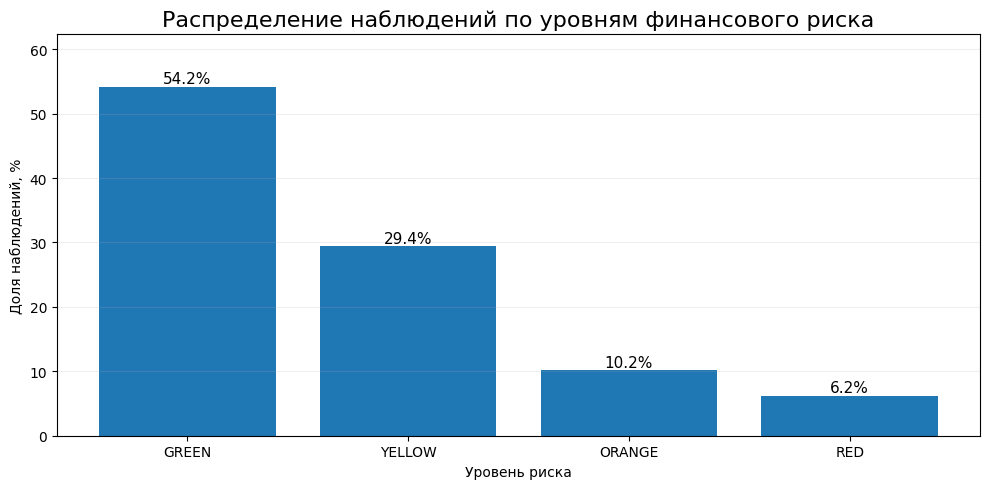

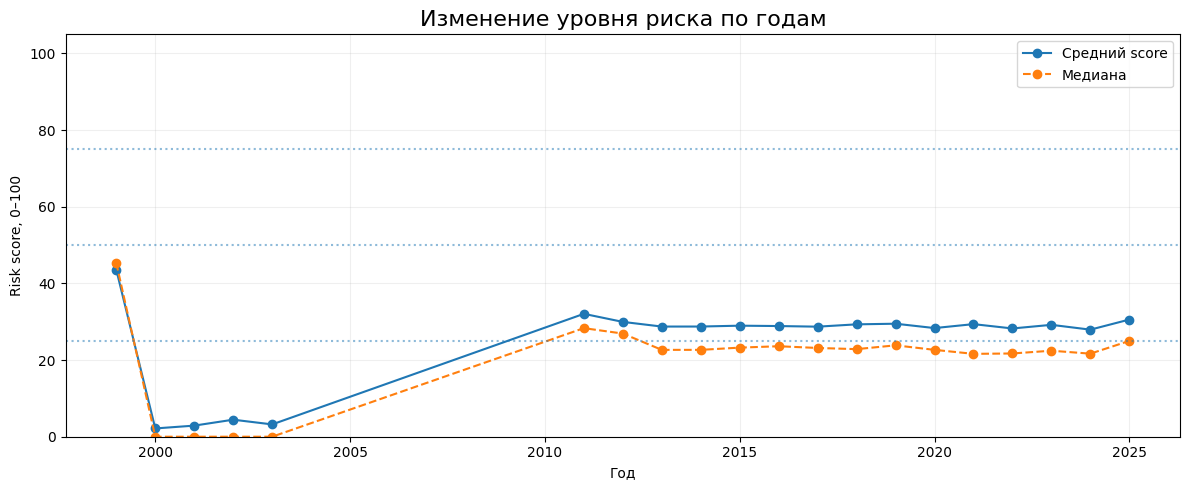

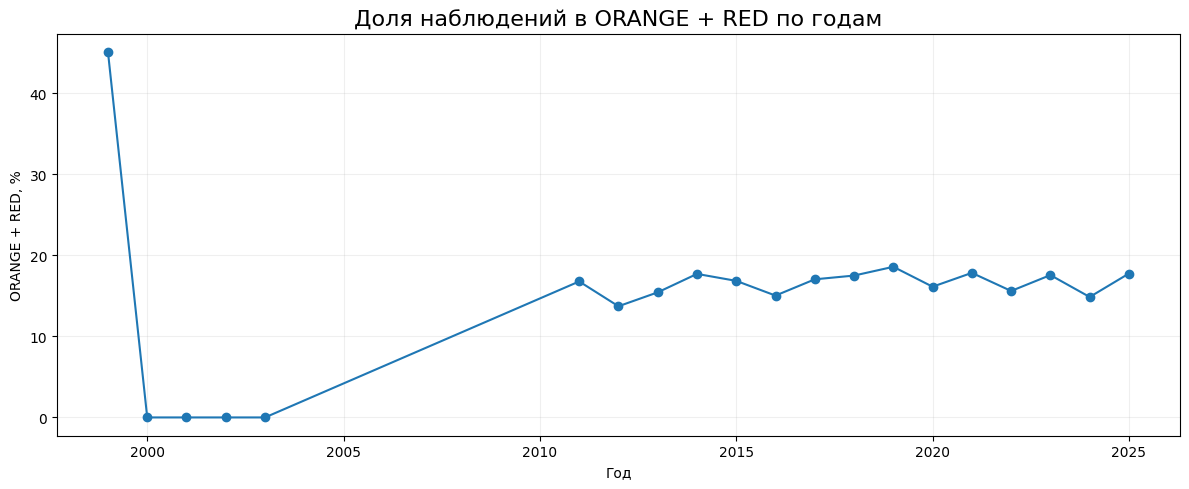

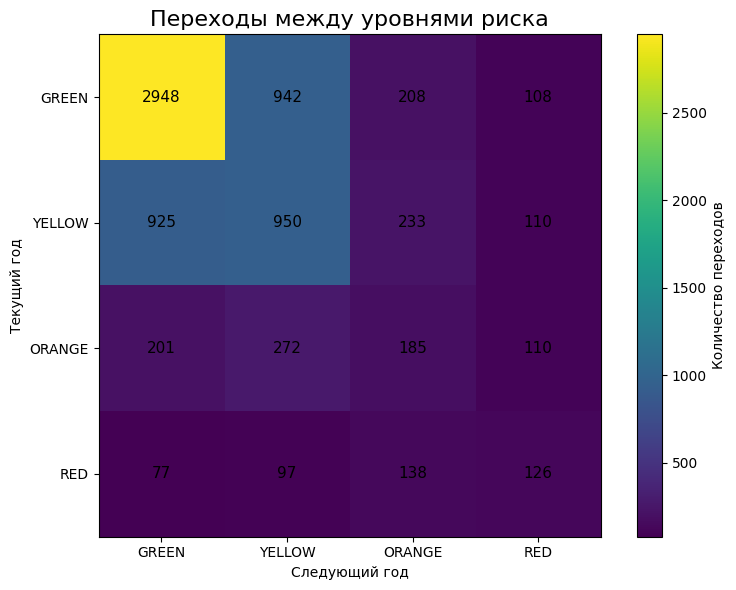

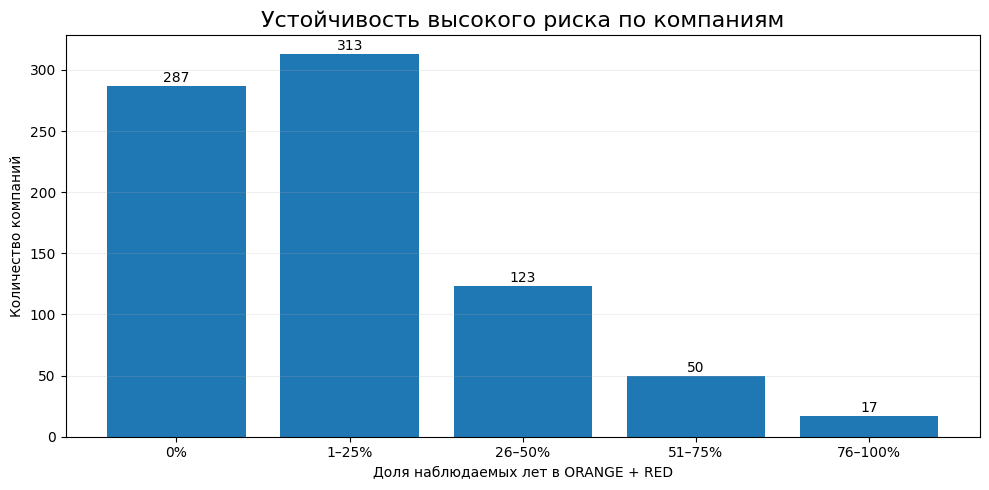


ПОРТФЕЛЬНАЯ СВОДКА


,Показатель,Значение
0,Наблюдений,8420.00
1,Компаний,790.00
2,Средний score,28.35
3,Медиана score,22.67
4,GREEN %,54.20
5,YELLOW %,29.41
6,ORANGE %,10.18
7,RED %,6.21
8,ORANGE + RED %,16.39


In [ ]:
# Ячейка 26 — портфельная визуализация V2 на всей выборке

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_pickle(HISTORY_PATH).copy()

required_columns = [
    'инн',
    'год',
    'risk_score_v2',
    'risk_level_v2',
    'negative_equity_signal'
]

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

if missing_columns:
    raise ValueError(
        f'В checkpoint отсутствуют необходимые колонки: {missing_columns}'
    )

# ---------------------------------------------------------
# 1. Подготовка
# ---------------------------------------------------------

level_order = ['GREEN', 'YELLOW', 'ORANGE', 'RED']

df = df.sort_values(['инн', 'год']).copy()

# ---------------------------------------------------------
# 2. Распределение наблюдений по цветам
# ---------------------------------------------------------

color_counts = (
    df['risk_level_v2']
    .value_counts()
    .reindex(level_order, fill_value=0)
)

color_share = (
    color_counts / len(df) * 100
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    color_share.index,
    color_share.values
)

ax.set_title(
    'Распределение наблюдений по уровням финансового риска',
    fontsize=16
)

ax.set_ylabel('Доля наблюдений, %')
ax.set_xlabel('Уровень риска')

for bar, value in zip(bars, color_share.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f'{value:.1f}%',
        ha='center',
        fontsize=11
    )

ax.set_ylim(0, max(color_share.values) * 1.15)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. Средний и медианный risk score по годам
# ---------------------------------------------------------

annual = (
    df.groupby('год')
    .agg(
        mean_score=('risk_score_v2', 'mean'),
        median_score=('risk_score_v2', 'median'),
        companies=('инн', 'nunique')
    )
    .reset_index()
    .sort_values('год')
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    annual['год'],
    annual['mean_score'],
    marker='o',
    label='Средний score'
)

ax.plot(
    annual['год'],
    annual['median_score'],
    marker='o',
    linestyle='--',
    label='Медиана'
)

for threshold in [25, 50, 75]:
    ax.axhline(
        threshold,
        linestyle=':',
        alpha=0.5
    )

ax.set_title(
    'Изменение уровня риска по годам',
    fontsize=16
)

ax.set_xlabel('Год')
ax.set_ylabel('Risk score, 0–100')

ax.set_ylim(0, 105)
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. Доля ORANGE + RED по годам
# ---------------------------------------------------------

annual_risk = (
    df.assign(
        high_risk=df['risk_level_v2'].isin(['ORANGE', 'RED'])
    )
    .groupby('год')
    .agg(
        high_risk_share=('high_risk', 'mean'),
        companies=('инн', 'nunique')
    )
    .reset_index()
    .sort_values('год')
)

annual_risk['high_risk_share'] *= 100

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    annual_risk['год'],
    annual_risk['high_risk_share'],
    marker='o'
)

ax.set_title(
    'Доля наблюдений в ORANGE + RED по годам',
    fontsize=16
)

ax.set_xlabel('Год')
ax.set_ylabel('ORANGE + RED, %')

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 5. Переходы между уровнями риска
# ---------------------------------------------------------

transition_df = df.copy()

transition_df['next_level'] = (
    transition_df
    .groupby('инн')['risk_level_v2']
    .shift(-1)
)

transitions = (
    transition_df
    .dropna(subset=['next_level'])
    .groupby(['risk_level_v2', 'next_level'])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=level_order,
        columns=level_order,
        fill_value=0
    )
)

fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(transitions.values)

ax.set_xticks(range(len(level_order)))
ax.set_yticks(range(len(level_order)))

ax.set_xticklabels(level_order)
ax.set_yticklabels(level_order)

ax.set_xlabel('Следующий год')
ax.set_ylabel('Текущий год')

ax.set_title(
    'Переходы между уровнями риска',
    fontsize=16
)

for i in range(len(level_order)):
    for j in range(len(level_order)):
        ax.text(
            j,
            i,
            str(int(transitions.iloc[i, j])),
            ha='center',
            va='center',
            fontsize=11
        )

plt.colorbar(
    image,
    ax=ax,
    label='Количество переходов'
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 6. Сколько компаний надолго остаются в ORANGE / RED
# ---------------------------------------------------------

company_duration = (
    df.assign(
        high_risk=df['risk_level_v2'].isin(['ORANGE', 'RED'])
    )
    .groupby('инн')
    .agg(
        years=('год', 'count'),
        high_risk_years=('high_risk', 'sum'),
        max_score=('risk_score_v2', 'max')
    )
    .reset_index()
)

company_duration['high_risk_share'] = (
    company_duration['high_risk_years']
    / company_duration['years']
    * 100
)

duration_bins = pd.cut(
    company_duration['high_risk_share'],
    bins=[-0.01, 0, 25, 50, 75, 100],
    labels=[
        '0%',
        '1–25%',
        '26–50%',
        '51–75%',
        '76–100%'
    ]
)

duration_distribution = (
    duration_bins
    .value_counts()
    .reindex(
        ['0%', '1–25%', '26–50%', '51–75%', '76–100%'],
        fill_value=0
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    duration_distribution.index.astype(str),
    duration_distribution.values
)

ax.set_title(
    'Устойчивость высокого риска по компаниям',
    fontsize=16
)

ax.set_xlabel(
    'Доля наблюдаемых лет в ORANGE + RED'
)

ax.set_ylabel('Количество компаний')

for bar, value in zip(
    bars,
    duration_distribution.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(duration_distribution.values) * 0.01,
        str(int(value)),
        ha='center',
        fontsize=10
    )

ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 7. Краткая таблица для контроля
# ---------------------------------------------------------

portfolio_summary = pd.DataFrame({
    'Показатель': [
        'Наблюдений',
        'Компаний',
        'Средний score',
        'Медиана score',
        'GREEN %',
        'YELLOW %',
        'ORANGE %',
        'RED %',
        'ORANGE + RED %'
    ],
    'Значение': [
        len(df),
        df['инн'].nunique(),
        df['risk_score_v2'].mean(),
        df['risk_score_v2'].median(),
        (df['risk_level_v2'] == 'GREEN').mean() * 100,
        (df['risk_level_v2'] == 'YELLOW').mean() * 100,
        (df['risk_level_v2'] == 'ORANGE').mean() * 100,
        (df['risk_level_v2'] == 'RED').mean() * 100,
        df['risk_level_v2']
        .isin(['ORANGE', 'RED'])
        .mean() * 100
    ]
})

portfolio_summary['Значение'] = (
    portfolio_summary['Значение'].round(2)
)

print()
print('=' * 100)
print('ПОРТФЕЛЬНАЯ СВОДКА')
print('=' * 100)

display(portfolio_summary)

### 27. Четыре характерных траектории как бизнес-кейсы

После анализа всей выборки рассматриваем четыре конкретные компании не как доказательство качества модели, а как примеры разных сценариев:

- постепенное ухудшение;
- резкий кризис;
- кризис с последующим снижением риска;
- кратковременный всплеск.

Для каждого кейса показываем изменение `risk_score_v2` по годам и основные причины изменения риска.

Цель — проверить, насколько легко объяснить бизнесу результат светофора на уровне одной компании.

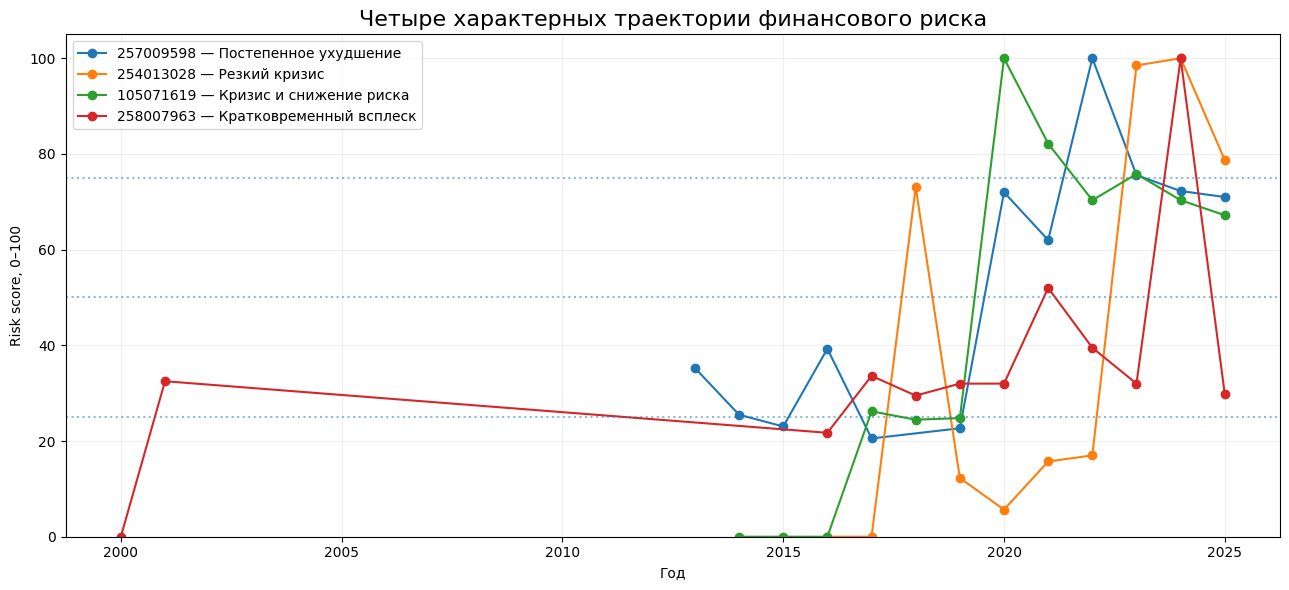


ПОСТЕПЕННОЕ УХУДШЕНИЕ — ИНН 257009598
Последний год: 2025
Последний risk score: 71.00
Последний уровень: ORANGE
Текущее состояние: 100.0
Динамика: 20.0
События: 40.0
Отрицательный капитал: Да



,год,risk_score_v2,risk_level_v2,current_norm,dynamic_norm,events_norm,negative_equity_signal
6836,2013,35.26,YELLOW,0.44,NaN,0.0,0.0
6837,2014,25.50,YELLOW,0.42,0.00,0.0,0.0
6838,2015,23.04,GREEN,0.34,0.10,0.0,0.0
6839,2016,39.28,YELLOW,0.49,0.40,0.0,0.0
6840,2017,20.54,GREEN,0.34,0.00,0.0,0.0
6841,2019,22.67,GREEN,0.38,0.00,0.0,0.0
6842,2020,72.00,ORANGE,0.67,0.73,0.9,1.0
6843,2021,62.00,ORANGE,0.67,0.63,0.4,1.0
6844,2022,100.00,RED,1.00,1.00,1.0,1.0
6845,2023,75.58,RED,1.00,0.08,0.9,1.0



РЕЗКИЙ КРИЗИС — ИНН 254013028
Последний год: 2025
Последний risk score: 78.71
Последний уровень: RED
Текущее состояние: 100.0
Динамика: 20.8
События: 90.0
Отрицательный капитал: Да



,год,risk_score_v2,risk_level_v2,current_norm,dynamic_norm,events_norm,negative_equity_signal
6377,2016,0.00,GREEN,0.00,NaN,0.0,0.0
6378,2017,0.00,GREEN,0.00,0.00,0.0,0.0
6379,2018,73.08,ORANGE,0.85,0.58,0.5,0.0
6380,2019,12.28,GREEN,0.20,0.00,0.0,0.0
6381,2020,5.67,GREEN,0.09,0.00,0.0,0.0
6382,2021,15.72,GREEN,0.22,0.10,0.0,0.0
6383,2022,17.00,GREEN,0.28,0.00,0.0,0.0
6384,2023,98.50,RED,1.00,1.00,0.9,1.0
6385,2024,100.00,RED,1.00,1.00,1.0,1.0
6386,2025,78.71,RED,1.00,0.21,0.9,1.0



КРИЗИС И СНИЖЕНИЕ РИСКА — ИНН 105071619
Последний год: 2025
Последний risk score: 67.19
Последний уровень: ORANGE
Текущее состояние: 87.4
Динамика: 35.0
События: 40.0
Отрицательный капитал: Да



,год,risk_score_v2,risk_level_v2,current_norm,dynamic_norm,events_norm,negative_equity_signal
1810,2014,0.00,GREEN,0.00,NaN,0.00,0.0
1811,2015,0.00,GREEN,0.00,0.00,0.00,0.0
1812,2016,0.00,GREEN,0.00,0.00,0.00,0.0
1813,2017,26.21,YELLOW,0.44,0.00,0.00,0.0
1814,2018,24.46,GREEN,0.37,0.10,0.00,0.0
1815,2019,24.79,GREEN,0.41,0.00,0.00,0.0
1816,2020,100.00,RED,1.00,1.00,1.00,1.0
1817,2021,82.17,RED,0.95,0.40,1.00,1.0
1818,2022,70.33,ORANGE,0.91,0.10,0.90,1.0
1819,2023,75.81,RED,0.94,0.63,0.25,1.0



КРАТКОВРЕМЕННЫЙ ВСПЛЕСК — ИНН 258007963
Последний год: 2025
Последний risk score: 29.75
Последний уровень: YELLOW
Текущее состояние: 43.3
Динамика: 0.0
События: 25.0
Отрицательный капитал: Да



,год,risk_score_v2,risk_level_v2,current_norm,dynamic_norm,events_norm,negative_equity_signal
6995,2000,0.00,GREEN,0.00,NaN,0.00,0.0
6996,2001,32.50,YELLOW,0.00,1.0,0.50,0.0
6997,2016,21.72,GREEN,0.36,0.0,0.00,0.0
6998,2017,33.61,YELLOW,0.39,0.1,0.50,0.0
6999,2018,29.50,YELLOW,0.28,0.5,0.00,0.0
7000,2019,32.00,YELLOW,0.43,0.0,0.40,1.0
7001,2020,32.00,YELLOW,0.43,0.0,0.40,1.0
7002,2021,52.00,ORANGE,0.43,0.5,0.90,1.0
7003,2022,39.50,YELLOW,0.43,0.0,0.90,1.0
7004,2023,32.00,YELLOW,0.43,0.0,0.40,1.0


In [ ]:
# Ячейка 27 — четыре характерных бизнес-кейса

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_pickle(HISTORY_PATH).copy()

TARGET_COMPANIES = {
    '257009598': 'Постепенное ухудшение',
    '254013028': 'Резкий кризис',
    '105071619': 'Кризис и снижение риска',
    '258007963': 'Кратковременный всплеск'
}

required_columns = [
    'инн',
    'год',
    'risk_score_v2',
    'risk_level_v2',
    'current_norm',
    'dynamic_norm',
    'events_norm',
    'negative_equity_signal'
]

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

if missing_columns:
    raise ValueError(
        f'В checkpoint отсутствуют необходимые колонки: {missing_columns}'
    )

# ---------------------------------------------------------
# 1. Один общий график четырёх траекторий
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 6))

for inn, description in TARGET_COMPANIES.items():

    company = (
        df[df['инн'].astype(str) == inn]
        .sort_values('год')
        .copy()
    )

    if company.empty:
        print(f'Компания {inn} не найдена.')
        continue

    ax.plot(
        company['год'],
        company['risk_score_v2'],
        marker='o',
        label=f'{inn} — {description}'
    )

ax.axhline(25, linestyle=':', alpha=0.5)
ax.axhline(50, linestyle=':', alpha=0.5)
ax.axhline(75, linestyle=':', alpha=0.5)

ax.set_title(
    'Четыре характерных траектории финансового риска',
    fontsize=16
)

ax.set_xlabel('Год')
ax.set_ylabel('Risk score, 0–100')

ax.set_ylim(0, 105)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. Карточка каждого кейса
# ---------------------------------------------------------

for inn, description in TARGET_COMPANIES.items():

    company = (
        df[df['инн'].astype(str) == inn]
        .sort_values('год')
        .copy()
    )

    if company.empty:
        continue

    last = company.iloc[-1]

    print()
    print('=' * 100)
    print(f'{description.upper()} — ИНН {inn}')
    print('=' * 100)

    print(
        f"Последний год: {int(last['год'])}"
    )

    print(
        f"Последний risk score: "
        f"{last['risk_score_v2']:.2f}"
    )

    print(
        f"Последний уровень: "
        f"{last['risk_level_v2']}"
    )

    print(
        f"Текущее состояние: "
        f"{last['current_norm'] * 100:.1f}"
    )

    print(
        f"Динамика: "
        f"{last['dynamic_norm'] * 100:.1f}"
    )

    print(
        f"События: "
        f"{last['events_norm'] * 100:.1f}"
    )

    print(
        f"Отрицательный капитал: "
        f"{'Да' if last['negative_equity_signal'] > 0 else 'Нет'}"
    )

    print()

    display(
        company[
            [
                'год',
                'risk_score_v2',
                'risk_level_v2',
                'current_norm',
                'dynamic_norm',
                'events_norm',
                'negative_equity_signal'
            ]
        ]
        .round(2)
    )

## 28. Портфельный срез: текущий и исторический

Формируем два представления риска:
1. текущий портфель — последняя доступная запись каждой компании;
2. историческая динамика — по одному наблюдению каждой компании в каждом году, если финансовые данные есть за этот год.

Дополнительно считаем покрытие компаний по годам, чтобы не путать изменение риска с изменением состава выборки.

ТЕКУЩИЙ ПОРТФЕЛЬНЫЙ СРЕЗ
Компаний: 790
Период последних доступных данных: 2018–2025
Средний score: 33.63
Медиана score: 28.62

Распределение компаний:
GREEN   :  45.32%
YELLOW  :  32.66%
ORANGE  :  11.27%
RED     :  10.76%

ORANGE + RED: 22.03%

ИСТОРИЧЕСКОЕ РАСПРЕДЕЛЕНИЕ


risk_level_v2,companies,GREEN,YELLOW,ORANGE,RED,ORANGE_RED
год,,,,,,
1999,51,17.65,37.25,45.10,0.00,45.10
2000,59,94.92,5.08,0.00,0.00,0.00
2001,63,92.06,7.94,0.00,0.00,0.00
2002,72,88.89,11.11,0.00,0.00,0.00
2003,63,92.06,7.94,0.00,0.00,0.00
2011,155,39.35,43.87,13.55,3.23,16.77
2012,175,46.29,40.00,9.71,4.00,13.71
2013,337,54.90,29.67,8.31,7.12,15.43
2014,401,53.12,29.18,11.22,6.48,17.71


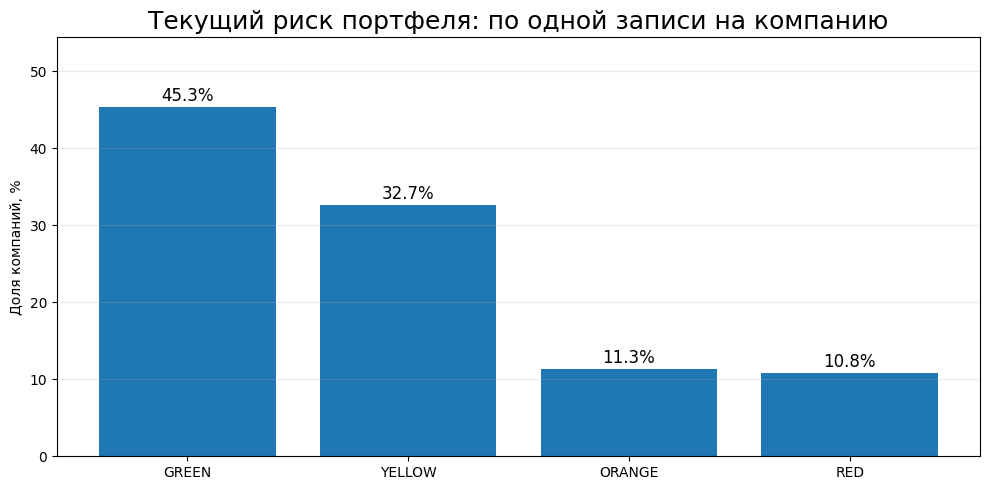

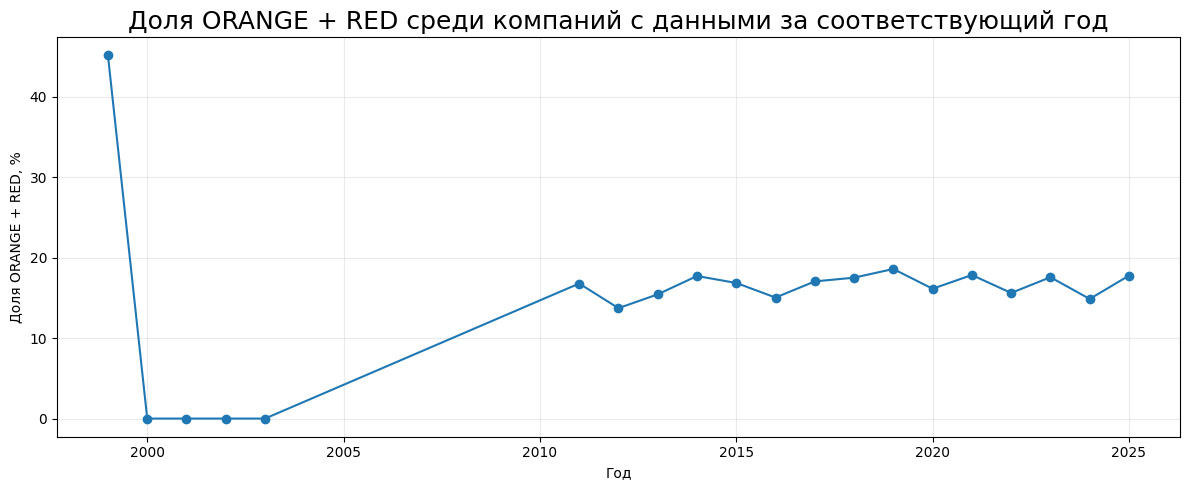

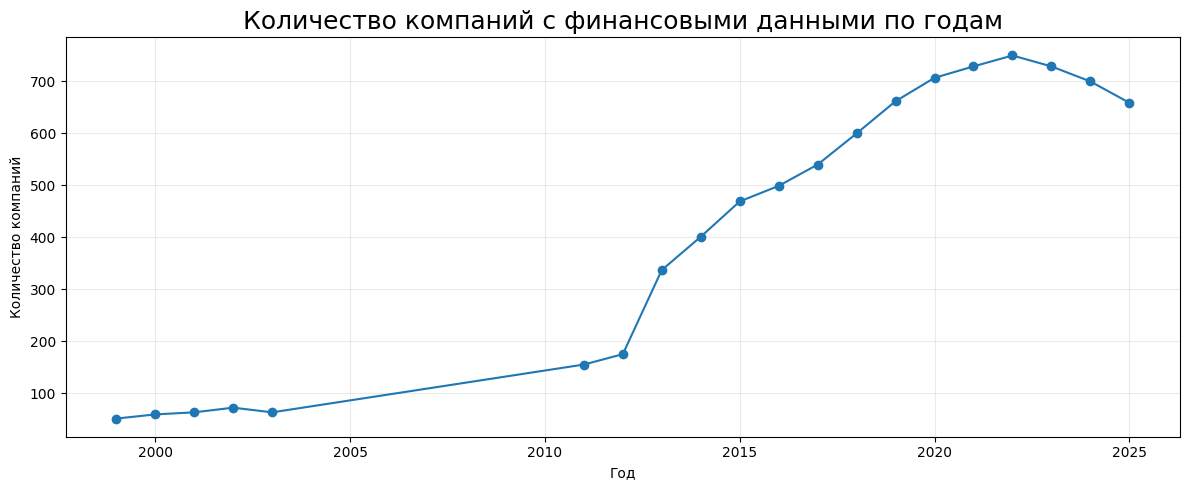

In [ ]:
# 28. Портфельный срез: текущий и исторический

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

HISTORY_PATH = "/content/drive/MyDrive/komus-credit-risk/experiments/traffic_light_v2_checkpoints/traffic_light_v2_stage_14_history.pkl"

history = pd.read_pickle(HISTORY_PATH).copy()

history["инн"] = history["инн"].astype(str)
history["год"] = pd.to_numeric(history["год"], errors="coerce")
history["risk_score_v2"] = pd.to_numeric(history["risk_score_v2"], errors="coerce")

levels = ["GREEN", "YELLOW", "ORANGE", "RED"]

# ------------------------------------------------------------
# 28.1 Последнее доступное наблюдение каждой компании
# ------------------------------------------------------------

current_portfolio = (
    history
    .dropna(subset=["инн", "год", "risk_score_v2"])
    .sort_values(["инн", "год"])
    .groupby("инн", as_index=False)
    .tail(1)
    .copy()
)

current_portfolio["risk_level_v2"] = pd.Categorical(
    current_portfolio["risk_level_v2"],
    categories=levels,
    ordered=True
)

current_distribution = (
    current_portfolio["risk_level_v2"]
    .value_counts(normalize=True)
    .reindex(levels, fill_value=0)
    .mul(100)
)

print("=" * 100)
print("ТЕКУЩИЙ ПОРТФЕЛЬНЫЙ СРЕЗ")
print("=" * 100)
print(f"Компаний: {current_portfolio['инн'].nunique():,}")
print(
    f"Период последних доступных данных: "
    f"{int(current_portfolio['год'].min())}–{int(current_portfolio['год'].max())}"
)
print(f"Средний score: {current_portfolio['risk_score_v2'].mean():.2f}")
print(f"Медиана score: {current_portfolio['risk_score_v2'].median():.2f}")
print()

print("Распределение компаний:")
for level in levels:
    print(f"{level:8s}: {current_distribution[level]:6.2f}%")

print(f"\nORANGE + RED: {current_distribution['ORANGE'] + current_distribution['RED']:.2f}%")

# ------------------------------------------------------------
# 28.2 Историческое распределение по годам
# Каждая компания учитывается максимум один раз в конкретном году.
# Здесь НЕ переносим старое значение компании в годы, где записи нет.
# ------------------------------------------------------------

annual_portfolio = (
    history
    .dropna(subset=["инн", "год", "risk_score_v2"])
    .sort_values(["год", "инн"])
    .drop_duplicates(["год", "инн"], keep="last")
    .copy()
)

annual_counts = (
    annual_portfolio
    .groupby("год")["инн"]
    .nunique()
    .rename("companies")
)

annual_distribution = (
    pd.crosstab(
        annual_portfolio["год"],
        annual_portfolio["risk_level_v2"],
        normalize="index"
    )
    .reindex(columns=levels, fill_value=0)
    .mul(100)
)

annual_summary = annual_distribution.copy()
annual_summary["companies"] = annual_counts
annual_summary["ORANGE_RED"] = (
    annual_summary["ORANGE"] + annual_summary["RED"]
)

print("\n" + "=" * 100)
print("ИСТОРИЧЕСКОЕ РАСПРЕДЕЛЕНИЕ")
print("=" * 100)

display(
    annual_summary[
        ["companies", "GREEN", "YELLOW", "ORANGE", "RED", "ORANGE_RED"]
    ].round(2)
)

# ------------------------------------------------------------
# 28.3 График текущего портфеля
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

bars = plt.bar(
    levels,
    current_distribution.values
)

plt.title("Текущий риск портфеля: по одной записи на компанию", fontsize=18)
plt.ylabel("Доля компаний, %")
plt.ylim(0, max(current_distribution.values) * 1.2)

for bar, value in zip(bars, current_distribution.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{value:.1f}%",
        ha="center",
        fontsize=12
    )

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 28.4 Историческая динамика ORANGE + RED
# ------------------------------------------------------------

plot_data = annual_summary.dropna(subset=["ORANGE_RED"]).copy()

plt.figure(figsize=(12, 5))

plt.plot(
    plot_data.index,
    plot_data["ORANGE_RED"],
    marker="o"
)

plt.title(
    "Доля ORANGE + RED среди компаний с данными за соответствующий год",
    fontsize=18
)
plt.xlabel("Год")
plt.ylabel("Доля ORANGE + RED, %")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 28.5 Покрытие выборки
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    annual_summary.index,
    annual_summary["companies"],
    marker="o"
)

plt.title("Количество компаний с финансовыми данными по годам", fontsize=18)
plt.xlabel("Год")
plt.ylabel("Количество компаний")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 29. Текущий риск компаний: 2025 год

Формируем основной бизнес-срез только по компаниям, у которых есть финансовые данные за 2025 год.

Каждая компания учитывается один раз.

Дополнительно сравниваем этот срез с последним доступным годом каждой компании, чтобы увидеть влияние неполной актуальности данных.

ТЕКУЩИЙ РИСК ПОРТФЕЛЯ — 2025 ГОД
Компаний с данными за 2025: 659
Средний score: 30.57
Медиана score: 25.00

GREEN   :  49.32%
YELLOW  :  32.93%
ORANGE  :  10.02%
RED     :   7.74%

ORANGE + RED: 17.75%


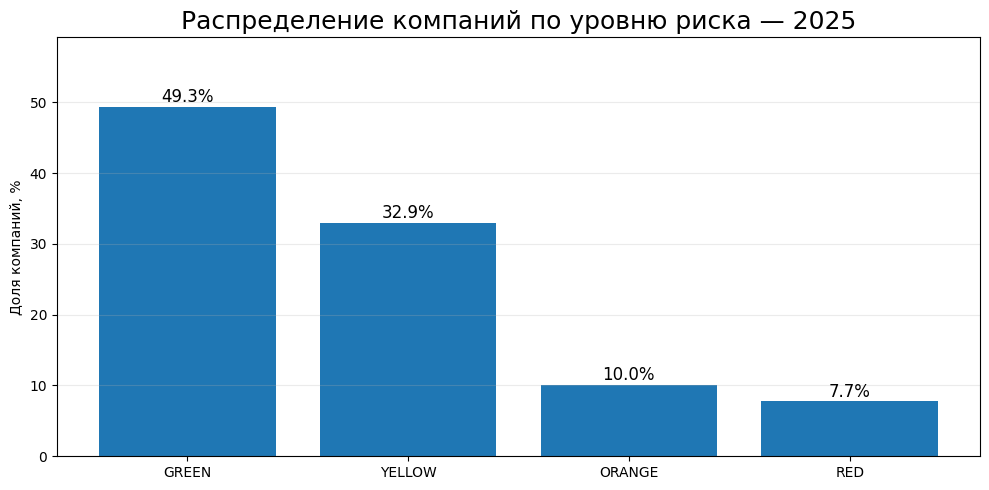


2025 VS ПОСЛЕДНИЙ ДОСТУПНЫЙ ГОД


,2025,Последний доступный год,"Разница, п.п."
risk_level_v2,,,
GREEN,49.32,45.32,4.00
YELLOW,32.93,32.66,0.27
ORANGE,10.02,11.27,-1.25
RED,7.74,10.76,-3.02


ORANGE + RED — 2025: 17.75%
ORANGE + RED — последний доступный год: 22.03%


In [ ]:
# 29. Текущий риск компаний: 2025 год

import pandas as pd
import matplotlib.pyplot as plt

levels = ["GREEN", "YELLOW", "ORANGE", "RED"]

# ------------------------------------------------------------
# 29.1 Срез компаний за 2025 год
# ------------------------------------------------------------

portfolio_2025 = (
    history[
        history["год"].eq(2025)
    ]
    .dropna(subset=["инн", "risk_score_v2"])
    .sort_values(["инн", "risk_score_v2"])
    .drop_duplicates("инн", keep="last")
    .copy()
)

portfolio_2025["risk_level_v2"] = pd.Categorical(
    portfolio_2025["risk_level_v2"],
    categories=levels,
    ordered=True
)

distribution_2025 = (
    portfolio_2025["risk_level_v2"]
    .value_counts(normalize=True)
    .reindex(levels, fill_value=0)
    .mul(100)
)

print("=" * 100)
print("ТЕКУЩИЙ РИСК ПОРТФЕЛЯ — 2025 ГОД")
print("=" * 100)

print(f"Компаний с данными за 2025: {len(portfolio_2025):,}")
print(f"Средний score: {portfolio_2025['risk_score_v2'].mean():.2f}")
print(f"Медиана score: {portfolio_2025['risk_score_v2'].median():.2f}")
print()

for level in levels:
    print(f"{level:8s}: {distribution_2025[level]:6.2f}%")

orange_red_2025 = (
    distribution_2025["ORANGE"] +
    distribution_2025["RED"]
)

print(f"\nORANGE + RED: {orange_red_2025:.2f}%")

# ------------------------------------------------------------
# 29.2 График текущего распределения
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

bars = plt.bar(
    levels,
    distribution_2025.values
)

plt.title(
    "Распределение компаний по уровню риска — 2025",
    fontsize=18
)
plt.ylabel("Доля компаний, %")
plt.ylim(0, max(distribution_2025.values) * 1.2)

for bar, value in zip(bars, distribution_2025.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.7,
        f"{value:.1f}%",
        ha="center",
        fontsize=12
    )

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 29.3 Сравнение 2025 и последнего доступного года
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "2025": distribution_2025,
    "Последний доступный год": current_distribution
})

comparison["Разница, п.п."] = (
    comparison["2025"] -
    comparison["Последний доступный год"]
)

print("\n" + "=" * 100)
print("2025 VS ПОСЛЕДНИЙ ДОСТУПНЫЙ ГОД")
print("=" * 100)

display(comparison.round(2))

print(
    f"ORANGE + RED — 2025: {orange_red_2025:.2f}%"
)

print(
    f"ORANGE + RED — последний доступный год: "
    f"{current_distribution['ORANGE'] + current_distribution['RED']:.2f}%"
)

## 30. Причины высокого риска в портфеле 2025

Для 2025 года выделяем компании ORANGE + RED и смотрим, какие компоненты риска у них выражены сильнее.

Проверяем:
- долговую нагрузку;
- ликвидность;
- способность обслуживать обязательства;
- прибыльность;
- динамику;
- события;
- отрицательный капитал.

На этом этапе это диагностический анализ V2, а не окончательное распределение причин.

КОМПАНИИ ORANGE + RED — 2025
Всего компаний с данными за 2025: 659
ORANGE + RED: 117
Доля ORANGE + RED: 17.75%

СРЕДНЯЯ ВЫРАЖЕННОСТЬ КОМПОНЕНТОВ — ORANGE + RED


,Среднее значение 0–1
Прибыльность,0.808
Долговая нагрузка,0.781
Ликвидность,0.751
Способность обслуживать обязательства,0.675
Динамика,0.674
События,0.619
Отрицательный капитал,0.496



ДОЛЯ ORANGE + RED С ВЫРАЖЕННЫМ КОМПОНЕНТОМ
Диагностический порог компонента: >= 0.5


,"Доля компаний, %"
События,76.07
Динамика,74.36
Прибыльность,70.94
Отрицательный капитал,49.57
Долговая нагрузка,48.72
Ликвидность,45.30
Способность обслуживать обязательства,25.64


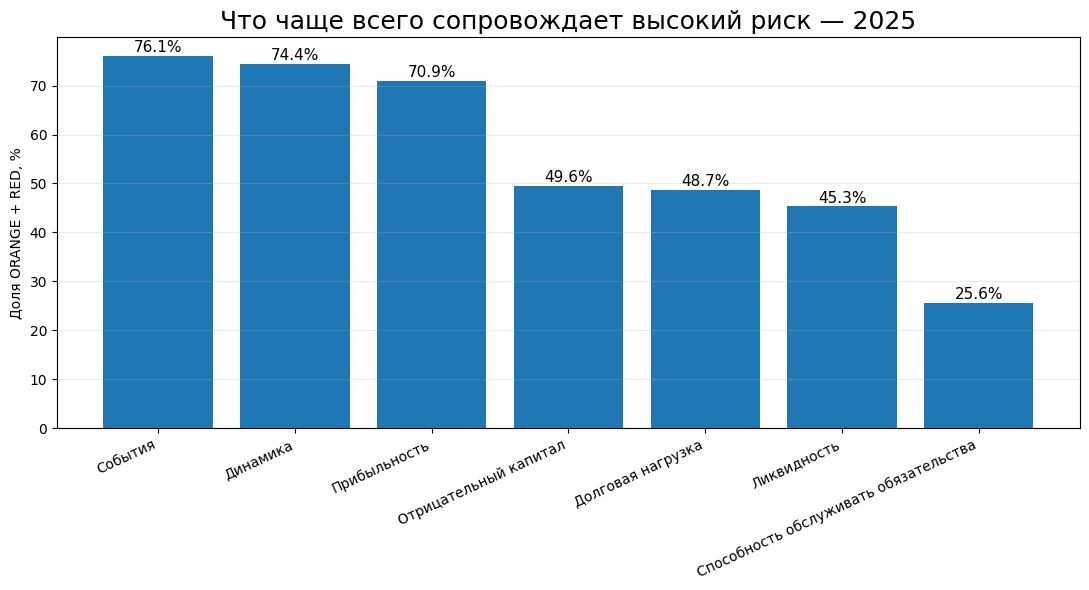

In [ ]:
# 30. Причины высокого риска в портфеле 2025

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 30.1 Выделяем ORANGE + RED
# ------------------------------------------------------------

high_risk_2025 = portfolio_2025[
    portfolio_2025["risk_level_v2"].isin(["ORANGE", "RED"])
].copy()

print("=" * 100)
print("КОМПАНИИ ORANGE + RED — 2025")
print("=" * 100)

print(f"Всего компаний с данными за 2025: {len(portfolio_2025):,}")
print(f"ORANGE + RED: {len(high_risk_2025):,}")
print(
    f"Доля ORANGE + RED: "
    f"{len(high_risk_2025) / len(portfolio_2025) * 100:.2f}%"
)

# ------------------------------------------------------------
# 30.2 Нормализованные компоненты V2
# ------------------------------------------------------------

driver_columns = {
    "Долговая нагрузка": "current_debt",
    "Ликвидность": "current_liquidity",
    "Способность обслуживать обязательства": "current_ability_to_pay",
    "Прибыльность": "current_profitability",
    "Динамика": "dynamic_norm",
    "События": "events_norm"
}

for name, column in driver_columns.items():
    high_risk_2025[name] = pd.to_numeric(
        high_risk_2025[column],
        errors="coerce"
    )

high_risk_2025["Отрицательный капитал"] = (
    pd.to_numeric(
        high_risk_2025["negative_equity_signal"],
        errors="coerce"
    ).fillna(0)
)

# ------------------------------------------------------------
# 30.3 Средняя выраженность компонентов
# ------------------------------------------------------------

driver_names = list(driver_columns.keys()) + ["Отрицательный капитал"]

driver_mean = (
    high_risk_2025[driver_names]
    .mean()
    .sort_values(ascending=False)
)

print("\n" + "=" * 100)
print("СРЕДНЯЯ ВЫРАЖЕННОСТЬ КОМПОНЕНТОВ — ORANGE + RED")
print("=" * 100)

display(
    driver_mean
    .rename("Среднее значение 0–1")
    .round(3)
    .to_frame()
)

# ------------------------------------------------------------
# 30.4 Доля компаний с выраженным компонентом
# Порог 0.5 используется только как диагностический ориентир.
# ------------------------------------------------------------

driver_share = (
    (high_risk_2025[driver_names] >= 0.5)
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\n" + "=" * 100)
print("ДОЛЯ ORANGE + RED С ВЫРАЖЕННЫМ КОМПОНЕНТОМ")
print("=" * 100)
print("Диагностический порог компонента: >= 0.5")

display(
    driver_share
    .rename("Доля компаний, %")
    .round(2)
    .to_frame()
)

# ------------------------------------------------------------
# 30.5 График
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

bars = plt.bar(
    driver_share.index,
    driver_share.values
)

plt.title(
    "Что чаще всего сопровождает высокий риск — 2025",
    fontsize=18
)
plt.ylabel("Доля ORANGE + RED, %")
plt.xticks(rotation=25, ha="right")

for bar, value in zip(bars, driver_share.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{value:.1f}%",
        ha="center",
        fontsize=11
    )

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 31. Какие конкретные показатели отличают ORANGE + RED

Сравниваем исходные финансовые показатели компаний ORANGE + RED с остальными компаниями за 2025 год.

Для каждого показателя смотрим:
- медиану у ORANGE + RED;
- медиану у GREEN + YELLOW;
- долю пропусков;
- направление различия.

Это позволяет перейти от компонентов V2 к конкретным финансовым сигналам и проверить, какие показатели действительно различаются между группами.

СРАВНЕНИЕ КОНКРЕТНЫХ ФИНАНСОВЫХ ПОКАЗАТЕЛЕЙ — 2025


,Показатель,Медиана ORANGE + RED,Медиана GREEN + YELLOW,Разница медиан,"Пропуски ORANGE + RED, %","Пропуски GREEN + YELLOW, %"
0,Доля обязательств в активах,0.999,0.565,0.434,45.299,45.203
1,Обязательства к капиталу,0.102,1.133,-1.031,45.299,45.018
2,Долговая нагрузка к выручке,2.059,0.369,1.690,55.556,47.048
3,Текущая ликвидность,0.981,1.794,-0.814,45.299,46.125
4,Быстрая ликвидность,0.421,0.946,-0.525,47.863,47.601
5,Денежные средства к краткосрочным обязательствам,0.004,0.060,-0.057,46.154,46.679
6,Покрытие процентов прибылью,0.405,2.854,-2.449,87.179,79.151
7,OCF к краткосрочным обязательствам,-0.007,0.097,-0.104,67.521,65.314
8,OCF к обязательствам,-0.006,0.062,-0.069,67.521,65.314
9,Рентабельность по чистой прибыли,-0.153,0.028,-0.181,17.094,8.856



Важно: различие показателей не означает причинно-следственную связь. Это диагностическое сравнение групп.


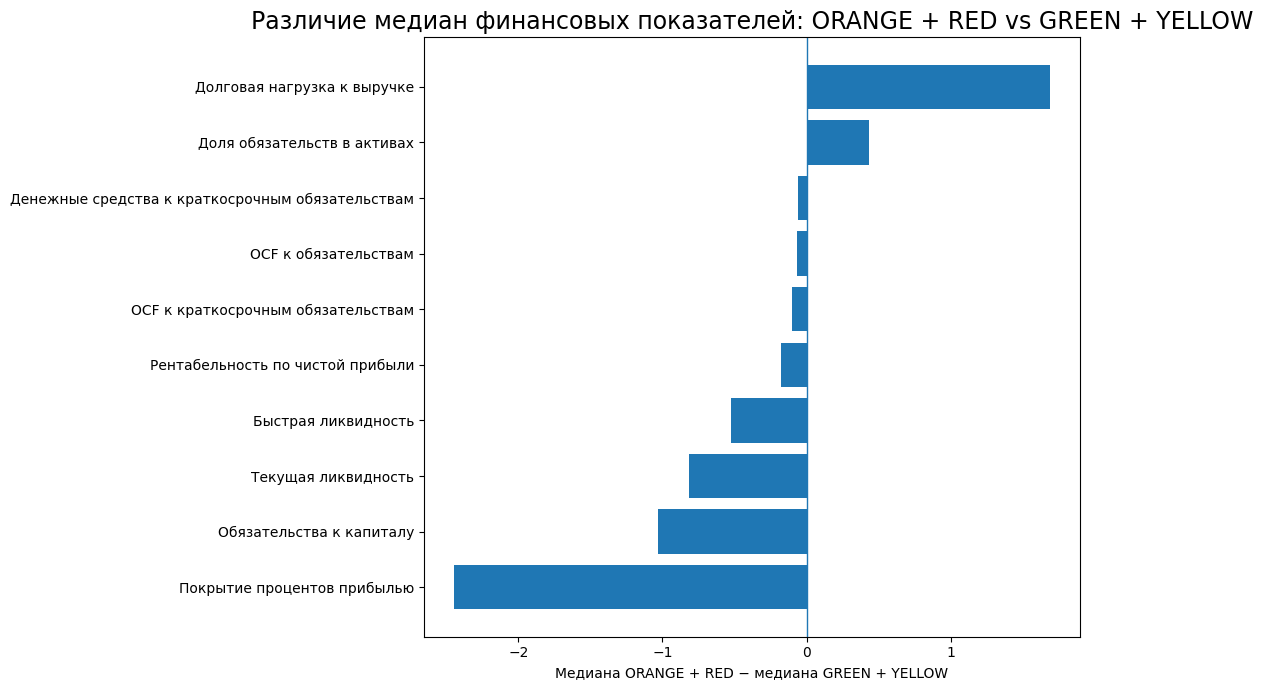

In [ ]:
# 31. Какие конкретные показатели отличают ORANGE + RED

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 31.1 Разделяем компании на две группы
# ------------------------------------------------------------

analysis_2025 = portfolio_2025.copy()

analysis_2025["risk_group"] = np.where(
    analysis_2025["risk_level_v2"].isin(["ORANGE", "RED"]),
    "ORANGE + RED",
    "GREEN + YELLOW"
)

# ------------------------------------------------------------
# 31.2 Исходные показатели для анализа
# ------------------------------------------------------------

indicator_map = {
    "Доля обязательств в активах": "доля_обязательств_в_активах",
    "Обязательства к капиталу": "обязательства_к_капиталу",
    "Долговая нагрузка к выручке": "долговая_нагрузка_к_выручке",
    "Текущая ликвидность": "текущая_ликвидность",
    "Быстрая ликвидность": "быстрая_ликвидность",
    "Денежные средства к краткосрочным обязательствам":
        "денежные_средства_к_краткосрочным_обязательствам",
    "Покрытие процентов прибылью": "покрытие_процентов_прибылью",
    "OCF к краткосрочным обязательствам":
        "операционный_денежный_поток_к_краткосрочным_обязательствам",
    "OCF к обязательствам":
        "операционный_денежный_поток_к_обязательствам",
    "Рентабельность по чистой прибыли":
        "рентабельность_по_чистой_прибыли"
}

rows = []

# ------------------------------------------------------------
# 31.3 Медианы и пропуски
# ------------------------------------------------------------

for label, column in indicator_map.items():

    if column not in analysis_2025.columns:
        continue

    values = pd.to_numeric(
        analysis_2025[column],
        errors="coerce"
    )

    group_high = values[
        analysis_2025["risk_group"] == "ORANGE + RED"
    ]

    group_low = values[
        analysis_2025["risk_group"] == "GREEN + YELLOW"
    ]

    median_high = group_high.median()
    median_low = group_low.median()

    missing_high = group_high.isna().mean() * 100
    missing_low = group_low.isna().mean() * 100

    rows.append({
        "Показатель": label,
        "Медиана ORANGE + RED": median_high,
        "Медиана GREEN + YELLOW": median_low,
        "Разница медиан": median_high - median_low,
        "Пропуски ORANGE + RED, %": missing_high,
        "Пропуски GREEN + YELLOW, %": missing_low
    })

indicator_comparison = pd.DataFrame(rows)

# ------------------------------------------------------------
# 31.4 Вывод
# ------------------------------------------------------------

print("=" * 100)
print("СРАВНЕНИЕ КОНКРЕТНЫХ ФИНАНСОВЫХ ПОКАЗАТЕЛЕЙ — 2025")
print("=" * 100)

display(
    indicator_comparison.round(3)
)

print(
    "\nВажно: различие показателей не означает причинно-следственную связь. "
    "Это диагностическое сравнение групп."
)

# ------------------------------------------------------------
# 31.5 Визуализация абсолютной разницы медиан
# ------------------------------------------------------------

plot_data = (
    indicator_comparison
    .dropna(subset=["Разница медиан"])
    .sort_values("Разница медиан")
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_data["Показатель"],
    plot_data["Разница медиан"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Различие медиан финансовых показателей: ORANGE + RED vs GREEN + YELLOW",
    fontsize=17
)

plt.xlabel("Медиана ORANGE + RED − медиана GREEN + YELLOW")
plt.tight_layout()
plt.show()

## 32. Какие показатели сильнее всего различают группы риска

Стандартизируем каждый исходный показатель относительно распределения 2025 года и сравниваем положение ORANGE + RED и GREEN + YELLOW.

Цель — получить сопоставимую картину по разным финансовым показателям, не смешивая их исходные единицы измерения.

Результат используется как исследовательский материал для выбора сигналов V2, а не как доказательство причинности.

СИЛА РАЗЛИЧИЯ ФИНАНСОВЫХ ПОКАЗАТЕЛЕЙ


,Показатель,Медиана ORANGE + RED,Медиана GREEN + YELLOW,Стандартизированная разница
9,Рентабельность по чистой прибыли,-0.153,0.028,-2.301
2,Долговая нагрузка к выручке,2.059,0.369,2.172
0,Доля обязательств в активах,0.999,0.565,0.668
4,Быстрая ликвидность,0.421,0.946,-0.358
3,Текущая ликвидность,0.981,1.794,-0.353
6,Покрытие процентов прибылью,0.405,2.854,-0.348
1,Обязательства к капиталу,0.102,1.133,-0.235
8,OCF к обязательствам,-0.006,0.062,-0.228
7,OCF к краткосрочным обязательствам,-0.007,0.097,-0.228
5,Денежные средства к краткосрочным обязательствам,0.004,0.060,-0.206


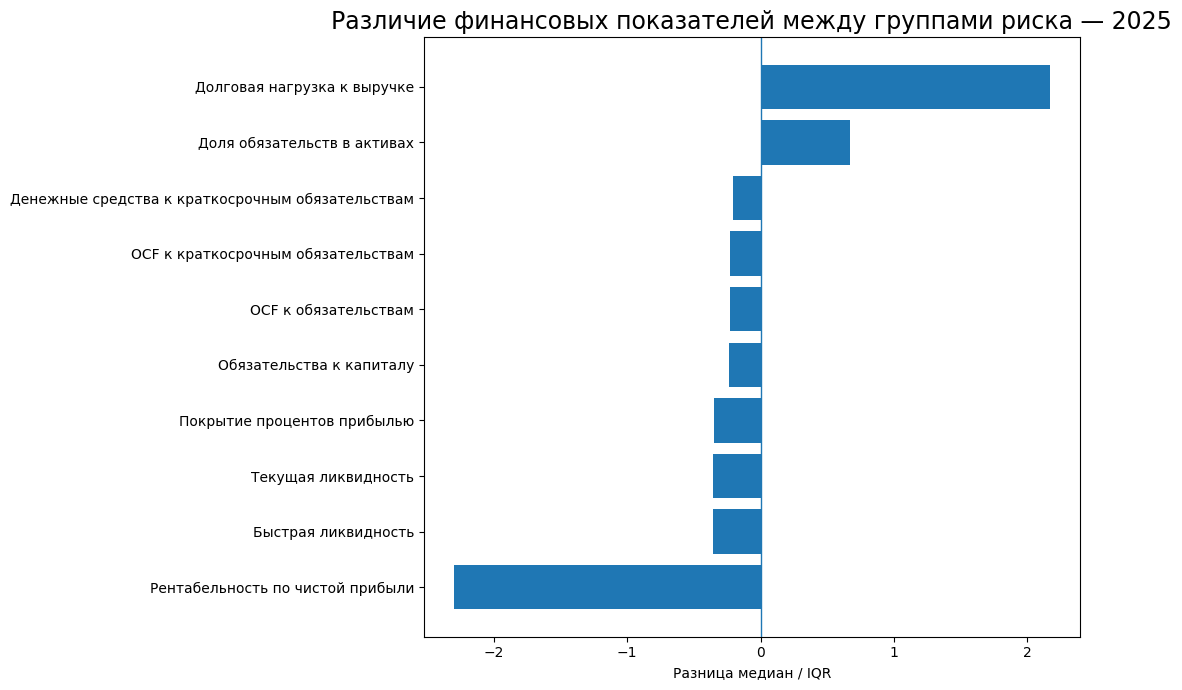

In [ ]:
# 32. Какие показатели сильнее всего различают группы риска

# ------------------------------------------------------------
# 32.1 Расчёт стандартизированной разницы медиан
# ------------------------------------------------------------

effect_rows = []

for label, column in indicator_map.items():

    if column not in analysis_2025.columns:
        continue

    values = pd.to_numeric(
        analysis_2025[column],
        errors="coerce"
    )

    valid = values.notna()

    if valid.sum() < 20:
        continue

    median_all = values[valid].median()
    q75 = values[valid].quantile(0.75)
    q25 = values[valid].quantile(0.25)

    iqr = q75 - q25

    if pd.isna(iqr) or iqr == 0:
        continue

    high = values[
        (analysis_2025["risk_group"] == "ORANGE + RED") &
        valid
    ]

    low = values[
        (analysis_2025["risk_group"] == "GREEN + YELLOW") &
        valid
    ]

    if len(high) == 0 or len(low) == 0:
        continue

    median_high = high.median()
    median_low = low.median()

    standardized_difference = (
        median_high - median_low
    ) / iqr

    effect_rows.append({
        "Показатель": label,
        "Медиана ORANGE + RED": median_high,
        "Медиана GREEN + YELLOW": median_low,
        "Стандартизированная разница": standardized_difference,
        "IQR всей выборки": iqr
    })

effect_table = pd.DataFrame(effect_rows)

effect_table["Абсолютная сила различия"] = (
    effect_table["Стандартизированная разница"]
    .abs()
)

effect_table = (
    effect_table
    .sort_values(
        "Абсолютная сила различия",
        ascending=False
    )
)

print("=" * 100)
print("СИЛА РАЗЛИЧИЯ ФИНАНСОВЫХ ПОКАЗАТЕЛЕЙ")
print("=" * 100)

display(
    effect_table[
        [
            "Показатель",
            "Медиана ORANGE + RED",
            "Медиана GREEN + YELLOW",
            "Стандартизированная разница"
        ]
    ].round(3)
)

# ------------------------------------------------------------
# 32.2 График
# ------------------------------------------------------------

plot_data = effect_table.sort_values(
    "Стандартизированная разница"
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_data["Показатель"],
    plot_data["Стандартизированная разница"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Различие финансовых показателей между группами риска — 2025",
    fontsize=17
)

plt.xlabel(
    "Разница медиан / IQR"
)

plt.tight_layout()
plt.show()

## 33. Проверка расширенной выборки 1.csv

Проверяем расширенную финансовую выборку перед переносом на неё V2.

Сравниваем структуру данных с текущей схемой V2:
- количество строк;
- количество компаний;
- диапазон лет;
- количество и названия показателей;
- наличие необходимых колонок;
- пропуски и типы данных.

На этом этапе V2 не изменяем.

In [ ]:
# 33. Проверка расширенной выборки 1.csv

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# 33.1 Путь к расширенной выборке
# ------------------------------------------------------------

DATA_PATH = Path(
    "/content/drive/MyDrive/komus-credit-risk/data/raw/1.csv"
)

print("=" * 100)
print("ПРОВЕРКА РАСШИРЕННОЙ ВЫБОРКИ 1.csv")
print("=" * 100)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Файл не найден: {DATA_PATH}"
    )

print("Файл найден:", DATA_PATH)
print(
    "Размер файла, МБ:",
    round(DATA_PATH.stat().st_size / 1024 / 1024, 2)
)

# ------------------------------------------------------------
# 33.2 Загружаем данные
# ------------------------------------------------------------

df_1 = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

print("\nРазмер таблицы:", df_1.shape)

# ------------------------------------------------------------
# 33.3 Базовая информация
# ------------------------------------------------------------

print("\nКоличество строк:", len(df_1))
print("Количество колонок:", len(df_1.columns))

if "инн" in df_1.columns:
    print("Количество компаний:", df_1["инн"].nunique())

if "год" in df_1.columns:
    print(
        "Диапазон лет:",
        df_1["год"].min(),
        "–",
        df_1["год"].max()
    )

# ------------------------------------------------------------
# 33.4 Колонки
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("КОЛОНКИ")
print("=" * 100)

for i, column in enumerate(df_1.columns, 1):
    print(f"{i:2d}. {column}")

# ------------------------------------------------------------
# 33.5 Проверяем необходимые колонки V2
# ------------------------------------------------------------

required_columns = [
    "инн",
    "год",
    "капитал",
    "обязательства",
    "доля_обязательств_в_активах",
    "обязательства_к_капиталу",
    "долговая_нагрузка_к_выручке",
    "текущая_ликвидность",
    "быстрая_ликвидность",
    "денежные_средства_к_краткосрочным_обязательствам",
    "покрытие_процентов_прибылью",
    "операционный_денежный_поток_к_краткосрочным_обязательствам",
    "операционный_денежный_поток_к_обязательствам",
    "рентабельность_по_чистой_прибыли",
    "изменение_выручки",
    "изменение_прибыли",
    "изменение_операционного_денежного_потока",
    "изменение_доли_обязательств",
    "изменение_текущей_ликвидности"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df_1.columns
]

print("\n" + "=" * 100)
print("ПРОВЕРКА СОВМЕСТИМОСТИ С V2")
print("=" * 100)

if missing_columns:
    print("НЕ ХВАТАЕТ КОЛОНОК:")
    for column in missing_columns:
        print(" -", column)
else:
    print("Все необходимые колонки V2 присутствуют.")

# ------------------------------------------------------------
# 33.6 Пропуски по ключевым показателям
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("ПРОПУСКИ В КЛЮЧЕВЫХ ПОКАЗАТЕЛЯХ")
print("=" * 100)

available_required = [
    column
    for column in required_columns
    if column in df_1.columns
]

missing_stats = (
    df_1[available_required]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(
    missing_stats
    .rename("Пропуски, %")
    .round(2)
    .to_frame()
)

# ------------------------------------------------------------
# 33.7 Отрицательный капитал
# ------------------------------------------------------------

if "капитал" in df_1.columns:
    capital_numeric = pd.to_numeric(
        df_1["капитал"],
        errors="coerce"
    )

    negative_equity_share = (
        (capital_numeric < 0).mean() * 100
    )

    print(
        f"\nДоля наблюдений с отрицательным капиталом: "
        f"{negative_equity_share:.2f}%"
    )

# ------------------------------------------------------------
# 33.8 Первые строки
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("ПЕРВЫЕ 5 СТРОК")
print("=" * 100)

display(df_1.head())

ПРОВЕРКА РАСШИРЕННОЙ ВЫБОРКИ 1.csv
Файл найден: /content/drive/MyDrive/komus-credit-risk/data/raw/1.csv
Размер файла, МБ: 32.2

Размер таблицы: (128889, 37)

Количество строк: 128889
Количество колонок: 37
Количество компаний: 12113
Диапазон лет: 1999 – 2025

КОЛОНКИ
 1. инн
 2. год
 3. активы
 4. оборотные_активы
 5. запасы
 6. денежные_средства
 7. капитал
 8. долгосрочные_обязательства
 9. краткосрочные_обязательства
10. выручка
11. прибыль_до_налогообложения
12. проценты_к_получению
13. проценты_к_уплате
14. чистая_прибыль
15. операционный_денежный_поток
16. погашение_кредитов_и_займов
17. стандарт
18. прибыль_до_процентов_и_налогов
19. обязательства
20. доля_обязательств_в_активах
21. обязательства_к_капиталу
22. долговая_нагрузка_к_выручке
23. текущая_ликвидность
24. быстрая_ликвидность
25. денежные_средства_к_краткосрочным_обязательствам
26. оборотный_капитал_к_активам
27. покрытие_процентов_прибылью
28. операционный_денежный_поток_к_краткосрочным_обязательствам
29. операционный

,"Пропуски, %"
покрытие_процентов_прибылью,87.04
изменение_операционного_денежного_потока,79.45
операционный_денежный_поток_к_краткосрочным_обязательствам,75.51
операционный_денежный_поток_к_обязательствам,75.48
изменение_текущей_ликвидности,52.67
изменение_доли_обязательств,51.94
быстрая_ликвидность,48.99
долговая_нагрузка_к_выручке,46.84
денежные_средства_к_краткосрочным_обязательствам,44.93
доля_обязательств_в_активах,44.06



Доля наблюдений с отрицательным капиталом: 12.99%

ПЕРВЫЕ 5 СТРОК


,инн,год,активы,оборотные_активы,запасы,денежные_средства,капитал,долгосрочные_обязательства,краткосрочные_обязательства,выручка,...,операционный_денежный_поток_к_краткосрочным_обязательствам,операционный_денежный_поток_к_обязательствам,рентабельность_по_чистой_прибыли,доля_денежных_средств_в_активах,изменение_выручки,изменение_прибыли,изменение_операционного_денежного_потока,изменение_доли_обязательств,изменение_текущей_ликвидности,контроль_баланс
0,100000156,2022,4496297.0,1323300.0,NaN,3352.0,18604.0,3538419.0,939274.0,4597.0,...,NaN,NaN,4.044812,0.000746,NaN,NaN,NaN,NaN,NaN,0.0
1,100000156,2023,5746161.0,430882.0,1135.0,55582.0,-95306.0,4290703.0,1550764.0,502880.0,...,-0.149766,-0.039759,-0.226515,0.009673,498283.0,-132504.0,NaN,0.020724,-1.131003,0.0
2,100000156,2024,5798994.0,653945.0,188.0,17698.0,-218919.0,4126770.0,1891143.0,773037.0,...,0.162213,0.050976,-0.159904,0.003052,270157.0,-9702.0,539020.0,0.021165,0.067942,0.0
3,100000156,2025,5655239.0,734707.0,143.0,75.0,-304820.0,3888355.0,2071704.0,823692.0,...,0.108725,0.037793,-0.104289,0.000013,50655.0,37710.0,-81521.0,0.016149,0.008845,0.0
4,100000170,2022,3612.0,3612.0,1080.0,1.0,328.0,NaN,3284.0,22881.0,...,NaN,NaN,0.013898,0.000277,NaN,NaN,NaN,NaN,NaN,0.0


## 34. Подготовка полной выборки 1.csv

Загружаем полную выборку из Google Drive и выполняем базовую проверку структуры данных перед запуском V2.

In [ ]:
# 34. Загружаем 1.csv и проверяем структуру полной выборки

from pathlib import Path
import pandas as pd
import numpy as np

# Путь к полной выборке
DATA_PATH_FULL = Path(
    "/content/drive/MyDrive/komus-credit-risk/data/raw/1.csv"
)

# Проверяем наличие файла
if not DATA_PATH_FULL.exists():
    raise FileNotFoundError(
        f"Файл не найден:\n{DATA_PATH_FULL}\n\n"
        "Проверьте, что 1.csv находится в data/raw/"
    )

# Размер файла
file_size_mb = DATA_PATH_FULL.stat().st_size / (1024 ** 2)

print("=" * 100)
print("34. ПРОВЕРКА И ЗАГРУЗКА ПОЛНОЙ ВЫБОРКИ")
print("=" * 100)
print(f"Файл: {DATA_PATH_FULL}")
print(f"Размер файла: {file_size_mb:.2f} MB")

# Загружаем данные
df_full = pd.read_csv(
    DATA_PATH_FULL,
    low_memory=False
)

print(f"\nРазмер таблицы: {df_full.shape[0]:,} строк × {df_full.shape[1]} колонок")

# -------------------------------------------------------------------------
# Проверка обязательных колонок
# -------------------------------------------------------------------------

required_columns_v2 = [
    "инн",
    "год",
    "капитал",
    "обязательства",
    "доля_обязательств_в_активах",
    "обязательства_к_капиталу",
    "долговая_нагрузка_к_выручке",
    "текущая_ликвидность",
    "быстрая_ликвидность",
    "денежные_средства_к_краткосрочным_обязательствам",
    "покрытие_процентов_прибылью",
    "операционный_денежный_поток_к_краткосрочным_обязательствам",
    "операционный_денежный_поток_к_обязательствам",
    "рентабельность_по_чистой_прибыли",
    "изменение_выручки",
    "изменение_прибыли",
    "изменение_операционного_денежного_потока",
    "изменение_доли_обязательств",
    "изменение_текущей_ликвидности",
]

missing_columns = [
    col for col in required_columns_v2
    if col not in df_full.columns
]

print("\n" + "=" * 100)
print("ПРОВЕРКА КОЛОНОК V2")
print("=" * 100)

if missing_columns:
    print("ОШИБКА: отсутствуют обязательные колонки:")
    for col in missing_columns:
        print(f"  - {col}")

    raise ValueError(
        f"Отсутствуют {len(missing_columns)} обязательных колонок V2."
    )
else:
    print("Все необходимые колонки V2 присутствуют.")

# -------------------------------------------------------------------------
# Проверка ИНН и года
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ПРОВЕРКА ИНН И ГОДА")
print("=" * 100)

print(f"Количество компаний: {df_full['инн'].nunique():,}")

year_numeric = pd.to_numeric(
    df_full["год"],
    errors="coerce"
)

print(
    f"Диапазон лет: "
    f"{year_numeric.min():.0f} – {year_numeric.max():.0f}"
)

print(
    f"Пропуски в ИНН: "
    f"{df_full['инн'].isna().sum():,}"
)

print(
    f"Пропуски в годе: "
    f"{year_numeric.isna().sum():,}"
)

# -------------------------------------------------------------------------
# Проверка дубликатов ИНН + год
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ПРОВЕРКА ДУБЛИКАТОВ ИНН + ГОД")
print("=" * 100)

duplicate_mask = df_full.duplicated(
    subset=["инн", "год"],
    keep=False
)

duplicate_rows = int(duplicate_mask.sum())
duplicate_pairs = int(
    df_full.loc[duplicate_mask, ["инн", "год"]]
    .drop_duplicates()
    .shape[0]
)

print(f"Строк, участвующих в дубликатах: {duplicate_rows:,}")
print(f"Уникальных пар ИНН + год с дубликатами: {duplicate_pairs:,}")

if duplicate_rows == 0:
    print("Дубликатов ИНН + год не обнаружено.")
else:
    print(
        "ВНИМАНИЕ: есть повторяющиеся пары ИНН + год. "
        "Пока ничего не удаляем — разберём их отдельно."
    )

# -------------------------------------------------------------------------
# Проверка типов ключевых полей
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ТИПЫ КЛЮЧЕВЫХ ПОЛЕЙ")
print("=" * 100)

print(f"ИНН: {df_full['инн'].dtype}")
print(f"Год: {df_full['год'].dtype}")
print(f"Капитал: {df_full['капитал'].dtype}")
print(f"Обязательства: {df_full['обязательства'].dtype}")

# -------------------------------------------------------------------------
# Проверка inf / -inf
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ПРОВЕРКА INF / -INF")
print("=" * 100)

numeric_columns = df_full.select_dtypes(
    include=[np.number]
).columns

inf_count = 0

if len(numeric_columns) > 0:
    inf_count = int(
        np.isinf(
            df_full[numeric_columns].to_numpy()
        ).sum()
    )

print(f"Количество значений inf / -inf: {inf_count:,}")

# -------------------------------------------------------------------------
# Проверка отрицательного капитала
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ")
print("=" * 100)

capital_numeric = pd.to_numeric(
    df_full["капитал"],
    errors="coerce"
)

negative_equity_count = int(
    (capital_numeric < 0).sum()
)

capital_available_count = int(
    capital_numeric.notna().sum()
)

negative_equity_share = (
    negative_equity_count / capital_available_count * 100
    if capital_available_count > 0
    else np.nan
)

print(
    f"Наблюдений с капиталом < 0: "
    f"{negative_equity_count:,}"
)

print(
    f"Доля среди наблюдений с известным капиталом: "
    f"{negative_equity_share:.2f}%"
)

# -------------------------------------------------------------------------
# Первые строки
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ПЕРВЫЕ 5 СТРОК")
print("=" * 100)

display(
    df_full.head()
)

# -------------------------------------------------------------------------
# Итог
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ИТОГ ПРОВЕРКИ")
print("=" * 100)

print(f"Строк: {len(df_full):,}")
print(f"Компаний: {df_full['инн'].nunique():,}")
print(f"Колонок: {len(df_full.columns)}")
print(f"Дубликатов ИНН + год: {duplicate_pairs:,}")
print(f"INF / -INF: {inf_count:,}")

print("\nДанные загружены в переменную df_full.")
print("На следующем шаге отдельно проверим качество данных перед расчётом V2.")

34. ПРОВЕРКА И ЗАГРУЗКА ПОЛНОЙ ВЫБОРКИ
Файл: /content/drive/MyDrive/komus-credit-risk/data/raw/1.csv
Размер файла: 32.20 MB

Размер таблицы: 128,889 строк × 37 колонок

ПРОВЕРКА КОЛОНОК V2
Все необходимые колонки V2 присутствуют.

ПРОВЕРКА ИНН И ГОДА
Количество компаний: 12,113
Диапазон лет: 1999 – 2025
Пропуски в ИНН: 0
Пропуски в годе: 0

ПРОВЕРКА ДУБЛИКАТОВ ИНН + ГОД
Строк, участвующих в дубликатах: 0
Уникальных пар ИНН + год с дубликатами: 0
Дубликатов ИНН + год не обнаружено.

ТИПЫ КЛЮЧЕВЫХ ПОЛЕЙ
ИНН: int64
Год: int64
Капитал: float64
Обязательства: float64

ПРОВЕРКА INF / -INF
Количество значений inf / -inf: 0

ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ
Наблюдений с капиталом < 0: 16,749
Доля среди наблюдений с известным капиталом: 13.55%

ПЕРВЫЕ 5 СТРОК


,инн,год,активы,оборотные_активы,запасы,денежные_средства,капитал,долгосрочные_обязательства,краткосрочные_обязательства,выручка,...,операционный_денежный_поток_к_краткосрочным_обязательствам,операционный_денежный_поток_к_обязательствам,рентабельность_по_чистой_прибыли,доля_денежных_средств_в_активах,изменение_выручки,изменение_прибыли,изменение_операционного_денежного_потока,изменение_доли_обязательств,изменение_текущей_ликвидности,контроль_баланс
0,100000156,2022,4496297.0,1323300.0,NaN,3352.0,18604.0,3538419.0,939274.0,4597.0,...,NaN,NaN,4.044812,0.000746,NaN,NaN,NaN,NaN,NaN,0.0
1,100000156,2023,5746161.0,430882.0,1135.0,55582.0,-95306.0,4290703.0,1550764.0,502880.0,...,-0.149766,-0.039759,-0.226515,0.009673,498283.0,-132504.0,NaN,0.020724,-1.131003,0.0
2,100000156,2024,5798994.0,653945.0,188.0,17698.0,-218919.0,4126770.0,1891143.0,773037.0,...,0.162213,0.050976,-0.159904,0.003052,270157.0,-9702.0,539020.0,0.021165,0.067942,0.0
3,100000156,2025,5655239.0,734707.0,143.0,75.0,-304820.0,3888355.0,2071704.0,823692.0,...,0.108725,0.037793,-0.104289,0.000013,50655.0,37710.0,-81521.0,0.016149,0.008845,0.0
4,100000170,2022,3612.0,3612.0,1080.0,1.0,328.0,NaN,3284.0,22881.0,...,NaN,NaN,0.013898,0.000277,NaN,NaN,NaN,NaN,NaN,0.0



ИТОГ ПРОВЕРКИ
Строк: 128,889
Компаний: 12,113
Колонок: 37
Дубликатов ИНН + год: 0
INF / -INF: 0

Данные загружены в переменную df_full.
На следующем шаге отдельно проверим качество данных перед расчётом V2.


## 35. Проверка качества данных перед расчётом V2

Проверяем полноту и качество финансовых показателей полной выборки без изменения исходных данных.
Цель — понять, какие сигналы V2 доступны для расчёта и насколько часто показатели отсутствуют.

In [ ]:
# 35. Проверяем качество данных перед расчётом V2

print("=" * 100)
print("35. ПРОВЕРКА КАЧЕСТВА ПОЛНОЙ ВЫБОРКИ")
print("=" * 100)

# -------------------------------------------------------------------------
# 1. Общая информация
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("1. ОБЩАЯ ИНФОРМАЦИЯ")
print("=" * 100)

print(f"Строк: {len(df_full):,}")
print(f"Компаний: {df_full['инн'].nunique():,}")
print(f"Период: {df_full['год'].min()}–{df_full['год'].max()}")

# -------------------------------------------------------------------------
# 2. Пропуски в ключевых показателях
# -------------------------------------------------------------------------

quality_columns = [
    "капитал",
    "обязательства",
    "доля_обязательств_в_активах",
    "обязательства_к_капиталу",
    "долговая_нагрузка_к_выручке",
    "текущая_ликвидность",
    "быстрая_ликвидность",
    "денежные_средства_к_краткосрочным_обязательствам",
    "покрытие_процентов_прибылью",
    "операционный_денежный_поток_к_краткосрочным_обязательствам",
    "операционный_денежный_поток_к_обязательствам",
    "рентабельность_по_чистой_прибыли",
    "изменение_выручки",
    "изменение_прибыли",
    "изменение_операционного_денежного_потока",
    "изменение_доли_обязательств",
    "изменение_текущей_ликвидности",
]

missing_table = pd.DataFrame({
    "показатель": quality_columns,
    "пропуски_шт": [
        df_full[col].isna().sum()
        for col in quality_columns
    ],
})

missing_table["пропуски_%"] = (
    missing_table["пропуски_шт"] / len(df_full) * 100
)

missing_table = missing_table.sort_values(
    "пропуски_%",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("2. ПРОПУСКИ В КЛЮЧЕВЫХ ПОКАЗАТЕЛЯХ")
print("=" * 100)

display(
    missing_table.style.format({
        "пропуски_шт": "{:,.0f}",
        "пропуски_%": "{:.2f}"
    })
)

# -------------------------------------------------------------------------
# 3. Контроль баланса
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("3. КОНТРОЛЬ БАЛАНСА")
print("=" * 100)

if "контроль_баланс" in df_full.columns:

    balance_missing = int(
        df_full["контроль_баланс"].isna().sum()
    )

    balance_zero = int(
        (df_full["контроль_баланс"] == 0).sum()
    )

    balance_nonzero = int(
        (
            df_full["контроль_баланс"].notna()
            & (df_full["контроль_баланс"] != 0)
        ).sum()
    )

    print(f"Пропусков: {balance_missing:,}")
    print(f"Контроль = 0: {balance_zero:,}")
    print(f"Контроль != 0: {balance_nonzero:,}")

    if balance_nonzero > 0:
        print("\nРаспределение ненулевых ошибок баланса:")

        display(
            df_full.loc[
                df_full["контроль_баланс"].notna()
                & (df_full["контроль_баланс"] != 0),
                ["инн", "год", "контроль_баланс"]
            ]
            .sort_values("контроль_баланс", key=lambda s: s.abs(), ascending=False)
            .head(10)
        )

# -------------------------------------------------------------------------
# 4. Отрицательный капитал
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("4. ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ")
print("=" * 100)

negative_equity_mask = df_full["капитал"] < 0

negative_equity_rows = int(
    negative_equity_mask.sum()
)

negative_equity_companies = int(
    df_full.loc[
        negative_equity_mask,
        "инн"
    ].nunique()
)

print(
    f"Наблюдений с капиталом < 0: "
    f"{negative_equity_rows:,}"
)

print(
    f"Компаний, у которых встречается капитал < 0: "
    f"{negative_equity_companies:,}"
)

print(
    f"Доля наблюдений с капиталом < 0: "
    f"{negative_equity_rows / len(df_full) * 100:.2f}%"
)

# -------------------------------------------------------------------------
# 5. Экстремальные значения ключевых коэффициентов
# -------------------------------------------------------------------------

ratio_columns = [
    "доля_обязательств_в_активах",
    "обязательства_к_капиталу",
    "долговая_нагрузка_к_выручке",
    "текущая_ликвидность",
    "быстрая_ликвидность",
    "денежные_средства_к_краткосрочным_обязательствам",
    "покрытие_процентов_прибылью",
    "операционный_денежный_поток_к_краткосрочным_обязательствам",
    "операционный_денежный_поток_к_обязательствам",
    "рентабельность_по_чистой_прибыли",
]

print("\n" + "=" * 100)
print("5. ЭКСТРЕМАЛЬНЫЕ ЗНАЧЕНИЯ КОЭФФИЦИЕНТОВ")
print("=" * 100)

ratio_summary = []

for col in ratio_columns:

    s = pd.to_numeric(
        df_full[col],
        errors="coerce"
    ).dropna()

    if len(s) == 0:
        ratio_summary.append({
            "показатель": col,
            "наблюдений": 0,
            "медиана": np.nan,
            "p01": np.nan,
            "p99": np.nan,
            "min": np.nan,
            "max": np.nan
        })
        continue

    ratio_summary.append({
        "показатель": col,
        "наблюдений": len(s),
        "медиана": s.median(),
        "p01": s.quantile(0.01),
        "p99": s.quantile(0.99),
        "min": s.min(),
        "max": s.max()
    })

ratio_summary = pd.DataFrame(ratio_summary)

display(
    ratio_summary.style.format({
        "наблюдений": "{:,.0f}",
        "медиана": "{:.4f}",
        "p01": "{:.4f}",
        "p99": "{:.4f}",
        "min": "{:.4f}",
        "max": "{:.4f}"
    })
)

# -------------------------------------------------------------------------
# 6. Сколько сигналов доступно одновременно
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("6. ДОСТУПНОСТЬ КЛЮЧЕВЫХ СИГНАЛОВ")
print("=" * 100)

signal_columns = [
    "доля_обязательств_в_активах",
    "долговая_нагрузка_к_выручке",
    "текущая_ликвидность",
    "быстрая_ликвидность",
    "денежные_средства_к_краткосрочным_обязательствам",
    "покрытие_процентов_прибылью",
    "операционный_денежный_поток_к_обязательствам",
    "рентабельность_по_чистой_прибыли",
]

available_signals = df_full[signal_columns].notna().sum(axis=1)

availability_table = pd.DataFrame({
    "доступно_сигналов": available_signals.value_counts().sort_index()
})

availability_table["доля_%"] = (
    availability_table["доступно_сигналов"]
    / len(df_full)
    * 100
)

display(
    availability_table.style.format({
        "доступно_сигналов": "{:,.0f}",
        "доля_%": "{:.2f}"
    })
)

# -------------------------------------------------------------------------
# 7. Финальный вывод
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("7. ИТОГ")
print("=" * 100)

print(
    "Исходные данные НЕ изменялись."
)

print(
    "Пропуски НЕ заменялись и строки НЕ удалялись."
)

print(
    "На следующем шаге отдельно определим правила обработки "
    "пропусков и доступности сигналов для V2."
)

35. ПРОВЕРКА КАЧЕСТВА ПОЛНОЙ ВЫБОРКИ

1. ОБЩАЯ ИНФОРМАЦИЯ
Строк: 128,889
Компаний: 12,113
Период: 1999–2025

2. ПРОПУСКИ В КЛЮЧЕВЫХ ПОКАЗАТЕЛЯХ


,показатель,пропуски_шт,пропуски_%
0,покрытие_процентов_прибылью,"112,187",87.04
1,изменение_операционного_денежного_потока,"102,406",79.45
2,операционный_денежный_поток_к_краткосрочным_обязательствам,"97,320",75.51
3,операционный_денежный_поток_к_обязательствам,"97,291",75.48
4,изменение_текущей_ликвидности,"67,884",52.67
5,изменение_доли_обязательств,"66,949",51.94
6,быстрая_ликвидность,"63,145",48.99
7,долговая_нагрузка_к_выручке,"60,372",46.84
8,денежные_средства_к_краткосрочным_обязательствам,"57,916",44.93
9,доля_обязательств_в_активах,"56,791",44.06



3. КОНТРОЛЬ БАЛАНСА
Пропусков: 56,902
Контроль = 0: 66,405
Контроль != 0: 5,582

Распределение ненулевых ошибок баланса:


,инн,год,контроль_баланс
113040,1655107194,2025,-717.424809
91278,1626006152,2023,-240.454545
13292,268049923,2016,-147.285714
91048,1624017776,2023,-42.000000
114257,1655149109,2020,-28.416667
114258,1655149109,2021,-13.640000
95108,1644032701,2015,-12.621290
114256,1655149109,2019,-8.973684
8478,261029886,2018,-7.584801
21480,274039352,2025,5.921453



4. ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ
Наблюдений с капиталом < 0: 16,749
Компаний, у которых встречается капитал < 0: 4,515
Доля наблюдений с капиталом < 0: 12.99%

5. ЭКСТРЕМАЛЬНЫЕ ЗНАЧЕНИЯ КОЭФФИЦИЕНТОВ


,показатель,наблюдений,медиана,p01,p99,min,max
0,доля_обязательств_в_активах,"72,098",0.7664,0.0013,5.7362,-7.5000,352988.0909
1,обязательства_к_капиталу,"72,454",1.4190,-75.8266,807.9294,-73062.0000,4280511.0000
2,долговая_нагрузка_к_выручке,"68,517",0.3429,0.0026,128.1957,-9695.7188,684243.0000
3,текущая_ликвидность,"72,187",1.2611,0.0408,88.1000,-1596.0000,89033.0000
4,быстрая_ликвидность,"65,744",0.8977,0.0138,52.4414,-121.3750,30882.3333
5,денежные_средства_к_краткосрочным_обязательствам,"70,973",0.0513,0.0000,14.3639,-828.0000,11350.8333
6,покрытие_процентов_прибылью,"16,702",2.7111,-772.7661,5644.9455,-112818.6604,1185934.7778
7,операционный_денежный_поток_к_краткосрочным_обязательствам,"31,569",0.0245,-11.7486,11.0613,-91080.0000,15232.0000
8,операционный_денежный_поток_к_обязательствам,"31,598",0.0183,-5.6353,8.8562,-91080.0000,7583.5322
9,рентабельность_по_чистой_прибыли,"114,234",0.0197,-4.3549,0.8659,-109382.0000,8982.1998



6. ДОСТУПНОСТЬ КЛЮЧЕВЫХ СИГНАЛОВ


,доступно_сигналов,доля_%
0,"9,866",7.65
1,"46,295",35.92
2,341,0.26
3,"2,223",1.72
4,"1,589",1.23
5,"4,902",3.80
6,"30,185",23.42
7,"21,473",16.66
8,"12,015",9.32



7. ИТОГ
Исходные данные НЕ изменялись.
Пропуски НЕ заменялись и строки НЕ удалялись.
На следующем шаге отдельно определим правила обработки пропусков и доступности сигналов для V2.


## 36. Проверка достаточности данных для расчёта V2

Определяем, насколько полно для каждого наблюдения представлены четыре блока V2:
долговая нагрузка, ликвидность, способность обслуживать обязательства и прибыльность.

Наблюдения не удаляются и исходные данные не изменяются.

In [ ]:
# 36. Проверяем достаточность данных для расчёта V2

print("=" * 100)
print("36. ДОСТАТОЧНОСТЬ ДАННЫХ ДЛЯ V2")
print("=" * 100)

# -------------------------------------------------------------------------
# 1. Определяем показатели каждого блока
# -------------------------------------------------------------------------

v2_blocks = {
    "Долговая нагрузка": [
        "доля_обязательств_в_активах",
        "долговая_нагрузка_к_выручке",
    ],
    "Ликвидность": [
        "текущая_ликвидность",
        "быстрая_ликвидность",
        "денежные_средства_к_краткосрочным_обязательствам",
    ],
    "Способность обслуживать обязательства": [
        "покрытие_процентов_прибылью",
        "операционный_денежный_поток_к_краткосрочным_обязательствам",
        "операционный_денежный_поток_к_обязательствам",
    ],
    "Прибыльность": [
        "рентабельность_по_чистой_прибыли",
    ],
}

# -------------------------------------------------------------------------
# 2. Доступность показателей внутри каждого блока
# -------------------------------------------------------------------------

block_availability = pd.DataFrame(index=df_full.index)

for block_name, columns in v2_blocks.items():
    block_availability[block_name] = (
        df_full[columns].notna().sum(axis=1)
    )

print("\n" + "=" * 100)
print("1. ДОСТУПНОСТЬ ПО БЛОКАМ")
print("=" * 100)

for block_name, columns in v2_blocks.items():

    available = (
        block_availability[block_name] > 0
    )

    share = available.mean() * 100

    print(
        f"{block_name}: "
        f"{available.sum():,} из {len(df_full):,} "
        f"({share:.2f}%) имеют хотя бы один показатель"
    )

# -------------------------------------------------------------------------
# 3. Сколько показателей доступно внутри каждого блока
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("2. ПОЛНОТА ВНУТРИ БЛОКОВ")
print("=" * 100)

for block_name, columns in v2_blocks.items():

    counts = (
        block_availability[block_name]
        .value_counts()
        .sort_index()
    )

    print(f"\n{block_name}")

    result = pd.DataFrame({
        "доступно_показателей": counts.index,
        "наблюдений": counts.values,
    })

    result["доля_%"] = (
        result["наблюдений"]
        / len(df_full)
        * 100
    )

    display(
        result.style.format({
            "наблюдений": "{:,.0f}",
            "доля_%": "{:.2f}",
        })
    )

# -------------------------------------------------------------------------
# 4. Сколько блоков вообще доступны
# -------------------------------------------------------------------------

block_has_signal = pd.DataFrame(index=df_full.index)

for block_name in v2_blocks:
    block_has_signal[block_name] = (
        block_availability[block_name] > 0
    )

blocks_available_count = block_has_signal.sum(axis=1)

print("\n" + "=" * 100)
print("3. СКОЛЬКО ИЗ 4 БЛОКОВ ДОСТУПНО")
print("=" * 100)

block_count_table = (
    blocks_available_count
    .value_counts()
    .sort_index()
    .rename_axis("доступно_блоков")
    .reset_index(name="наблюдений")
)

block_count_table["доля_%"] = (
    block_count_table["наблюдений"]
    / len(df_full)
    * 100
)

display(
    block_count_table.style.format({
        "наблюдений": "{:,.0f}",
        "доля_%": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 5. Строгая и мягкая пригодность
# -------------------------------------------------------------------------

# Строгий вариант:
# все 4 блока должны иметь хотя бы один доступный показатель.

v2_strict_ready = (
    blocks_available_count == len(v2_blocks)
)

# Мягкий вариант:
# доступны хотя бы 3 из 4 блоков.

v2_soft_ready = (
    blocks_available_count >= 3
)

print("\n" + "=" * 100)
print("4. ПРИГОДНОСТЬ НАБЛЮДЕНИЙ ДЛЯ V2")
print("=" * 100)

print(
    f"Все 4 блока доступны: "
    f"{v2_strict_ready.sum():,} "
    f"({v2_strict_ready.mean() * 100:.2f}%)"
)

print(
    f"Доступны минимум 3 из 4 блоков: "
    f"{v2_soft_ready.sum():,} "
    f"({v2_soft_ready.mean() * 100:.2f}%)"
)

print(
    f"Менее 3 блоков доступны: "
    f"{(~v2_soft_ready).sum():,} "
    f"({(~v2_soft_ready).mean() * 100:.2f}%)"
)

# -------------------------------------------------------------------------
# 6. Отдельно смотрим прибыльность
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("5. ПРИБЫЛЬНОСТЬ")
print("=" * 100)

profitability_available = (
    df_full["рентабельность_по_чистой_прибыли"].notna()
)

print(
    f"Рентабельность доступна: "
    f"{profitability_available.sum():,} "
    f"({profitability_available.mean() * 100:.2f}%)"
)

# -------------------------------------------------------------------------
# 7. Сохраняем только диагностические признаки
# -------------------------------------------------------------------------

v2_quality = pd.DataFrame({
    "инн": df_full["инн"],
    "год": df_full["год"],
    "v2_blocks_available": blocks_available_count,
    "v2_strict_ready": v2_strict_ready,
    "v2_soft_ready": v2_soft_ready,
})

print("\n" + "=" * 100)
print("6. ИТОГ")
print("=" * 100)

print(
    "Исходный df_full не изменён."
)

print(
    "Создана отдельная диагностическая таблица v2_quality."
)

print(
    "Пока не удаляем наблюдения и не рассчитываем risk_score_v2."
)

36. ДОСТАТОЧНОСТЬ ДАННЫХ ДЛЯ V2

1. ДОСТУПНОСТЬ ПО БЛОКАМ
Долговая нагрузка: 72,122 из 128,889 (55.96%) имеют хотя бы один показатель
Ликвидность: 72,188 из 128,889 (56.01%) имеют хотя бы один показатель
Способность обслуживать обязательства: 35,931 из 128,889 (27.88%) имеют хотя бы один показатель
Прибыльность: 114,234 из 128,889 (88.63%) имеют хотя бы один показатель

2. ПОЛНОТА ВНУТРИ БЛОКОВ

Долговая нагрузка


,доступно_показателей,наблюдений,доля_%
0,0,"56,767",44.04
1,1,"3,629",2.82
2,2,"68,493",53.14



Ликвидность


,доступно_показателей,наблюдений,доля_%
0,0,"56,701",43.99
1,1,382,0.30
2,2,"6,896",5.35
3,3,"64,910",50.36



Способность обслуживать обязательства


...


Прибыльность


,доступно_показателей,наблюдений,доля_%
0,0,"14,655",11.37
1,1,"114,234",88.63



3. СКОЛЬКО ИЗ 4 БЛОКОВ ДОСТУПНО


,доступно_блоков,наблюдений,доля_%
0,0,"9,866",7.65
1,1,"47,225",36.64
2,2,"2,906",2.25
3,3,"34,130",26.48
4,4,"34,762",26.97



4. ПРИГОДНОСТЬ НАБЛЮДЕНИЙ ДЛЯ V2
Все 4 блока доступны: 34,762 (26.97%)
Доступны минимум 3 из 4 блоков: 68,892 (53.45%)
Менее 3 блоков доступны: 59,997 (46.55%)

5. ПРИБЫЛЬНОСТЬ
Рентабельность доступна: 114,234 (88.63%)

6. ИТОГ
Исходный df_full не изменён.
Создана отдельная диагностическая таблица v2_quality.
Пока не удаляем наблюдения и не рассчитываем risk_score_v2.


## 37. Формирование рабочей выборки V2

Оставляем для расчёта V2 только наблюдения, в которых доступны все четыре блока риска:
долговая нагрузка, ликвидность, способность обслуживать обязательства и прибыльность.

Исходная выборка `df_full` не изменяется.

In [ ]:
# 37. Формируем рабочую выборку для расчёта V2

print("=" * 100)
print("37. ФОРМИРОВАНИЕ РАБОЧЕЙ ВЫБОРКИ V2")
print("=" * 100)

# Наблюдение пригодно для V2, если каждый из 4 блоков
# имеет хотя бы один доступный показатель.
v2_ready_mask = (
    block_has_signal["Долговая нагрузка"]
    & block_has_signal["Ликвидность"]
    & block_has_signal["Способность обслуживать обязательства"]
    & block_has_signal["Прибыльность"]
)

# Формируем отдельную рабочую выборку.
# Исходный df_full НЕ изменяется.
df_v2 = df_full.loc[v2_ready_mask].copy()

print(f"\nИсходная выборка: {len(df_full):,} наблюдений")
print(f"Рабочая выборка V2: {len(df_v2):,} наблюдений")
print(
    f"Исключено из расчёта V2: "
    f"{len(df_full) - len(df_v2):,} наблюдений"
)
print(
    f"Доля рабочей выборки: "
    f"{len(df_v2) / len(df_full) * 100:.2f}%"
)

print("\n" + "=" * 100)
print("КОМПАНИИ")
print("=" * 100)

print(
    f"Компаний в исходной выборке: "
    f"{df_full['инн'].nunique():,}"
)

print(
    f"Компаний в рабочей выборке V2: "
    f"{df_v2['инн'].nunique():,}"
)

print("\n" + "=" * 100)
print("ПЕРИОД")
print("=" * 100)

print(
    f"Годы в рабочей выборке: "
    f"{df_v2['год'].min()}–{df_v2['год'].max()}"
)

print("\n" + "=" * 100)
print("ПРОВЕРКА 4 БЛОКОВ")
print("=" * 100)

for block_name in v2_blocks:
    print(
        f"{block_name}: "
        f"{block_has_signal.loc[df_v2.index, block_name].mean() * 100:.2f}% "
        "наблюдений имеют сигнал"
    )

print("\n" + "=" * 100)
print("ПРОПУСКИ В РАБОЧЕЙ ВЫБОРКЕ")
print("=" * 100)

working_missing = (
    df_v2[quality_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

display(
    working_missing
    .rename("пропуски_%")
    .to_frame()
    .style.format("{:.2f}%")
)

print("\n" + "=" * 100)
print("ПЕРВЫЕ 5 СТРОК РАБОЧЕЙ ВЫБОРКИ")
print("=" * 100)

display(df_v2.head())

print("\n" + "=" * 100)
print("ИТОГ")
print("=" * 100)

print(
    "df_full сохранён без изменений."
)

print(
    "df_v2 содержит только наблюдения, пригодные "
    "для первого расчёта V2."
)

37. ФОРМИРОВАНИЕ РАБОЧЕЙ ВЫБОРКИ V2

Исходная выборка: 128,889 наблюдений
Рабочая выборка V2: 34,762 наблюдений
Исключено из расчёта V2: 94,127 наблюдений
Доля рабочей выборки: 26.97%

КОМПАНИИ
Компаний в исходной выборке: 12,113
Компаний в рабочей выборке V2: 5,436

ПЕРИОД
Годы в рабочей выборке: 2011–2025

ПРОВЕРКА 4 БЛОКОВ
Долговая нагрузка: 100.00% наблюдений имеют сигнал
Ликвидность: 100.00% наблюдений имеют сигнал
Способность обслуживать обязательства: 100.00% наблюдений имеют сигнал
Прибыльность: 100.00% наблюдений имеют сигнал

ПРОПУСКИ В РАБОЧЕЙ ВЫБОРКЕ


,пропуски_%
покрытие_процентов_прибылью,52.62%
изменение_операционного_денежного_потока,27.61%
операционный_денежный_поток_к_краткосрочным_обязательствам,12.19%
операционный_денежный_поток_к_обязательствам,12.19%
изменение_текущей_ликвидности,8.20%
изменение_доли_обязательств,8.07%
изменение_выручки,6.73%
изменение_прибыли,4.24%
быстрая_ликвидность,4.04%
денежные_средства_к_краткосрочным_обязательствам,0.28%



ПЕРВЫЕ 5 СТРОК РАБОЧЕЙ ВЫБОРКИ


,инн,год,активы,оборотные_активы,запасы,денежные_средства,капитал,долгосрочные_обязательства,краткосрочные_обязательства,выручка,...,операционный_денежный_поток_к_краткосрочным_обязательствам,операционный_денежный_поток_к_обязательствам,рентабельность_по_чистой_прибыли,доля_денежных_средств_в_активах,изменение_выручки,изменение_прибыли,изменение_операционного_денежного_потока,изменение_доли_обязательств,изменение_текущей_ликвидности,контроль_баланс
0,100000156,2022,4496297.0,1323300.0,NaN,3352.0,18604.0,3538419.0,939274.0,4597.0,...,NaN,NaN,4.044812,0.000746,NaN,NaN,NaN,NaN,NaN,0.0
1,100000156,2023,5746161.0,430882.0,1135.0,55582.0,-95306.0,4290703.0,1550764.0,502880.0,...,-0.149766,-0.039759,-0.226515,0.009673,498283.0,-132504.0,NaN,0.020724,-1.131003,0.0
2,100000156,2024,5798994.0,653945.0,188.0,17698.0,-218919.0,4126770.0,1891143.0,773037.0,...,0.162213,0.050976,-0.159904,0.003052,270157.0,-9702.0,539020.0,0.021165,0.067942,0.0
3,100000156,2025,5655239.0,734707.0,143.0,75.0,-304820.0,3888355.0,2071704.0,823692.0,...,0.108725,0.037793,-0.104289,0.000013,50655.0,37710.0,-81521.0,0.016149,0.008845,0.0
18,100000646,2025,393995.0,393700.0,242352.0,21540.0,-10688.0,8794.0,395889.0,1061919.0,...,-0.216957,-0.212243,0.150631,0.054671,NaN,259398.0,762227.0,-0.078997,-10.757678,0.0



ИТОГ
df_full сохранён без изменений.
df_v2 содержит только наблюдения, пригодные для первого расчёта V2.


## 38. Расчёт устойчивых границ нормализации

Для ключевых показателей V2 определяем 1-й и 99-й процентили на рабочей выборке.

Эти границы используются только для защиты нормализации от экстремальных значений и не являются границами цветов риска.

In [ ]:
# 38. Определяем устойчивые границы нормализации

print("=" * 100)
print("38. ГРАНИЦЫ НОРМАЛИЗАЦИИ V2")
print("=" * 100)

# Показатели, которые будут использоваться в текущем состоянии.
normalization_columns = [
    "доля_обязательств_в_активах",
    "долговая_нагрузка_к_выручке",
    "текущая_ликвидность",
    "быстрая_ликвидность",
    "денежные_средства_к_краткосрочным_обязательствам",
    "покрытие_процентов_прибылью",
    "операционный_денежный_поток_к_краткосрочным_обязательствам",
    "операционный_денежный_поток_к_обязательствам",
    "рентабельность_по_чистой_прибыли",
]

# Таблица границ.
normalization_bounds = []

for col in normalization_columns:

    values = pd.to_numeric(
        df_v2[col],
        errors="coerce"
    ).dropna()

    normalization_bounds.append({
        "показатель": col,
        "наблюдений": len(values),
        "p01": values.quantile(0.01),
        "median": values.median(),
        "p99": values.quantile(0.99),
        "min": values.min(),
        "max": values.max(),
    })

normalization_bounds = pd.DataFrame(
    normalization_bounds
)

print("\nГраницы рассчитаны по df_v2.")

display(
    normalization_bounds.style.format({
        "наблюдений": "{:,.0f}",
        "p01": "{:.6f}",
        "median": "{:.6f}",
        "p99": "{:.6f}",
        "min": "{:.6f}",
        "max": "{:.6f}",
    })
)

print("\n" + "=" * 100)
print("ВАЖНО")
print("=" * 100)

print(
    "P01 и P99 используются только для устойчивой нормализации."
)

print(
    "Они НЕ являются границами GREEN / YELLOW / ORANGE / RED."
)

print(
    "Исходные значения df_v2 не изменяются."
)

38. ГРАНИЦЫ НОРМАЛИЗАЦИИ V2

Границы рассчитаны по df_v2.


,показатель,наблюдений,p01,median,p99,min,max
0,доля_обязательств_в_активах,"34,762",0.015220,0.728940,3.099952,-1.369830,2132.693523
1,долговая_нагрузка_к_выручке,"34,762",0.013849,0.410006,301.307212,-378.820799,684243.000000
2,текущая_ликвидность,"34,762",0.084715,1.316423,58.516817,-106.578947,10388.012270
3,быстрая_ликвидность,"33,359",0.033666,0.926515,39.488004,-105.315789,10388.012270
4,денежные_средства_к_краткосрочным_обязательствам,"34,665",0.000000,0.040932,10.378246,-39.722222,1938.000000
5,покрытие_процентов_прибылью,"16,471",-723.302069,2.800166,5655.292101,-112818.660377,1185934.777778
6,операционный_денежный_поток_к_краткосрочным_обязательствам,"30,526",-9.001773,0.031140,10.788338,-5008.482219,15232.000000
7,операционный_денежный_поток_к_обязательствам,"30,526",-4.538049,0.022948,8.669097,-5008.482219,7583.532207
8,рентабельность_по_чистой_прибыли,"34,762",-9.490275,0.016048,0.970476,-109382.000000,8982.199801



ВАЖНО
P01 и P99 используются только для устойчивой нормализации.
Они НЕ являются границами GREEN / YELLOW / ORANGE / RED.
Исходные значения df_v2 не изменяются.


## 39. Устойчивая нормализация показателей текущего состояния

Переводим показатели текущего состояния в относительную риск-шкалу 0–1 с использованием их положения в распределении рабочей выборки.

Направление риска учитывается отдельно:
для одних показателей рост означает больший риск, для других — меньший.

Метод используется как экспериментальная нормализация и не задаёт окончательные границы GREEN / YELLOW / ORANGE / RED.

In [ ]:
# 39. Устойчивая относительная нормализация показателей V2

print("=" * 100)
print("39. УСТОЙЧИВАЯ НОРМАЛИЗАЦИЯ ПОКАЗАТЕЛЕЙ V2")
print("=" * 100)

# -------------------------------------------------------------------------
# 1. Направление риска
# -------------------------------------------------------------------------

risk_direction = {
    "доля_обязательств_в_активах": True,
    "долговая_нагрузка_к_выручке": True,

    "текущая_ликвидность": False,
    "быстрая_ликвидность": False,
    "денежные_средства_к_краткосрочным_обязательствам": False,

    "покрытие_процентов_прибылью": False,
    "операционный_денежный_поток_к_краткосрочным_обязательствам": False,
    "операционный_денежный_поток_к_обязательствам": False,

    "рентабельность_по_чистой_прибыли": False,
}

# -------------------------------------------------------------------------
# 2. Функция percentile-rank нормализации
# -------------------------------------------------------------------------

def percentile_risk(series, higher_is_worse):
    """
    Переводит показатель в относительную риск-шкалу 0–1.

    Если higher_is_worse=True:
        большее значение -> больший риск.

    Если higher_is_worse=False:
        меньшее значение -> больший риск.

    NaN остаётся NaN.
    """

    s = pd.to_numeric(series, errors="coerce")

    # Percentile rank:
    # минимальные значения -> около 0
    # максимальные значения -> около 1
    rank = s.rank(
        method="average",
        pct=True
    )

    if higher_is_worse:
        risk = rank
    else:
        risk = 1 - rank

    return risk

# -------------------------------------------------------------------------
# 3. Создаём нормализованные показатели
# -------------------------------------------------------------------------

df_v2_norm = df_v2.copy()

for col in normalization_columns:

    df_v2_norm[f"risk_{col}"] = percentile_risk(
        df_v2_norm[col],
        higher_is_worse=risk_direction[col]
    )

# -------------------------------------------------------------------------
# 4. Проверяем распределения
# -------------------------------------------------------------------------

normalized_columns = [
    f"risk_{col}"
    for col in normalization_columns
]

normalization_check = []

for col in normalization_columns:

    s = df_v2_norm[f"risk_{col}"]

    normalization_check.append({
        "показатель": col,
        "доступно": int(s.notna().sum()),
        "p10": s.quantile(0.10),
        "median": s.median(),
        "p90": s.quantile(0.90),
        "min": s.min(),
        "max": s.max(),
    })

normalization_check = pd.DataFrame(
    normalization_check
)

print("\n" + "=" * 100)
print("1. РАСПРЕДЕЛЕНИЕ НОРМАЛИЗОВАННОГО РИСКА")
print("=" * 100)

display(
    normalization_check.style.format({
        "доступно": "{:,.0f}",
        "p10": "{:.3f}",
        "median": "{:.3f}",
        "p90": "{:.3f}",
        "min": "{:.3f}",
        "max": "{:.3f}",
    })
)

# -------------------------------------------------------------------------
# 5. Проверяем реальные значения
# -------------------------------------------------------------------------

example_columns = [
    "инн",
    "год",

    "доля_обязательств_в_активах",
    "risk_доля_обязательств_в_активах",

    "долговая_нагрузка_к_выручке",
    "risk_долговая_нагрузка_к_выручке",

    "текущая_ликвидность",
    "risk_текущая_ликвидность",

    "быстрая_ликвидность",
    "risk_быстрая_ликвидность",

    "покрытие_процентов_прибылью",
    "risk_покрытие_процентов_прибылью",

    "рентабельность_по_чистой_прибыли",
    "risk_рентабельность_по_чистой_прибыли",
]

print("\n" + "=" * 100)
print("2. ИСХОДНЫЕ ЗНАЧЕНИЯ И РИСК")
print("=" * 100)

display(
    df_v2_norm[example_columns].head(10)
)

# -------------------------------------------------------------------------
# 6. Проверяем направление
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("3. ПРОВЕРКА НАПРАВЛЕНИЯ РИСКА")
print("=" * 100)

for col in normalization_columns:

    raw = df_v2_norm[col]
    risk = df_v2_norm[f"risk_{col}"]

    print(
        f"{col}: "
        f"raw median={raw.median():.4f}; "
        f"risk median={risk.median():.4f}; "
        f"{'выше значение → выше риск' if risk_direction[col] else 'ниже значение → выше риск'}"
    )

# -------------------------------------------------------------------------
# 7. Проверка отсутствия некорректных значений
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("4. ТЕХНИЧЕСКАЯ ПРОВЕРКА")
print("=" * 100)

bad_values = {}

for col in normalized_columns:

    s = df_v2_norm[col].dropna()

    bad_count = int(
        ((s < 0) | (s > 1)).sum()
    )

    bad_values[col] = bad_count

print(
    f"Значений риска вне диапазона [0, 1]: "
    f"{sum(bad_values.values()):,}"
)

print("\n" + "=" * 100)
print("ИТОГ")
print("=" * 100)

print(
    "Создана df_v2_norm с устойчивой относительной нормализацией."
)

print(
    "Исходный df_v2 не изменён."
)

print(
    "Нормализация не задаёт окончательные бизнес-пороги цветов."
)

39. УСТОЙЧИВАЯ НОРМАЛИЗАЦИЯ ПОКАЗАТЕЛЕЙ V2

1. РАСПРЕДЕЛЕНИЕ НОРМАЛИЗОВАННОГО РИСКА


,показатель,доступно,p10,median,p90,min,max
0,доля_обязательств_в_активах,"34,762",0.100,0.500,0.900,0.000,1.000
1,долговая_нагрузка_к_выручке,"34,762",0.100,0.500,0.900,0.000,1.000
2,текущая_ликвидность,"34,762",0.100,0.500,0.900,0.000,1.000
3,быстрая_ликвидность,"33,359",0.100,0.500,0.900,0.000,1.000
4,денежные_средства_к_краткосрочным_обязательствам,"34,665",0.100,0.500,0.900,0.000,1.000
5,покрытие_процентов_прибылью,"16,471",0.100,0.500,0.900,0.000,1.000
6,операционный_денежный_поток_к_краткосрочным_обязательствам,"30,526",0.100,0.500,0.900,0.000,1.000
7,операционный_денежный_поток_к_обязательствам,"30,526",0.100,0.500,0.900,0.000,1.000
8,рентабельность_по_чистой_прибыли,"34,762",0.100,0.500,0.900,0.000,1.000



2. ИСХОДНЫЕ ЗНАЧЕНИЯ И РИСК


,инн,год,доля_обязательств_в_активах,risk_доля_обязательств_в_активах,долговая_нагрузка_к_выручке,risk_долговая_нагрузка_к_выручке,текущая_ликвидность,risk_текущая_ликвидность,быстрая_ликвидность,risk_быстрая_ликвидность,покрытие_процентов_прибылью,risk_покрытие_процентов_прибылью,рентабельность_по_чистой_прибыли,risk_рентабельность_по_чистой_прибыли
0,100000156,2022,0.995862,0.863500,974.046770,0.995253,1.408854,0.462401,NaN,NaN,-0.724735,0.837229,4.044812,0.004545
1,100000156,2023,1.016586,0.892152,11.616026,0.953311,0.277851,0.961999,0.277120,0.887676,0.605320,0.773056,-0.226515,0.924774
2,100000156,2024,1.037751,0.902019,7.784767,0.939733,0.345794,0.950434,0.345694,0.852424,0.530429,0.777791,-0.159904,0.910937
3,100000156,2025,1.053900,0.907456,7.235786,0.937086,0.354639,0.948737,0.354570,0.846908,0.696875,0.766681,-0.104289,0.893878
18,100000646,2025,1.027127,0.897129,0.381087,0.476670,0.994471,0.732093,0.382299,0.831829,23.252025,0.216441,0.150631,0.132271
25,100001216,2022,2.236842,0.980755,0.284281,0.386600,0.447059,0.931966,NaN,NaN,NaN,NaN,-0.190635,0.917841
26,100001216,2023,0.320000,0.214573,0.034934,0.031500,3.125000,0.201686,2.818182,0.150514,NaN,NaN,0.092894,0.207727
27,100001216,2024,0.502358,0.328520,0.062850,0.068581,1.990610,0.319487,1.319249,0.325310,NaN,NaN,0.007082,0.607157
28,100001216,2025,0.551402,0.361688,0.052017,0.053190,1.813559,0.351562,1.067797,0.412722,NaN,NaN,-0.004188,0.806743
35,100002019,2022,0.949002,0.758328,1.311734,0.790288,1.262821,0.525056,NaN,NaN,NaN,NaN,0.066112,0.266124



3. ПРОВЕРКА НАПРАВЛЕНИЯ РИСКА
доля_обязательств_в_активах: raw median=0.7289; risk median=0.5000; выше значение → выше риск
долговая_нагрузка_к_выручке: raw median=0.4100; risk median=0.5000; выше значение → выше риск
текущая_ликвидность: raw median=1.3164; risk median=0.5000; ниже значение → выше риск
быстрая_ликвидность: raw median=0.9265; risk median=0.5000; ниже значение → выше риск
денежные_средства_к_краткосрочным_обязательствам: raw median=0.0409; risk median=0.5000; ниже значение → выше риск
покрытие_процентов_прибылью: raw median=2.8002; risk median=0.5000; ниже значение → выше риск
операционный_денежный_поток_к_краткосрочным_обязательствам: raw median=0.0311; risk median=0.5000; ниже значение → выше риск
операционный_денежный_поток_к_обязательствам: raw median=0.0229; risk median=0.5000; ниже значение → выше риск
рентабельность_по_чистой_прибыли: raw median=0.0160; risk median=0.5000; ниже значение → выше риск

4. ТЕХНИЧЕСКАЯ ПРОВЕРКА
Значений риска вне диапазона [0, 1]: 0



## 40. Формирование четырёх блоков текущего состояния

Объединяем нормализованные показатели в четыре независимых блока:
долговая нагрузка, ликвидность, способность обслуживать обязательства и прибыльность.

Внутри каждого блока используется среднее только по доступным показателям.
Отсутствующий показатель не считается нулевым риском и не ухудшает оценку.

In [ ]:
# 40. Формируем четыре блока текущего состояния V2

print("=" * 100)
print("40. ФОРМИРОВАНИЕ БЛОКОВ ТЕКУЩЕГО СОСТОЯНИЯ")
print("=" * 100)

# -------------------------------------------------------------------------
# 1. Состав блоков
# -------------------------------------------------------------------------

block_indicators = {
    "debt": [
        "доля_обязательств_в_активах",
        "долговая_нагрузка_к_выручке",
    ],
    "liquidity": [
        "текущая_ликвидность",
        "быстрая_ликвидность",
        "денежные_средства_к_краткосрочным_обязательствам",
    ],
    "ability_to_pay": [
        "покрытие_процентов_прибылью",
        "операционный_денежный_поток_к_краткосрочным_обязательствам",
        "операционный_денежный_поток_к_обязательствам",
    ],
    "profitability": [
        "рентабельность_по_чистой_прибыли",
    ],
}

# -------------------------------------------------------------------------
# 2. Создаём копию рабочей таблицы
# -------------------------------------------------------------------------

df_v2_blocks = df_v2_norm.copy()

# -------------------------------------------------------------------------
# 3. Рассчитываем блоки
# -------------------------------------------------------------------------

for block_name, indicators in block_indicators.items():

    risk_columns = [
        f"risk_{indicator}"
        for indicator in indicators
    ]

    # Среднее только по доступным показателям.
    # NaN не превращаем в 0.
    df_v2_blocks[f"current_{block_name}"] = (
        df_v2_blocks[risk_columns]
        .mean(axis=1, skipna=True)
    )

# -------------------------------------------------------------------------
# 4. Проверяем количество доступных показателей внутри каждого блока
# -------------------------------------------------------------------------

for block_name, indicators in block_indicators.items():

    risk_columns = [
        f"risk_{indicator}"
        for indicator in indicators
    ]

    df_v2_blocks[f"n_{block_name}"] = (
        df_v2_blocks[risk_columns]
        .notna()
        .sum(axis=1)
    )

# -------------------------------------------------------------------------
# 5. Проверяем распределение блоков
# -------------------------------------------------------------------------

block_columns = [
    "current_debt",
    "current_liquidity",
    "current_ability_to_pay",
    "current_profitability",
]

print("\n" + "=" * 100)
print("1. РАСПРЕДЕЛЕНИЕ БЛОКОВ")
print("=" * 100)

block_summary = []

for col in block_columns:

    s = df_v2_blocks[col]

    block_summary.append({
        "блок": col,
        "доступно": int(s.notna().sum()),
        "p10": s.quantile(0.10),
        "median": s.median(),
        "p90": s.quantile(0.90),
        "mean": s.mean(),
        "min": s.min(),
        "max": s.max(),
    })

block_summary = pd.DataFrame(block_summary)

display(
    block_summary.style.format({
        "доступно": "{:,.0f}",
        "p10": "{:.3f}",
        "median": "{:.3f}",
        "p90": "{:.3f}",
        "mean": "{:.3f}",
        "min": "{:.3f}",
        "max": "{:.3f}",
    })
)

# -------------------------------------------------------------------------
# 6. Проверяем полноту внутри блоков
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("2. КОЛИЧЕСТВО ДОСТУПНЫХ ПОКАЗАТЕЛЕЙ ВНУТРИ БЛОКА")
print("=" * 100)

for block_name, indicators in block_indicators.items():

    count_col = f"n_{block_name}"

    counts = (
        df_v2_blocks[count_col]
        .value_counts()
        .sort_index()
    )

    result = pd.DataFrame({
        "доступно_показателей": counts.index,
        "наблюдений": counts.values,
    })

    result["доля_%"] = (
        result["наблюдений"]
        / len(df_v2_blocks)
        * 100
    )

    print(f"\n{block_name}")

    display(
        result.style.format({
            "наблюдений": "{:,.0f}",
            "доля_%": "{:.2f}",
        })
    )

# -------------------------------------------------------------------------
# 7. Проверяем, что блоки действительно находятся в [0, 1]
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("3. ТЕХНИЧЕСКАЯ ПРОВЕРКА")
print("=" * 100)

bad_block_values = 0

for col in block_columns:

    s = df_v2_blocks[col].dropna()

    bad = int(
        ((s < 0) | (s > 1)).sum()
    )

    bad_block_values += bad

    print(
        f"{col}: "
        f"{bad} значений вне [0, 1]"
    )

print(
    f"\nВсего значений блоков вне [0, 1]: "
    f"{bad_block_values}"
)

# -------------------------------------------------------------------------
# 8. Примеры компаний
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("4. ПРИМЕРЫ")
print("=" * 100)

example_columns = [
    "инн",
    "год",

    "current_debt",
    "current_liquidity",
    "current_ability_to_pay",
    "current_profitability",

    "n_debt",
    "n_liquidity",
    "n_ability_to_pay",
    "n_profitability",
]

display(
    df_v2_blocks[
        example_columns
    ].head(15)
)

# -------------------------------------------------------------------------
# 9. Итог
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ИТОГ")
print("=" * 100)

print(
    "Создана отдельная таблица df_v2_blocks."
)

print(
    "Четыре блока рассчитаны независимо."
)

print(
    "Пропуски внутри блока не заменялись нулями."
)

print(
    "Весовые коэффициенты между блоками пока НЕ применялись."
)

print(
    "Отрицательный капитал и обязательства/капитал пока "
    "не включены в блоки."
)

40. ФОРМИРОВАНИЕ БЛОКОВ ТЕКУЩЕГО СОСТОЯНИЯ

1. РАСПРЕДЕЛЕНИЕ БЛОКОВ


,блок,доступно,p10,median,p90,mean,min,max
0,current_debt,"34,762",0.139,0.509,0.847,0.500,0.000,0.999
1,current_liquidity,"34,762",0.139,0.519,0.818,0.499,0.000,1.000
2,current_ability_to_pay,"34,762",0.116,0.506,0.873,0.499,0.000,1.000
3,current_profitability,"34,762",0.100,0.500,0.900,0.500,0.000,1.000



2. КОЛИЧЕСТВО ДОСТУПНЫХ ПОКАЗАТЕЛЕЙ ВНУТРИ БЛОКА

debt


,доступно_показателей,наблюдений,доля_%
0,2,"34,762",100.00



liquidity


...


profitability


,доступно_показателей,наблюдений,доля_%
0,1,"34,762",100.00



3. ТЕХНИЧЕСКАЯ ПРОВЕРКА
current_debt: 0 значений вне [0, 1]
current_liquidity: 0 значений вне [0, 1]
current_ability_to_pay: 0 значений вне [0, 1]
current_profitability: 0 значений вне [0, 1]

Всего значений блоков вне [0, 1]: 0

4. ПРИМЕРЫ


,инн,год,current_debt,current_liquidity,current_ability_to_pay,current_profitability,n_debt,n_liquidity,n_ability_to_pay,n_profitability
0,100000156,2022,0.929377,0.634518,0.837229,0.004545,2,2,1,1
1,100000156,2023,0.922732,0.789990,0.756484,0.924774,2,3,3,1
2,100000156,2024,0.920876,0.837002,0.522373,0.910937,2,3,3,1
3,100000156,2025,0.922271,0.923324,0.543228,0.893878,2,3,3,1
18,100000646,2025,0.686899,0.672488,0.633057,0.132271,2,3,3,1
25,100001216,2022,0.683678,0.555151,0.214129,0.917841,2,2,2,1
26,100001216,2023,0.123037,0.130949,0.050613,0.207727,2,3,2,1
27,100001216,2024,0.198550,0.262809,0.175735,0.607157,2,3,2,1
28,100001216,2025,0.207439,0.327448,0.258141,0.806743,2,3,2,1
35,100002019,2022,0.774308,0.320497,0.187889,0.266124,2,2,2,1



ИТОГ
Создана отдельная таблица df_v2_blocks.
Четыре блока рассчитаны независимо.
Пропуски внутри блока не заменялись нулями.
Весовые коэффициенты между блоками пока НЕ применялись.
Отрицательный капитал и обязательства/капитал пока не включены в блоки.


## 41. Проверка взаимосвязи четырёх блоков

Проверяем распределения и корреляции четырёх блоков текущего состояния.

На этом этапе веса не назначаем.
Цель — понять, несут ли блоки достаточно самостоятельную информацию
или несколько блоков фактически отражают один и тот же риск.

In [ ]:
# 41. Проверяем взаимосвязь четырёх блоков

print("=" * 100)
print("41. ВЗАИМОСВЯЗЬ БЛОКОВ ТЕКУЩЕГО СОСТОЯНИЯ")
print("=" * 100)

# -------------------------------------------------------------------------
# 1. Названия блоков
# -------------------------------------------------------------------------

block_labels = {
    "current_debt": "Долговая нагрузка",
    "current_liquidity": "Ликвидность",
    "current_ability_to_pay": "Способность обслуживать обязательства",
    "current_profitability": "Прибыльность",
}

block_columns = list(block_labels.keys())

# -------------------------------------------------------------------------
# 2. Корреляция между блоками
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("1. КОРРЕЛЯЦИЯ МЕЖДУ БЛОКАМИ")
print("=" * 100)

corr_matrix = (
    df_v2_blocks[block_columns]
    .rename(columns=block_labels)
    .corr()
)

display(
    corr_matrix.style.format("{:.3f}")
)

# -------------------------------------------------------------------------
# 3. Распределение блоков
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("2. РАСПРЕДЕЛЕНИЕ БЛОКОВ")
print("=" * 100)

distribution = []

for col in block_columns:

    s = df_v2_blocks[col].dropna()

    distribution.append({
        "блок": block_labels[col],
        "p10": s.quantile(0.10),
        "p25": s.quantile(0.25),
        "median": s.quantile(0.50),
        "p75": s.quantile(0.75),
        "p90": s.quantile(0.90),
        "mean": s.mean(),
        "std": s.std(),
    })

distribution = pd.DataFrame(distribution)

display(
    distribution.style.format({
        "p10": "{:.3f}",
        "p25": "{:.3f}",
        "median": "{:.3f}",
        "p75": "{:.3f}",
        "p90": "{:.3f}",
        "mean": "{:.3f}",
        "std": "{:.3f}",
    })
)

# -------------------------------------------------------------------------
# 4. Проверяем пары с высокой корреляцией
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("3. ПАРЫ БЛОКОВ С НАИБОЛЬШЕЙ КОРРЕЛЯЦИЕЙ")
print("=" * 100)

pairs = []

for i in range(len(block_columns)):
    for j in range(i + 1, len(block_columns)):

        a = block_columns[i]
        b = block_columns[j]

        corr = df_v2_blocks[[a, b]].corr().iloc[0, 1]

        pairs.append({
            "блок_1": block_labels[a],
            "блок_2": block_labels[b],
            "корреляция": corr,
            "abs_корреляция": abs(corr),
        })

pairs = (
    pd.DataFrame(pairs)
    .sort_values("abs_корреляция", ascending=False)
    .drop(columns="abs_корреляция")
    .reset_index(drop=True)
)

display(
    pairs.style.format({
        "корреляция": "{:.3f}",
    })
)

# -------------------------------------------------------------------------
# 5. Итог
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ИТОГ")
print("=" * 100)

print(
    "На этом этапе веса блоков не назначаются."
)

print(
    "Корреляции используются только как диагностический материал."
)

print(
    "Высокая корреляция не означает автоматическое удаление блока."
)

print(
    "Следующий этап — определить рабочую схему объединения "
    "четырёх блоков в текущий риск без динамики и событий."
)

41. ВЗАИМОСВЯЗЬ БЛОКОВ ТЕКУЩЕГО СОСТОЯНИЯ

1. КОРРЕЛЯЦИЯ МЕЖДУ БЛОКАМИ


,Долговая нагрузка,Ликвидность,Способность обслуживать обязательства,Прибыльность
Долговая нагрузка,1.000,0.650,0.358,0.371
Ликвидность,0.650,1.000,0.276,0.364
Способность обслуживать обязательства,0.358,0.276,1.000,0.447
Прибыльность,0.371,0.364,0.447,1.000



2. РАСПРЕДЕЛЕНИЕ БЛОКОВ


,блок,p10,p25,median,p75,p90,mean,std
0,Долговая нагрузка,0.139,0.300,0.509,0.698,0.847,0.500,0.254
1,Ликвидность,0.139,0.310,0.519,0.692,0.818,0.499,0.247
2,Способность обслуживать обязательства,0.116,0.271,0.506,0.723,0.873,0.499,0.273
3,Прибыльность,0.100,0.250,0.500,0.750,0.900,0.500,0.289



3. ПАРЫ БЛОКОВ С НАИБОЛЬШЕЙ КОРРЕЛЯЦИЕЙ


,блок_1,блок_2,корреляция
0,Долговая нагрузка,Ликвидность,0.650
1,Способность обслуживать обязательства,Прибыльность,0.447
2,Долговая нагрузка,Прибыльность,0.371
3,Ликвидность,Прибыльность,0.364
4,Долговая нагрузка,Способность обслуживать обязательства,0.358
5,Ликвидность,Способность обслуживать обязательства,0.276



ИТОГ
На этом этапе веса блоков не назначаются.
Корреляции используются только как диагностический материал.
Высокая корреляция не означает автоматическое удаление блока.
Следующий этап — определить рабочую схему объединения четырёх блоков в текущий риск без динамики и событий.


## 42. Базовый балл текущего состояния

Объединяем четыре блока текущего состояния с одинаковым весом:

- долговая нагрузка — 25%;
- ликвидность — 25%;
- способность обслуживать обязательства — 25%;
- прибыльность — 25%.

Это не финальные веса, а базовая точка для дальнейшего сравнения.

На этом этапе в оценку не входят динамика, события, отрицательный капитал
и обязательства к капиталу.

In [ ]:
# 42. Рассчитываем базовый балл текущего состояния

print("=" * 100)
print("42. БАЗОВЫЙ БАЛЛ ТЕКУЩЕГО СОСТОЯНИЯ")
print("=" * 100)

# -------------------------------------------------------------------------
# 1. Равные веса четырёх блоков
# -------------------------------------------------------------------------

current_weights = {
    "current_debt": 0.25,
    "current_liquidity": 0.25,
    "current_ability_to_pay": 0.25,
    "current_profitability": 0.25,
}

print("\nВеса блоков:")

for block, weight in current_weights.items():
    print(
        f"{block}: {weight:.0%}"
    )

print(
    f"Сумма весов: {sum(current_weights.values()):.0%}"
)

# -------------------------------------------------------------------------
# 2. Рассчитываем текущий балл
# -------------------------------------------------------------------------

df_v2_score = df_v2_blocks.copy()

weighted_components = []

for block, weight in current_weights.items():

    component = (
        df_v2_score[block]
        * weight
    )

    weighted_components.append(component)

df_v2_score["current_risk_score"] = sum(
    weighted_components
)

# Переводим из [0, 1] в [0, 100]
df_v2_score["current_risk_score_100"] = (
    df_v2_score["current_risk_score"]
    * 100
)

# -------------------------------------------------------------------------
# 3. Проверка диапазона
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("1. ТЕХНИЧЕСКАЯ ПРОВЕРКА")
print("=" * 100)

score = df_v2_score["current_risk_score"]

print(
    f"Минимум: {score.min():.4f}"
)

print(
    f"Максимум: {score.max():.4f}"
)

print(
    f"Значений вне [0, 1]: "
    f"{((score < 0) | (score > 1)).sum()}"
)

# -------------------------------------------------------------------------
# 4. Распределение текущего риска
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("2. РАСПРЕДЕЛЕНИЕ CURRENT RISK")
print("=" * 100)

s = df_v2_score["current_risk_score_100"]

current_distribution = pd.DataFrame([{
    "наблюдений": len(s),
    "p10": s.quantile(0.10),
    "p25": s.quantile(0.25),
    "median": s.median(),
    "p75": s.quantile(0.75),
    "p90": s.quantile(0.90),
    "mean": s.mean(),
    "std": s.std(),
    "min": s.min(),
    "max": s.max(),
}])

display(
    current_distribution.style.format({
        "наблюдений": "{:,.0f}",
        "p10": "{:.2f}",
        "p25": "{:.2f}",
        "median": "{:.2f}",
        "p75": "{:.2f}",
        "p90": "{:.2f}",
        "mean": "{:.2f}",
        "std": "{:.2f}",
        "min": "{:.2f}",
        "max": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 5. Первичная цветовая шкала
# -------------------------------------------------------------------------

def current_risk_color(score):
    if pd.isna(score):
        return None
    elif score < 25:
        return "GREEN"
    elif score < 50:
        return "YELLOW"
    elif score < 75:
        return "ORANGE"
    else:
        return "RED"


df_v2_score["current_risk_color"] = (
    df_v2_score["current_risk_score_100"]
    .apply(current_risk_color)
)

# -------------------------------------------------------------------------
# 6. Распределение по цветам
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("3. РАСПРЕДЕЛЕНИЕ ПО ЦВЕТАМ")
print("=" * 100)

color_order = [
    "GREEN",
    "YELLOW",
    "ORANGE",
    "RED",
]

color_distribution = (
    df_v2_score["current_risk_color"]
    .value_counts()
    .reindex(color_order, fill_value=0)
    .to_frame("наблюдений")
)

color_distribution["доля_%"] = (
    color_distribution["наблюдений"]
    / len(df_v2_score)
    * 100
)

display(
    color_distribution.style.format({
        "наблюдений": "{:,.0f}",
        "доля_%": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 7. Проверяем пример компании
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("4. ПРИМЕР КОМПАНИИ 100000156")
print("=" * 100)

example = (
    df_v2_score[
        df_v2_score["инн"] == 100000156
    ][
        [
            "инн",
            "год",
            "current_debt",
            "current_liquidity",
            "current_ability_to_pay",
            "current_profitability",
            "current_risk_score_100",
            "current_risk_color",
        ]
    ]
    .sort_values("год")
)

display(
    example.style.format({
        "current_debt": "{:.3f}",
        "current_liquidity": "{:.3f}",
        "current_ability_to_pay": "{:.3f}",
        "current_profitability": "{:.3f}",
        "current_risk_score_100": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 8. Итог
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ИТОГ")
print("=" * 100)

print(
    "Создан базовый current_risk_score_100 в диапазоне 0–100."
)

print(
    "Четыре блока имеют одинаковый вес 25%."
)

print(
    "Динамика и события пока НЕ входят в итоговый балл."
)

print(
    "Полученная шкала используется как базовая точка "
    "для дальнейшего V2."
)

42. БАЗОВЫЙ БАЛЛ ТЕКУЩЕГО СОСТОЯНИЯ

Веса блоков:
current_debt: 25%
current_liquidity: 25%
current_ability_to_pay: 25%
current_profitability: 25%
Сумма весов: 100%

1. ТЕХНИЧЕСКАЯ ПРОВЕРКА
Минимум: 0.0057
Максимум: 0.9889
Значений вне [0, 1]: 0

2. РАСПРЕДЕЛЕНИЕ CURRENT RISK


,наблюдений,p10,p25,median,p75,p90,mean,std,min,max
0,"34,762",21.85,36.28,51.30,64.34,75.19,49.94,19.81,0.57,98.89



3. РАСПРЕДЕЛЕНИЕ ПО ЦВЕТАМ


,наблюдений,доля_%
current_risk_color,,
GREEN,"4,359",12.54
YELLOW,"12,121",34.87
ORANGE,"14,756",42.45
RED,"3,526",10.14



4. ПРИМЕР КОМПАНИИ 100000156


,инн,год,current_debt,current_liquidity,current_ability_to_pay,current_profitability,current_risk_score_100,current_risk_color
0,100000156,2022,0.929,0.635,0.837,0.005,60.14,ORANGE
1,100000156,2023,0.923,0.790,0.756,0.925,84.85,RED
2,100000156,2024,0.921,0.837,0.522,0.911,79.78,RED
3,100000156,2025,0.922,0.923,0.543,0.894,82.07,RED



ИТОГ
Создан базовый current_risk_score_100 в диапазоне 0–100.
Четыре блока имеют одинаковый вес 25%.
Динамика и события пока НЕ входят в итоговый балл.
Полученная шкала используется как базовая точка для дальнейшего V2.


## 43. Расчёт динамического риска

Рассчитываем изменение финансовых показателей относительно предыдущего года
по истории компании.

Используются показатели, непосредственно присутствующие в исходном наборе:

- выручка;
- прибыль до налогообложения;
- операционный денежный поток;
- капитал;
- денежные средства;
- доля обязательств в активах;
- текущая ликвидность.

Учитываем экономическое направление показателя:
ухудшение повышает риск, улучшение снижает риск.

При отсутствии предыдущего года динамический сигнал остаётся пропущенным.

In [ ]:
# 43. Расчёт динамического риска

print("=" * 100)
print("43. РАСЧЁТ ДИНАМИЧЕСКОГО РИСКА")
print("=" * 100)

# -------------------------------------------------------------------------
# 1. Точные названия показателей из исходного 1.csv
# -------------------------------------------------------------------------

dynamic_indicators = {
    "выручка": False,
    "прибыль_до_налогообложения": False,
    "операционный_денежный_поток": False,
    "капитал": False,
    "денежные_средства": False,
    "доля_обязательств_в_активах": True,
    "текущая_ликвидность": False,
}

# False:
# рост показателя = улучшение = снижение риска
#
# True:
# рост показателя = ухудшение = повышение риска


# -------------------------------------------------------------------------
# 2. Берём исходную историю из df_full
# -------------------------------------------------------------------------

history_columns = [
    "инн",
    "год",
] + list(dynamic_indicators.keys())

df_history = (
    df_full[history_columns]
    .copy()
    .sort_values(["инн", "год"])
    .reset_index(drop=True)
)

print(
    f"Исходная история: {len(df_history):,} наблюдений"
)

print(
    f"Компаний: {df_history['инн'].nunique():,}"
)

print(
    f"Период: {df_history['год'].min()}–{df_history['год'].max()}"
)


# -------------------------------------------------------------------------
# 3. Предыдущее значение показателя по компании
# -------------------------------------------------------------------------

for indicator in dynamic_indicators:

    previous = (
        df_history
        .groupby("инн")[indicator]
        .shift(1)
    )

    df_history[f"prev_{indicator}"] = previous

    # Абсолютное изменение относительно предыдущего года
    df_history[f"delta_{indicator}"] = (
        df_history[indicator]
        - previous
    )


# -------------------------------------------------------------------------
# 4. Переводим динамику в относительный риск 0–1
# -------------------------------------------------------------------------

dynamic_risk_columns = []

for indicator, risk_higher in dynamic_indicators.items():

    delta_col = f"delta_{indicator}"
    risk_col = f"risk_dyn_{indicator}"

    valid = df_history[delta_col].notna()

    df_history[risk_col] = np.nan

    ranks = (
        df_history.loc[valid, delta_col]
        .rank(
            pct=True,
            method="average"
        )
    )

    if risk_higher:
        # Рост показателя ухудшает состояние
        df_history.loc[valid, risk_col] = ranks
    else:
        # Рост показателя улучшает состояние
        df_history.loc[valid, risk_col] = 1 - ranks

    dynamic_risk_columns.append(risk_col)


# -------------------------------------------------------------------------
# 5. Оставляем динамику только для нашей рабочей выборки df_v2_score
# -------------------------------------------------------------------------

dynamic_columns = (
    ["инн", "год"]
    + [
        f"delta_{indicator}"
        for indicator in dynamic_indicators
    ]
    + dynamic_risk_columns
)

df_dynamic = df_history[dynamic_columns].copy()

df_v2_dyn = df_v2_score.merge(
    df_dynamic,
    on=["инн", "год"],
    how="left",
    validate="one_to_one",
)


# -------------------------------------------------------------------------
# 6. Итоговый динамический риск
# -------------------------------------------------------------------------

df_v2_dyn["n_dynamic_signals"] = (
    df_v2_dyn[dynamic_risk_columns]
    .notna()
    .sum(axis=1)
)

df_v2_dyn["dynamic_risk"] = (
    df_v2_dyn[dynamic_risk_columns]
    .mean(axis=1)
)

df_v2_dyn["dynamic_risk_100"] = (
    df_v2_dyn["dynamic_risk"] * 100
)


# -------------------------------------------------------------------------
# 7. Проверка
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("1. ПРОВЕРКА")
print("=" * 100)

print(
    f"Наблюдений до merge: {len(df_v2_score):,}"
)

print(
    f"Наблюдений после merge: {len(df_v2_dyn):,}"
)

print(
    f"Дубликатов ИНН + год: "
    f"{df_v2_dyn.duplicated(['инн', 'год']).sum()}"
)

for col in dynamic_risk_columns:

    s = df_v2_dyn[col].dropna()

    print(
        f"{col}: "
        f"{len(s):,} значений, "
        f"min={s.min():.3f}, "
        f"median={s.median():.3f}, "
        f"max={s.max():.3f}"
    )


# -------------------------------------------------------------------------
# 8. Распределение количества доступных динамических сигналов
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("2. ДОСТУПНОСТЬ ДИНАМИЧЕСКИХ СИГНАЛОВ")
print("=" * 100)

dynamic_count = (
    df_v2_dyn["n_dynamic_signals"]
    .value_counts()
    .sort_index()
    .to_frame("наблюдений")
)

dynamic_count["доля_%"] = (
    dynamic_count["наблюдений"]
    / len(df_v2_dyn)
    * 100
)

display(
    dynamic_count.style.format({
        "наблюдений": "{:,.0f}",
        "доля_%": "{:.2f}",
    })
)


# -------------------------------------------------------------------------
# 9. Распределение dynamic risk
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("3. DYNAMIC RISK")
print("=" * 100)

s = df_v2_dyn["dynamic_risk_100"].dropna()

dynamic_summary = pd.DataFrame([{
    "наблюдений": len(s),
    "p10": s.quantile(.10),
    "p25": s.quantile(.25),
    "median": s.median(),
    "p75": s.quantile(.75),
    "p90": s.quantile(.90),
    "mean": s.mean(),
    "std": s.std(),
    "min": s.min(),
    "max": s.max(),
}])

display(
    dynamic_summary.style.format({
        "наблюдений": "{:,.0f}",
        "p10": "{:.2f}",
        "p25": "{:.2f}",
        "median": "{:.2f}",
        "p75": "{:.2f}",
        "p90": "{:.2f}",
        "mean": "{:.2f}",
        "std": "{:.2f}",
        "min": "{:.2f}",
        "max": "{:.2f}",
    })
)


# -------------------------------------------------------------------------
# 10. Пример компании 100000156
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("4. ДИНАМИКА КОМПАНИИ 100000156")
print("=" * 100)

example_columns = [
    "инн",
    "год",
]

for indicator in dynamic_indicators:

    example_columns += [
        f"delta_{indicator}",
        f"risk_dyn_{indicator}",
    ]

example_columns += [
    "n_dynamic_signals",
    "dynamic_risk_100",
]

display(
    df_v2_dyn[
        df_v2_dyn["инн"] == 100000156
    ][example_columns]
    .sort_values("год")
)


# -------------------------------------------------------------------------
# 11. Итог
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ИТОГ")
print("=" * 100)

print(
    "Динамика рассчитана по исходной финансовой истории df_full."
)

print(
    "Для рабочей выборки используется только динамика, "
    "доступная по ИНН + год."
)

print(
    "Рост полезных показателей снижает риск, "
    "рост доли обязательств повышает риск."
)

print(
    "dynamic_risk_100 находится в диапазоне 0–100."
)

print(
    "События и специальные случаи пока не добавлялись."
)

43. РАСЧЁТ ДИНАМИЧЕСКОГО РИСКА
Исходная история: 128,889 наблюдений
Компаний: 12,113
Период: 1999–2025

1. ПРОВЕРКА
Наблюдений до merge: 34,762
Наблюдений после merge: 34,762
Дубликатов ИНН + год: 0
risk_dyn_выручка: 32,424 значений, min=0.000, median=0.351, max=1.000
risk_dyn_прибыль_до_налогообложения: 32,495 значений, min=0.000, median=0.450, max=1.000
risk_dyn_операционный_денежный_поток: 25,165 значений, min=0.000, median=0.494, max=1.000
risk_dyn_капитал: 32,864 значений, min=0.000, median=0.314, max=1.000
risk_dyn_денежные_средства: 32,682 значений, min=0.000, median=0.470, max=1.000
risk_dyn_доля_обязательств_в_активах: 31,956 значений, min=0.000, median=0.501, max=1.000
risk_dyn_текущая_ликвидность: 31,910 значений, min=0.000, median=0.501, max=1.000

2. ДОСТУПНОСТЬ ДИНАМИЧЕСКИХ СИГНАЛОВ


,наблюдений,доля_%
n_dynamic_signals,,
0,"1,269",3.65
1,648,1.86
2,84,0.24
3,765,2.20
4,88,0.25
5,205,0.59
6,"6,913",19.89
7,"24,790",71.31



3. DYNAMIC RISK


,наблюдений,p10,p25,median,p75,p90,mean,std,min,max
0,"33,493",23.53,34.57,47.77,60.70,71.89,47.74,18.46,0.01,99.99



4. ДИНАМИКА КОМПАНИИ 100000156


,инн,год,delta_выручка,risk_dyn_выручка,delta_прибыль_до_налогообложения,risk_dyn_прибыль_до_налогообложения,delta_операционный_денежный_поток,risk_dyn_операционный_денежный_поток,delta_капитал,risk_dyn_капитал,delta_денежные_средства,risk_dyn_денежные_средства,delta_доля_обязательств_в_активах,risk_dyn_доля_обязательств_в_активах,delta_текущая_ликвидность,risk_dyn_текущая_ликвидность,n_dynamic_signals,dynamic_risk_100
0,100000156,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
1,100000156,2023,498283.0,0.030704,-169874.0,0.973377,NaN,NaN,-113910.0,0.986556,52230.0,0.022014,0.020724,0.674717,-1.131003,0.888370,6,59.595630
2,100000156,2024,270157.0,0.051706,-102790.0,0.962157,539020.0,0.038024,-123613.0,0.987358,-37884.0,0.978024,0.021165,0.676526,0.067942,0.401754,7,58.507853
3,100000156,2025,50655.0,0.159731,130613.0,0.036298,-81521.0,0.868557,-85901.0,0.983364,-17623.0,0.962126,0.016149,0.655586,0.008845,0.503664,7,59.561797



ИТОГ
Динамика рассчитана по исходной финансовой истории df_full.
Для рабочей выборки используется только динамика, доступная по ИНН + год.
Рост полезных показателей снижает риск, рост доли обязательств повышает риск.
dynamic_risk_100 находится в диапазоне 0–100.
События и специальные случаи пока не добавлялись.


## 44. События риска

Выделяем резкие финансовые события, которые не должны полностью
дублировать текущие показатели и обычную динамику.

Используем четыре события:

1. падение выручки более чем на 50%;
2. переход от прибыли к убытку;
3. увеличение размера убытка;
4. выход из убытка.

События рассчитываются относительно предыдущего наблюдения компании.

Дополнительно учитываем сочетание сильного падения выручки
с переходом в убыток или увеличением убытка.

События будут использоваться как отдельный ограниченный компонент V2.

In [ ]:
# 44. События риска

print("=" * 100)
print("44. СОБЫТИЯ РИСКА")
print("=" * 100)

# -------------------------------------------------------------------------
# 1. Берём историю из исходного набора
# -------------------------------------------------------------------------

event_columns = [
    "инн",
    "год",
    "выручка",
    "прибыль_до_налогообложения",
    "капитал",
    "доля_обязательств_в_активах",
]

df_events_history = (
    df_full[event_columns]
    .copy()
    .sort_values(["инн", "год"])
    .reset_index(drop=True)
)

# -------------------------------------------------------------------------
# 2. Предыдущие значения
# -------------------------------------------------------------------------

for col in [
    "выручка",
    "прибыль_до_налогообложения",
    "капитал",
    "доля_обязательств_в_активах",
]:

    df_events_history[f"prev_{col}"] = (
        df_events_history
        .groupby("инн")[col]
        .shift(1)
    )

# -------------------------------------------------------------------------
# 3. Событие 1: падение выручки > 50%
# -------------------------------------------------------------------------

df_events_history["event_revenue_drop_50"] = (
    (
        df_events_history["выручка"]
        < 0.5 * df_events_history["prev_выручка"]
    )
    &
    df_events_history["выручка"].notna()
    &
    df_events_history["prev_выручка"].notna()
)

# -------------------------------------------------------------------------
# 4. Событие 2: переход от прибыли к убытку
#
# Предыдущая прибыль >= 0
# Текущая прибыль < 0
# -------------------------------------------------------------------------

df_events_history["event_profit_to_loss"] = (
    (
        df_events_history["prev_прибыль_до_налогообложения"]
        >= 0
    )
    &
    (
        df_events_history["прибыль_до_налогообложения"]
        < 0
    )
)

# -------------------------------------------------------------------------
# 5. Событие 3: увеличение размера убытка
#
# Текущий убыток более глубокий, чем предыдущий.
#
# Например:
# -100 -> -200 = событие
# -100 -> -50  = нет события
# -------------------------------------------------------------------------

df_events_history["event_loss_worsened"] = (
    (
        df_events_history["прибыль_до_налогообложения"]
        < 0
    )
    &
    (
        df_events_history["prev_прибыль_до_налогообложения"]
        < 0
    )
    &
    (
        df_events_history["прибыль_до_налогообложения"]
        <
        df_events_history["prev_прибыль_до_налогообложения"]
    )
)

# -------------------------------------------------------------------------
# 6. Событие 4: выход из убытка
#
# Предыдущая прибыль < 0
# Текущая прибыль >= 0
# -------------------------------------------------------------------------

df_events_history["event_loss_exit"] = (
    (
        df_events_history["prev_прибыль_до_налогообложения"]
        < 0
    )
    &
    (
        df_events_history["прибыль_до_налогообложения"]
        >= 0
    )
)

# -------------------------------------------------------------------------
# 7. Сильная комбинация:
#
# падение выручки >50%
# +
# переход в убыток ИЛИ увеличение убытка
# -------------------------------------------------------------------------

df_events_history["event_combo_revenue_profit"] = (
    df_events_history["event_revenue_drop_50"]
    &
    (
        df_events_history["event_profit_to_loss"]
        |
        df_events_history["event_loss_worsened"]
    )
)

# -------------------------------------------------------------------------
# 8. Положительная комбинация:
#
# рост выручки
# +
# выход из убытка
# -------------------------------------------------------------------------

df_events_history["event_combo_positive"] = (
    (
        df_events_history["выручка"]
        > df_events_history["prev_выручка"]
    )
    &
    df_events_history["event_loss_exit"]
)

# -------------------------------------------------------------------------
# 9. Подтягиваем события в рабочую выборку
# -------------------------------------------------------------------------

event_flags = [
    "event_revenue_drop_50",
    "event_profit_to_loss",
    "event_loss_worsened",
    "event_loss_exit",
    "event_combo_revenue_profit",
    "event_combo_positive",
]

df_events_for_v2 = (
    df_events_history[
        ["инн", "год"] + event_flags
    ]
    .copy()
)

df_v2_events = df_v2_dyn.merge(
    df_events_for_v2,
    on=["инн", "год"],
    how="left",
    validate="one_to_one",
)

# -------------------------------------------------------------------------
# 10. Преобразуем NaN в False только для событий
#
# Отсутствие рассчитанного события = событие не зафиксировано.
# Это НЕ означает отсутствие финансового показателя.
# -------------------------------------------------------------------------

for col in event_flags:
    df_v2_events[col] = (
        df_v2_events[col]
        .fillna(False)
        .astype(bool)
    )

# -------------------------------------------------------------------------
# 11. Событийный балл
# -------------------------------------------------------------------------
#
# Базовые события:
#   падение выручки >50%     = +0.50
#   прибыль -> убыток        = +0.50
#   усиление убытка          = +0.50
#
# Положительное событие:
#   выход из убытка          = -0.25
#
# Сильная комбинация:
#   revenue drop + profit deterioration = +0.25
#
# Положительная комбинация:
#   рост выручки + выход из убытка      = -0.15
#
# Итог ограничиваем диапазоном 0..1.
# -------------------------------------------------------------------------

df_v2_events["events_raw"] = (
    df_v2_events["event_revenue_drop_50"] * 0.50
    +
    df_v2_events["event_profit_to_loss"] * 0.50
    +
    df_v2_events["event_loss_worsened"] * 0.50
    -
    df_v2_events["event_loss_exit"] * 0.25
    +
    df_v2_events["event_combo_revenue_profit"] * 0.25
    -
    df_v2_events["event_combo_positive"] * 0.15
)

df_v2_events["events_risk"] = (
    df_v2_events["events_raw"]
    .clip(0, 1)
)

df_v2_events["events_risk_100"] = (
    df_v2_events["events_risk"] * 100
)

# -------------------------------------------------------------------------
# 12. Распределение событий
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("1. ЧАСТОТА СОБЫТИЙ")
print("=" * 100)

event_summary = []

event_labels = {
    "event_revenue_drop_50":
        "Падение выручки >50%",
    "event_profit_to_loss":
        "Переход прибыль → убыток",
    "event_loss_worsened":
        "Увеличение убытка",
    "event_loss_exit":
        "Выход из убытка",
    "event_combo_revenue_profit":
        "Падение выручки + ухудшение прибыли",
    "event_combo_positive":
        "Рост выручки + выход из убытка",
}

for col, label in event_labels.items():

    n = int(df_v2_events[col].sum())

    event_summary.append({
        "событие": label,
        "наблюдений": n,
        "доля_%": n / len(df_v2_events) * 100,
    })

event_summary = pd.DataFrame(event_summary)

display(
    event_summary.style.format({
        "наблюдений": "{:,.0f}",
        "доля_%": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 13. Распределение событийного риска
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("2. EVENTS RISK")
print("=" * 100)

event_risk_summary = pd.DataFrame([{
    "наблюдений": len(df_v2_events),
    "mean": df_v2_events["events_risk_100"].mean(),
    "median": df_v2_events["events_risk_100"].median(),
    "p75": df_v2_events["events_risk_100"].quantile(.75),
    "p90": df_v2_events["events_risk_100"].quantile(.90),
    "max": df_v2_events["events_risk_100"].max(),
}])

display(
    event_risk_summary.style.format({
        "наблюдений": "{:,.0f}",
        "mean": "{:.2f}",
        "median": "{:.2f}",
        "p75": "{:.2f}",
        "p90": "{:.2f}",
        "max": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 14. Пример компании 100000156
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("3. СОБЫТИЯ КОМПАНИИ 100000156")
print("=" * 100)

display(
    df_v2_events[
        df_v2_events["инн"] == 100000156
    ][
        [
            "инн",
            "год",
        ]
        + event_flags
        + [
            "events_risk_100",
        ]
    ]
    .sort_values("год")
)

# -------------------------------------------------------------------------
# 15. Проверка
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("4. ТЕХНИЧЕСКАЯ ПРОВЕРКА")
print("=" * 100)

print(
    "Значений events_risk вне [0,100]:",
    (
        (
            (df_v2_events["events_risk_100"] < 0)
            |
            (df_v2_events["events_risk_100"] > 100)
        )
        .sum()
    )
)

print(
    "Дубликатов ИНН + год:",
    df_v2_events.duplicated(
        ["инн", "год"]
    ).sum()
)

# -------------------------------------------------------------------------
# 16. Итог
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ИТОГ")
print("=" * 100)

print(
    "События рассчитаны по фактической истории компании."
)

print(
    "Положительные события способны снижать событийный риск."
)

print(
    "Комбинации имеют ограниченный дополнительный вклад."
)

print(
    "events_risk_100 — событийный компонент V2."
)

print(
    "Следующий этап — сборка полноценного V2."
)

44. СОБЫТИЯ РИСКА

1. ЧАСТОТА СОБЫТИЙ


,событие,наблюдений,доля_%
0,Падение выручки >50%,"2,366",6.81
1,Переход прибыль → убыток,"2,828",8.14
2,Увеличение убытка,"1,851",5.32
3,Выход из убытка,"2,602",7.49
4,Падение выручки + ухудшение прибыли,809,2.33
5,Рост выручки + выход из убытка,"1,778",5.11



2. EVENTS RISK


,наблюдений,mean,median,p75,p90,max
0,"34,762",10.04,0.00,0.00,50.00,100.00



3. СОБЫТИЯ КОМПАНИИ 100000156


,инн,год,event_revenue_drop_50,event_profit_to_loss,event_loss_worsened,event_loss_exit,event_combo_revenue_profit,event_combo_positive,events_risk_100
0,100000156,2022,False,False,False,False,False,False,0.0
1,100000156,2023,False,True,False,False,False,False,50.0
2,100000156,2024,False,False,True,False,False,False,50.0
3,100000156,2025,False,False,False,False,False,False,0.0



4. ТЕХНИЧЕСКАЯ ПРОВЕРКА
Значений events_risk вне [0,100]: 0
Дубликатов ИНН + год: 0

ИТОГ
События рассчитаны по фактической истории компании.
Положительные события способны снижать событийный риск.
Комбинации имеют ограниченный дополнительный вклад.
events_risk_100 — событийный компонент V2.
Следующий этап — сборка полноценного V2.


## 45. Сборка V2: единый балл финансового риска

Объединяем три компонента:

- текущее финансовое состояние — 60%;
- динамика — 25%;
- события — 15%.

Отрицательный капитал рассматривается как отдельный специальный сигнал.
Он не заменяет и не пересчитывает показатель долговой нагрузки.

Для отрицательного капитала используется ограниченный дополнительный вклад
в итоговый риск, чтобы не допустить двойного учёта.

Итоговый балл V2 находится в диапазоне 0–100.

Рабочая цветовая шкала:

- 0–24 — GREEN;
- 25–49 — YELLOW;
- 50–74 — ORANGE;
- 75–100 — RED.

Это первая рабочая версия V2. Веса и границы пока являются гипотезой
и будут проверяться на результатах.

In [ ]:
# 45. Сборка V2: единый балл финансового риска

print("=" * 100)
print("45. СБОРКА V2: ЕДИНЫЙ БАЛЛ ФИНАНСОВОГО РИСКА")
print("=" * 100)

# -------------------------------------------------------------------------
# 1. Базовая таблица
# -------------------------------------------------------------------------

df_v2_final = df_v2_events.copy()

# -------------------------------------------------------------------------
# 2. Проверяем наличие необходимых компонентов
# -------------------------------------------------------------------------

required_columns = [
    "current_risk_score_100",
    "dynamic_risk_100",
    "events_risk_100",
    "капитал",
]

missing = [
    col
    for col in required_columns
    if col not in df_v2_final.columns
]

if missing:
    raise KeyError(
        "Не найдены необходимые колонки: "
        + ", ".join(missing)
    )

# -------------------------------------------------------------------------
# 3. Специальный сигнал: отрицательный капитал
#
# Не включаем его в Debt.
# Это отдельный ограниченный дополнительный вклад.
#
# Вклад:
#   отрицательный капитал = +10 баллов
#
# Это именно специальный сигнал, а не отдельный блок с весом 25%.
# -------------------------------------------------------------------------

df_v2_final["special_negative_equity"] = (
    df_v2_final["капитал"] < 0
)

df_v2_final["special_negative_equity_points"] = (
    df_v2_final["special_negative_equity"]
    .astype(int)
    * 10
)

# -------------------------------------------------------------------------
# 4. Базовые веса V2
# -------------------------------------------------------------------------

W_CURRENT = 0.60
W_DYNAMIC = 0.25
W_EVENTS = 0.15

print("\nВеса компонентов:")
print(f"Current State: {W_CURRENT:.0%}")
print(f"Dynamics:      {W_DYNAMIC:.0%}")
print(f"Events:        {W_EVENTS:.0%}")
print(
    f"Сумма:         "
    f"{W_CURRENT + W_DYNAMIC + W_EVENTS:.0%}"
)

# -------------------------------------------------------------------------
# 5. Базовый V2 score
#
# Если dynamic risk отсутствует, не считаем его нулевым риском.
# Для рабочей выборки у большинства наблюдений динамика доступна.
#
# В первой версии используем только строки, где динамика рассчитана.
# -------------------------------------------------------------------------

df_v2_final["v2_base_score"] = (
    df_v2_final["current_risk_score_100"] * W_CURRENT
    +
    df_v2_final["dynamic_risk_100"] * W_DYNAMIC
    +
    df_v2_final["events_risk_100"] * W_EVENTS
)

# -------------------------------------------------------------------------
# 6. Добавляем special case
# -------------------------------------------------------------------------

df_v2_final["risk_score_v2"] = (
    df_v2_final["v2_base_score"]
    +
    df_v2_final["special_negative_equity_points"]
)

# Ограничиваем диапазон 0–100
df_v2_final["risk_score_v2"] = (
    df_v2_final["risk_score_v2"]
    .clip(0, 100)
)

# -------------------------------------------------------------------------
# 7. Цветовая шкала
# -------------------------------------------------------------------------

def v2_color(score):

    if pd.isna(score):
        return None

    if score < 25:
        return "GREEN"

    if score < 50:
        return "YELLOW"

    if score < 75:
        return "ORANGE"

    return "RED"


df_v2_final["risk_level_v2"] = (
    df_v2_final["risk_score_v2"]
    .apply(v2_color)
)

# -------------------------------------------------------------------------
# 8. Проверка технических границ
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("1. ТЕХНИЧЕСКАЯ ПРОВЕРКА")
print("=" * 100)

print(
    "Наблюдений:",
    f"{len(df_v2_final):,}"
)

print(
    "Компаний:",
    f"{df_v2_final['инн'].nunique():,}"
)

print(
    "Диапазон V2:",
    f"{df_v2_final['risk_score_v2'].min():.2f}"
    f" – "
    f"{df_v2_final['risk_score_v2'].max():.2f}"
)

print(
    "Значений вне [0,100]:",
    (
        (
            (df_v2_final["risk_score_v2"] < 0)
            |
            (df_v2_final["risk_score_v2"] > 100)
        )
        .sum()
    )
)

print(
    "Дубликатов ИНН + год:",
    df_v2_final.duplicated(
        ["инн", "год"]
    ).sum()
)

# -------------------------------------------------------------------------
# 9. Распределение V2
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("2. РАСПРЕДЕЛЕНИЕ V2")
print("=" * 100)

s = df_v2_final["risk_score_v2"]

v2_summary = pd.DataFrame([{
    "наблюдений": len(s),
    "p10": s.quantile(.10),
    "p25": s.quantile(.25),
    "median": s.median(),
    "p75": s.quantile(.75),
    "p90": s.quantile(.90),
    "mean": s.mean(),
    "std": s.std(),
    "min": s.min(),
    "max": s.max(),
}])

display(
    v2_summary.style.format({
        "наблюдений": "{:,.0f}",
        "p10": "{:.2f}",
        "p25": "{:.2f}",
        "median": "{:.2f}",
        "p75": "{:.2f}",
        "p90": "{:.2f}",
        "mean": "{:.2f}",
        "std": "{:.2f}",
        "min": "{:.2f}",
        "max": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 10. Распределение цветов
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("3. РАСПРЕДЕЛЕНИЕ ПО ЦВЕТАМ")
print("=" * 100)

color_order = [
    "GREEN",
    "YELLOW",
    "ORANGE",
    "RED",
]

v2_colors = (
    df_v2_final["risk_level_v2"]
    .value_counts()
    .reindex(color_order, fill_value=0)
    .to_frame("наблюдений")
)

v2_colors["доля_%"] = (
    v2_colors["наблюдений"]
    / len(df_v2_final)
    * 100
)

display(
    v2_colors.style.format({
        "наблюдений": "{:,.0f}",
        "доля_%": "{:.2f}",
    })
)

orange_red = (
    df_v2_final["risk_level_v2"]
    .isin(["ORANGE", "RED"])
    .mean()
    * 100
)

print(
    f"\nORANGE + RED: {orange_red:.2f}%"
)

# -------------------------------------------------------------------------
# 11. Доля отрицательного капитала
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("4. SPECIAL CASE: ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ")
print("=" * 100)

negative_equity_count = (
    df_v2_final["special_negative_equity"]
    .sum()
)

print(
    f"Наблюдений с отрицательным капиталом: "
    f"{negative_equity_count:,}"
)

print(
    f"Доля: "
    f"{negative_equity_count / len(df_v2_final) * 100:.2f}%"
)

# -------------------------------------------------------------------------
# 12. Сравнение Current State и V2
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("5. CURRENT STATE → V2")
print("=" * 100)

comparison = pd.DataFrame({
    "метрика": [
        "Среднее",
        "Медиана",
        "P25",
        "P75",
        "P90",
    ],
    "Current State": [
        df_v2_final["current_risk_score_100"].mean(),
        df_v2_final["current_risk_score_100"].median(),
        df_v2_final["current_risk_score_100"].quantile(.25),
        df_v2_final["current_risk_score_100"].quantile(.75),
        df_v2_final["current_risk_score_100"].quantile(.90),
    ],
    "V2": [
        df_v2_final["risk_score_v2"].mean(),
        df_v2_final["risk_score_v2"].median(),
        df_v2_final["risk_score_v2"].quantile(.25),
        df_v2_final["risk_score_v2"].quantile(.75),
        df_v2_final["risk_score_v2"].quantile(.90),
    ],
})

display(
    comparison.style.format({
        "Current State": "{:.2f}",
        "V2": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 13. Пример компании 100000156
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("6. КОМПАНИЯ 100000156")
print("=" * 100)

example_columns = [
    "инн",
    "год",
    "current_risk_score_100",
    "dynamic_risk_100",
    "events_risk_100",
    "special_negative_equity",
    "special_negative_equity_points",
    "risk_score_v2",
    "risk_level_v2",
]

display(
    df_v2_final[
        df_v2_final["инн"] == 100000156
    ][example_columns]
    .sort_values("год")
)

# -------------------------------------------------------------------------
# 14. Проверка вкладов
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("7. КОМПОНЕНТЫ V2")
print("=" * 100)

component_summary = pd.DataFrame({
    "компонент": [
        "Current State",
        "Dynamics",
        "Events",
        "Negative Equity",
    ],
    "средний_вклад_баллов": [
        (
            df_v2_final["current_risk_score_100"]
            * W_CURRENT
        ).mean(),

        (
            df_v2_final["dynamic_risk_100"]
            * W_DYNAMIC
        ).mean(),

        (
            df_v2_final["events_risk_100"]
            * W_EVENTS
        ).mean(),

        df_v2_final[
            "special_negative_equity_points"
        ].mean(),
    ],
})

display(
    component_summary.style.format({
        "средний_вклад_баллов": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 15. Итог
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ИТОГ")
print("=" * 100)

print(
    "V2 собран: Current State + Dynamics + Events + Special Case."
)

print(
    "Итоговый risk_score_v2 находится в диапазоне 0–100."
)

print(
    "Цвет присвоен по рабочей шкале 0–24 / 25–49 / 50–74 / 75–100."
)

print(
    "Следующий этап — НЕ новая сборка, а проверка V2 "
    "на реальных исходах и сравнение с юридическими банкротствами."
)

45. СБОРКА V2: ЕДИНЫЙ БАЛЛ ФИНАНСОВОГО РИСКА

Веса компонентов:
Current State: 60%
Dynamics:      25%
Events:        15%
Сумма:         100%

1. ТЕХНИЧЕСКАЯ ПРОВЕРКА
Наблюдений: 34,762
Компаний: 5,436
Диапазон V2: 2.97 – 100.00
Значений вне [0,100]: 0
Дубликатов ИНН + год: 0

2. РАСПРЕДЕЛЕНИЕ V2


,наблюдений,p10,p25,median,p75,p90,mean,std,min,max
0,"34,762",21.94,31.83,42.96,54.67,70.05,44.50,18.15,2.97,100.00



3. РАСПРЕДЕЛЕНИЕ ПО ЦВЕТАМ


,наблюдений,доля_%
risk_level_v2,,
GREEN,"4,588",13.20
YELLOW,"17,621",50.69
ORANGE,"8,886",25.56
RED,"2,398",6.90



ORANGE + RED: 32.46%

4. SPECIAL CASE: ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ
Наблюдений с отрицательным капиталом: 4,092
Доля: 11.77%

5. CURRENT STATE → V2


...


6. КОМПАНИЯ 100000156


,инн,год,current_risk_score_100,dynamic_risk_100,events_risk_100,special_negative_equity,special_negative_equity_points,risk_score_v2,risk_level_v2
0,100000156,2022,60.141734,NaN,0.0,False,0,NaN,None
1,100000156,2023,84.849495,59.595630,50.0,True,10,83.308604,RED
2,100000156,2024,79.779719,58.507853,50.0,True,10,79.994795,RED
3,100000156,2025,82.067525,59.561797,0.0,True,10,74.130964,ORANGE



7. КОМПОНЕНТЫ V2


,компонент,средний_вклад_баллов
0,Current State,29.97
1,Dynamics,11.94
2,Events,1.51
3,Negative Equity,1.18



ИТОГ
V2 собран: Current State + Dynamics + Events + Special Case.
Итоговый risk_score_v2 находится в диапазоне 0–100.
Цвет присвоен по рабочей шкале 0–24 / 25–49 / 50–74 / 75–100.
Следующий этап — НЕ новая сборка, а проверка V2 на реальных исходах и сравнение с юридическими банкротствами.


## 46. Эмпирическая проверка траекторий V2

Проверяем V2 без внешнего target.

Логика проверки — от частного к общему:

1. отдельные компании и их годовые траектории;
2. типовые сценарии изменения риска;
3. агрегированные переходы между уровнями риска;
4. устойчивость повышенного риска;
5. доля компаний с ухудшением и улучшением.

Цель — проверить, ведёт ли V2 себя экономически осмысленно
как индикатор текущего состояния и его изменения.

Внешняя разметка банкротств на этом этапе не используется.

In [ ]:
# 46. Эмпирическая проверка траекторий V2

print("=" * 100)
print("46. ЭМПИРИЧЕСКАЯ ПРОВЕРКА V2")
print("=" * 100)

# -------------------------------------------------------------------------
# 1. Убираем годы без итогового V2
# -------------------------------------------------------------------------

df_emp = df_v2_final[
    df_v2_final["risk_score_v2"].notna()
].copy()

df_emp = (
    df_emp
    .sort_values(["инн", "год"])
    .reset_index(drop=True)
)

# -------------------------------------------------------------------------
# 2. Изменение V2 относительно предыдущего наблюдения
# -------------------------------------------------------------------------

df_emp["prev_v2"] = (
    df_emp
    .groupby("инн")["risk_score_v2"]
    .shift(1)
)

df_emp["delta_v2"] = (
    df_emp["risk_score_v2"]
    - df_emp["prev_v2"]
)

# Изменение цвета
df_emp["prev_color"] = (
    df_emp
    .groupby("инн")["risk_level_v2"]
    .shift(1)
)

# -------------------------------------------------------------------------
# 3. Направление изменения
# -------------------------------------------------------------------------

def change_direction(x):

    if pd.isna(x):
        return "FIRST"

    if x > 5:
        return "STRONG_WORSENING"

    if x > 1:
        return "WORSENING"

    if x < -5:
        return "STRONG_IMPROVEMENT"

    if x < -1:
        return "IMPROVEMENT"

    return "STABLE"


df_emp["v2_direction"] = (
    df_emp["delta_v2"]
    .apply(change_direction)
)

# -------------------------------------------------------------------------
# 4. Общая статистика траекторий
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("1. ИЗМЕНЕНИЕ V2 ГОД К ГОДУ")
print("=" * 100)

delta = df_emp["delta_v2"].dropna()

trajectory_summary = pd.DataFrame([{
    "переходов": len(delta),
    "mean_delta": delta.mean(),
    "median_delta": delta.median(),
    "p10": delta.quantile(.10),
    "p25": delta.quantile(.25),
    "p75": delta.quantile(.75),
    "p90": delta.quantile(.90),
    "рост_риска_%": (delta > 1).mean() * 100,
    "снижение_риска_%": (delta < -1).mean() * 100,
    "стабильно_%": (delta.abs() <= 1).mean() * 100,
}])

display(
    trajectory_summary.style.format({
        "переходов": "{:,.0f}",
        "mean_delta": "{:.2f}",
        "median_delta": "{:.2f}",
        "p10": "{:.2f}",
        "p25": "{:.2f}",
        "p75": "{:.2f}",
        "p90": "{:.2f}",
        "рост_риска_%": "{:.2f}",
        "снижение_риска_%": "{:.2f}",
        "стабильно_%": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 5. Переходы между цветами
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("2. ПЕРЕХОДЫ МЕЖДУ ЦВЕТАМИ")
print("=" * 100)

color_order = [
    "GREEN",
    "YELLOW",
    "ORANGE",
    "RED",
]

transitions = pd.crosstab(
    df_emp["prev_color"],
    df_emp["risk_level_v2"],
    normalize="index"
)

transitions = transitions.reindex(
    index=color_order,
    columns=color_order,
    fill_value=0
) * 100

display(
    transitions.style.format("{:.2f}%")
)

# -------------------------------------------------------------------------
# 6. Сырые количества переходов
# -------------------------------------------------------------------------

print("\nКоличество переходов:")

transition_counts = pd.crosstab(
    df_emp["prev_color"],
    df_emp["risk_level_v2"]
)

transition_counts = transition_counts.reindex(
    index=color_order,
    columns=color_order,
    fill_value=0
)

display(transition_counts)

# -------------------------------------------------------------------------
# 7. Направление переходов
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("3. НАПРАВЛЕНИЕ ИЗМЕНЕНИЙ")
print("=" * 100)

direction_counts = (
    df_emp["v2_direction"]
    .value_counts()
    .reindex([
        "STRONG_WORSENING",
        "WORSENING",
        "STABLE",
        "IMPROVEMENT",
        "STRONG_IMPROVEMENT",
        "FIRST",
    ], fill_value=0)
    .to_frame("наблюдений")
)

direction_counts["доля_%"] = (
    direction_counts["наблюдений"]
    / len(df_emp)
    * 100
)

display(
    direction_counts.style.format({
        "наблюдений": "{:,.0f}",
        "доля_%": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 8. Устойчивость ORANGE / RED
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("4. УСТОЙЧИВОСТЬ ПОВЫШЕННОГО РИСКА")
print("=" * 100)

# Максимальная длина последовательности ORANGE/RED
def max_high_risk_streak(group):

    high = group["risk_level_v2"].isin(
        ["ORANGE", "RED"]
    )

    max_streak = 0
    current = 0

    for value in high:

        if value:
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 0

    return max_streak


streaks = (
    df_emp
    .groupby("инн")
    .apply(max_high_risk_streak)
)

streak_summary = pd.DataFrame([{
    "компаний": len(streaks),
    ">=1 год": (streaks >= 1).sum(),
    ">=2 года": (streaks >= 2).sum(),
    ">=3 года": (streaks >= 3).sum(),
    ">=4 года": (streaks >= 4).sum(),
    ">=5 лет": (streaks >= 5).sum(),
}])

for col in [
    ">=1 год",
    ">=2 года",
    ">=3 года",
    ">=4 года",
    ">=5 лет",
]:
    streak_summary[col + "_%"] = (
        streak_summary[col]
        / streak_summary["компаний"]
        * 100
    )

display(
    streak_summary.style.format({
        "компаний": "{:,.0f}",
        ">=1 год": "{:,.0f}",
        ">=2 года": "{:,.0f}",
        ">=3 года": "{:,.0f}",
        ">=4 года": "{:,.0f}",
        ">=5 лет": "{:,.0f}",
        ">=1 год_%": "{:.2f}",
        ">=2 года_%": "{:.2f}",
        ">=3 года_%": "{:.2f}",
        ">=4 года_%": "{:.2f}",
        ">=5 лет_%": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 9. Компании с наибольшим ухудшением
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("5. КОМПАНИИ С НАИБОЛЬШИМ УХУДШЕНИЕМ")
print("=" * 100)

top_worsening = (
    df_emp[
        df_emp["delta_v2"].notna()
    ]
    .sort_values("delta_v2", ascending=False)
    [
        [
            "инн",
            "год",
            "prev_v2",
            "risk_score_v2",
            "delta_v2",
            "prev_color",
            "risk_level_v2",
            "current_risk_score_100",
            "dynamic_risk_100",
            "events_risk_100",
        ]
    ]
    .head(20)
)

display(
    top_worsening.style.format({
        "prev_v2": "{:.2f}",
        "risk_score_v2": "{:.2f}",
        "delta_v2": "{:+.2f}",
        "current_risk_score_100": "{:.2f}",
        "dynamic_risk_100": "{:.2f}",
        "events_risk_100": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 10. Компании с наибольшим улучшением
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("6. КОМПАНИИ С НАИБОЛЬШИМ УЛУЧШЕНИЕМ")
print("=" * 100)

top_improvement = (
    df_emp[
        df_emp["delta_v2"].notna()
    ]
    .sort_values("delta_v2", ascending=True)
    [
        [
            "инн",
            "год",
            "prev_v2",
            "risk_score_v2",
            "delta_v2",
            "prev_color",
            "risk_level_v2",
            "current_risk_score_100",
            "dynamic_risk_100",
            "events_risk_100",
        ]
    ]
    .head(20)
)

display(
    top_improvement.style.format({
        "prev_v2": "{:.2f}",
        "risk_score_v2": "{:.2f}",
        "delta_v2": "{:+.2f}",
        "current_risk_score_100": "{:.2f}",
        "dynamic_risk_100": "{:.2f}",
        "events_risk_100": "{:.2f}",
    })
)

# -------------------------------------------------------------------------
# 11. Компании с длинной историей
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("7. ДЛИННЫЕ ИСТОРИИ")
print("=" * 100)

company_years = (
    df_emp
    .groupby("инн")["год"]
    .agg(["count", "min", "max"])
    .sort_values("count", ascending=False)
)

display(
    company_years.head(20)
)

# -------------------------------------------------------------------------
# 12. Пример нескольких длинных траекторий
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("8. ПРИМЕРЫ ДЛИННЫХ ТРАЕКТОРИЙ")
print("=" * 100)

example_companies = (
    company_years
    .head(5)
    .index
)

display(
    df_emp[
        df_emp["инн"].isin(example_companies)
    ][
        [
            "инн",
            "год",
            "current_risk_score_100",
            "dynamic_risk_100",
            "events_risk_100",
            "risk_score_v2",
            "risk_level_v2",
        ]
    ]
    .sort_values(["инн", "год"])
)

# -------------------------------------------------------------------------
# 13. Итог
# -------------------------------------------------------------------------

print("\n" + "=" * 100)
print("ИТОГ")
print("=" * 100)

print(
    "V2 проверяется эмпирически на полной рабочей выборке."
)

print(
    "Оцениваются ухудшения, улучшения, переходы между цветами "
    "и устойчивость повышенного риска."
)

print(
    "На этом этапе причинность и прогноз банкротства НЕ оцениваются."
)

print(
    "Следующий шаг — по результатам траекторий определить, "
    "какие элементы V2 требуют корректировки."
)

46. ЭМПИРИЧЕСКАЯ ПРОВЕРКА V2

1. ИЗМЕНЕНИЕ V2 ГОД К ГОДУ


,переходов,mean_delta,median_delta,p10,p25,p75,p90,рост_риска_%,снижение_риска_%,стабильно_%
0,"28,186",0.62,0.30,-18.69,-8.89,9.85,20.60,47.76,45.87,6.37



2. ПЕРЕХОДЫ МЕЖДУ ЦВЕТАМИ


risk_level_v2,GREEN,YELLOW,ORANGE,RED
prev_color,,,,
GREEN,45.64%,46.14%,6.93%,1.29%
YELLOW,11.59%,64.36%,21.58%,2.47%
ORANGE,3.47%,40.86%,44.04%,11.64%
RED,2.54%,15.73%,40.95%,40.78%



Количество переходов:


...


7. ДЛИННЫЕ ИСТОРИИ


,count,min,max
инн,,,
274108180,15,2011,2025
274110679,15,2011,2025
1655286426,15,2011,2025
274144861,15,2011,2025
274923321,15,2011,2025
274930093,15,2011,2025
274930826,15,2011,2025
274941754,15,2011,2025
275009544,15,2011,2025



8. ПРИМЕРЫ ДЛИННЫХ ТРАЕКТОРИЙ


,инн,год,current_risk_score_100,dynamic_risk_100,events_risk_100,risk_score_v2,risk_level_v2
6454,274108180,2011,41.545684,3.178293,0.0,25.721984,YELLOW
6455,274108180,2012,27.459336,18.774000,0.0,21.169101,GREEN
6456,274108180,2013,22.573133,25.968255,0.0,20.035944,GREEN
6457,274108180,2014,36.285294,62.276393,0.0,37.340274,YELLOW
6458,274108180,2015,44.004167,37.822966,50.0,43.358241,YELLOW
...,...,...,...,...,...,...,...
31687,1655286426,2021,3.438457,74.667519,0.0,20.729954,GREEN
31688,1655286426,2022,2.508235,31.619249,0.0,9.409753,GREEN
31689,1655286426,2023,2.198250,48.718347,0.0,13.498537,GREEN
31690,1655286426,2024,3.105871,47.980455,0.0,13.858636,GREEN



ИТОГ
V2 проверяется эмпирически на полной рабочей выборке.
Оцениваются ухудшения, улучшения, переходы между цветами и устойчивость повышенного риска.
На этом этапе причинность и прогноз банкротства НЕ оцениваются.
Следующий шаг — по результатам траекторий определить, какие элементы V2 требуют корректировки.


### 47. Разбор причин резких переходов

В этой ячейке анализируем резкие год-к-году изменения итогового риска V2. Отдельно рассматриваем переходы `GREEN → RED` и `RED → GREEN`, а также самые сильные ухудшения и улучшения. Для каждого перехода сравниваем вклад текущего финансового состояния, динамики, событий и отрицательного капитала. Цель — понять, какие компоненты в основном формируют резкие изменения итогового балла и насколько логично V2 реагирует на изменение финансового состояния компании.

In [ ]:
# 47. РАЗБОР ПРИЧИН РЕЗКИХ ПЕРЕХОДОВ

df_reason = df_v2_final.copy()

df_reason = df_reason.sort_values(["инн", "год"]).copy()

# Предыдущее значение риска и предыдущий цвет.
df_reason["prev_v2"] = df_reason.groupby("инн")["risk_score_v2"].shift(1)
df_reason["prev_color"] = df_reason.groupby("инн")["risk_level_v2"].shift(1)

df_reason["delta_v2"] = (
    df_reason["risk_score_v2"] - df_reason["prev_v2"]
)

# Вклады компонентов в итоговый балл.
df_reason["current_contribution"] = (
    df_reason["current_risk_score_100"] * 0.60
)

df_reason["dynamic_contribution"] = (
    df_reason["dynamic_risk_100"] * 0.25
)

df_reason["events_contribution"] = (
    df_reason["events_risk_100"] * 0.15
)

# Отрицательный капитал берём напрямую из исходного поля.
df_reason["negative_equity_contribution"] = (
    (df_reason["капитал"] < 0).astype(float) * 10
)

# Только год-к-году.
df_reason = df_reason[
    df_reason["prev_v2"].notna()
    & df_reason["risk_score_v2"].notna()
].copy()

# GREEN → RED
green_to_red = df_reason[
    (df_reason["prev_color"] == "GREEN") &
    (df_reason["risk_level_v2"] == "RED")
].copy()

# RED → GREEN
red_to_green = df_reason[
    (df_reason["prev_color"] == "RED") &
    (df_reason["risk_level_v2"] == "GREEN")
].copy()

# Самые резкие ухудшения и улучшения.
top_worsening = df_reason.sort_values(
    "delta_v2", ascending=False
).head(20)

top_improvement = df_reason.sort_values(
    "delta_v2", ascending=True
).head(20)


print("=" * 100)
print("GREEN → RED")
print("=" * 100)

print(f"Количество: {len(green_to_red):,}")

if len(green_to_red) > 0:

    components = [
        "delta_v2",
        "current_contribution",
        "dynamic_contribution",
        "events_contribution",
        "negative_equity_contribution",
    ]

    print("\nСредние значения:")
    print(green_to_red[components].mean().round(2))

    print("\nМедианные значения:")
    print(green_to_red[components].median().round(2))

    print("\nТОП-10:")
    display(
        green_to_red[
            [
                "инн",
                "год",
                "prev_v2",
                "risk_score_v2",
                "delta_v2",
                "current_contribution",
                "dynamic_contribution",
                "events_contribution",
                "negative_equity_contribution",
            ]
        ]
        .sort_values("delta_v2", ascending=False)
        .head(10)
        .round(2)
    )


print("\n" + "=" * 100)
print("RED → GREEN")
print("=" * 100)

print(f"Количество: {len(red_to_green):,}")

if len(red_to_green) > 0:

    print("\nСредние значения:")
    print(red_to_green[components].mean().round(2))

    print("\nМедианные значения:")
    print(red_to_green[components].median().round(2))

    print("\nТОП-10:")
    display(
        red_to_green[
            [
                "инн",
                "год",
                "prev_v2",
                "risk_score_v2",
                "delta_v2",
                "current_contribution",
                "dynamic_contribution",
                "events_contribution",
                "negative_equity_contribution",
            ]
        ]
        .sort_values("delta_v2")
        .head(10)
        .round(2)
    )


print("\n" + "=" * 100)
print("САМЫЕ РЕЗКИЕ УХУДШЕНИЯ")
print("=" * 100)

display(
    top_worsening[
        [
            "инн",
            "год",
            "prev_color",
            "risk_level_v2",
            "prev_v2",
            "risk_score_v2",
            "delta_v2",
            "current_contribution",
            "dynamic_contribution",
            "events_contribution",
            "negative_equity_contribution",
        ]
    ].round(2)
)


print("\n" + "=" * 100)
print("САМЫЕ РЕЗКИЕ УЛУЧШЕНИЯ")
print("=" * 100)

display(
    top_improvement[
        [
            "инн",
            "год",
            "prev_color",
            "risk_level_v2",
            "prev_v2",
            "risk_score_v2",
            "delta_v2",
            "current_contribution",
            "dynamic_contribution",
            "events_contribution",
            "negative_equity_contribution",
        ]
    ].round(2)
)

GREEN → RED
Количество: 51

Средние значения:
delta_v2                        63.69
current_contribution            44.64
dynamic_contribution            21.39
events_contribution             12.79
negative_equity_contribution     3.14
dtype: float64

Медианные значения:
delta_v2                        61.63
current_contribution            44.94
dynamic_contribution            21.76
events_contribution             15.00
negative_equity_contribution     0.00
dtype: float64

ТОП-10:


,инн,год,prev_v2,risk_score_v2,delta_v2,current_contribution,dynamic_contribution,events_contribution,negative_equity_contribution
18859,1006027561,2022,11.74,97.16,85.41,47.79,24.36,15.0,10.0
34562,1655455610,2025,11.32,96.50,85.18,47.55,23.95,15.0,10.0
33396,1655336765,2020,16.91,97.64,80.73,49.51,23.14,15.0,10.0
15293,278944347,2023,15.11,93.86,78.75,46.60,22.26,15.0,10.0
18493,1001344285,2021,13.82,91.83,78.01,54.21,20.12,7.5,10.0
13371,278099017,2022,14.10,87.71,73.61,48.69,21.52,7.5,10.0
1019,223005179,2019,12.65,86.24,73.58,47.29,23.95,15.0,0.0
430,105060293,2021,18.50,92.00,73.50,54.47,22.53,15.0,0.0
6816,274116335,2015,10.21,80.27,70.06,41.38,23.89,15.0,0.0
18732,1005013855,2024,7.73,77.67,69.95,39.96,22.72,15.0,0.0



RED → GREEN
Количество: 46

Средние значения:
delta_v2                       -64.39
current_contribution            14.21
dynamic_contribution             4.47
events_contribution              0.08
negative_equity_contribution     0.00
dtype: float64

Медианные значения:
delta_v2                       -64.58
current_contribution            15.64
dynamic_contribution             4.49
events_contribution              0.00
negative_equity_contribution     0.00
dtype: float64

ТОП-10:


,инн,год,prev_v2,risk_score_v2,delta_v2,current_contribution,dynamic_contribution,events_contribution,negative_equity_contribution
31328,1655141117,2022,92.40,8.43,-83.96,7.72,0.71,0.0,0.0
13665,278148680,2017,92.08,15.47,-76.60,9.40,6.07,0.0,0.0
29654,1651057993,2015,91.50,16.76,-74.75,14.62,2.14,0.0,0.0
20126,1207011868,2017,91.83,17.39,-74.44,15.75,1.64,0.0,0.0
32688,1655272342,2018,85.81,11.99,-73.82,10.99,1.01,0.0,0.0
6923,274121977,2022,80.06,6.65,-73.40,4.33,2.32,0.0,0.0
6820,274116335,2021,77.08,4.64,-72.44,3.46,1.18,0.0,0.0
33294,1655327915,2018,83.47,11.64,-71.83,5.61,6.03,0.0,0.0
9209,276061240,2023,82.72,11.64,-71.08,4.66,6.98,0.0,0.0
31205,1655132909,2021,78.20,7.48,-70.73,2.76,4.71,0.0,0.0



САМЫЕ РЕЗКИЕ УХУДШЕНИЯ


,инн,год,prev_color,risk_level_v2,prev_v2,risk_score_v2,delta_v2,current_contribution,dynamic_contribution,events_contribution,negative_equity_contribution
18859,1006027561,2022,GREEN,RED,11.74,97.16,85.41,47.79,24.36,15.0,10.0
34562,1655455610,2025,GREEN,RED,11.32,96.50,85.18,47.55,23.95,15.0,10.0
33396,1655336765,2020,GREEN,RED,16.91,97.64,80.73,49.51,23.14,15.0,10.0
15293,278944347,2023,GREEN,RED,15.11,93.86,78.75,46.60,22.26,15.0,10.0
18493,1001344285,2021,GREEN,RED,13.82,91.83,78.01,54.21,20.12,7.5,10.0
13371,278099017,2022,GREEN,RED,14.10,87.71,73.61,48.69,21.52,7.5,10.0
1019,223005179,2019,GREEN,RED,12.65,86.24,73.58,47.29,23.95,15.0,0.0
430,105060293,2021,GREEN,RED,18.50,92.00,73.50,54.47,22.53,15.0,0.0
6816,274116335,2015,GREEN,RED,10.21,80.27,70.06,41.38,23.89,15.0,0.0
18732,1005013855,2024,GREEN,RED,7.73,77.67,69.95,39.96,22.72,15.0,0.0



САМЫЕ РЕЗКИЕ УЛУЧШЕНИЯ


,инн,год,prev_color,risk_level_v2,prev_v2,risk_score_v2,delta_v2,current_contribution,dynamic_contribution,events_contribution,negative_equity_contribution
31328,1655141117,2022,RED,GREEN,92.40,8.43,-83.96,7.72,0.71,0.00,0.0
13665,278148680,2017,RED,GREEN,92.08,15.47,-76.60,9.40,6.07,0.00,0.0
29654,1651057993,2015,RED,GREEN,91.50,16.76,-74.75,14.62,2.14,0.00,0.0
20126,1207011868,2017,RED,GREEN,91.83,17.39,-74.44,15.75,1.64,0.00,0.0
32688,1655272342,2018,RED,GREEN,85.81,11.99,-73.82,10.99,1.01,0.00,0.0
6923,274121977,2022,RED,GREEN,80.06,6.65,-73.40,4.33,2.32,0.00,0.0
6820,274116335,2021,RED,GREEN,77.08,4.64,-72.44,3.46,1.18,0.00,0.0
33294,1655327915,2018,RED,GREEN,83.47,11.64,-71.83,5.61,6.03,0.00,0.0
9209,276061240,2023,RED,GREEN,82.72,11.64,-71.08,4.66,6.98,0.00,0.0
31205,1655132909,2021,RED,GREEN,78.20,7.48,-70.73,2.76,4.71,0.00,0.0


### 48. Разложение резких переходов по финансовым показателям

В этой ячейке разбираем резкие переходы `GREEN → RED` и `RED → GREEN` по отдельным показателям текущего финансового состояния. Цель — быстро определить, какие показатели формируют экстремальные изменения итогового риска и есть ли признаки того, что отдельный показатель чрезмерно влияет на V2.

In [ ]:
# 48. РАЗЛОЖЕНИЕ РЕЗКИХ ПЕРЕХОДОВ ПО ПОКАЗАТЕЛЯМ

# Используем уже рассчитанные risk_* показатели.
risk_cols = {
    "Долг / активы": "risk_доля_обязательств_в_активах",
    "Долг / выручка": "risk_долговая_нагрузка_к_выручке",
    "Текущая ликвидность": "risk_текущая_ликвидность",
    "Быстрая ликвидность": "risk_быстрая_ликвидность",
    "Денежные средства / КО": "risk_денежные_средства_к_краткосрочным_обязательствам",
    "Покрытие процентов": "risk_покрытие_процентов_прибылью",
    "OCF / КО": "risk_операционный_денежный_поток_к_краткосрочным_обязательствам",
    "OCF / обязательства": "risk_операционный_денежный_поток_к_обязательствам",
    "Рентабельность": "risk_рентабельность_по_чистой_прибыли",
}

df_48 = df_v2_final.sort_values(["инн", "год"]).copy()

# Предыдущее значение каждого нормализованного показателя.
for name, col in risk_cols.items():
    df_48[f"prev_{col}"] = df_48.groupby("инн")[col].shift(1)
    df_48[f"delta_{col}"] = df_48[col] - df_48[f"prev_{col}"]

# Предыдущий и текущий цвет.
df_48["prev_color"] = df_48.groupby("инн")["risk_level_v2"].shift(1)

df_48 = df_48[
    df_48["prev_color"].notna()
    & df_48["risk_score_v2"].notna()
].copy()

green_red = df_48[
    (df_48["prev_color"] == "GREEN") &
    (df_48["risk_level_v2"] == "RED")
].copy()

red_green = df_48[
    (df_48["prev_color"] == "RED") &
    (df_48["risk_level_v2"] == "GREEN")
].copy()


def indicator_summary(data, title):
    rows = []

    for name, col in risk_cols.items():
        delta = data[f"delta_{col}"].dropna()

        rows.append({
            "показатель": name,
            "наблюдений": len(delta),
            "среднее_изменение_риска": delta.mean(),
            "медиана_изменения": delta.median(),
            "доля_ухудшений_%": (delta > 0).mean() * 100,
            "доля_улучшений_%": (delta < 0).mean() * 100,
        })

    result = pd.DataFrame(rows)

    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

    display(
        result.sort_values(
            "среднее_изменение_риска",
            ascending=False
        ).round(3)
    )


print(f"GREEN → RED: {len(green_red):,}")
indicator_summary(
    green_red,
    "ПОКАЗАТЕЛИ, КОТОРЫЕ УХУДШАЮТСЯ ПРИ GREEN → RED"
)

print(f"\nRED → GREEN: {len(red_green):,}")
indicator_summary(
    red_green,
    "ПОКАЗАТЕЛИ, КОТОРЫЕ УЛУЧШАЮТСЯ ПРИ RED → GREEN"
)

GREEN → RED: 51

ПОКАЗАТЕЛИ, КОТОРЫЕ УХУДШАЮТСЯ ПРИ GREEN → RED


,показатель,наблюдений,среднее_изменение_риска,медиана_изменения,доля_ухудшений_%,доля_улучшений_%
5,Покрытие процентов,25,0.809,0.817,100.000,0.000
8,Рентабельность,51,0.782,0.813,100.000,0.000
7,OCF / обязательства,35,0.648,0.761,97.143,2.857
6,OCF / КО,35,0.631,0.702,97.143,2.857
1,Долг / выручка,51,0.383,0.407,94.118,5.882
2,Текущая ликвидность,51,0.362,0.340,94.118,5.882
3,Быстрая ликвидность,44,0.361,0.368,93.182,6.818
0,Долг / активы,51,0.324,0.295,92.157,7.843
4,Денежные средства / КО,51,0.293,0.254,82.353,17.647



RED → GREEN: 46

ПОКАЗАТЕЛИ, КОТОРЫЕ УЛУЧШАЮТСЯ ПРИ RED → GREEN


,показатель,наблюдений,среднее_изменение_риска,медиана_изменения,доля_ухудшений_%,доля_улучшений_%
4,Денежные средства / КО,46,-0.310,-0.270,10.870,89.130
1,Долг / выручка,46,-0.370,-0.346,4.348,95.652
3,Быстрая ликвидность,41,-0.386,-0.385,4.878,95.122
2,Текущая ликвидность,46,-0.433,-0.427,4.348,95.652
0,Долг / активы,46,-0.470,-0.461,4.348,95.652
7,OCF / обязательства,34,-0.610,-0.734,8.824,91.176
6,OCF / КО,34,-0.620,-0.720,5.882,94.118
5,Покрытие процентов,24,-0.699,-0.739,0.000,100.000
8,Рентабельность,46,-0.768,-0.763,0.000,100.000


### 49. Общая картина риска V2

В этой ячейке собираем результаты V2 на всей рабочей выборке. Анализируем распределение итогового балла, доли цветов и изменение структуры риска по годам. Цель — перейти от отдельных траекторий компаний к общей эмпирической картине работы светофора.

In [ ]:
# 49. ОБЩАЯ КАРТИНА РИСКА V2

df_49 = df_v2_final.copy()

print("=" * 100)
print("РАСПРЕДЕЛЕНИЕ RISK SCORE V2")
print("=" * 100)

print(
    df_49["risk_score_v2"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .round(2)
)

print("\n" + "=" * 100)
print("РАСПРЕДЕЛЕНИЕ ЦВЕТОВ")
print("=" * 100)

color_order = ["GREEN", "YELLOW", "ORANGE", "RED"]

color_counts = (
    df_49["risk_level_v2"]
    .value_counts()
    .reindex(color_order, fill_value=0)
)

color_share = (
    color_counts / color_counts.sum() * 100
).round(2)

display(
    pd.DataFrame({
        "наблюдения": color_counts,
        "доля_%": color_share
    })
)

print("\n" + "=" * 100)
print("V2 ПО ГОДАМ")
print("=" * 100)

year_stats = (
    df_49
    .groupby("год")
    .agg(
        наблюдения=("risk_score_v2", "count"),
        компаний=("инн", "nunique"),
        средний_риск=("risk_score_v2", "mean"),
        медианный_риск=("risk_score_v2", "median"),
        green=("risk_level_v2", lambda x: (x == "GREEN").mean() * 100),
        yellow=("risk_level_v2", lambda x: (x == "YELLOW").mean() * 100),
        orange=("risk_level_v2", lambda x: (x == "ORANGE").mean() * 100),
        red=("risk_level_v2", lambda x: (x == "RED").mean() * 100),
    )
    .reset_index()
)

display(year_stats.round(2))

print("\n" + "=" * 100)
print("ORANGE + RED ПО ГОДАМ")
print("=" * 100)

year_stats["orange_red_%"] = (
    year_stats["orange"] + year_stats["red"]
)

display(
    year_stats[
        [
            "год",
            "наблюдения",
            "компаний",
            "средний_риск",
            "медианный_риск",
            "orange_red_%",
        ]
    ].round(2)
)

РАСПРЕДЕЛЕНИЕ RISK SCORE V2
count    33493.00
mean        44.50
std         18.15
min          2.97
10%         21.94
25%         31.83
50%         42.96
75%         54.67
90%         70.05
max        100.00
Name: risk_score_v2, dtype: float64

РАСПРЕДЕЛЕНИЕ ЦВЕТОВ


,наблюдения,доля_%
risk_level_v2,,
GREEN,4588,13.70
YELLOW,17621,52.61
ORANGE,8886,26.53
RED,2398,7.16



V2 ПО ГОДАМ


,год,наблюдения,компаний,средний_риск,медианный_риск,green,yellow,orange,red
0,2011,554,889,38.18,35.81,16.65,30.71,12.15,2.81
1,2012,918,987,42.75,41.52,12.77,52.48,23.91,3.85
2,2013,1067,1148,44.56,43.53,11.15,50.17,25.17,6.45
3,2014,1291,1340,45.32,43.48,10.00,53.13,26.34,6.87
4,2015,1786,1866,45.75,44.34,10.83,49.68,28.19,7.02
5,2016,2045,2147,44.15,43.26,12.95,51.56,25.24,5.50
6,2017,2313,2439,45.71,44.58,12.10,48.01,27.10,7.63
7,2018,2512,2597,45.12,43.89,12.48,50.67,26.30,7.28
8,2019,3101,3244,45.11,43.36,12.08,50.40,26.02,7.09
9,2020,3149,3238,44.96,43.65,13.71,49.69,26.50,7.35



ORANGE + RED ПО ГОДАМ


,год,наблюдения,компаний,средний_риск,медианный_риск,orange_red_%
0,2011,554,889,38.18,35.81,14.96
1,2012,918,987,42.75,41.52,27.76
2,2013,1067,1148,44.56,43.53,31.62
3,2014,1291,1340,45.32,43.48,33.21
4,2015,1786,1866,45.75,44.34,35.21
5,2016,2045,2147,44.15,43.26,30.74
6,2017,2313,2439,45.71,44.58,34.73
7,2018,2512,2597,45.12,43.89,33.58
8,2019,3101,3244,45.11,43.36,33.11
9,2020,3149,3238,44.96,43.65,33.85


### 50. Устойчивость риска во времени

В этой ячейке проверяем, насколько устойчив повышенный риск компании во времени. Анализируем продолжительность последовательных периодов `ORANGE/RED`, максимальную длину такой серии для компании и переходы из повышенного риска обратно в `GREEN/YELLOW`. Цель — понять, является ли повышенный риск кратковременным сигналом или способен сохраняться несколько лет подряд.

In [ ]:
# 50. УСТОЙЧИВОСТЬ РИСКА ВО ВРЕМЕНИ

df_50 = df_v2_final[
    ["инн", "год", "risk_score_v2", "risk_level_v2"]
].dropna(subset=["risk_score_v2", "risk_level_v2"]).copy()

df_50 = df_50.sort_values(["инн", "год"]).copy()

# Повышенный риск = ORANGE или RED.
df_50["high_risk"] = df_50["risk_level_v2"].isin(["ORANGE", "RED"])

# Предыдущий статус.
df_50["prev_high_risk"] = (
    df_50.groupby("инн")["high_risk"].shift(1)
)

# Начало новой серии повышенного риска.
# fillna(False) нужен для первого года компании.
df_50["new_high_risk_streak"] = (
    df_50["high_risk"] &
    ~df_50["prev_high_risk"].fillna(False).astype(bool)
)

# Номер серии.
df_50["streak_id"] = (
    df_50.groupby("инн")["new_high_risk_streak"].cumsum()
)

# Длина последовательной серии.
df_50["high_risk_streak"] = 0

mask_high = df_50["high_risk"]

df_50.loc[mask_high, "high_risk_streak"] = (
    df_50.loc[mask_high]
    .groupby(["инн", "streak_id"])
    .cumcount() + 1
)

# Все серии ORANGE/RED.
streaks = (
    df_50[df_50["high_risk"]]
    .groupby(["инн", "streak_id"])
    .agg(
        start_year=("год", "min"),
        end_year=("год", "max"),
        years=("год", "count"),
        max_score=("risk_score_v2", "max"),
        mean_score=("risk_score_v2", "mean"),
    )
    .reset_index()
)

print("=" * 100)
print("УСТОЙЧИВОСТЬ ORANGE / RED")
print("=" * 100)

print(f"Компаний: {df_50['инн'].nunique():,}")
print(
    f"Компаний с ORANGE/RED: "
    f"{df_50.loc[df_50['high_risk'], 'инн'].nunique():,}"
)
print(f"Серий ORANGE/RED: {len(streaks):,}")

print("\nРаспределение длины серии:")

streak_distribution = (
    streaks["years"]
    .value_counts()
    .sort_index()
    .rename_axis("лет_подряд")
    .to_frame("серий")
)

streak_distribution["доля_%"] = (
    streak_distribution["серий"]
    / streak_distribution["серий"].sum()
    * 100
)

display(streak_distribution.round(2))


print("\n" + "=" * 100)
print("МАКСИМАЛЬНАЯ СЕРИЯ ORANGE / RED НА КОМПАНИЮ")
print("=" * 100)

company_streak = (
    streaks
    .groupby("инн")
    .agg(
        max_high_risk_years=("years", "max"),
        first_high_risk_year=("start_year", "min"),
        last_high_risk_year=("end_year", "max"),
    )
    .reset_index()
)

display(
    company_streak["max_high_risk_years"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90])
    .round(2)
)


print("\n" + "=" * 100)
print("ВОЗВРАТ ИЗ ORANGE / RED")
print("=" * 100)

df_50["next_color"] = (
    df_50.groupby("инн")["risk_level_v2"].shift(-1)
)

returns = df_50[
    df_50["high_risk"] &
    df_50["next_color"].isin(["GREEN", "YELLOW"])
].copy()

return_share = (
    len(returns)
    / df_50["high_risk"].sum()
    * 100
)

print(
    f"Переходов ORANGE/RED → GREEN/YELLOW: "
    f"{len(returns):,}"
)
print(
    f"Доля от всех наблюдений ORANGE/RED: "
    f"{return_share:.2f}%"
)

print("\nПереходы:")

display(
    pd.crosstab(
        df_50.loc[df_50["high_risk"], "risk_level_v2"],
        df_50.loc[df_50["high_risk"], "next_color"]
    )
    .reindex(
        index=["ORANGE", "RED"],
        columns=["GREEN", "YELLOW", "ORANGE", "RED"],
        fill_value=0
    )
)


print("\n" + "=" * 100)
print("САМЫЕ ДЛИННЫЕ СЕРИИ")
print("=" * 100)

display(
    streaks
    .sort_values(
        ["years", "max_score"],
        ascending=[False, False]
    )
    .head(20)
    .round(2)
)

УСТОЙЧИВОСТЬ ORANGE / RED
Компаний: 5,307
Компаний с ORANGE/RED: 3,588
Серий ORANGE/RED: 5,755

Распределение длины серии:


/tmp/ipykernel_523/2221889806.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ~df_50["prev_high_risk"].fillna(False).astype(bool)


,серий,доля_%
лет_подряд,,
1,3411,59.27
2,1166,20.26
3,494,8.58
4,252,4.38
5,150,2.61
6,85,1.48
7,49,0.85
8,46,0.80
9,36,0.63



МАКСИМАЛЬНАЯ СЕРИЯ ORANGE / RED НА КОМПАНИЮ


,max_high_risk_years
count,3588.00
mean,2.39
std,2.10
min,1.00
25%,1.00
50%,2.00
75%,3.00
90%,5.00
max,15.00



ВОЗВРАТ ИЗ ORANGE / RED
Переходов ORANGE/RED → GREEN/YELLOW: 3,554
Доля от всех наблюдений ORANGE/RED: 31.50%

Переходы:


next_color,GREEN,YELLOW,ORANGE,RED
risk_level_v2,,,,
ORANGE,252,2971,3202,846
RED,46,285,742,739



САМЫЕ ДЛИННЫЕ СЕРИИ


,инн,streak_id,start_year,end_year,years,max_score,mean_score
2883,814166855,1,2011,2025,15,94.18,80.93
2885,816008251,1,2011,2025,15,93.13,77.53
3594,1326015170,1,2011,2025,15,86.08,71.98
475,265011456,1,2011,2024,14,96.89,83.10
4444,1646027129,1,2012,2025,14,94.78,76.91
276,245957140,1,2012,2025,14,90.94,79.75
2934,1001000598,1,2012,2025,14,89.97,72.05
1893,277101778,1,2012,2025,14,86.54,76.59
1594,276118088,1,2012,2025,14,85.39,73.93
117,216007062,1,2013,2025,13,95.51,72.07


In [ ]:
### 53. Подбор пяти компаний для исследования

В этой ячейке автоматически выбираются пять различных компаний из рассчитанной выборки `df_v2_final` для дальнейшего анализа.

Подбираются разные сценарии:
- резкое ухудшение — переход из GREEN в RED;
- резкое улучшение — переход из RED в GREEN;
- отрицательный капитал;
- длительный период высокого риска;
- стабильный низкий риск.

Результатом будет таблица с ИНН, годом, Risk Score, цветом светофора и изменением относительно предыдущего доступного года.

In [ ]:
# 53. ПОДБОР ПЯТИ КОМПАНИЙ ДЛЯ ИССЛЕДОВАНИЯ

# Подготовка истории
work = (
    df_v2_final
    .dropna(subset=["risk_score_v2"])
    .sort_values(["инн", "год"])
    .copy()
)

# Предыдущий доступный год
work["prev_score"] = (
    work.groupby("инн")["risk_score_v2"].shift(1)
)

work["delta_score"] = (
    work["risk_score_v2"] - work["prev_score"]
)

cases = []

# ---------------------------------------------------------------
# 1. Резкое ухудшение: GREEN → RED
# ---------------------------------------------------------------

x = work[
    (work["risk_level_v2"] == "RED") &
    (work["prev_score"] < 25)
].sort_values("delta_score", ascending=False)

if not x.empty:
    r = x.iloc[0]
    cases.append({
        "Сценарий": "GREEN → RED",
        "ИНН": str(r["инн"]),
        "Год": int(r["год"]),
        "Risk Score": round(r["risk_score_v2"], 1),
        "Цвет": r["risk_level_v2"],
        "Изменение": round(r["delta_score"], 1)
    })


# ---------------------------------------------------------------
# 2. Резкое улучшение: RED → GREEN
# ---------------------------------------------------------------

x = work[
    (work["risk_level_v2"] == "GREEN") &
    (work["prev_score"] >= 75)
].sort_values("delta_score")

if not x.empty:
    r = x.iloc[0]
    cases.append({
        "Сценарий": "RED → GREEN",
        "ИНН": str(r["инн"]),
        "Год": int(r["год"]),
        "Risk Score": round(r["risk_score_v2"], 1),
        "Цвет": r["risk_level_v2"],
        "Изменение": round(r["delta_score"], 1)
    })


# ---------------------------------------------------------------
# 3. Отрицательный капитал
# ---------------------------------------------------------------

x = work[
    work["капитал"] < 0
].sort_values("risk_score_v2", ascending=False)

if not x.empty:
    r = x.iloc[0]
    cases.append({
        "Сценарий": "Отрицательный капитал",
        "ИНН": str(r["инн"]),
        "Год": int(r["год"]),
        "Risk Score": round(r["risk_score_v2"], 1),
        "Цвет": r["risk_level_v2"],
        "Изменение": (
            round(r["delta_score"], 1)
            if pd.notna(r["delta_score"])
            else None
        )
    })


# ---------------------------------------------------------------
# 4. Длительный высокий риск
# ---------------------------------------------------------------

high = work[work["risk_score_v2"] >= 75].copy()

if not high.empty:

    streak = (
        high.groupby("инн")["год"]
        .count()
        .sort_values(ascending=False)
    )

    selected_inn = streak.index[0]

    x = high[
        high["инн"] == selected_inn
    ].sort_values("год")

    r = x.iloc[-1]

    cases.append({
        "Сценарий": "Длительный высокий риск",
        "ИНН": str(r["инн"]),
        "Год": int(r["год"]),
        "Risk Score": round(r["risk_score_v2"], 1),
        "Цвет": r["risk_level_v2"],
        "Изменение": (
            round(r["delta_score"], 1)
            if pd.notna(r["delta_score"])
            else None
        )
    })


# ---------------------------------------------------------------
# 5. Стабильный низкий риск
# ---------------------------------------------------------------

x = work[
    (work["risk_score_v2"] < 25) &
    (work["delta_score"].abs() <= 10)
].copy()

if not x.empty:

    history_length = (
        work.groupby("инн")["год"]
        .count()
        .rename("history_length")
    )

    x = x.merge(
        history_length,
        on="инн",
        how="left"
    )

    x = x.sort_values(
        ["history_length", "risk_score_v2"],
        ascending=[False, True]
    )

    r = x.iloc[0]

    cases.append({
        "Сценарий": "Стабильный низкий риск",
        "ИНН": str(r["инн"]),
        "Год": int(r["год"]),
        "Risk Score": round(r["risk_score_v2"], 1),
        "Цвет": r["risk_level_v2"],
        "Изменение": round(r["delta_score"], 1)
    })


# ---------------------------------------------------------------
# Итоговая таблица
# ---------------------------------------------------------------

cases_df = pd.DataFrame(cases)

print("\n" + "=" * 90)
print("ПЯТЬ КЕЙСОВ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ")
print("=" * 90)

display(cases_df)


ПЯТЬ КЕЙСОВ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ


,Сценарий,ИНН,Год,Risk Score,Цвет,Изменение
0,GREEN → RED,1006027561,2022,97.2,RED,85.4
1,RED → GREEN,1655141117,2022,8.4,GREEN,-84.0
2,Отрицательный капитал,278106345,2016,100.0,RED,33.3
3,Длительный высокий риск,814166855,2025,90.8,RED,0.5
4,Стабильный низкий риск,1650079031,2025,4.7,GREEN,-3.8


### 54. Анализ компании 1006027561 за 2022 год

В этой ячейке подробно разбирается первый выбранный кейс — ИНН 1006027561 за 2022 год. Код показывает итоговый цвет и Risk Score, основные компоненты риска, ключевые причины результата, изменение финансовых показателей относительно предыдущего доступного года и историю изменения светофора по компании.

In [ ]:
# 54. АНАЛИЗ КОМПАНИИ 1006027561 ЗА 2022 ГОД

ИНН = "1006027561"
ГОД = 2022

# ---------------------------------------------------------------
# История компании
# ---------------------------------------------------------------

history = (
    df_v2_final[
        df_v2_final["инн"].astype(str) == ИНН
    ]
    .sort_values("год")
    .copy()
)

target = history[
    history["год"] == ГОД
]

if target.empty:

    print(f"Для ИНН {ИНН} за {ГОД} рассчитанного результата нет.")

else:

    row = target.iloc[0]

    # -----------------------------------------------------------
    # Предыдущий доступный год
    # -----------------------------------------------------------

    previous = history[
        history["год"] < ГОД
    ].tail(1)

    if not previous.empty:
        prev = previous.iloc[0]
        prev_score = prev["risk_score_v2"]
        delta_score = row["risk_score_v2"] - prev_score
    else:
        prev = None
        prev_score = np.nan
        delta_score = np.nan

    # -----------------------------------------------------------
    # Итог
    # -----------------------------------------------------------

    print("=" * 80)
    print("СВЕТОФОР ФИНАНСОВОГО РИСКА")
    print("=" * 80)

    print(f"ИНН:        {ИНН}")
    print(f"Год:        {ГОД}")
    print(f"Risk Score: {row['risk_score_v2']:.1f}")
    print(f"Цвет:       {row['risk_level_v2']}")

    if pd.notna(delta_score):

        print(
            f"Предыдущий Score: {prev_score:.1f}"
        )

        print(
            f"Изменение:        {delta_score:+.1f}"
        )

    # -----------------------------------------------------------
    # Компоненты риска
    # -----------------------------------------------------------

    print("\n" + "-" * 80)
    print("КОМПОНЕНТЫ РИСКА")
    print("-" * 80)

    print(
        f"Текущее состояние: {row['current_risk_score_100']:.1f}"
    )

    if pd.notna(row["dynamic_risk_100"]):
        print(
            f"Динамика:          {row['dynamic_risk_100']:.1f}"
        )
    else:
        print("Динамика:          нет данных")

    print(
        f"События:            {row['events_risk_100']:.1f}"
    )

    if pd.notna(row["капитал"]):

        if row["капитал"] < 0:
            print("Особый сигнал:     отрицательный капитал")
        else:
            print("Особый сигнал:     отрицательного капитала нет")

    # -----------------------------------------------------------
    # Основные причины
    # -----------------------------------------------------------

    print("\n" + "-" * 80)
    print("ОСНОВНЫЕ ПРИЧИНЫ")
    print("-" * 80)

    reasons = []

    indicators = [
        (
            "Доля обязательств в активах",
            "доля_обязательств_в_активах"
        ),
        (
            "Долговая нагрузка к выручке",
            "долговая_нагрузка_к_выручке"
        ),
        (
            "Текущая ликвидность",
            "текущая_ликвидность"
        ),
        (
            "Быстрая ликвидность",
            "быстрая_ликвидность"
        ),
        (
            "Денежные средства / краткосрочные обязательства",
            "денежные_средства_к_краткосрочным_обязательствам"
        ),
        (
            "Покрытие процентов прибылью",
            "покрытие_процентов_прибылью"
        ),
        (
            "OCF / краткосрочные обязательства",
            "операционный_денежный_поток_к_краткосрочным_обязательствам"
        ),
        (
            "OCF / обязательства",
            "операционный_денежный_поток_к_обязательствам"
        ),
        (
            "Рентабельность по чистой прибыли",
            "рентабельность_по_чистой_прибыли"
        )
    ]

    for label, column in indicators:

        value = row.get(column, np.nan)
        risk_value = row.get(
            f"risk_{column}",
            np.nan
        )

        if pd.isna(value) or pd.isna(risk_value):
            continue

        if risk_value >= 0.75:

            reasons.append(
                (
                    risk_value,
                    label,
                    value
                )
            )

    # Отрицательный капитал — отдельный специальный сигнал
    if pd.notna(row["капитал"]) and row["капитал"] < 0:

        reasons.append(
            (
                1.0,
                "Отрицательный капитал",
                row["капитал"]
            )
        )

    # Оставляем максимум 5 наиболее сильных сигналов
    reasons = sorted(
        reasons,
        key=lambda x: x[0],
        reverse=True
    )[:5]

    if reasons:

        for number, (risk_value, label, value) in enumerate(
            reasons,
            start=1
        ):

            print(
                f"{number}. {label}: "
                f"{value:.3g} "
                f"(risk signal = {risk_value:.2f})"
            )

    else:

        print("Выраженных отдельных сигналов риска не обнаружено.")

    # -----------------------------------------------------------
    # Динамика финансовых показателей
    # -----------------------------------------------------------

    print("\n" + "-" * 80)
    print("ДИНАМИКА ОТНОСИТЕЛЬНО ПРЕДЫДУЩЕГО ДОСТУПНОГО ГОДА")
    print("-" * 80)

    if prev is None:

        print("Предыдущий доступный год отсутствует.")

    else:

        dynamic_fields = [
            (
                "Выручка",
                "выручка",
                True
            ),
            (
                "Прибыль до налогообложения",
                "прибыль_до_налогообложения",
                True
            ),
            (
                "Операционный денежный поток",
                "операционный_денежный_поток",
                True
            ),
            (
                "Капитал",
                "капитал",
                True
            ),
            (
                "Денежные средства",
                "денежные_средства",
                True
            ),
            (
                "Доля обязательств в активах",
                "доля_обязательств_в_активах",
                False
            ),
            (
                "Текущая ликвидность",
                "текущая_ликвидность",
                True
            )
        ]

        for label, column, higher_is_better in dynamic_fields:

            current = row.get(column, np.nan)
            previous_value = prev.get(column, np.nan)

            if pd.isna(current) or pd.isna(previous_value):
                continue

            change = current - previous_value

            if higher_is_better:

                if change > 0:
                    direction = "улучшение"
                elif change < 0:
                    direction = "ухудшение"
                else:
                    direction = "без изменения"

            else:

                if change < 0:
                    direction = "улучшение"
                elif change > 0:
                    direction = "ухудшение"
                else:
                    direction = "без изменения"

            print(
                f"{label}: "
                f"{previous_value:.3g} → {current:.3g} "
                f"({change:+.3g}) — {direction}"
            )

    # -----------------------------------------------------------
    # История светофора
    # -----------------------------------------------------------

    print("\n" + "-" * 80)
    print("ИСТОРИЯ СВЕТОФОРА")
    print("-" * 80)

    history_view = history[
        ["год", "risk_score_v2", "risk_level_v2"]
    ].dropna(
        subset=["risk_score_v2"]
    )

    for _, item in history_view.iterrows():

        print(
            f"{int(item['год'])}: "
            f"{item['risk_score_v2']:.1f} — "
            f"{item['risk_level_v2']}"
        )

    print("=" * 80)

СВЕТОФОР ФИНАНСОВОГО РИСКА
ИНН:        1006027561
Год:        2022
Risk Score: 97.2
Цвет:       RED
Предыдущий Score: 11.7
Изменение:        +85.4

--------------------------------------------------------------------------------
КОМПОНЕНТЫ РИСКА
--------------------------------------------------------------------------------
Текущее состояние: 79.7
Динамика:          97.5
События:            100.0
Особый сигнал:     отрицательный капитал

--------------------------------------------------------------------------------
ОСНОВНЫЕ ПРИЧИНЫ
--------------------------------------------------------------------------------
1. Отрицательный капитал: -2.17e+05 (risk signal = 1.00)
2. OCF / краткосрочные обязательства: -2.71 (risk signal = 0.97)
3. Доля обязательств в активах: 1.82 (risk signal = 0.97)
4. Рентабельность по чистой прибыли: -0.982 (risk signal = 0.97)
5. Покрытие процентов прибылью: -20.6 (risk signal = 0.94)

-------------------------------------------------------------------------

### 55. Визуальная карточка риска компании

В этой ячейке формируется визуальный профиль выбранной компании за заданный год.

Результат включает:
- цвет текущего светофора и Risk Score;
- шкалу риска 0–100 с границами GREEN, YELLOW, ORANGE и RED;
- график изменения Risk Score по годам;
- историю цветов светофора;
- компоненты итогового риска;
- основные причины текущего риска;
- изменение ключевых финансовых показателей относительно предыдущего доступного года.

Карточка предназначена для проверки того, насколько результат светофора понятен пользователю без просмотра исходного кода.


КОМПОНЕНТЫ РИСКА
Текущее состояние           79.7
Динамика                    97.5
События                    100.0

ОСНОВНЫЕ ПРИЧИНЫ
1. Отрицательный капитал: -2.17e+05 (risk signal 1.00)
2. OCF / краткосрочные обязательства: -2.71 (risk signal 0.97)
3. Доля обязательств в активах: 1.82 (risk signal 0.97)
4. Рентабельность по чистой прибыли: -0.982 (risk signal 0.97)
5. Покрытие процентов прибылью: -20.6 (risk signal 0.94)

ДИНАМИКА
Выручка: 1.33e+06 → 2.76e+05 (-1.06e+06) — ухудшение
Прибыль до налогообложения: 3.48e+05 → -2.71e+05 (-6.19e+05) — ухудшение
Операционный денежный поток: 1.26e+05 → -1.97e+05 (-3.23e+05) — ухудшение
Капитал: 1.68e+05 → -2.17e+05 (-3.86e+05) — ухудшение
Денежные средства: 2.61e+04 → 7.26e+03 (-1.89e+04) — ухудшение
Доля обязательств в активах: 0.66 → 1.82 (+1.16) — ухудшение
Текущая ликвидность: 5.49 → 1.43 (-4.06) — ухудшение


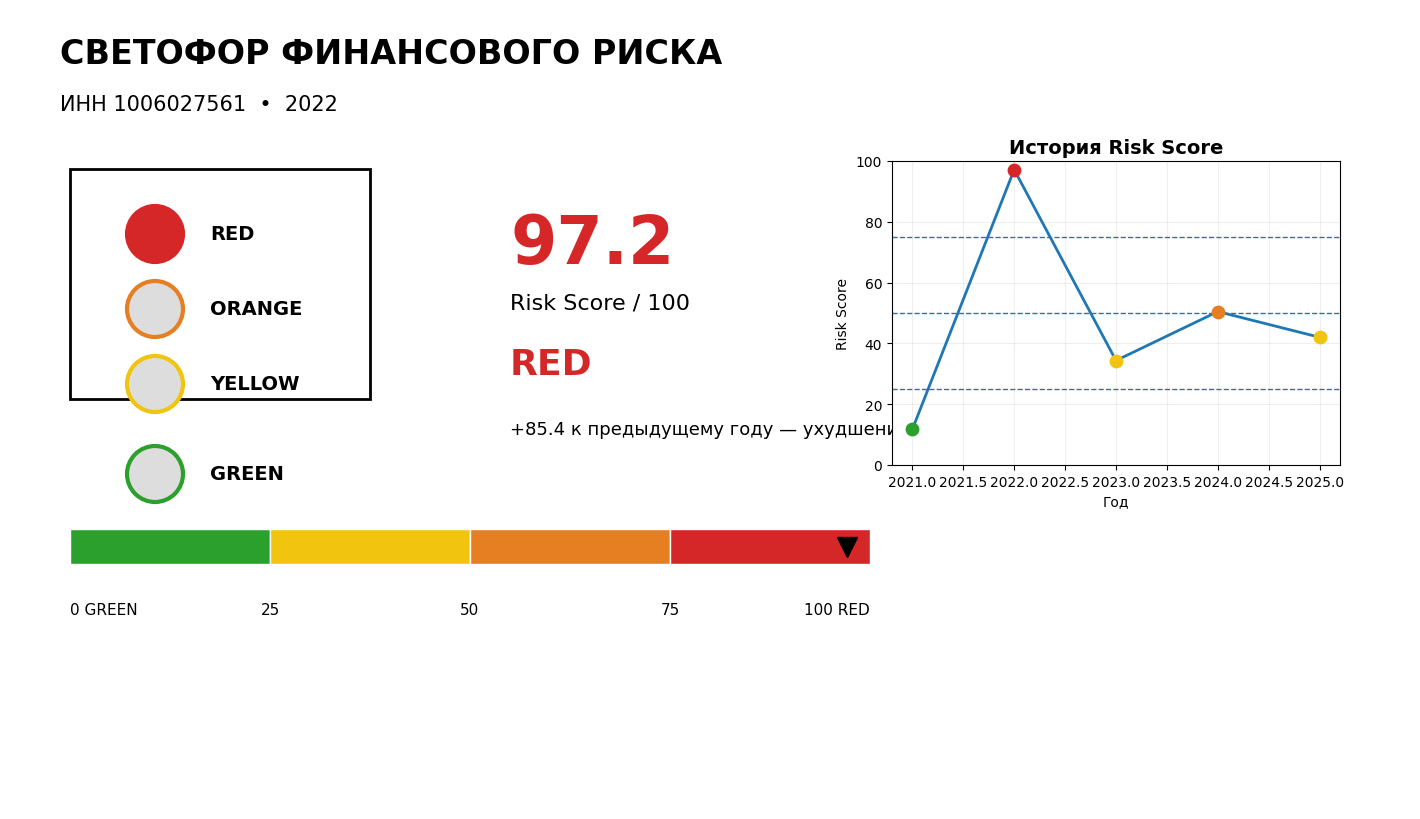

In [ ]:
# 55. ВИЗУАЛЬНАЯ КАРТОЧКА РИСКА КОМПАНИИ

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from IPython.display import display, HTML

# ---------------------------------------------------------------
# Параметры выбранного кейса
# ---------------------------------------------------------------

ИНН = "1006027561"
ГОД = 2022

# ---------------------------------------------------------------
# Получаем историю компании
# ---------------------------------------------------------------

history = (
    df_v2_final[
        df_v2_final["инн"].astype(str) == ИНН
    ]
    .sort_values("год")
    .copy()
)

target = history[
    history["год"] == ГОД
]

if target.empty:

    print(f"Для ИНН {ИНН} за {ГОД} нет рассчитанного результата.")

else:

    row = target.iloc[0]

    # Предыдущий доступный год
    previous = history[
        history["год"] < ГОД
    ].tail(1)

    if not previous.empty:
        prev = previous.iloc[0]
        delta_score = row["risk_score_v2"] - prev["risk_score_v2"]
    else:
        prev = None
        delta_score = np.nan

    # -----------------------------------------------------------
    # Цвета светофора
    # -----------------------------------------------------------

    traffic_colors = {
        "GREEN": "#2ca02c",
        "YELLOW": "#f1c40f",
        "ORANGE": "#e67e22",
        "RED": "#d62728"
    }

    color = row["risk_level_v2"]
    current_color = traffic_colors.get(color, "#808080")

    # -----------------------------------------------------------
    # 1. БОЛЬШОЙ СВЕТОФОР
    # -----------------------------------------------------------

    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_axes([0, 0, 1, 1])

    ax.set_xlim(0, 14)
    ax.set_ylim(0, 8)
    ax.axis("off")

    # Заголовок
    ax.text(
        0.5,
        7.55,
        "СВЕТОФОР ФИНАНСОВОГО РИСКА",
        fontsize=24,
        fontweight="bold",
        va="center"
    )

    ax.text(
        0.5,
        7.05,
        f"ИНН {ИНН}  •  {ГОД}",
        fontsize=15,
        va="center"
    )

    # -----------------------------------------------------------
    # Светофор
    # -----------------------------------------------------------

    ax.add_patch(
        Rectangle(
            (0.6, 4.1),
            3.0,
            2.3,
            fill=False,
            linewidth=2
        )
    )

    lights = [
        ("RED", 5.75, "#d62728"),
        ("ORANGE", 5.00, "#e67e22"),
        ("YELLOW", 4.25, "#f1c40f")
    ]

    for light_name, y, light_color in lights:

        is_active = light_name == color

        circle = Circle(
            (1.45, y),
            0.28,
            facecolor=light_color if is_active else "#dddddd",
            edgecolor=light_color,
            linewidth=3
        )

        ax.add_patch(circle)

        ax.text(
            2.0,
            y,
            light_name,
            fontsize=14,
            fontweight="bold",
            va="center"
        )

    # GREEN отдельно снизу
    circle = Circle(
        (1.45, 3.35),
        0.28,
        facecolor="#2ca02c" if color == "GREEN" else "#dddddd",
        edgecolor="#2ca02c",
        linewidth=3
    )

    ax.add_patch(circle)

    ax.text(
        2.0,
        3.35,
        "GREEN",
        fontsize=14,
        fontweight="bold",
        va="center"
    )

    # -----------------------------------------------------------
    # Score
    # -----------------------------------------------------------

    ax.text(
        5.0,
        5.65,
        f"{row['risk_score_v2']:.1f}",
        fontsize=48,
        fontweight="bold",
        color=current_color,
        va="center"
    )

    ax.text(
        5.0,
        5.0,
        "Risk Score / 100",
        fontsize=16
    )

    ax.text(
        5.0,
        4.35,
        color,
        fontsize=26,
        fontweight="bold",
        color=current_color
    )

    if pd.notna(delta_score):

        direction_text = (
            "ухудшение"
            if delta_score > 1
            else "улучшение"
            if delta_score < -1
            else "стабильно"
        )

        ax.text(
            5.0,
            3.75,
            f"{delta_score:+.1f} к предыдущему году — {direction_text}",
            fontsize=13
        )

    # -----------------------------------------------------------
    # 2. ШКАЛА 0–100
    # -----------------------------------------------------------

    bar_x = 0.6
    bar_y = 2.45
    bar_width = 8.0
    bar_height = 0.35

    segments = [
        (0, 25, "#2ca02c"),
        (25, 50, "#f1c40f"),
        (50, 75, "#e67e22"),
        (75, 100, "#d62728")
    ]

    for start, end, seg_color in segments:

        x = bar_x + bar_width * start / 100
        width = bar_width * (end - start) / 100

        ax.add_patch(
            Rectangle(
                (x, bar_y),
                width,
                bar_height,
                facecolor=seg_color,
                edgecolor="white"
            )
        )

    score_x = (
        bar_x +
        bar_width * row["risk_score_v2"] / 100
    )

    ax.plot(
        score_x,
        bar_y + bar_height / 2,
        marker="v",
        markersize=14,
        color="black"
    )

    ax.text(
        bar_x,
        1.95,
        "0 GREEN",
        fontsize=11
    )

    ax.text(
        bar_x + bar_width * 0.25,
        1.95,
        "25",
        fontsize=11,
        ha="center"
    )

    ax.text(
        bar_x + bar_width * 0.50,
        1.95,
        "50",
        fontsize=11,
        ha="center"
    )

    ax.text(
        bar_x + bar_width * 0.75,
        1.95,
        "75",
        fontsize=11,
        ha="center"
    )

    ax.text(
        bar_x + bar_width,
        1.95,
        "100 RED",
        fontsize=11,
        ha="right"
    )

    # -----------------------------------------------------------
    # 3. График истории справа
    # -----------------------------------------------------------

    ax2 = fig.add_axes([0.63, 0.43, 0.32, 0.38])

    hist = history.dropna(
        subset=["risk_score_v2"]
    )

    ax2.plot(
        hist["год"],
        hist["risk_score_v2"],
        marker="o",
        linewidth=2
    )

    # Горизонтальные границы
    ax2.axhline(25, linestyle="--", linewidth=1)
    ax2.axhline(50, linestyle="--", linewidth=1)
    ax2.axhline(75, linestyle="--", linewidth=1)

    # Цвет точек по уровню риска
    for _, h in hist.iterrows():

        point_color = traffic_colors.get(
            h["risk_level_v2"],
            "#808080"
        )

        ax2.scatter(
            h["год"],
            h["risk_score_v2"],
            s=80,
            color=point_color,
            zorder=3
        )

    ax2.set_ylim(0, 100)

    ax2.set_title(
        "История Risk Score",
        fontsize=14,
        fontweight="bold"
    )

    ax2.set_ylabel("Risk Score")
    ax2.set_xlabel("Год")

    ax2.grid(alpha=0.2)

    # -----------------------------------------------------------
    # 4. Компоненты риска
    # -----------------------------------------------------------

    components = [
        (
            "Текущее состояние",
            row["current_risk_score_100"]
        ),
        (
            "Динамика",
            row["dynamic_risk_100"]
        ),
        (
            "События",
            row["events_risk_100"]
        )
    ]

    print("\n" + "=" * 80)
    print("КОМПОНЕНТЫ РИСКА")
    print("=" * 80)

    for name, value in components:

        if pd.notna(value):
            print(f"{name:<25} {value:6.1f}")

    # -----------------------------------------------------------
    # 5. Основные причины
    # -----------------------------------------------------------

    reasons = []

    indicators = [
        (
            "Отрицательный капитал",
            "капитал"
        ),
        (
            "OCF / краткосрочные обязательства",
            "операционный_денежный_поток_к_краткосрочным_обязательствам"
        ),
        (
            "Доля обязательств в активах",
            "доля_обязательств_в_активах"
        ),
        (
            "Рентабельность по чистой прибыли",
            "рентабельность_по_чистой_прибыли"
        ),
        (
            "Покрытие процентов прибылью",
            "покрытие_процентов_прибылью"
        ),
        (
            "Текущая ликвидность",
            "текущая_ликвидность"
        ),
        (
            "Быстрая ликвидность",
            "быстрая_ликвидность"
        ),
        (
            "Долговая нагрузка к выручке",
            "долговая_нагрузка_к_выручке"
        )
    ]

    for label, column in indicators:

        value = row.get(column, np.nan)

        if pd.isna(value):
            continue

        if column == "капитал":

            if value < 0:
                reasons.append(
                    (1.0, label, value)
                )

        else:

            risk_value = row.get(
                f"risk_{column}",
                np.nan
            )

            if pd.notna(risk_value) and risk_value >= 0.75:

                reasons.append(
                    (risk_value, label, value)
                )

    reasons = sorted(
        reasons,
        key=lambda x: x[0],
        reverse=True
    )[:5]

    print("\n" + "=" * 80)
    print("ОСНОВНЫЕ ПРИЧИНЫ")
    print("=" * 80)

    for i, (risk_value, label, value) in enumerate(
        reasons,
        1
    ):

        print(
            f"{i}. {label}: "
            f"{value:.3g} "
            f"(risk signal {risk_value:.2f})"
        )

    # -----------------------------------------------------------
    # 6. Динамика
    # -----------------------------------------------------------

    print("\n" + "=" * 80)
    print("ДИНАМИКА")
    print("=" * 80)

    if prev is not None:

        dynamic_fields = [
            ("Выручка", "выручка", True),
            (
                "Прибыль до налогообложения",
                "прибыль_до_налогообложения",
                True
            ),
            (
                "Операционный денежный поток",
                "операционный_денежный_поток",
                True
            ),
            ("Капитал", "капитал", True),
            ("Денежные средства", "денежные_средства", True),
            (
                "Доля обязательств в активах",
                "доля_обязательств_в_активах",
                False
            ),
            (
                "Текущая ликвидность",
                "текущая_ликвидность",
                True
            )
        ]

        for label, column, higher_is_better in dynamic_fields:

            current = row.get(column, np.nan)
            old = prev.get(column, np.nan)

            if pd.isna(current) or pd.isna(old):
                continue

            change = current - old

            if higher_is_better:
                direction = (
                    "улучшение"
                    if change > 0
                    else "ухудшение"
                    if change < 0
                    else "без изменения"
                )
            else:
                direction = (
                    "улучшение"
                    if change < 0
                    else "ухудшение"
                    if change > 0
                    else "без изменения"
                )

            print(
                f"{label}: "
                f"{old:.3g} → {current:.3g} "
                f"({change:+.3g}) — {direction}"
            )

    plt.show()

### 56. Формирование итоговой карточки финансового риска

В этой ячейке формируется единая визуальная карточка выбранной компании и года.

Карточка содержит:
- ИНН и год оценки;
- вертикальный светофор с выделением текущего уровня риска;
- итоговый Risk Score от 0 до 100;
- изменение относительно предыдущего доступного года;
- историю Risk Score по годам;
- три основных компонента итоговой оценки;
- пять наиболее сильных текущих сигналов риска.

Карточка предназначена для представления результата анализа в компактном и понятном для бизнеса виде.

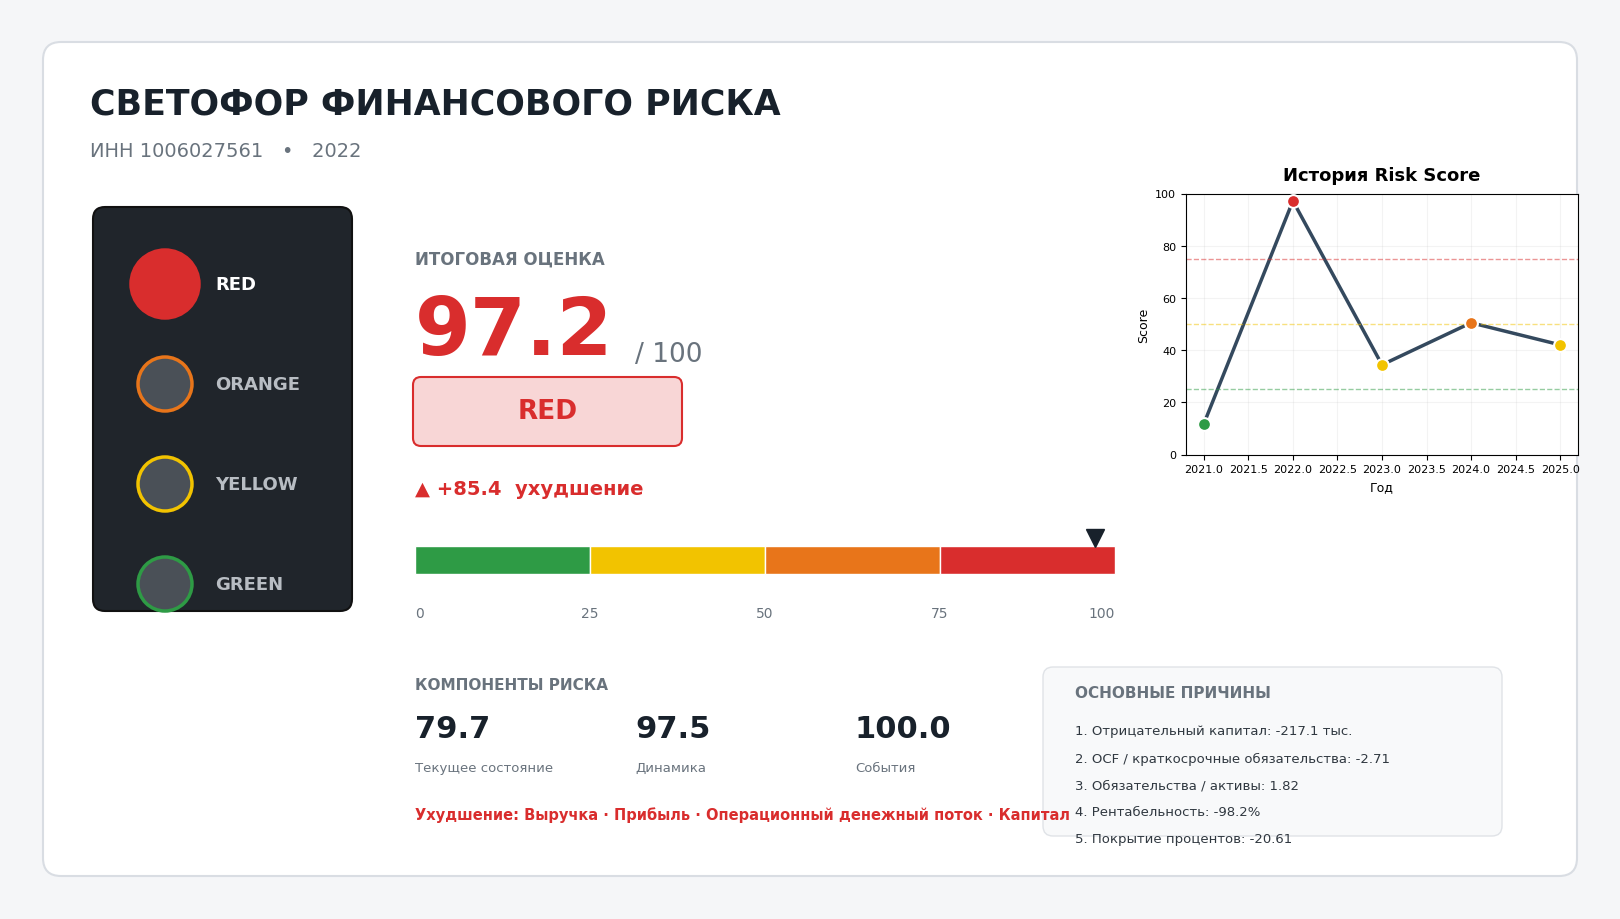

In [ ]:
# 56. ФИНАЛЬНАЯ ВИЗУАЛЬНАЯ КАРТОЧКА ФИНАНСОВОГО РИСКА

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# ===============================================================
# 1. ПАРАМЕТРЫ КОМПАНИИ
# ===============================================================

ИНН = "1006027561"
ГОД = 2022

# ===============================================================
# 2. ПОЛУЧАЕМ ДАННЫЕ
# ===============================================================

history = (
    df_v2_final[
        df_v2_final["инн"].astype(str) == ИНН
    ]
    .sort_values("год")
    .copy()
)

target = history[
    history["год"] == ГОД
]

if target.empty:

    print(f"Нет рассчитанного результата для ИНН {ИНН}, год {ГОД}")

else:

    row = target.iloc[0]

    previous = history[
        history["год"] < ГОД
    ].tail(1)

    if not previous.empty:
        prev = previous.iloc[0]
        prev_score = prev["risk_score_v2"]
        delta_score = row["risk_score_v2"] - prev_score
    else:
        prev = None
        prev_score = np.nan
        delta_score = np.nan

    score = float(row["risk_score_v2"])
    level = row["risk_level_v2"]

    # ===========================================================
    # 3. ЦВЕТА
    # ===========================================================

    COLORS = {
        "GREEN": "#2E9B45",
        "YELLOW": "#F2C300",
        "ORANGE": "#E8751A",
        "RED": "#D92D2D"
    }

    LIGHT_COLORS = {
        "GREEN": "#DCEFE1",
        "YELLOW": "#FFF4C2",
        "ORANGE": "#FCE1CC",
        "RED": "#F8D6D6"
    }

    level_color = COLORS[level]

    # ===========================================================
    # 4. НАПРАВЛЕНИЕ ИЗМЕНЕНИЯ
    # ===========================================================

    if pd.isna(delta_score):

        delta_text = "Нет предыдущего года"
        delta_color = "#666666"

    elif delta_score > 1:

        delta_text = f"▲ {delta_score:+.1f}  ухудшение"
        delta_color = "#D92D2D"

    elif delta_score < -1:

        delta_text = f"▼ {delta_score:+.1f}  улучшение"
        delta_color = "#2E9B45"

    else:

        delta_text = f"→ {delta_score:+.1f}  стабильно"
        delta_color = "#666666"

    # ===========================================================
    # 5. ФИГУРА
    # ===========================================================

    fig = plt.figure(
        figsize=(16, 9),
        facecolor="#F5F6F8"
    )

    ax = fig.add_axes(
        [0, 0, 1, 1],
        facecolor="#F5F6F8"
    )

    ax.set_xlim(0, 16)
    ax.set_ylim(0, 9)
    ax.axis("off")

    # ===========================================================
    # 6. ОСНОВНАЯ КАРТОЧКА
    # ===========================================================

    card = FancyBboxPatch(
        (0.35, 0.35),
        15.3,
        8.3,
        boxstyle="round,pad=0.02,rounding_size=0.18",
        facecolor="white",
        edgecolor="#D9DDE3",
        linewidth=1.5
    )

    ax.add_patch(card)

    # ===========================================================
    # 7. ЗАГОЛОВОК
    # ===========================================================

    ax.text(
        0.8,
        8.05,
        "СВЕТОФОР ФИНАНСОВОГО РИСКА",
        fontsize=25,
        fontweight="bold",
        color="#18212B",
        va="center"
    )

    ax.text(
        0.8,
        7.58,
        f"ИНН {ИНН}   •   {ГОД}",
        fontsize=14,
        color="#69737D",
        va="center"
    )

    # ===========================================================
    # 8. ВЕРТИКАЛЬНЫЙ СВЕТОФОР
    # ===========================================================

    traffic_box = FancyBboxPatch(
        (0.85, 3.0),
        2.55,
        4.0,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor="#20252B",
        edgecolor="#111111",
        linewidth=1.5
    )

    ax.add_patch(traffic_box)

    traffic_order = [
        ("RED", 6.25),
        ("ORANGE", 5.25),
        ("YELLOW", 4.25),
        ("GREEN", 3.25)
    ]

    for name, y in traffic_order:

        active = name == level

        if active:

            face = COLORS[name]
            radius = 0.34

        else:

            face = "#4A5057"
            radius = 0.27

        ax.add_patch(
            Circle(
                (1.55, y),
                radius,
                facecolor=face,
                edgecolor=COLORS[name],
                linewidth=2.5
            )
        )

        ax.text(
            2.05,
            y,
            name,
            fontsize=13,
            fontweight="bold",
            color="white" if active else "#B8BDC3",
            va="center"
        )

    # ===========================================================
    # 9. SCORE
    # ===========================================================

    ax.text(
        4.05,
        6.45,
        "ИТОГОВАЯ ОЦЕНКА",
        fontsize=12,
        color="#69737D",
        fontweight="bold"
    )

    ax.text(
        4.05,
        5.55,
        f"{score:.1f}",
        fontsize=58,
        fontweight="bold",
        color=level_color
    )

    ax.text(
        6.25,
        5.55,
        "/ 100",
        fontsize=19,
        color="#69737D",
        va="center"
    )

    # Статус
    ax.add_patch(
        FancyBboxPatch(
            (4.05, 4.65),
            2.65,
            0.65,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor=LIGHT_COLORS[level],
            edgecolor=level_color,
            linewidth=1.5
        )
    )

    ax.text(
        5.375,
        4.975,
        level,
        fontsize=19,
        fontweight="bold",
        color=level_color,
        ha="center",
        va="center"
    )

    # Изменение
    ax.text(
        4.05,
        4.15,
        delta_text,
        fontsize=14,
        fontweight="bold",
        color=delta_color
    )

    # ===========================================================
    # 10. ШКАЛА 0–100
    # ===========================================================

    scale_x = 4.05
    scale_y = 3.35
    scale_w = 7.0
    scale_h = 0.28

    segments = [
        (0, 25, COLORS["GREEN"]),
        (25, 50, COLORS["YELLOW"]),
        (50, 75, COLORS["ORANGE"]),
        (75, 100, COLORS["RED"])
    ]

    for start, end, c in segments:

        x = scale_x + scale_w * start / 100
        w = scale_w * (end - start) / 100

        ax.add_patch(
            Rectangle(
                (x, scale_y),
                w,
                scale_h,
                facecolor=c,
                edgecolor="white",
                linewidth=1
            )
        )

    # Маркер текущего Score
    marker_x = (
        scale_x +
        scale_w * score / 100
    )

    ax.plot(
        marker_x,
        scale_y + scale_h + 0.08,
        marker="v",
        markersize=13,
        color="#18212B"
    )

    ax.text(
        scale_x,
        2.92,
        "0",
        fontsize=10,
        color="#69737D"
    )

    ax.text(
        scale_x + scale_w * 0.25,
        2.92,
        "25",
        fontsize=10,
        color="#69737D",
        ha="center"
    )

    ax.text(
        scale_x + scale_w * 0.50,
        2.92,
        "50",
        fontsize=10,
        color="#69737D",
        ha="center"
    )

    ax.text(
        scale_x + scale_w * 0.75,
        2.92,
        "75",
        fontsize=10,
        color="#69737D",
        ha="center"
    )

    ax.text(
        scale_x + scale_w,
        2.92,
        "100",
        fontsize=10,
        color="#69737D",
        ha="right"
    )

    # ===========================================================
    # 11. ИСТОРИЯ RISK SCORE
    # ===========================================================

    hist = history.dropna(
        subset=["risk_score_v2"]
    )

    ax_chart = fig.add_axes(
        [0.735, 0.505, 0.245, 0.29]
    )

    ax_chart.set_facecolor("white")

    ax_chart.plot(
        hist["год"],
        hist["risk_score_v2"],
        linewidth=2.5,
        color="#34495E",
        zorder=2
    )

    # Границы цветов
    ax_chart.axhline(
        25,
        color=COLORS["GREEN"],
        linewidth=1,
        linestyle="--",
        alpha=0.5
    )

    ax_chart.axhline(
        50,
        color=COLORS["YELLOW"],
        linewidth=1,
        linestyle="--",
        alpha=0.5
    )

    ax_chart.axhline(
        75,
        color=COLORS["RED"],
        linewidth=1,
        linestyle="--",
        alpha=0.5
    )

    # Точки
    for _, h in hist.iterrows():

        point_color = COLORS.get(
            h["risk_level_v2"],
            "#777777"
        )

        ax_chart.scatter(
            h["год"],
            h["risk_score_v2"],
            s=85,
            color=point_color,
            edgecolor="white",
            linewidth=1.5,
            zorder=3
        )

    ax_chart.set_ylim(0, 100)

    ax_chart.set_title(
        "История Risk Score",
        fontsize=13,
        fontweight="bold",
        pad=10
    )

    ax_chart.set_xlabel(
        "Год",
        fontsize=9
    )

    ax_chart.set_ylabel(
        "Score",
        fontsize=9
    )

    ax_chart.tick_params(
        labelsize=8
    )

    ax_chart.grid(
        alpha=0.15
    )

    # ===========================================================
    # 12. КОМПОНЕНТЫ РИСКА
    # ===========================================================

    component_values = [
        (
            "Текущее состояние",
            row["current_risk_score_100"]
        ),
        (
            "Динамика",
            row["dynamic_risk_100"]
        ),
        (
            "События",
            row["events_risk_100"]
        )
    ]

    ax.text(
        4.05,
        2.20,
        "КОМПОНЕНТЫ РИСКА",
        fontsize=11,
        fontweight="bold",
        color="#69737D"
    )

    x_positions = [4.05, 6.25, 8.45]

    for x, (name, value) in zip(
        x_positions,
        component_values
    ):

        if pd.isna(value):
            value_text = "—"
        else:
            value_text = f"{value:.1f}"

        ax.text(
            x,
            1.72,
            value_text,
            fontsize=22,
            fontweight="bold",
            color="#18212B"
        )

        ax.text(
            x,
            1.38,
            name,
            fontsize=9.5,
            color="#69737D"
        )

    # ===========================================================
    # 13. ОСНОВНЫЕ ПРИЧИНЫ
    # ===========================================================

    reasons = []

    indicators = [
        (
            "Отрицательный капитал",
            "капитал",
            True
        ),
        (
            "OCF / краткосрочные обязательства",
            "операционный_денежный_поток_к_краткосрочным_обязательствам",
            False
        ),
        (
            "Обязательства / активы",
            "доля_обязательств_в_активах",
            False
        ),
        (
            "Рентабельность",
            "рентабельность_по_чистой_прибыли",
            False
        ),
        (
            "Покрытие процентов",
            "покрытие_процентов_прибылью",
            False
        ),
        (
            "Текущая ликвидность",
            "текущая_ликвидность",
            False
        ),
        (
            "Быстрая ликвидность",
            "быстрая_ликвидность",
            False
        ),
        (
            "Долг / выручка",
            "долговая_нагрузка_к_выручке",
            False
        )
    ]

    for label, column, special in indicators:

        value = row.get(
            column,
            np.nan
        )

        if pd.isna(value):
            continue

        if special:

            if value < 0:
                reasons.append(
                    (
                        1.0,
                        label,
                        value
                    )
                )

        else:

            risk_value = row.get(
                f"risk_{column}",
                np.nan
            )

            if pd.notna(risk_value):

                reasons.append(
                    (
                        risk_value,
                        label,
                        value
                    )
                )

    reasons = sorted(
        reasons,
        key=lambda x: x[0],
        reverse=True
    )[:5]

    # Блок причин
    ax.add_patch(
        FancyBboxPatch(
            (10.35, 0.75),
            4.55,
            1.65,
            boxstyle="round,pad=0.02,rounding_size=0.10",
            facecolor="#F8F9FA",
            edgecolor="#E0E3E7",
            linewidth=1
        )
    )

    ax.text(
        10.65,
        2.12,
        "ОСНОВНЫЕ ПРИЧИНЫ",
        fontsize=11,
        fontweight="bold",
        color="#69737D"
    )

    for i, (_, label, value) in enumerate(reasons):

        # Формат значения
        if abs(value) >= 1000000:
            value_text = f"{value / 1000000:.2f} млн"
        elif abs(value) >= 1000:
            value_text = f"{value / 1000:.1f} тыс."
        elif abs(value) < 1:
            value_text = f"{value:.1%}"
        else:
            value_text = f"{value:.2f}"

        ax.text(
            10.65,
            1.78 - i * 0.27,
            f"{i + 1}. {label}: {value_text}",
            fontsize=9.5,
            color="#303840",
            va="center"
        )

    # ===========================================================
    # 14. ДИНАМИКА — КОРОТКАЯ СТРОКА ВНИЗУ
    # ===========================================================

    if prev is not None:

        dynamic_summary = []

        dynamic_fields = [
            (
                "Выручка",
                "выручка",
                True
            ),
            (
                "Прибыль",
                "прибыль_до_налогообложения",
                True
            ),
            (
                "Операционный денежный поток",
                "операционный_денежный_поток",
                True
            ),
            (
                "Капитал",
                "капитал",
                True
            ),
            (
                "Ликвидность",
                "текущая_ликвидность",
                True
            )
        ]

        for label, column, higher_is_better in dynamic_fields:

            current = row.get(column, np.nan)
            old = prev.get(column, np.nan)

            if pd.isna(current) or pd.isna(old):
                continue

            change = current - old

            if higher_is_better:
                is_bad = change < 0
            else:
                is_bad = change > 0

            if is_bad:
                dynamic_summary.append(label)

        if dynamic_summary:

            summary_text = (
                "Ухудшение: "
                + " · ".join(dynamic_summary[:4])
            )

            ax.text(
                4.05,
                0.90,
                summary_text,
                fontsize=10.5,
                color="#D92D2D",
                fontweight="bold"
            )

    plt.show()

### 57. Финальная версия визуальной карточки риска

В этой ячейке формируется финальная клиентская карточка выбранной компании.

Карточка показывает итоговый цвет светофора и Risk Score, изменение относительно предыдущего года, историю оценки, компоненты риска, основные причины и ключевые изменения финансовых показателей.

Все элементы размещены в отдельных визуальных блоках, чтобы информация не пересекалась и была читаема при демонстрации результата заказчику.

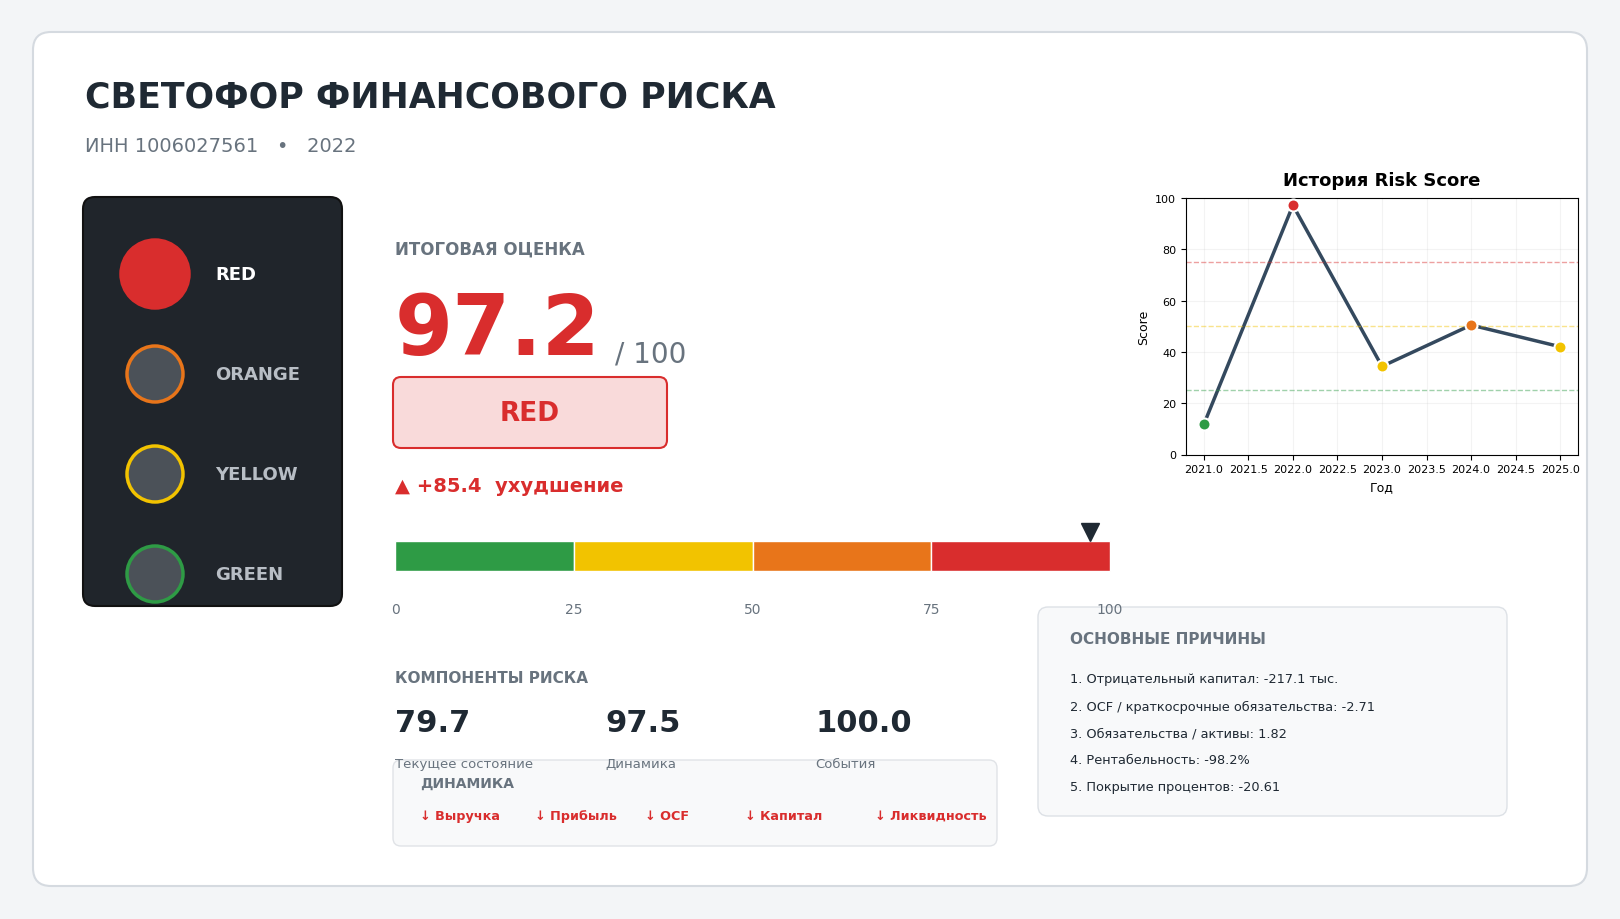

In [ ]:
# 57. ФИНАЛЬНАЯ ВИЗУАЛЬНАЯ КАРТОЧКА РИСКА

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle
import numpy as np
import pandas as pd

# ===============================================================
# 1. ПАРАМЕТРЫ КОМПАНИИ
# ===============================================================

ИНН = "1006027561"
ГОД = 2022

# ===============================================================
# 2. ДАННЫЕ
# ===============================================================

history = (
    df_v2_final[
        df_v2_final["инн"].astype(str) == ИНН
    ]
    .sort_values("год")
    .copy()
)

target = history[
    history["год"] == ГОД
]

if target.empty:

    print(f"Нет рассчитанного результата для ИНН {ИНН}, год {ГОД}")

else:

    row = target.iloc[0]

    previous = history[
        history["год"] < ГОД
    ].tail(1)

    if not previous.empty:
        prev = previous.iloc[0]
        prev_score = float(prev["risk_score_v2"])
        delta_score = float(row["risk_score_v2"]) - prev_score
    else:
        prev = None
        prev_score = np.nan
        delta_score = np.nan

    score = float(row["risk_score_v2"])
    level = row["risk_level_v2"]

    # ===========================================================
    # 3. ЦВЕТА
    # ===========================================================

    COLORS = {
        "GREEN": "#2E9B45",
        "YELLOW": "#F2C300",
        "ORANGE": "#E8751A",
        "RED": "#D92D2D"
    }

    LIGHT_COLORS = {
        "GREEN": "#E4F3E7",
        "YELLOW": "#FFF6CF",
        "ORANGE": "#FCE8D7",
        "RED": "#F9DADA"
    }

    DARK = "#1F2933"
    GREY = "#68737E"
    LIGHT_GREY = "#E5E7EB"

    level_color = COLORS[level]

    # ===========================================================
    # 4. НАПРАВЛЕНИЕ
    # ===========================================================

    if pd.isna(delta_score):
        delta_text = "Нет предыдущего года"
        delta_color = GREY

    elif delta_score > 1:
        delta_text = f"▲ {delta_score:+.1f}  ухудшение"
        delta_color = COLORS["RED"]

    elif delta_score < -1:
        delta_text = f"▼ {delta_score:+.1f}  улучшение"
        delta_color = COLORS["GREEN"]

    else:
        delta_text = f"→ {delta_score:+.1f}  стабильно"
        delta_color = GREY

    # ===========================================================
    # 5. FIGURE
    # ===========================================================

    fig = plt.figure(
        figsize=(16, 9),
        facecolor="#F3F5F7"
    )

    ax = fig.add_axes(
        [0, 0, 1, 1]
    )

    ax.set_xlim(0, 16)
    ax.set_ylim(0, 9)
    ax.axis("off")

    # ===========================================================
    # 6. ОСНОВНАЯ КАРТОЧКА
    # ===========================================================

    card = FancyBboxPatch(
        (0.25, 0.25),
        15.5,
        8.5,
        boxstyle="round,pad=0.02,rounding_size=0.18",
        facecolor="white",
        edgecolor="#D5DAE0",
        linewidth=1.5
    )

    ax.add_patch(card)

    # ===========================================================
    # 7. HEADER
    # ===========================================================

    ax.text(
        0.75,
        8.12,
        "СВЕТОФОР ФИНАНСОВОГО РИСКА",
        fontsize=25,
        fontweight="bold",
        color=DARK,
        va="center"
    )

    ax.text(
        0.75,
        7.63,
        f"ИНН {ИНН}   •   {ГОД}",
        fontsize=14,
        color=GREY,
        va="center"
    )

    # ===========================================================
    # 8. СВЕТОФОР
    # ===========================================================

    traffic_box = FancyBboxPatch(
        (0.75, 3.05),
        2.55,
        4.05,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor="#20252B",
        edgecolor="#111111",
        linewidth=1.5
    )

    ax.add_patch(traffic_box)

    traffic = [
        ("RED", 6.35),
        ("ORANGE", 5.35),
        ("YELLOW", 4.35),
        ("GREEN", 3.35)
    ]

    for name, y in traffic:

        active = name == level

        ax.add_patch(
            Circle(
                (1.45, y),
                0.34 if active else 0.28,
                facecolor=(
                    COLORS[name]
                    if active
                    else "#4B5158"
                ),
                edgecolor=COLORS[name],
                linewidth=2.5
            )
        )

        ax.text(
            2.05,
            y,
            name,
            fontsize=13,
            fontweight="bold",
            color=(
                "white"
                if active
                else "#B8BEC5"
            ),
            va="center"
        )

    # ===========================================================
    # 9. SCORE
    # ===========================================================

    ax.text(
        3.85,
        6.55,
        "ИТОГОВАЯ ОЦЕНКА",
        fontsize=12,
        fontweight="bold",
        color=GREY
    )

    ax.text(
        3.85,
        5.55,
        f"{score:.1f}",
        fontsize=60,
        fontweight="bold",
        color=level_color
    )

    ax.text(
        6.05,
        5.55,
        "/ 100",
        fontsize=20,
        color=GREY,
        va="center"
    )

    # Status
    ax.add_patch(
        FancyBboxPatch(
            (3.85, 4.63),
            2.7,
            0.67,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor=LIGHT_COLORS[level],
            edgecolor=level_color,
            linewidth=1.5
        )
    )

    ax.text(
        5.20,
        4.96,
        level,
        fontsize=19,
        fontweight="bold",
        color=level_color,
        ha="center",
        va="center"
    )

    ax.text(
        3.85,
        4.18,
        delta_text,
        fontsize=14,
        fontweight="bold",
        color=delta_color
    )

    # ===========================================================
    # 10. ШКАЛА
    # ===========================================================

    scale_x = 3.85
    scale_y = 3.38
    scale_w = 7.15
    scale_h = 0.30

    segments = [
        (0, 25, COLORS["GREEN"]),
        (25, 50, COLORS["YELLOW"]),
        (50, 75, COLORS["ORANGE"]),
        (75, 100, COLORS["RED"])
    ]

    for start, end, c in segments:

        x = scale_x + scale_w * start / 100
        width = scale_w * (end - start) / 100

        ax.add_patch(
            Rectangle(
                (x, scale_y),
                width,
                scale_h,
                facecolor=c,
                edgecolor="white",
                linewidth=1
            )
        )

    marker_x = (
        scale_x +
        scale_w * score / 100
    )

    ax.plot(
        marker_x,
        scale_y + scale_h + 0.09,
        marker="v",
        markersize=13,
        color=DARK
    )

    for value in [0, 25, 50, 75, 100]:

        x = scale_x + scale_w * value / 100

        ax.text(
            x,
            2.96,
            str(value),
            fontsize=10,
            color=GREY,
            ha="center"
        )

    # ===========================================================
    # 11. ГРАФИК ИСТОРИИ
    # ===========================================================

    hist = history.dropna(
        subset=["risk_score_v2"]
    )

    chart = fig.add_axes(
        [0.735, 0.505, 0.245, 0.285]
    )

    chart.set_facecolor("white")

    chart.plot(
        hist["год"],
        hist["risk_score_v2"],
        linewidth=2.5,
        color="#34495E",
        zorder=2
    )

    for boundary, c in [
        (25, COLORS["GREEN"]),
        (50, COLORS["YELLOW"]),
        (75, COLORS["RED"])
    ]:

        chart.axhline(
            boundary,
            color=c,
            linewidth=1,
            linestyle="--",
            alpha=0.45
        )

    for _, h in hist.iterrows():

        point_color = COLORS.get(
            h["risk_level_v2"],
            GREY
        )

        chart.scatter(
            h["год"],
            h["risk_score_v2"],
            s=75,
            color=point_color,
            edgecolor="white",
            linewidth=1.5,
            zorder=3
        )

    chart.set_ylim(0, 100)

    chart.set_title(
        "История Risk Score",
        fontsize=13,
        fontweight="bold",
        pad=9
    )

    chart.set_xlabel(
        "Год",
        fontsize=9
    )

    chart.set_ylabel(
        "Score",
        fontsize=9
    )

    chart.tick_params(
        labelsize=8
    )

    chart.grid(
        alpha=0.15
    )

    # ===========================================================
    # 12. КОМПОНЕНТЫ
    # ===========================================================

    ax.text(
        3.85,
        2.27,
        "КОМПОНЕНТЫ РИСКА",
        fontsize=11,
        fontweight="bold",
        color=GREY
    )

    components = [
        (
            "Текущее состояние",
            row["current_risk_score_100"]
        ),
        (
            "Динамика",
            row["dynamic_risk_100"]
        ),
        (
            "События",
            row["events_risk_100"]
        )
    ]

    component_x = [3.85, 5.95, 8.05]

    for x, (name, value) in zip(
        component_x,
        components
    ):

        value_text = (
            "—"
            if pd.isna(value)
            else f"{value:.1f}"
        )

        ax.text(
            x,
            1.78,
            value_text,
            fontsize=22,
            fontweight="bold",
            color=DARK
        )

        ax.text(
            x,
            1.42,
            name,
            fontsize=9.5,
            color=GREY
        )

    # ===========================================================
    # 13. ОСНОВНЫЕ ПРИЧИНЫ
    # ===========================================================

    reasons = []

    indicators = [
        (
            "Отрицательный капитал",
            "капитал",
            True
        ),
        (
            "OCF / краткосрочные обязательства",
            "операционный_денежный_поток_к_краткосрочным_обязательствам",
            False
        ),
        (
            "Обязательства / активы",
            "доля_обязательств_в_активах",
            False
        ),
        (
            "Рентабельность",
            "рентабельность_по_чистой_прибыли",
            False
        ),
        (
            "Покрытие процентов",
            "покрытие_процентов_прибылью",
            False
        ),
        (
            "Текущая ликвидность",
            "текущая_ликвидность",
            False
        ),
        (
            "Быстрая ликвидность",
            "быстрая_ликвидность",
            False
        ),
        (
            "Долг / выручка",
            "долговая_нагрузка_к_выручке",
            False
        )
    ]

    for label, column, special in indicators:

        value = row.get(
            column,
            np.nan
        )

        if pd.isna(value):
            continue

        if special:

            if value < 0:
                reasons.append(
                    (1.0, label, value)
                )

        else:

            risk_value = row.get(
                f"risk_{column}",
                np.nan
            )

            if pd.notna(risk_value):
                reasons.append(
                    (risk_value, label, value)
                )

    reasons = sorted(
        reasons,
        key=lambda x: x[0],
        reverse=True
    )[:5]

    # Панель причин
    ax.add_patch(
        FancyBboxPatch(
            (10.30, 0.95),
            4.65,
            2.05,
            boxstyle="round,pad=0.02,rounding_size=0.10",
            facecolor="#F8F9FA",
            edgecolor="#DDE1E6",
            linewidth=1
        )
    )

    ax.text(
        10.60,
        2.66,
        "ОСНОВНЫЕ ПРИЧИНЫ",
        fontsize=11,
        fontweight="bold",
        color=GREY
    )

    for i, (_, label, value) in enumerate(reasons):

        if abs(value) >= 1_000_000:
            value_text = f"{value / 1_000_000:.2f} млн"

        elif abs(value) >= 1_000:
            value_text = f"{value / 1_000:.1f} тыс."

        elif abs(value) < 1:
            value_text = f"{value:.1%}"

        else:
            value_text = f"{value:.2f}"

        ax.text(
            10.60,
            2.30 - i * 0.27,
            f"{i + 1}. {label}: {value_text}",
            fontsize=9.3,
            color=DARK,
            va="center"
        )

    # ===========================================================
    # 14. ДИНАМИКА — ОТДЕЛЬНЫЙ БЛОК
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (3.85, 0.65),
            6.00,
            0.82,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor="#F8F9FA",
            edgecolor="#E0E3E7",
            linewidth=1
        )
    )

    ax.text(
        4.10,
        1.22,
        "ДИНАМИКА",
        fontsize=10,
        fontweight="bold",
        color=GREY
    )

    dynamic_items = []

    if prev is not None:

        fields = [
            (
                "Выручка",
                "выручка",
                True
            ),
            (
                "Прибыль",
                "прибыль_до_налогообложения",
                True
            ),
            (
                "OCF",
                "операционный_денежный_поток",
                True
            ),
            (
                "Капитал",
                "капитал",
                True
            ),
            (
                "Ликвидность",
                "текущая_ликвидность",
                True
            )
        ]

        for label, column, higher_is_better in fields:

            current = row.get(column, np.nan)
            old = prev.get(column, np.nan)

            if pd.isna(current) or pd.isna(old):
                continue

            change = current - old

            if higher_is_better:
                bad = change < 0
            else:
                bad = change > 0

            if bad:
                symbol = "↓"
                item_color = COLORS["RED"]
            elif change > 0:
                symbol = "↑"
                item_color = COLORS["GREEN"]
            else:
                symbol = "→"
                item_color = GREY

            dynamic_items.append(
                (label, symbol, item_color)
            )

    # Размещаем динамику двумя строками,
    # чтобы текст гарантированно не пересекался с соседними блоками.

    for i, (label, symbol, item_color) in enumerate(
        dynamic_items[:5]
    ):

        x_positions = [4.10, 5.25, 6.35, 7.35, 8.65]

        ax.text(
            x_positions[i],
            0.90,
            f"{symbol} {label}",
            fontsize=9.2,
            fontweight="bold",
            color=item_color,
            ha="left"
        )

    # ===========================================================
    # 15. ПОКАЗ
    # ===========================================================

    plt.show()

### 58. Визуальная карточка компании 1655141117 за 2022 год

В этой ячейке формируется визуальная карточка второго выбранного кейса — компании с ИНН 1655141117 за 2022 год.

Карточка показывает итоговый цвет и Risk Score, изменение относительно предыдущего года, историю Risk Score, компоненты оценки, основные причины текущего состояния и ключевые направления динамики.

Кейс выбран для проверки сценария резкого улучшения: переход из RED в GREEN.

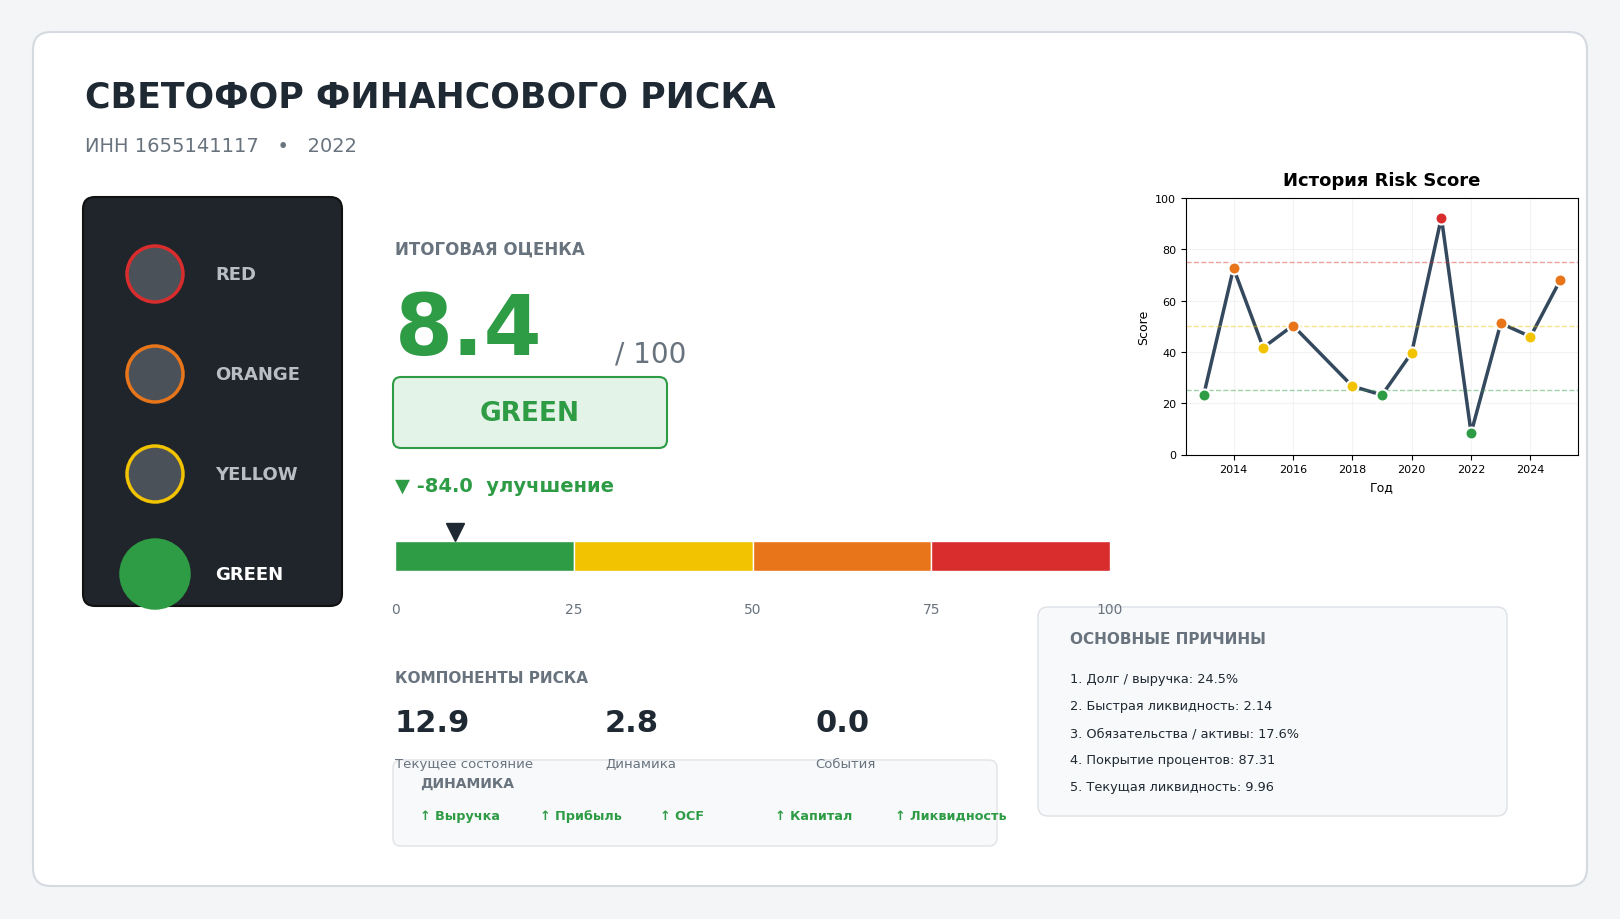

In [ ]:
# 58. ВИЗУАЛЬНАЯ КАРТОЧКА — ИНН 1655141117, 2022

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle
import numpy as np
import pandas as pd

# ===============================================================
# 1. ПАРАМЕТРЫ КОМПАНИИ
# ===============================================================

ИНН = "1655141117"
ГОД = 2022

# ===============================================================
# 2. ПОЛУЧАЕМ ИСТОРИЮ
# ===============================================================

history = (
    df_v2_final[
        df_v2_final["инн"].astype(str) == ИНН
    ]
    .sort_values("год")
    .copy()
)

target = history[history["год"] == ГОД]

if target.empty:

    print(f"Нет рассчитанного результата для ИНН {ИНН}, год {ГОД}")

else:

    row = target.iloc[0]

    previous = history[
        history["год"] < ГОД
    ].tail(1)

    if not previous.empty:
        prev = previous.iloc[0]
        prev_score = float(prev["risk_score_v2"])
        delta_score = float(row["risk_score_v2"]) - prev_score
    else:
        prev = None
        prev_score = np.nan
        delta_score = np.nan

    score = float(row["risk_score_v2"])
    level = row["risk_level_v2"]

    # ===========================================================
    # 3. ЦВЕТА
    # ===========================================================

    COLORS = {
        "GREEN": "#2E9B45",
        "YELLOW": "#F2C300",
        "ORANGE": "#E8751A",
        "RED": "#D92D2D"
    }

    LIGHT_COLORS = {
        "GREEN": "#E4F3E7",
        "YELLOW": "#FFF6CF",
        "ORANGE": "#FCE8D7",
        "RED": "#F9DADA"
    }

    DARK = "#1F2933"
    GREY = "#68737E"

    level_color = COLORS[level]

    # ===========================================================
    # 4. ИЗМЕНЕНИЕ SCORE
    # ===========================================================

    if pd.isna(delta_score):
        delta_text = "Нет предыдущего года"
        delta_color = GREY

    elif delta_score > 1:
        delta_text = f"▲ {delta_score:+.1f}  ухудшение"
        delta_color = COLORS["RED"]

    elif delta_score < -1:
        delta_text = f"▼ {delta_score:+.1f}  улучшение"
        delta_color = COLORS["GREEN"]

    else:
        delta_text = f"→ {delta_score:+.1f}  стабильно"
        delta_color = GREY

    # ===========================================================
    # 5. ОСНОВНАЯ ФИГУРА
    # ===========================================================

    fig = plt.figure(
        figsize=(16, 9),
        facecolor="#F3F5F7"
    )

    ax = fig.add_axes([0, 0, 1, 1])

    ax.set_xlim(0, 16)
    ax.set_ylim(0, 9)
    ax.axis("off")

    # Основная карточка
    ax.add_patch(
        FancyBboxPatch(
            (0.25, 0.25),
            15.5,
            8.5,
            boxstyle="round,pad=0.02,rounding_size=0.18",
            facecolor="white",
            edgecolor="#D5DAE0",
            linewidth=1.5
        )
    )

    # ===========================================================
    # 6. ЗАГОЛОВОК
    # ===========================================================

    ax.text(
        0.75,
        8.12,
        "СВЕТОФОР ФИНАНСОВОГО РИСКА",
        fontsize=25,
        fontweight="bold",
        color=DARK,
        va="center"
    )

    ax.text(
        0.75,
        7.63,
        f"ИНН {ИНН}   •   {ГОД}",
        fontsize=14,
        color=GREY,
        va="center"
    )

    # ===========================================================
    # 7. СВЕТОФОР
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (0.75, 3.05),
            2.55,
            4.05,
            boxstyle="round,pad=0.02,rounding_size=0.12",
            facecolor="#20252B",
            edgecolor="#111111",
            linewidth=1.5
        )
    )

    traffic = [
        ("RED", 6.35),
        ("ORANGE", 5.35),
        ("YELLOW", 4.35),
        ("GREEN", 3.35)
    ]

    for name, y in traffic:

        active = name == level

        ax.add_patch(
            Circle(
                (1.45, y),
                0.34 if active else 0.28,
                facecolor=(
                    COLORS[name]
                    if active
                    else "#4B5158"
                ),
                edgecolor=COLORS[name],
                linewidth=2.5
            )
        )

        ax.text(
            2.05,
            y,
            name,
            fontsize=13,
            fontweight="bold",
            color="white" if active else "#B8BEC5",
            va="center"
        )

    # ===========================================================
    # 8. SCORE
    # ===========================================================

    ax.text(
        3.85,
        6.55,
        "ИТОГОВАЯ ОЦЕНКА",
        fontsize=12,
        fontweight="bold",
        color=GREY
    )

    ax.text(
        3.85,
        5.55,
        f"{score:.1f}",
        fontsize=60,
        fontweight="bold",
        color=level_color
    )

    ax.text(
        6.05,
        5.55,
        "/ 100",
        fontsize=20,
        color=GREY,
        va="center"
    )

    ax.add_patch(
        FancyBboxPatch(
            (3.85, 4.63),
            2.7,
            0.67,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor=LIGHT_COLORS[level],
            edgecolor=level_color,
            linewidth=1.5
        )
    )

    ax.text(
        5.20,
        4.96,
        level,
        fontsize=19,
        fontweight="bold",
        color=level_color,
        ha="center",
        va="center"
    )

    ax.text(
        3.85,
        4.18,
        delta_text,
        fontsize=14,
        fontweight="bold",
        color=delta_color
    )

    # ===========================================================
    # 9. ШКАЛА 0–100
    # ===========================================================

    scale_x = 3.85
    scale_y = 3.38
    scale_w = 7.15
    scale_h = 0.30

    for start, end, c in [
        (0, 25, COLORS["GREEN"]),
        (25, 50, COLORS["YELLOW"]),
        (50, 75, COLORS["ORANGE"]),
        (75, 100, COLORS["RED"])
    ]:

        ax.add_patch(
            Rectangle(
                (
                    scale_x + scale_w * start / 100,
                    scale_y
                ),
                scale_w * (end - start) / 100,
                scale_h,
                facecolor=c,
                edgecolor="white",
                linewidth=1
            )
        )

    marker_x = scale_x + scale_w * score / 100

    ax.plot(
        marker_x,
        scale_y + scale_h + 0.09,
        marker="v",
        markersize=13,
        color=DARK
    )

    for value in [0, 25, 50, 75, 100]:

        ax.text(
            scale_x + scale_w * value / 100,
            2.96,
            str(value),
            fontsize=10,
            color=GREY,
            ha="center"
        )

    # ===========================================================
    # 10. ИСТОРИЯ SCORE
    # ===========================================================

    hist = history.dropna(
        subset=["risk_score_v2"]
    )

    chart = fig.add_axes(
        [0.735, 0.505, 0.245, 0.285]
    )

    chart.set_facecolor("white")

    chart.plot(
        hist["год"],
        hist["risk_score_v2"],
        linewidth=2.5,
        color="#34495E"
    )

    for boundary, c in [
        (25, COLORS["GREEN"]),
        (50, COLORS["YELLOW"]),
        (75, COLORS["RED"])
    ]:

        chart.axhline(
            boundary,
            color=c,
            linewidth=1,
            linestyle="--",
            alpha=0.45
        )

    for _, h in hist.iterrows():

        point_color = COLORS.get(
            h["risk_level_v2"],
            GREY
        )

        chart.scatter(
            h["год"],
            h["risk_score_v2"],
            s=75,
            color=point_color,
            edgecolor="white",
            linewidth=1.5,
            zorder=3
        )

    chart.set_ylim(0, 100)

    chart.set_title(
        "История Risk Score",
        fontsize=13,
        fontweight="bold",
        pad=9
    )

    chart.set_xlabel(
        "Год",
        fontsize=9
    )

    chart.set_ylabel(
        "Score",
        fontsize=9
    )

    chart.tick_params(
        labelsize=8
    )

    chart.grid(alpha=0.15)

    # ===========================================================
    # 11. КОМПОНЕНТЫ РИСКА
    # ===========================================================

    ax.text(
        3.85,
        2.27,
        "КОМПОНЕНТЫ РИСКА",
        fontsize=11,
        fontweight="bold",
        color=GREY
    )

    components = [
        (
            "Текущее состояние",
            row["current_risk_score_100"]
        ),
        (
            "Динамика",
            row["dynamic_risk_100"]
        ),
        (
            "События",
            row["events_risk_100"]
        )
    ]

    for x, (name, value) in zip(
        [3.85, 5.95, 8.05],
        components
    ):

        value_text = (
            "—"
            if pd.isna(value)
            else f"{value:.1f}"
        )

        ax.text(
            x,
            1.78,
            value_text,
            fontsize=22,
            fontweight="bold",
            color=DARK
        )

        ax.text(
            x,
            1.42,
            name,
            fontsize=9.5,
            color=GREY
        )

    # ===========================================================
    # 12. ОСНОВНЫЕ ПРИЧИНЫ
    # ===========================================================

    reasons = []

    indicators = [
        (
            "Отрицательный капитал",
            "капитал",
            True
        ),
        (
            "OCF / краткосрочные обязательства",
            "операционный_денежный_поток_к_краткосрочным_обязательствам",
            False
        ),
        (
            "Обязательства / активы",
            "доля_обязательств_в_активах",
            False
        ),
        (
            "Рентабельность",
            "рентабельность_по_чистой_прибыли",
            False
        ),
        (
            "Покрытие процентов",
            "покрытие_процентов_прибылью",
            False
        ),
        (
            "Текущая ликвидность",
            "текущая_ликвидность",
            False
        ),
        (
            "Быстрая ликвидность",
            "быстрая_ликвидность",
            False
        ),
        (
            "Долг / выручка",
            "долговая_нагрузка_к_выручке",
            False
        )
    ]

    for label, column, special in indicators:

        value = row.get(column, np.nan)

        if pd.isna(value):
            continue

        if special:

            if value < 0:
                reasons.append(
                    (1.0, label, value)
                )

        else:

            risk_value = row.get(
                f"risk_{column}",
                np.nan
            )

            if pd.notna(risk_value):
                reasons.append(
                    (risk_value, label, value)
                )

    reasons = sorted(
        reasons,
        key=lambda x: x[0],
        reverse=True
    )[:5]

    ax.add_patch(
        FancyBboxPatch(
            (10.30, 0.95),
            4.65,
            2.05,
            boxstyle="round,pad=0.02,rounding_size=0.10",
            facecolor="#F8F9FA",
            edgecolor="#DDE1E6",
            linewidth=1
        )
    )

    ax.text(
        10.60,
        2.66,
        "ОСНОВНЫЕ ПРИЧИНЫ",
        fontsize=11,
        fontweight="bold",
        color=GREY
    )

    for i, (_, label, value) in enumerate(reasons):

        if abs(value) >= 1_000_000:
            value_text = f"{value / 1_000_000:.2f} млн"
        elif abs(value) >= 1_000:
            value_text = f"{value / 1_000:.1f} тыс."
        elif abs(value) < 1:
            value_text = f"{value:.1%}"
        else:
            value_text = f"{value:.2f}"

        ax.text(
            10.60,
            2.30 - i * 0.27,
            f"{i + 1}. {label}: {value_text}",
            fontsize=9.3,
            color=DARK,
            va="center"
        )

    # ===========================================================
    # 13. ДИНАМИКА
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (3.85, 0.65),
            6.00,
            0.82,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor="#F8F9FA",
            edgecolor="#E0E3E7",
            linewidth=1
        )
    )

    ax.text(
        4.10,
        1.22,
        "ДИНАМИКА",
        fontsize=10,
        fontweight="bold",
        color=GREY
    )

    dynamic_items = []

    if prev is not None:

        fields = [
            ("Выручка", "выручка", True),
            (
                "Прибыль",
                "прибыль_до_налогообложения",
                True
            ),
            (
                "OCF",
                "операционный_денежный_поток",
                True
            ),
            ("Капитал", "капитал", True),
            (
                "Ликвидность",
                "текущая_ликвидность",
                True
            )
        ]

        for label, column, higher_is_better in fields:

            current = row.get(column, np.nan)
            old = prev.get(column, np.nan)

            if pd.isna(current) or pd.isna(old):
                continue

            change = current - old

            if higher_is_better:
                bad = change < 0
            else:
                bad = change > 0

            if bad:
                symbol = "↓"
                item_color = COLORS["RED"]
            elif change > 0:
                symbol = "↑"
                item_color = COLORS["GREEN"]
            else:
                symbol = "→"
                item_color = GREY

            dynamic_items.append(
                (label, symbol, item_color)
            )

    x_positions = [
        4.10,
        5.30,
        6.50,
        7.65,
        8.85
    ]

    for i, (label, symbol, item_color) in enumerate(
        dynamic_items[:5]
    ):

        ax.text(
            x_positions[i],
            0.90,
            f"{symbol} {label}",
            fontsize=9.2,
            fontweight="bold",
            color=item_color,
            ha="left"
        )

    # ===========================================================
    # 14. ПОКАЗ
    # ===========================================================

    plt.show()

### 59. Исправленная карточка компании с отсечкой по выбранному году

В этой ячейке обновляется визуальная карточка компании.

История Risk Score ограничивается выбранным годом: если оценка строится на 2022 год, на карточке не показываются 2023–2025.

Динамика рассчитывается только относительно предыдущего доступного года.

Название и содержание блока факторов адаптируются к уровню риска: для ORANGE/RED показываются основные факторы риска, для GREEN/YELLOW — ключевые факторы текущего состояния.

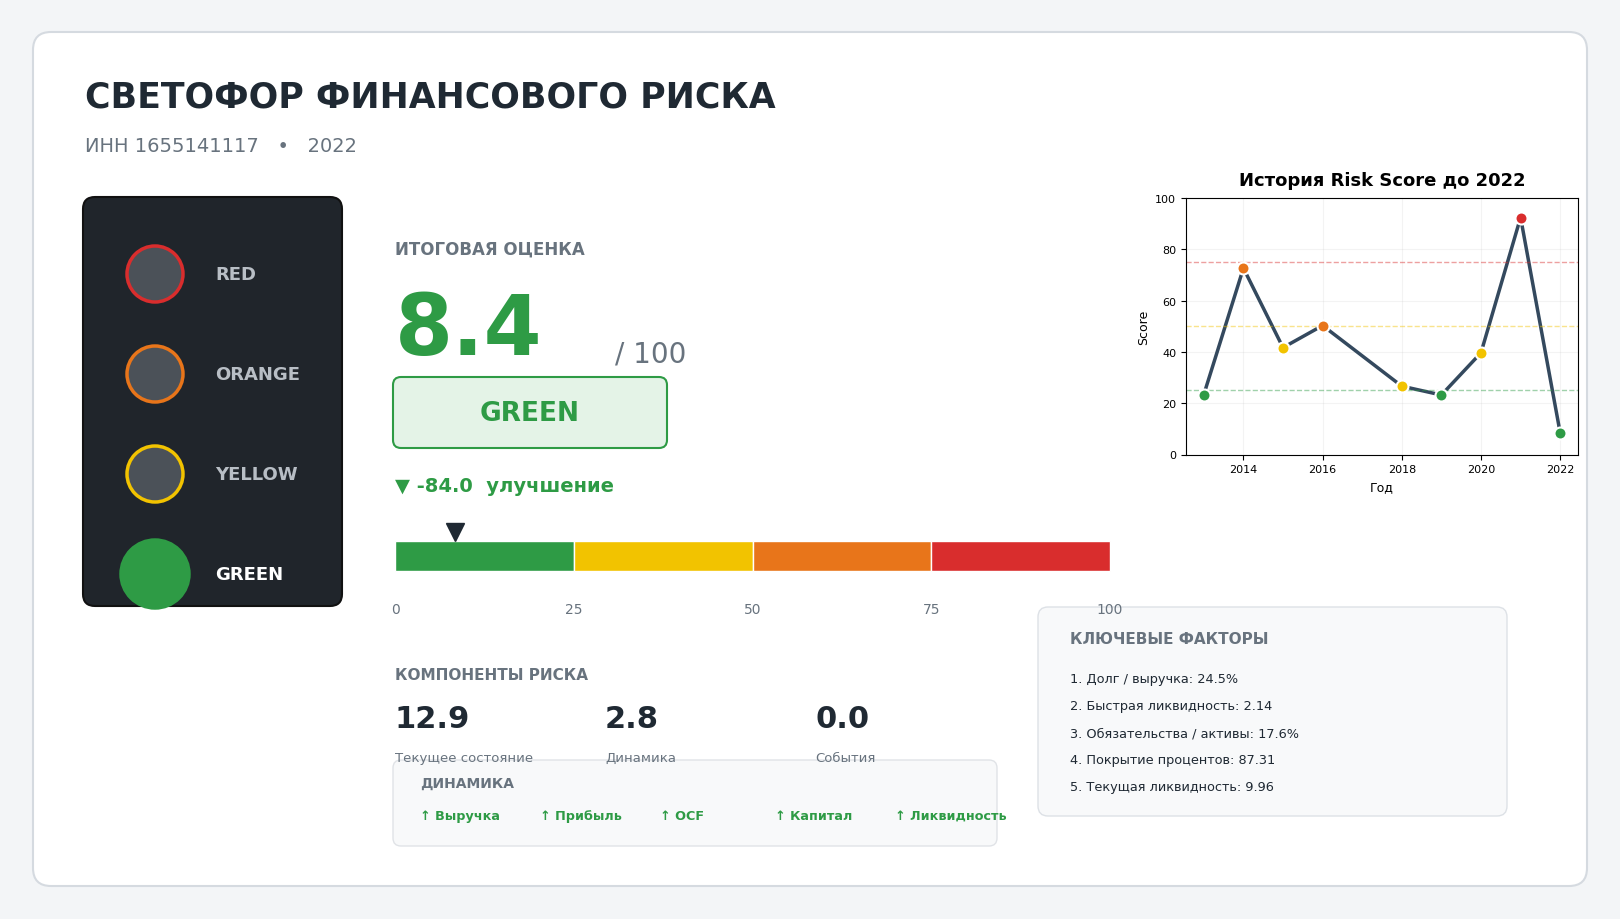

In [ ]:
# 59. ИСПРАВЛЕННАЯ ВИЗУАЛЬНАЯ КАРТОЧКА
# История ограничена выбранным годом

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle
import numpy as np
import pandas as pd

# ===============================================================
# 1. ПАРАМЕТРЫ КОМПАНИИ
# ===============================================================

ИНН = "1655141117"
ГОД = 2022

# ===============================================================
# 2. ИСТОРИЯ ТОЛЬКО ДО ВЫБРАННОГО ГОДА
# ===============================================================

history = (
    df_v2_final[
        (df_v2_final["инн"].astype(str) == ИНН) &
        (df_v2_final["год"] <= ГОД)
    ]
    .sort_values("год")
    .copy()
)

target = history[history["год"] == ГОД]

if target.empty:

    print(f"Нет рассчитанного результата для ИНН {ИНН}, год {ГОД}")

else:

    row = target.iloc[0]

    # Предыдущий доступный год
    previous = history[
        history["год"] < ГОД
    ].tail(1)

    if not previous.empty:
        prev = previous.iloc[0]
        prev_score = float(prev["risk_score_v2"])
        delta_score = float(row["risk_score_v2"]) - prev_score
    else:
        prev = None
        prev_score = np.nan
        delta_score = np.nan

    score = float(row["risk_score_v2"])
    level = row["risk_level_v2"]

    # ===========================================================
    # 3. ЦВЕТА
    # ===========================================================

    COLORS = {
        "GREEN": "#2E9B45",
        "YELLOW": "#F2C300",
        "ORANGE": "#E8751A",
        "RED": "#D92D2D"
    }

    LIGHT_COLORS = {
        "GREEN": "#E4F3E7",
        "YELLOW": "#FFF6CF",
        "ORANGE": "#FCE8D7",
        "RED": "#F9DADA"
    }

    DARK = "#1F2933"
    GREY = "#68737E"

    level_color = COLORS[level]

    # ===========================================================
    # 4. ИЗМЕНЕНИЕ SCORE
    # ===========================================================

    if pd.isna(delta_score):

        delta_text = "Нет предыдущего года"
        delta_color = GREY

    elif delta_score > 1:

        delta_text = f"▲ {delta_score:+.1f}  ухудшение"
        delta_color = COLORS["RED"]

    elif delta_score < -1:

        delta_text = f"▼ {delta_score:+.1f}  улучшение"
        delta_color = COLORS["GREEN"]

    else:

        delta_text = f"→ {delta_score:+.1f}  стабильно"
        delta_color = GREY

    # ===========================================================
    # 5. ФИГУРА
    # ===========================================================

    fig = plt.figure(
        figsize=(16, 9),
        facecolor="#F3F5F7"
    )

    ax = fig.add_axes([0, 0, 1, 1])

    ax.set_xlim(0, 16)
    ax.set_ylim(0, 9)
    ax.axis("off")

    # Основная карточка
    ax.add_patch(
        FancyBboxPatch(
            (0.25, 0.25),
            15.5,
            8.5,
            boxstyle="round,pad=0.02,rounding_size=0.18",
            facecolor="white",
            edgecolor="#D5DAE0",
            linewidth=1.5
        )
    )

    # ===========================================================
    # 6. ЗАГОЛОВОК
    # ===========================================================

    ax.text(
        0.75,
        8.12,
        "СВЕТОФОР ФИНАНСОВОГО РИСКА",
        fontsize=25,
        fontweight="bold",
        color=DARK,
        va="center"
    )

    ax.text(
        0.75,
        7.63,
        f"ИНН {ИНН}   •   {ГОД}",
        fontsize=14,
        color=GREY,
        va="center"
    )

    # ===========================================================
    # 7. СВЕТОФОР
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (0.75, 3.05),
            2.55,
            4.05,
            boxstyle="round,pad=0.02,rounding_size=0.12",
            facecolor="#20252B",
            edgecolor="#111111",
            linewidth=1.5
        )
    )

    traffic = [
        ("RED", 6.35),
        ("ORANGE", 5.35),
        ("YELLOW", 4.35),
        ("GREEN", 3.35)
    ]

    for name, y in traffic:

        active = name == level

        ax.add_patch(
            Circle(
                (1.45, y),
                0.34 if active else 0.28,
                facecolor=(
                    COLORS[name]
                    if active
                    else "#4B5158"
                ),
                edgecolor=COLORS[name],
                linewidth=2.5
            )
        )

        ax.text(
            2.05,
            y,
            name,
            fontsize=13,
            fontweight="bold",
            color="white" if active else "#B8BEC5",
            va="center"
        )

    # ===========================================================
    # 8. ИТОГОВЫЙ SCORE
    # ===========================================================

    ax.text(
        3.85,
        6.55,
        "ИТОГОВАЯ ОЦЕНКА",
        fontsize=12,
        fontweight="bold",
        color=GREY
    )

    ax.text(
        3.85,
        5.55,
        f"{score:.1f}",
        fontsize=60,
        fontweight="bold",
        color=level_color
    )

    ax.text(
        6.05,
        5.55,
        "/ 100",
        fontsize=20,
        color=GREY,
        va="center"
    )

    ax.add_patch(
        FancyBboxPatch(
            (3.85, 4.63),
            2.7,
            0.67,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor=LIGHT_COLORS[level],
            edgecolor=level_color,
            linewidth=1.5
        )
    )

    ax.text(
        5.20,
        4.96,
        level,
        fontsize=19,
        fontweight="bold",
        color=level_color,
        ha="center",
        va="center"
    )

    ax.text(
        3.85,
        4.18,
        delta_text,
        fontsize=14,
        fontweight="bold",
        color=delta_color
    )

    # ===========================================================
    # 9. ШКАЛА 0–100
    # ===========================================================

    scale_x = 3.85
    scale_y = 3.38
    scale_w = 7.15
    scale_h = 0.30

    for start, end, c in [
        (0, 25, COLORS["GREEN"]),
        (25, 50, COLORS["YELLOW"]),
        (50, 75, COLORS["ORANGE"]),
        (75, 100, COLORS["RED"])
    ]:

        ax.add_patch(
            Rectangle(
                (
                    scale_x + scale_w * start / 100,
                    scale_y
                ),
                scale_w * (end - start) / 100,
                scale_h,
                facecolor=c,
                edgecolor="white",
                linewidth=1
            )
        )

    marker_x = scale_x + scale_w * score / 100

    ax.plot(
        marker_x,
        scale_y + scale_h + 0.09,
        marker="v",
        markersize=13,
        color=DARK
    )

    for value in [0, 25, 50, 75, 100]:

        ax.text(
            scale_x + scale_w * value / 100,
            2.96,
            str(value),
            fontsize=10,
            color=GREY,
            ha="center"
        )

    # ===========================================================
    # 10. ИСТОРИЯ SCORE — ТОЛЬКО ДО ВЫБРАННОГО ГОДА
    # ===========================================================

    hist = history.dropna(
        subset=["risk_score_v2"]
    ).copy()

    chart = fig.add_axes(
        [0.735, 0.505, 0.245, 0.285]
    )

    chart.set_facecolor("white")

    chart.plot(
        hist["год"],
        hist["risk_score_v2"],
        linewidth=2.5,
        color="#34495E"
    )

    for boundary, c in [
        (25, COLORS["GREEN"]),
        (50, COLORS["YELLOW"]),
        (75, COLORS["RED"])
    ]:

        chart.axhline(
            boundary,
            color=c,
            linewidth=1,
            linestyle="--",
            alpha=0.45
        )

    for _, h in hist.iterrows():

        point_color = COLORS.get(
            h["risk_level_v2"],
            GREY
        )

        chart.scatter(
            h["год"],
            h["risk_score_v2"],
            s=75,
            color=point_color,
            edgecolor="white",
            linewidth=1.5,
            zorder=3
        )

    chart.set_ylim(0, 100)

    chart.set_title(
        f"История Risk Score до {ГОД}",
        fontsize=13,
        fontweight="bold",
        pad=9
    )

    chart.set_xlabel(
        "Год",
        fontsize=9
    )

    chart.set_ylabel(
        "Score",
        fontsize=9
    )

    chart.tick_params(
        labelsize=8
    )

    chart.grid(alpha=0.15)

    # ===========================================================
    # 11. КОМПОНЕНТЫ РИСКА
    # ===========================================================

    ax.text(
        3.85,
        2.30,
        "КОМПОНЕНТЫ РИСКА",
        fontsize=11,
        fontweight="bold",
        color=GREY
    )

    components = [
        (
            "Текущее состояние",
            row["current_risk_score_100"]
        ),
        (
            "Динамика",
            row["dynamic_risk_100"]
        ),
        (
            "События",
            row["events_risk_100"]
        )
    ]

    for x, (name, value) in zip(
        [3.85, 5.95, 8.05],
        components
    ):

        value_text = (
            "—"
            if pd.isna(value)
            else f"{value:.1f}"
        )

        ax.text(
            x,
            1.82,
            value_text,
            fontsize=22,
            fontweight="bold",
            color=DARK
        )

        ax.text(
            x,
            1.48,
            name,
            fontsize=9.5,
            color=GREY
        )

    # ===========================================================
    # 12. КЛЮЧЕВЫЕ ФАКТОРЫ / ФАКТОРЫ РИСКА
    # ===========================================================

    if level in ["ORANGE", "RED"]:
        factors_title = "ОСНОВНЫЕ ФАКТОРЫ РИСКА"
    else:
        factors_title = "КЛЮЧЕВЫЕ ФАКТОРЫ"

    # Берём показатели по их НОРМАЛИЗОВАННОМУ risk-сигналу,
    # а не по абсолютному значению показателя.

    factor_definitions = [
        (
            "Долг / выручка",
            "долговая_нагрузка_к_выручке"
        ),
        (
            "Быстрая ликвидность",
            "быстрая_ликвидность"
        ),
        (
            "Обязательства / активы",
            "доля_обязательств_в_активах"
        ),
        (
            "Покрытие процентов",
            "покрытие_процентов_прибылью"
        ),
        (
            "Текущая ликвидность",
            "текущая_ликвидность"
        ),
        (
            "OCF / краткосрочные обязательства",
            "операционный_денежный_поток_к_краткосрочным_обязательствам"
        ),
        (
            "OCF / обязательства",
            "операционный_денежный_поток_к_обязательствам"
        ),
        (
            "Рентабельность",
            "рентабельность_по_чистой_прибыли"
        )
    ]

    factors = []

    for label, column in factor_definitions:

        value = row.get(column, np.nan)
        risk_value = row.get(
            f"risk_{column}",
            np.nan
        )

        if pd.isna(value) or pd.isna(risk_value):
            continue

        factors.append(
            (
                float(risk_value),
                label,
                float(value)
            )
        )

    # Для GREEN/YELLOW показываем факторы,
    # которые имеют наибольший риск-сигнал.
    # Это не означает, что они являются "причинами риска".

    factors = sorted(
        factors,
        key=lambda x: x[0],
        reverse=True
    )[:5]

    ax.add_patch(
        FancyBboxPatch(
            (10.30, 0.95),
            4.65,
            2.05,
            boxstyle="round,pad=0.02,rounding_size=0.10",
            facecolor="#F8F9FA",
            edgecolor="#DDE1E6",
            linewidth=1
        )
    )

    ax.text(
        10.60,
        2.66,
        factors_title,
        fontsize=11,
        fontweight="bold",
        color=GREY
    )

    for i, (risk_value, label, value) in enumerate(factors):

        if abs(value) >= 1_000_000:
            value_text = f"{value / 1_000_000:.2f} млн"

        elif abs(value) >= 1_000:
            value_text = f"{value / 1_000:.1f} тыс."

        elif abs(value) < 1:
            value_text = f"{value:.1%}"

        else:
            value_text = f"{value:.2f}"

        ax.text(
            10.60,
            2.30 - i * 0.27,
            f"{i + 1}. {label}: {value_text}",
            fontsize=9.3,
            color=DARK,
            va="center"
        )

    # ===========================================================
    # 13. ДИНАМИКА — ТОЛЬКО ПРЕДЫДУЩИЙ ГОД → ВЫБРАННЫЙ ГОД
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (3.85, 0.65),
            6.00,
            0.82,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor="#F8F9FA",
            edgecolor="#E0E3E7",
            linewidth=1
        )
    )

    ax.text(
        4.10,
        1.22,
        "ДИНАМИКА",
        fontsize=10,
        fontweight="bold",
        color=GREY
    )

    dynamic_items = []

    if prev is not None:

        fields = [
            ("Выручка", "выручка"),
            (
                "Прибыль",
                "прибыль_до_налогообложения"
            ),
            (
                "OCF",
                "операционный_денежный_поток"
            ),
            ("Капитал", "капитал"),
            (
                "Ликвидность",
                "текущая_ликвидность"
            )
        ]

        for label, column in fields:

            current = row.get(column, np.nan)
            old = prev.get(column, np.nan)

            if pd.isna(current) or pd.isna(old):
                continue

            change = current - old

            # Для всех этих показателей увеличение значения
            # трактуется как улучшение, снижение — как ухудшение.

            if change < 0:

                symbol = "↓"
                item_color = COLORS["RED"]

            elif change > 0:

                symbol = "↑"
                item_color = COLORS["GREEN"]

            else:

                symbol = "→"
                item_color = GREY

            dynamic_items.append(
                (label, symbol, item_color)
            )

    x_positions = [
        4.10,
        5.30,
        6.50,
        7.65,
        8.85
    ]

    for i, (label, symbol, item_color) in enumerate(
        dynamic_items[:5]
    ):

        ax.text(
            x_positions[i],
            0.90,
            f"{symbol} {label}",
            fontsize=9.2,
            fontweight="bold",
            color=item_color,
            ha="left"
        )

    # ===========================================================
    # 14. ПОКАЗ
    # ===========================================================

    plt.show()

### 60. Визуальная карточка компании 278106345 за 2016 год

В этой ячейке строится карточка третьего выбранного кейса.

Компания выбрана для отдельного просмотра ситуации с отрицательным капиталом. Оценка строится на 2016 год, поэтому история Risk Score ограничивается 2016 годом, а динамика отражает изменение относительно предыдущего доступного года.

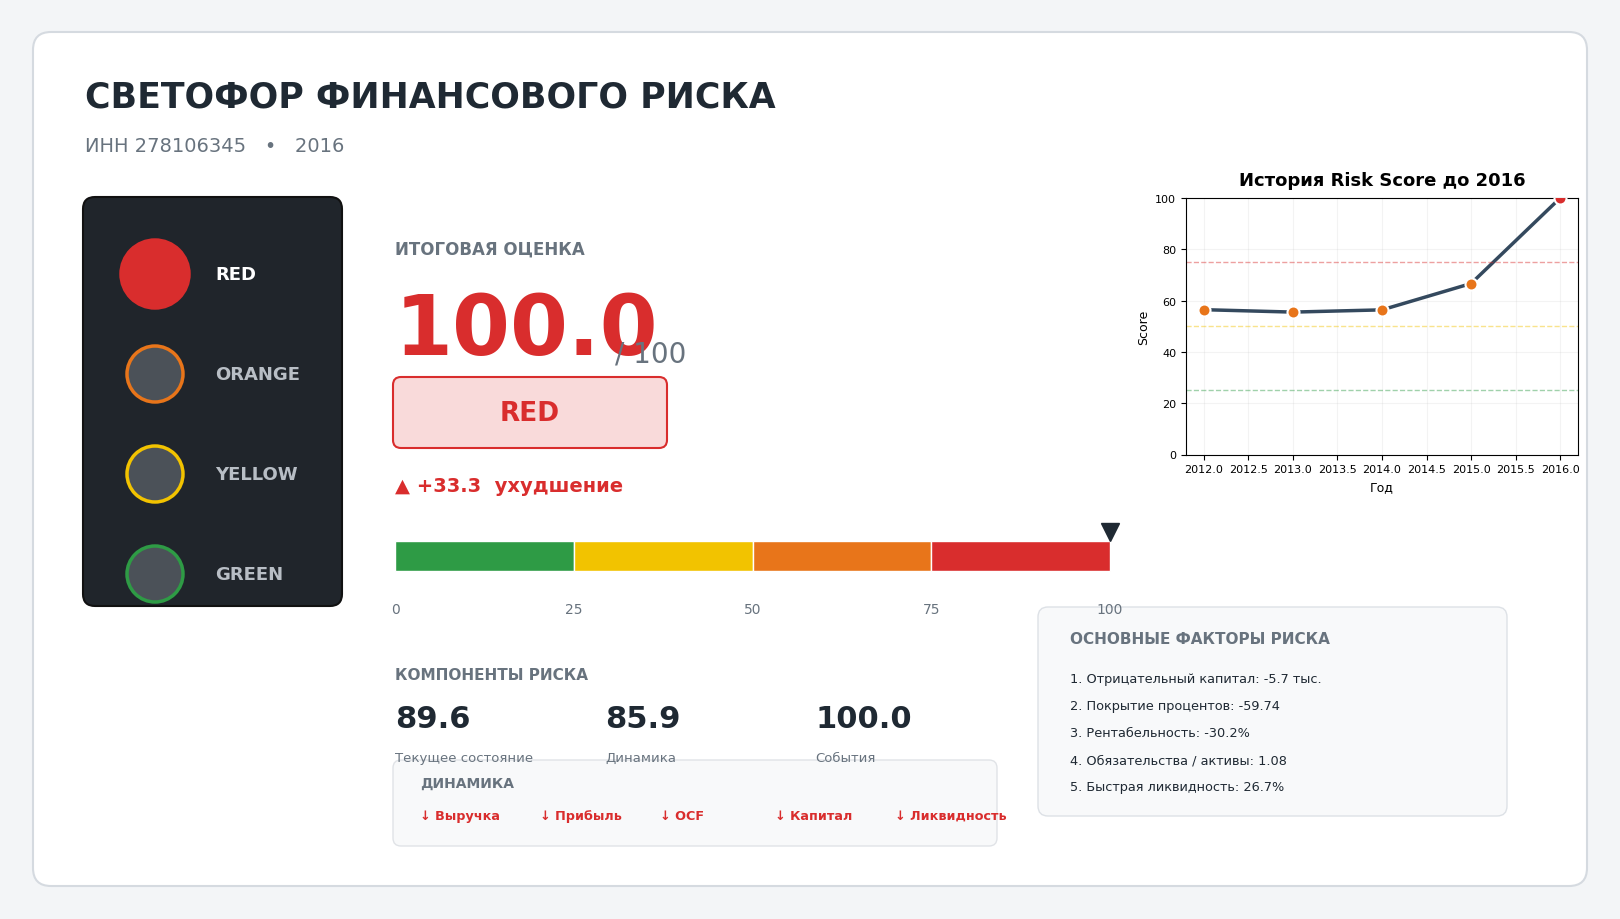

In [ ]:
# 60. ВИЗУАЛЬНАЯ КАРТОЧКА
# ИНН 278106345, год 2016
# История ограничена выбранным годом

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle
import numpy as np
import pandas as pd

# ===============================================================
# 1. ПАРАМЕТРЫ КОМПАНИИ
# ===============================================================

ИНН = "278106345"
ГОД = 2016

# ===============================================================
# 2. ИСТОРИЯ ТОЛЬКО ДО ВЫБРАННОГО ГОДА
# ===============================================================

history = (
    df_v2_final[
        (df_v2_final["инн"].astype(str) == ИНН) &
        (df_v2_final["год"] <= ГОД)
    ]
    .sort_values("год")
    .copy()
)

target = history[history["год"] == ГОД]

if target.empty:

    print(f"Нет рассчитанного результата для ИНН {ИНН}, год {ГОД}")

else:

    row = target.iloc[0]

    # Предыдущий доступный год
    previous = history[
        history["год"] < ГОД
    ].tail(1)

    if not previous.empty:
        prev = previous.iloc[0]
        prev_score = float(prev["risk_score_v2"])
        delta_score = float(row["risk_score_v2"]) - prev_score
    else:
        prev = None
        prev_score = np.nan
        delta_score = np.nan

    score = float(row["risk_score_v2"])
    level = row["risk_level_v2"]

    # ===========================================================
    # 3. ЦВЕТА
    # ===========================================================

    COLORS = {
        "GREEN": "#2E9B45",
        "YELLOW": "#F2C300",
        "ORANGE": "#E8751A",
        "RED": "#D92D2D"
    }

    LIGHT_COLORS = {
        "GREEN": "#E4F3E7",
        "YELLOW": "#FFF6CF",
        "ORANGE": "#FCE8D7",
        "RED": "#F9DADA"
    }

    DARK = "#1F2933"
    GREY = "#68737E"

    level_color = COLORS[level]

    # ===========================================================
    # 4. ИЗМЕНЕНИЕ SCORE
    # ===========================================================

    if pd.isna(delta_score):

        delta_text = "Нет предыдущего года"
        delta_color = GREY

    elif delta_score > 1:

        delta_text = f"▲ {delta_score:+.1f}  ухудшение"
        delta_color = COLORS["RED"]

    elif delta_score < -1:

        delta_text = f"▼ {delta_score:+.1f}  улучшение"
        delta_color = COLORS["GREEN"]

    else:

        delta_text = f"→ {delta_score:+.1f}  стабильно"
        delta_color = GREY

    # ===========================================================
    # 5. ФИГУРА
    # ===========================================================

    fig = plt.figure(
        figsize=(16, 9),
        facecolor="#F3F5F7"
    )

    ax = fig.add_axes([0, 0, 1, 1])

    ax.set_xlim(0, 16)
    ax.set_ylim(0, 9)
    ax.axis("off")

    # Основная карточка
    ax.add_patch(
        FancyBboxPatch(
            (0.25, 0.25),
            15.5,
            8.5,
            boxstyle="round,pad=0.02,rounding_size=0.18",
            facecolor="white",
            edgecolor="#D5DAE0",
            linewidth=1.5
        )
    )

    # ===========================================================
    # 6. ЗАГОЛОВОК
    # ===========================================================

    ax.text(
        0.75,
        8.12,
        "СВЕТОФОР ФИНАНСОВОГО РИСКА",
        fontsize=25,
        fontweight="bold",
        color=DARK,
        va="center"
    )

    ax.text(
        0.75,
        7.63,
        f"ИНН {ИНН}   •   {ГОД}",
        fontsize=14,
        color=GREY,
        va="center"
    )

    # ===========================================================
    # 7. СВЕТОФОР
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (0.75, 3.05),
            2.55,
            4.05,
            boxstyle="round,pad=0.02,rounding_size=0.12",
            facecolor="#20252B",
            edgecolor="#111111",
            linewidth=1.5
        )
    )

    traffic = [
        ("RED", 6.35),
        ("ORANGE", 5.35),
        ("YELLOW", 4.35),
        ("GREEN", 3.35)
    ]

    for name, y in traffic:

        active = name == level

        ax.add_patch(
            Circle(
                (1.45, y),
                0.34 if active else 0.28,
                facecolor=(
                    COLORS[name]
                    if active
                    else "#4B5158"
                ),
                edgecolor=COLORS[name],
                linewidth=2.5
            )
        )

        ax.text(
            2.05,
            y,
            name,
            fontsize=13,
            fontweight="bold",
            color="white" if active else "#B8BEC5",
            va="center"
        )

    # ===========================================================
    # 8. ИТОГОВЫЙ SCORE
    # ===========================================================

    ax.text(
        3.85,
        6.55,
        "ИТОГОВАЯ ОЦЕНКА",
        fontsize=12,
        fontweight="bold",
        color=GREY
    )

    ax.text(
        3.85,
        5.55,
        f"{score:.1f}",
        fontsize=60,
        fontweight="bold",
        color=level_color
    )

    ax.text(
        6.05,
        5.55,
        "/ 100",
        fontsize=20,
        color=GREY,
        va="center"
    )

    ax.add_patch(
        FancyBboxPatch(
            (3.85, 4.63),
            2.7,
            0.67,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor=LIGHT_COLORS[level],
            edgecolor=level_color,
            linewidth=1.5
        )
    )

    ax.text(
        5.20,
        4.96,
        level,
        fontsize=19,
        fontweight="bold",
        color=level_color,
        ha="center",
        va="center"
    )

    ax.text(
        3.85,
        4.18,
        delta_text,
        fontsize=14,
        fontweight="bold",
        color=delta_color
    )

    # ===========================================================
    # 9. ШКАЛА 0–100
    # ===========================================================

    scale_x = 3.85
    scale_y = 3.38
    scale_w = 7.15
    scale_h = 0.30

    for start, end, c in [
        (0, 25, COLORS["GREEN"]),
        (25, 50, COLORS["YELLOW"]),
        (50, 75, COLORS["ORANGE"]),
        (75, 100, COLORS["RED"])
    ]:

        ax.add_patch(
            Rectangle(
                (
                    scale_x + scale_w * start / 100,
                    scale_y
                ),
                scale_w * (end - start) / 100,
                scale_h,
                facecolor=c,
                edgecolor="white",
                linewidth=1
            )
        )

    marker_x = scale_x + scale_w * score / 100

    ax.plot(
        marker_x,
        scale_y + scale_h + 0.09,
        marker="v",
        markersize=13,
        color=DARK
    )

    for value in [0, 25, 50, 75, 100]:

        ax.text(
            scale_x + scale_w * value / 100,
            2.96,
            str(value),
            fontsize=10,
            color=GREY,
            ha="center"
        )

    # ===========================================================
    # 10. ИСТОРИЯ SCORE — ТОЛЬКО ДО 2016
    # ===========================================================

    hist = history.dropna(
        subset=["risk_score_v2"]
    ).copy()

    chart = fig.add_axes(
        [0.735, 0.505, 0.245, 0.285]
    )

    chart.set_facecolor("white")

    chart.plot(
        hist["год"],
        hist["risk_score_v2"],
        linewidth=2.5,
        color="#34495E"
    )

    for boundary, c in [
        (25, COLORS["GREEN"]),
        (50, COLORS["YELLOW"]),
        (75, COLORS["RED"])
    ]:

        chart.axhline(
            boundary,
            color=c,
            linewidth=1,
            linestyle="--",
            alpha=0.45
        )

    for _, h in hist.iterrows():

        point_color = COLORS.get(
            h["risk_level_v2"],
            GREY
        )

        chart.scatter(
            h["год"],
            h["risk_score_v2"],
            s=75,
            color=point_color,
            edgecolor="white",
            linewidth=1.5,
            zorder=3
        )

    chart.set_ylim(0, 100)

    chart.set_title(
        f"История Risk Score до {ГОД}",
        fontsize=13,
        fontweight="bold",
        pad=9
    )

    chart.set_xlabel(
        "Год",
        fontsize=9
    )

    chart.set_ylabel(
        "Score",
        fontsize=9
    )

    chart.tick_params(
        labelsize=8
    )

    chart.grid(alpha=0.15)

    # ===========================================================
    # 11. КОМПОНЕНТЫ РИСКА
    # ===========================================================

    ax.text(
        3.85,
        2.30,
        "КОМПОНЕНТЫ РИСКА",
        fontsize=11,
        fontweight="bold",
        color=GREY
    )

    components = [
        (
            "Текущее состояние",
            row["current_risk_score_100"]
        ),
        (
            "Динамика",
            row["dynamic_risk_100"]
        ),
        (
            "События",
            row["events_risk_100"]
        )
    ]

    for x, (name, value) in zip(
        [3.85, 5.95, 8.05],
        components
    ):

        value_text = (
            "—"
            if pd.isna(value)
            else f"{value:.1f}"
        )

        ax.text(
            x,
            1.82,
            value_text,
            fontsize=22,
            fontweight="bold",
            color=DARK
        )

        ax.text(
            x,
            1.48,
            name,
            fontsize=9.5,
            color=GREY
        )

    # ===========================================================
    # 12. ФАКТОРЫ
    # ===========================================================

    if level in ["ORANGE", "RED"]:
        factors_title = "ОСНОВНЫЕ ФАКТОРЫ РИСКА"
    else:
        factors_title = "КЛЮЧЕВЫЕ ФАКТОРЫ"

    factor_definitions = [
        (
            "Долг / выручка",
            "долговая_нагрузка_к_выручке"
        ),
        (
            "Быстрая ликвидность",
            "быстрая_ликвидность"
        ),
        (
            "Обязательства / активы",
            "доля_обязательств_в_активах"
        ),
        (
            "Покрытие процентов",
            "покрытие_процентов_прибылью"
        ),
        (
            "Текущая ликвидность",
            "текущая_ликвидность"
        ),
        (
            "OCF / краткосрочные обязательства",
            "операционный_денежный_поток_к_краткосрочным_обязательствам"
        ),
        (
            "OCF / обязательства",
            "операционный_денежный_поток_к_обязательствам"
        ),
        (
            "Рентабельность",
            "рентабельность_по_чистой_прибыли"
        )
    ]

    factors = []

    for label, column in factor_definitions:

        value = row.get(column, np.nan)

        risk_value = row.get(
            f"risk_{column}",
            np.nan
        )

        if pd.isna(value) or pd.isna(risk_value):
            continue

        factors.append(
            (
                float(risk_value),
                label,
                float(value)
            )
        )

    factors = sorted(
        factors,
        key=lambda x: x[0],
        reverse=True
    )[:5]

    # ===========================================================
    # 13. ДОБАВЛЯЕМ ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ
    # ===========================================================

    capital = row.get("капитал", np.nan)

    if pd.notna(capital) and capital < 0:

        factors.insert(
            0,
            (
                1.0,
                "Отрицательный капитал",
                float(capital)
            )
        )

    factors = factors[:5]

    # ===========================================================
    # 14. БЛОК ФАКТОРОВ
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (10.30, 0.95),
            4.65,
            2.05,
            boxstyle="round,pad=0.02,rounding_size=0.10",
            facecolor="#F8F9FA",
            edgecolor="#DDE1E6",
            linewidth=1
        )
    )

    ax.text(
        10.60,
        2.66,
        factors_title,
        fontsize=11,
        fontweight="bold",
        color=GREY
    )

    for i, (_, label, value) in enumerate(factors):

        if abs(value) >= 1_000_000:

            value_text = f"{value / 1_000_000:.2f} млн"

        elif abs(value) >= 1_000:

            value_text = f"{value / 1_000:.1f} тыс."

        elif abs(value) < 1:

            value_text = f"{value:.1%}"

        else:

            value_text = f"{value:.2f}"

        ax.text(
            10.60,
            2.30 - i * 0.27,
            f"{i + 1}. {label}: {value_text}",
            fontsize=9.3,
            color=DARK,
            va="center"
        )

    # ===========================================================
    # 15. ДИНАМИКА
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (3.85, 0.65),
            6.00,
            0.82,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor="#F8F9FA",
            edgecolor="#E0E3E7",
            linewidth=1
        )
    )

    ax.text(
        4.10,
        1.22,
        "ДИНАМИКА",
        fontsize=10,
        fontweight="bold",
        color=GREY
    )

    dynamic_items = []

    if prev is not None:

        fields = [
            ("Выручка", "выручка"),
            (
                "Прибыль",
                "прибыль_до_налогообложения"
            ),
            (
                "OCF",
                "операционный_денежный_поток"
            ),
            ("Капитал", "капитал"),
            (
                "Ликвидность",
                "текущая_ликвидность"
            )
        ]

        for label, column in fields:

            current = row.get(column, np.nan)
            old = prev.get(column, np.nan)

            if pd.isna(current) or pd.isna(old):
                continue

            change = current - old

            if change < 0:

                symbol = "↓"
                item_color = COLORS["RED"]

            elif change > 0:

                symbol = "↑"
                item_color = COLORS["GREEN"]

            else:

                symbol = "→"
                item_color = GREY

            dynamic_items.append(
                (label, symbol, item_color)
            )

    x_positions = [
        4.10,
        5.30,
        6.50,
        7.65,
        8.85
    ]

    for i, (label, symbol, item_color) in enumerate(
        dynamic_items[:5]
    ):

        ax.text(
            x_positions[i],
            0.90,
            f"{symbol} {label}",
            fontsize=9.2,
            fontweight="bold",
            color=item_color,
            ha="left"
        )

    # ===========================================================
    # 16. ПОКАЗ
    # ===========================================================

    plt.show()

### 61. Визуальная карточка компании 814166855 за 2025 год

В этой ячейке строится визуальная карточка четвёртого выбранного кейса — компании с ИНН 814166855 за 2025 год.

Кейс выбран для просмотра длительного высокого риска. Оценка строится на 2025 год, поэтому история Risk Score ограничивается 2025 годом, а динамика показывает изменение относительно предыдущего доступного года.

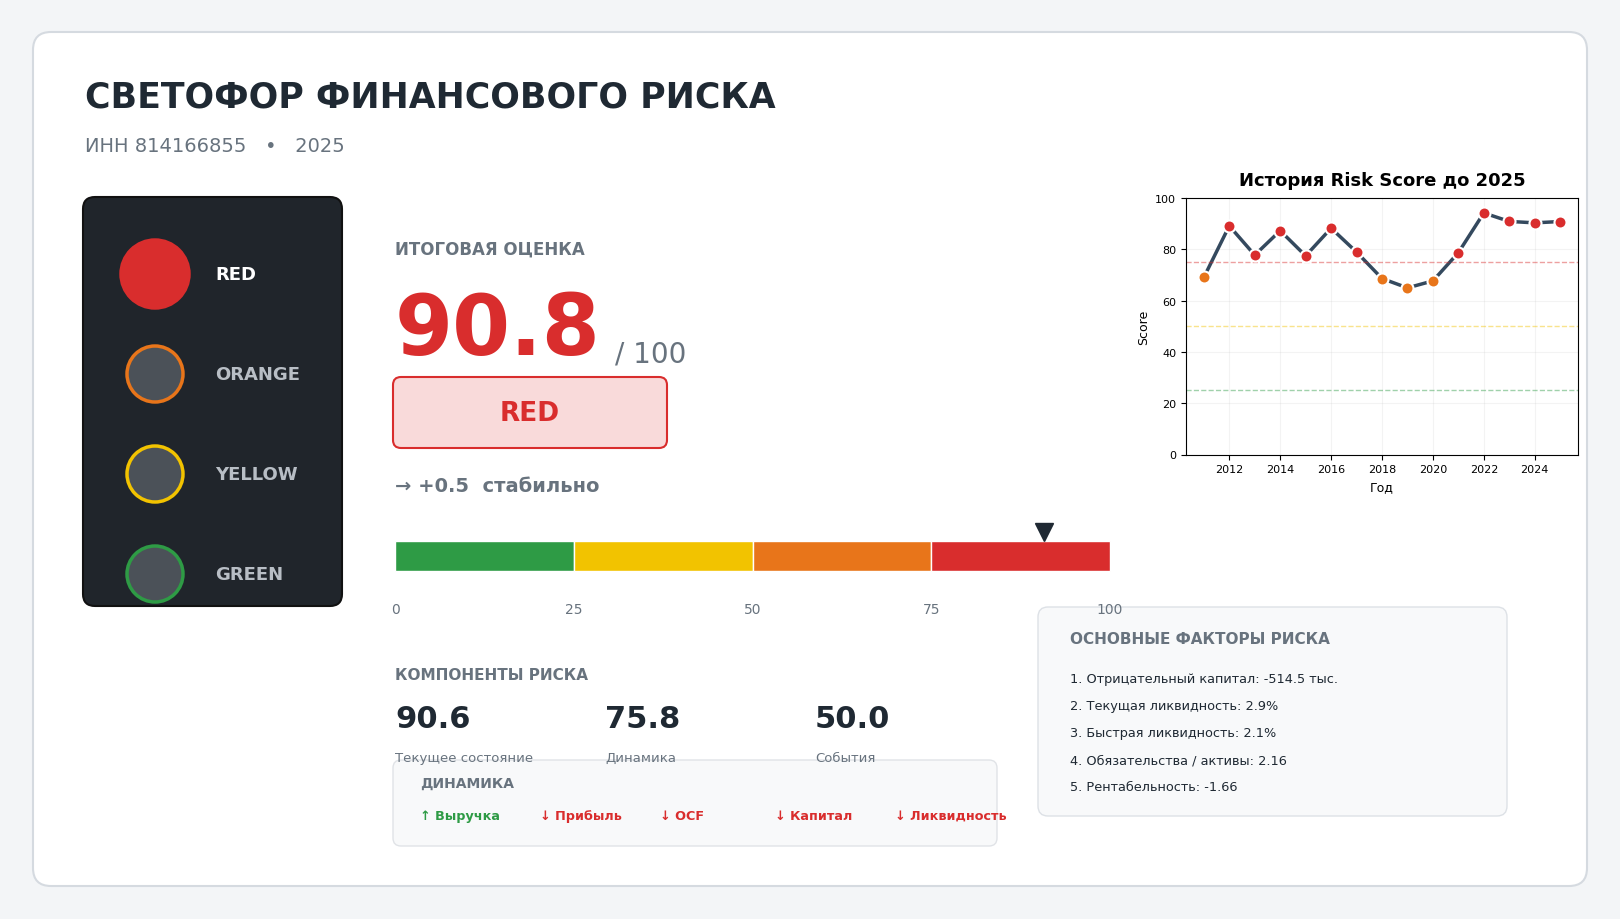

In [ ]:
# 61. ВИЗУАЛЬНАЯ КАРТОЧКА
# ИНН 814166855, год 2025
# История ограничена выбранным годом

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle
import numpy as np
import pandas as pd

# ===============================================================
# 1. ПАРАМЕТРЫ КОМПАНИИ
# ===============================================================

ИНН = "814166855"
ГОД = 2025

# ===============================================================
# 2. ИСТОРИЯ ТОЛЬКО ДО ВЫБРАННОГО ГОДА
# ===============================================================

history = (
    df_v2_final[
        (df_v2_final["инн"].astype(str) == ИНН) &
        (df_v2_final["год"] <= ГОД)
    ]
    .sort_values("год")
    .copy()
)

target = history[history["год"] == ГОД]

if target.empty:

    print(f"Нет рассчитанного результата для ИНН {ИНН}, год {ГОД}")

else:

    row = target.iloc[0]

    # Предыдущий доступный год
    previous = history[
        history["год"] < ГОД
    ].tail(1)

    if not previous.empty:
        prev = previous.iloc[0]
        prev_score = float(prev["risk_score_v2"])
        delta_score = float(row["risk_score_v2"]) - prev_score
    else:
        prev = None
        prev_score = np.nan
        delta_score = np.nan

    score = float(row["risk_score_v2"])
    level = row["risk_level_v2"]

    # ===========================================================
    # 3. ЦВЕТА
    # ===========================================================

    COLORS = {
        "GREEN": "#2E9B45",
        "YELLOW": "#F2C300",
        "ORANGE": "#E8751A",
        "RED": "#D92D2D"
    }

    LIGHT_COLORS = {
        "GREEN": "#E4F3E7",
        "YELLOW": "#FFF6CF",
        "ORANGE": "#FCE8D7",
        "RED": "#F9DADA"
    }

    DARK = "#1F2933"
    GREY = "#68737E"

    level_color = COLORS[level]

    # ===========================================================
    # 4. ИЗМЕНЕНИЕ SCORE
    # ===========================================================

    if pd.isna(delta_score):

        delta_text = "Нет предыдущего года"
        delta_color = GREY

    elif delta_score > 1:

        delta_text = f"▲ {delta_score:+.1f}  ухудшение"
        delta_color = COLORS["RED"]

    elif delta_score < -1:

        delta_text = f"▼ {delta_score:+.1f}  улучшение"
        delta_color = COLORS["GREEN"]

    else:

        delta_text = f"→ {delta_score:+.1f}  стабильно"
        delta_color = GREY

    # ===========================================================
    # 5. ФИГУРА
    # ===========================================================

    fig = plt.figure(
        figsize=(16, 9),
        facecolor="#F3F5F7"
    )

    ax = fig.add_axes([0, 0, 1, 1])

    ax.set_xlim(0, 16)
    ax.set_ylim(0, 9)
    ax.axis("off")

    # Основная карточка
    ax.add_patch(
        FancyBboxPatch(
            (0.25, 0.25),
            15.5,
            8.5,
            boxstyle="round,pad=0.02,rounding_size=0.18",
            facecolor="white",
            edgecolor="#D5DAE0",
            linewidth=1.5
        )
    )

    # ===========================================================
    # 6. ЗАГОЛОВОК
    # ===========================================================

    ax.text(
        0.75,
        8.12,
        "СВЕТОФОР ФИНАНСОВОГО РИСКА",
        fontsize=25,
        fontweight="bold",
        color=DARK,
        va="center"
    )

    ax.text(
        0.75,
        7.63,
        f"ИНН {ИНН}   •   {ГОД}",
        fontsize=14,
        color=GREY,
        va="center"
    )

    # ===========================================================
    # 7. СВЕТОФОР
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (0.75, 3.05),
            2.55,
            4.05,
            boxstyle="round,pad=0.02,rounding_size=0.12",
            facecolor="#20252B",
            edgecolor="#111111",
            linewidth=1.5
        )
    )

    traffic = [
        ("RED", 6.35),
        ("ORANGE", 5.35),
        ("YELLOW", 4.35),
        ("GREEN", 3.35)
    ]

    for name, y in traffic:

        active = name == level

        ax.add_patch(
            Circle(
                (1.45, y),
                0.34 if active else 0.28,
                facecolor=(
                    COLORS[name]
                    if active
                    else "#4B5158"
                ),
                edgecolor=COLORS[name],
                linewidth=2.5
            )
        )

        ax.text(
            2.05,
            y,
            name,
            fontsize=13,
            fontweight="bold",
            color="white" if active else "#B8BEC5",
            va="center"
        )

    # ===========================================================
    # 8. ИТОГОВЫЙ SCORE
    # ===========================================================

    ax.text(
        3.85,
        6.55,
        "ИТОГОВАЯ ОЦЕНКА",
        fontsize=12,
        fontweight="bold",
        color=GREY
    )

    ax.text(
        3.85,
        5.55,
        f"{score:.1f}",
        fontsize=60,
        fontweight="bold",
        color=level_color
    )

    ax.text(
        6.05,
        5.55,
        "/ 100",
        fontsize=20,
        color=GREY,
        va="center"
    )

    ax.add_patch(
        FancyBboxPatch(
            (3.85, 4.63),
            2.7,
            0.67,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor=LIGHT_COLORS[level],
            edgecolor=level_color,
            linewidth=1.5
        )
    )

    ax.text(
        5.20,
        4.96,
        level,
        fontsize=19,
        fontweight="bold",
        color=level_color,
        ha="center",
        va="center"
    )

    ax.text(
        3.85,
        4.18,
        delta_text,
        fontsize=14,
        fontweight="bold",
        color=delta_color
    )

    # ===========================================================
    # 9. ШКАЛА 0–100
    # ===========================================================

    scale_x = 3.85
    scale_y = 3.38
    scale_w = 7.15
    scale_h = 0.30

    for start, end, c in [
        (0, 25, COLORS["GREEN"]),
        (25, 50, COLORS["YELLOW"]),
        (50, 75, COLORS["ORANGE"]),
        (75, 100, COLORS["RED"])
    ]:

        ax.add_patch(
            Rectangle(
                (
                    scale_x + scale_w * start / 100,
                    scale_y
                ),
                scale_w * (end - start) / 100,
                scale_h,
                facecolor=c,
                edgecolor="white",
                linewidth=1
            )
        )

    marker_x = scale_x + scale_w * score / 100

    ax.plot(
        marker_x,
        scale_y + scale_h + 0.09,
        marker="v",
        markersize=13,
        color=DARK
    )

    for value in [0, 25, 50, 75, 100]:

        ax.text(
            scale_x + scale_w * value / 100,
            2.96,
            str(value),
            fontsize=10,
            color=GREY,
            ha="center"
        )

    # ===========================================================
    # 10. ИСТОРИЯ SCORE — ТОЛЬКО ДО 2025
    # ===========================================================

    hist = history.dropna(
        subset=["risk_score_v2"]
    ).copy()

    chart = fig.add_axes(
        [0.735, 0.505, 0.245, 0.285]
    )

    chart.set_facecolor("white")

    chart.plot(
        hist["год"],
        hist["risk_score_v2"],
        linewidth=2.5,
        color="#34495E"
    )

    for boundary, c in [
        (25, COLORS["GREEN"]),
        (50, COLORS["YELLOW"]),
        (75, COLORS["RED"])
    ]:

        chart.axhline(
            boundary,
            color=c,
            linewidth=1,
            linestyle="--",
            alpha=0.45
        )

    for _, h in hist.iterrows():

        point_color = COLORS.get(
            h["risk_level_v2"],
            GREY
        )

        chart.scatter(
            h["год"],
            h["risk_score_v2"],
            s=75,
            color=point_color,
            edgecolor="white",
            linewidth=1.5,
            zorder=3
        )

    chart.set_ylim(0, 100)

    chart.set_title(
        f"История Risk Score до {ГОД}",
        fontsize=13,
        fontweight="bold",
        pad=9
    )

    chart.set_xlabel(
        "Год",
        fontsize=9
    )

    chart.set_ylabel(
        "Score",
        fontsize=9
    )

    chart.tick_params(
        labelsize=8
    )

    chart.grid(alpha=0.15)

    # ===========================================================
    # 11. КОМПОНЕНТЫ РИСКА
    # ===========================================================

    ax.text(
        3.85,
        2.30,
        "КОМПОНЕНТЫ РИСКА",
        fontsize=11,
        fontweight="bold",
        color=GREY
    )

    components = [
        (
            "Текущее состояние",
            row["current_risk_score_100"]
        ),
        (
            "Динамика",
            row["dynamic_risk_100"]
        ),
        (
            "События",
            row["events_risk_100"]
        )
    ]

    for x, (name, value) in zip(
        [3.85, 5.95, 8.05],
        components
    ):

        value_text = (
            "—"
            if pd.isna(value)
            else f"{value:.1f}"
        )

        ax.text(
            x,
            1.82,
            value_text,
            fontsize=22,
            fontweight="bold",
            color=DARK
        )

        ax.text(
            x,
            1.48,
            name,
            fontsize=9.5,
            color=GREY
        )

    # ===========================================================
    # 12. ФАКТОРЫ
    # ===========================================================

    if level in ["ORANGE", "RED"]:
        factors_title = "ОСНОВНЫЕ ФАКТОРЫ РИСКА"
    else:
        factors_title = "КЛЮЧЕВЫЕ ФАКТОРЫ"

    factor_definitions = [
        (
            "Долг / выручка",
            "долговая_нагрузка_к_выручке"
        ),
        (
            "Быстрая ликвидность",
            "быстрая_ликвидность"
        ),
        (
            "Обязательства / активы",
            "доля_обязательств_в_активах"
        ),
        (
            "Покрытие процентов",
            "покрытие_процентов_прибылью"
        ),
        (
            "Текущая ликвидность",
            "текущая_ликвидность"
        ),
        (
            "OCF / краткосрочные обязательства",
            "операционный_денежный_поток_к_краткосрочным_обязательствам"
        ),
        (
            "OCF / обязательства",
            "операционный_денежный_поток_к_обязательствам"
        ),
        (
            "Рентабельность",
            "рентабельность_по_чистой_прибыли"
        )
    ]

    factors = []

    for label, column in factor_definitions:

        value = row.get(column, np.nan)

        risk_value = row.get(
            f"risk_{column}",
            np.nan
        )

        if pd.isna(value) or pd.isna(risk_value):
            continue

        factors.append(
            (
                float(risk_value),
                label,
                float(value)
            )
        )

    factors = sorted(
        factors,
        key=lambda x: x[0],
        reverse=True
    )[:5]

    # ===========================================================
    # 13. ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ — ОТДЕЛЬНЫЙ СИГНАЛ
    # ===========================================================

    capital = row.get("капитал", np.nan)

    if pd.notna(capital) and capital < 0:

        factors.insert(
            0,
            (
                1.0,
                "Отрицательный капитал",
                float(capital)
            )
        )

    factors = factors[:5]

    # ===========================================================
    # 14. БЛОК ФАКТОРОВ
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (10.30, 0.95),
            4.65,
            2.05,
            boxstyle="round,pad=0.02,rounding_size=0.10",
            facecolor="#F8F9FA",
            edgecolor="#DDE1E6",
            linewidth=1
        )
    )

    ax.text(
        10.60,
        2.66,
        factors_title,
        fontsize=11,
        fontweight="bold",
        color=GREY
    )

    for i, (_, label, value) in enumerate(factors):

        if abs(value) >= 1_000_000:

            value_text = f"{value / 1_000_000:.2f} млн"

        elif abs(value) >= 1_000:

            value_text = f"{value / 1_000:.1f} тыс."

        elif abs(value) < 1:

            value_text = f"{value:.1%}"

        else:

            value_text = f"{value:.2f}"

        ax.text(
            10.60,
            2.30 - i * 0.27,
            f"{i + 1}. {label}: {value_text}",
            fontsize=9.3,
            color=DARK,
            va="center"
        )

    # ===========================================================
    # 15. ДИНАМИКА
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (3.85, 0.65),
            6.00,
            0.82,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor="#F8F9FA",
            edgecolor="#E0E3E7",
            linewidth=1
        )
    )

    ax.text(
        4.10,
        1.22,
        "ДИНАМИКА",
        fontsize=10,
        fontweight="bold",
        color=GREY
    )

    dynamic_items = []

    if prev is not None:

        fields = [
            ("Выручка", "выручка"),
            (
                "Прибыль",
                "прибыль_до_налогообложения"
            ),
            (
                "OCF",
                "операционный_денежный_поток"
            ),
            ("Капитал", "капитал"),
            (
                "Ликвидность",
                "текущая_ликвидность"
            )
        ]

        for label, column in fields:

            current = row.get(column, np.nan)
            old = prev.get(column, np.nan)

            if pd.isna(current) or pd.isna(old):
                continue

            change = current - old

            if change < 0:

                symbol = "↓"
                item_color = COLORS["RED"]

            elif change > 0:

                symbol = "↑"
                item_color = COLORS["GREEN"]

            else:

                symbol = "→"
                item_color = GREY

            dynamic_items.append(
                (label, symbol, item_color)
            )

    x_positions = [
        4.10,
        5.30,
        6.50,
        7.65,
        8.85
    ]

    for i, (label, symbol, item_color) in enumerate(
        dynamic_items[:5]
    ):

        ax.text(
            x_positions[i],
            0.90,
            f"{symbol} {label}",
            fontsize=9.2,
            fontweight="bold",
            color=item_color,
            ha="left"
        )

    # ===========================================================
    # 16. ПОКАЗ
    # ===========================================================

    plt.show()

### 62. Визуальная карточка компании 1650079031 за 2025 год

В этой ячейке строится визуальная карточка пятого выбранного кейса — компании с ИНН 1650079031 за 2025 год.

Кейс выбран для просмотра стабильного низкого риска. Оценка строится на 2025 год, поэтому история Risk Score ограничивается 2025 годом, а динамика показывает изменение относительно предыдущего доступного года.

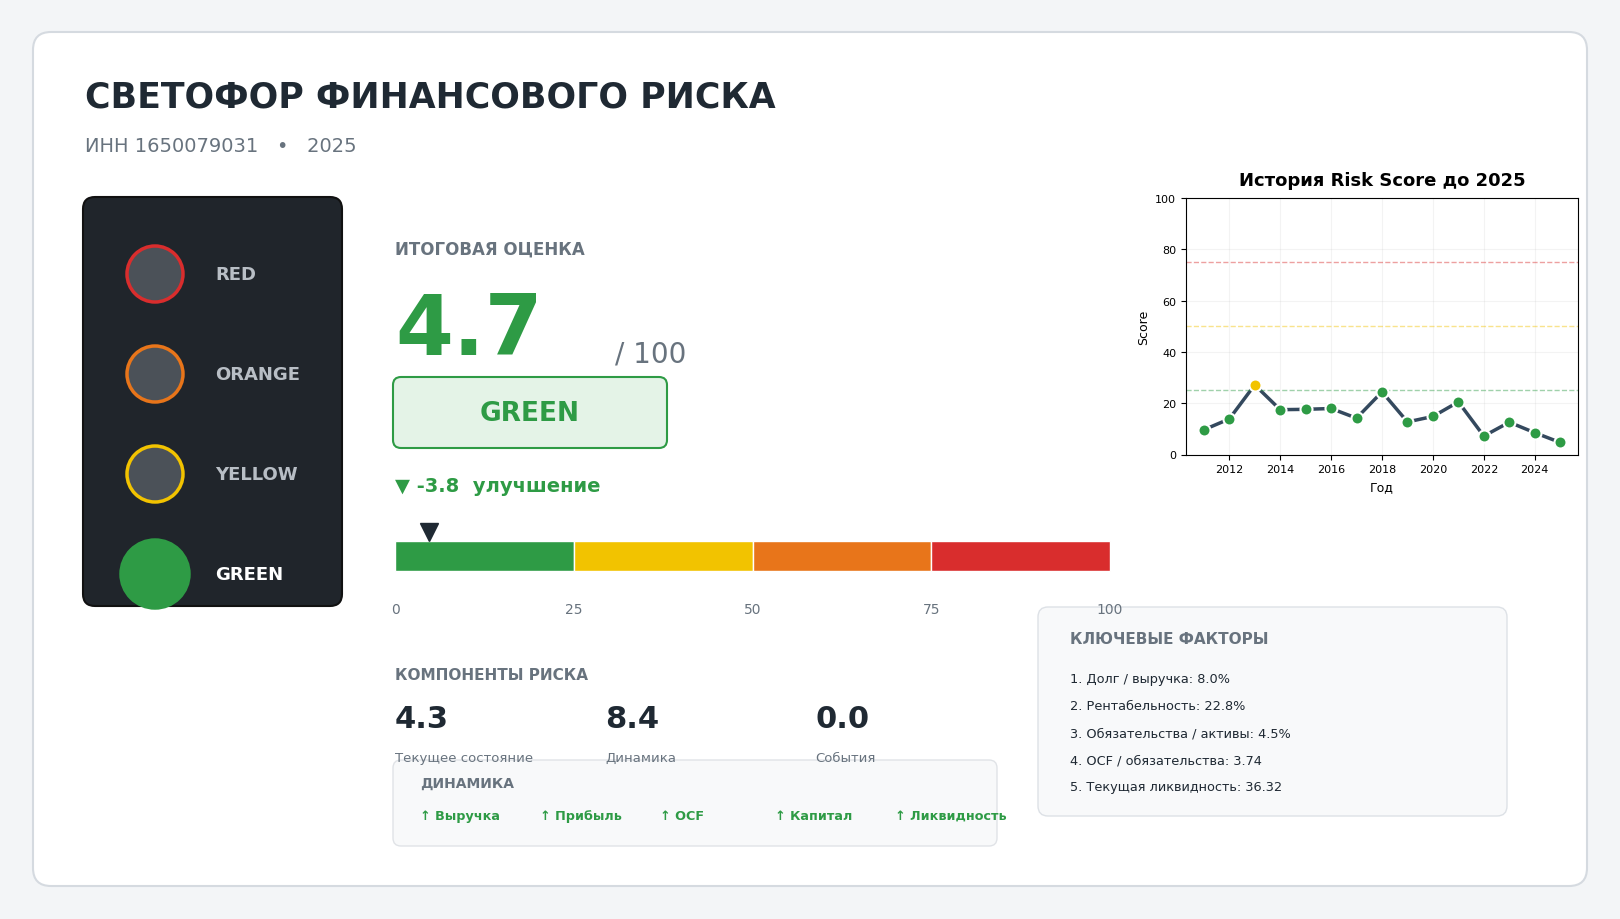

In [ ]:
# 62. ВИЗУАЛЬНАЯ КАРТОЧКА
# ИНН 1650079031, год 2025
# История ограничена выбранным годом

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle
import numpy as np
import pandas as pd

# ===============================================================
# 1. ПАРАМЕТРЫ КОМПАНИИ
# ===============================================================

ИНН = "1650079031"
ГОД = 2025

# ===============================================================
# 2. ИСТОРИЯ ТОЛЬКО ДО ВЫБРАННОГО ГОДА
# ===============================================================

history = (
    df_v2_final[
        (df_v2_final["инн"].astype(str) == ИНН) &
        (df_v2_final["год"] <= ГОД)
    ]
    .sort_values("год")
    .copy()
)

target = history[history["год"] == ГОД]

if target.empty:

    print(f"Нет рассчитанного результата для ИНН {ИНН}, год {ГОД}")

else:

    row = target.iloc[0]

    # Предыдущий доступный год
    previous = history[
        history["год"] < ГОД
    ].tail(1)

    if not previous.empty:
        prev = previous.iloc[0]
        prev_score = float(prev["risk_score_v2"])
        delta_score = float(row["risk_score_v2"]) - prev_score
    else:
        prev = None
        prev_score = np.nan
        delta_score = np.nan

    score = float(row["risk_score_v2"])
    level = row["risk_level_v2"]

    # ===========================================================
    # 3. ЦВЕТА
    # ===========================================================

    COLORS = {
        "GREEN": "#2E9B45",
        "YELLOW": "#F2C300",
        "ORANGE": "#E8751A",
        "RED": "#D92D2D"
    }

    LIGHT_COLORS = {
        "GREEN": "#E4F3E7",
        "YELLOW": "#FFF6CF",
        "ORANGE": "#FCE8D7",
        "RED": "#F9DADA"
    }

    DARK = "#1F2933"
    GREY = "#68737E"

    level_color = COLORS[level]

    # ===========================================================
    # 4. ИЗМЕНЕНИЕ SCORE
    # ===========================================================

    if pd.isna(delta_score):

        delta_text = "Нет предыдущего года"
        delta_color = GREY

    elif delta_score > 1:

        delta_text = f"▲ {delta_score:+.1f}  ухудшение"
        delta_color = COLORS["RED"]

    elif delta_score < -1:

        delta_text = f"▼ {delta_score:+.1f}  улучшение"
        delta_color = COLORS["GREEN"]

    else:

        delta_text = f"→ {delta_score:+.1f}  стабильно"
        delta_color = GREY

    # ===========================================================
    # 5. ФИГУРА
    # ===========================================================

    fig = plt.figure(
        figsize=(16, 9),
        facecolor="#F3F5F7"
    )

    ax = fig.add_axes([0, 0, 1, 1])

    ax.set_xlim(0, 16)
    ax.set_ylim(0, 9)
    ax.axis("off")

    # Основная карточка
    ax.add_patch(
        FancyBboxPatch(
            (0.25, 0.25),
            15.5,
            8.5,
            boxstyle="round,pad=0.02,rounding_size=0.18",
            facecolor="white",
            edgecolor="#D5DAE0",
            linewidth=1.5
        )
    )

    # ===========================================================
    # 6. ЗАГОЛОВОК
    # ===========================================================

    ax.text(
        0.75,
        8.12,
        "СВЕТОФОР ФИНАНСОВОГО РИСКА",
        fontsize=25,
        fontweight="bold",
        color=DARK,
        va="center"
    )

    ax.text(
        0.75,
        7.63,
        f"ИНН {ИНН}   •   {ГОД}",
        fontsize=14,
        color=GREY,
        va="center"
    )

    # ===========================================================
    # 7. СВЕТОФОР
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (0.75, 3.05),
            2.55,
            4.05,
            boxstyle="round,pad=0.02,rounding_size=0.12",
            facecolor="#20252B",
            edgecolor="#111111",
            linewidth=1.5
        )
    )

    traffic = [
        ("RED", 6.35),
        ("ORANGE", 5.35),
        ("YELLOW", 4.35),
        ("GREEN", 3.35)
    ]

    for name, y in traffic:

        active = name == level

        ax.add_patch(
            Circle(
                (1.45, y),
                0.34 if active else 0.28,
                facecolor=(
                    COLORS[name]
                    if active
                    else "#4B5158"
                ),
                edgecolor=COLORS[name],
                linewidth=2.5
            )
        )

        ax.text(
            2.05,
            y,
            name,
            fontsize=13,
            fontweight="bold",
            color="white" if active else "#B8BEC5",
            va="center"
        )

    # ===========================================================
    # 8. ИТОГОВЫЙ SCORE
    # ===========================================================

    ax.text(
        3.85,
        6.55,
        "ИТОГОВАЯ ОЦЕНКА",
        fontsize=12,
        fontweight="bold",
        color=GREY
    )

    ax.text(
        3.85,
        5.55,
        f"{score:.1f}",
        fontsize=60,
        fontweight="bold",
        color=level_color
    )

    ax.text(
        6.05,
        5.55,
        "/ 100",
        fontsize=20,
        color=GREY,
        va="center"
    )

    ax.add_patch(
        FancyBboxPatch(
            (3.85, 4.63),
            2.7,
            0.67,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor=LIGHT_COLORS[level],
            edgecolor=level_color,
            linewidth=1.5
        )
    )

    ax.text(
        5.20,
        4.96,
        level,
        fontsize=19,
        fontweight="bold",
        color=level_color,
        ha="center",
        va="center"
    )

    ax.text(
        3.85,
        4.18,
        delta_text,
        fontsize=14,
        fontweight="bold",
        color=delta_color
    )

    # ===========================================================
    # 9. ШКАЛА 0–100
    # ===========================================================

    scale_x = 3.85
    scale_y = 3.38
    scale_w = 7.15
    scale_h = 0.30

    for start, end, c in [
        (0, 25, COLORS["GREEN"]),
        (25, 50, COLORS["YELLOW"]),
        (50, 75, COLORS["ORANGE"]),
        (75, 100, COLORS["RED"])
    ]:

        ax.add_patch(
            Rectangle(
                (
                    scale_x + scale_w * start / 100,
                    scale_y
                ),
                scale_w * (end - start) / 100,
                scale_h,
                facecolor=c,
                edgecolor="white",
                linewidth=1
            )
        )

    marker_x = scale_x + scale_w * score / 100

    ax.plot(
        marker_x,
        scale_y + scale_h + 0.09,
        marker="v",
        markersize=13,
        color=DARK
    )

    for value in [0, 25, 50, 75, 100]:

        ax.text(
            scale_x + scale_w * value / 100,
            2.96,
            str(value),
            fontsize=10,
            color=GREY,
            ha="center"
        )

    # ===========================================================
    # 10. ИСТОРИЯ SCORE — ТОЛЬКО ДО 2025
    # ===========================================================

    hist = history.dropna(
        subset=["risk_score_v2"]
    ).copy()

    chart = fig.add_axes(
        [0.735, 0.505, 0.245, 0.285]
    )

    chart.set_facecolor("white")

    chart.plot(
        hist["год"],
        hist["risk_score_v2"],
        linewidth=2.5,
        color="#34495E"
    )

    for boundary, c in [
        (25, COLORS["GREEN"]),
        (50, COLORS["YELLOW"]),
        (75, COLORS["RED"])
    ]:

        chart.axhline(
            boundary,
            color=c,
            linewidth=1,
            linestyle="--",
            alpha=0.45
        )

    for _, h in hist.iterrows():

        point_color = COLORS.get(
            h["risk_level_v2"],
            GREY
        )

        chart.scatter(
            h["год"],
            h["risk_score_v2"],
            s=75,
            color=point_color,
            edgecolor="white",
            linewidth=1.5,
            zorder=3
        )

    chart.set_ylim(0, 100)

    chart.set_title(
        f"История Risk Score до {ГОД}",
        fontsize=13,
        fontweight="bold",
        pad=9
    )

    chart.set_xlabel(
        "Год",
        fontsize=9
    )

    chart.set_ylabel(
        "Score",
        fontsize=9
    )

    chart.tick_params(
        labelsize=8
    )

    chart.grid(alpha=0.15)

    # ===========================================================
    # 11. КОМПОНЕНТЫ РИСКА
    # ===========================================================

    ax.text(
        3.85,
        2.30,
        "КОМПОНЕНТЫ РИСКА",
        fontsize=11,
        fontweight="bold",
        color=GREY
    )

    components = [
        (
            "Текущее состояние",
            row["current_risk_score_100"]
        ),
        (
            "Динамика",
            row["dynamic_risk_100"]
        ),
        (
            "События",
            row["events_risk_100"]
        )
    ]

    for x, (name, value) in zip(
        [3.85, 5.95, 8.05],
        components
    ):

        value_text = (
            "—"
            if pd.isna(value)
            else f"{value:.1f}"
        )

        ax.text(
            x,
            1.82,
            value_text,
            fontsize=22,
            fontweight="bold",
            color=DARK
        )

        ax.text(
            x,
            1.48,
            name,
            fontsize=9.5,
            color=GREY
        )

    # ===========================================================
    # 12. ФАКТОРЫ
    # ===========================================================

    if level in ["ORANGE", "RED"]:
        factors_title = "ОСНОВНЫЕ ФАКТОРЫ РИСКА"
    else:
        factors_title = "КЛЮЧЕВЫЕ ФАКТОРЫ"

    factor_definitions = [
        (
            "Долг / выручка",
            "долговая_нагрузка_к_выручке"
        ),
        (
            "Быстрая ликвидность",
            "быстрая_ликвидность"
        ),
        (
            "Обязательства / активы",
            "доля_обязательств_в_активах"
        ),
        (
            "Покрытие процентов",
            "покрытие_процентов_прибылью"
        ),
        (
            "Текущая ликвидность",
            "текущая_ликвидность"
        ),
        (
            "OCF / краткосрочные обязательства",
            "операционный_денежный_поток_к_краткосрочным_обязательствам"
        ),
        (
            "OCF / обязательства",
            "операционный_денежный_поток_к_обязательствам"
        ),
        (
            "Рентабельность",
            "рентабельность_по_чистой_прибыли"
        )
    ]

    factors = []

    for label, column in factor_definitions:

        value = row.get(column, np.nan)

        risk_value = row.get(
            f"risk_{column}",
            np.nan
        )

        if pd.isna(value) or pd.isna(risk_value):
            continue

        factors.append(
            (
                float(risk_value),
                label,
                float(value)
            )
        )

    factors = sorted(
        factors,
        key=lambda x: x[0],
        reverse=True
    )[:5]

    # ===========================================================
    # 13. ОТРИЦАТЕЛЬНЫЙ КАПИТАЛ — ОТДЕЛЬНЫЙ СИГНАЛ
    # ===========================================================

    capital = row.get("капитал", np.nan)

    if pd.notna(capital) and capital < 0:

        factors.insert(
            0,
            (
                1.0,
                "Отрицательный капитал",
                float(capital)
            )
        )

    factors = factors[:5]

    # ===========================================================
    # 14. БЛОК ФАКТОРОВ
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (10.30, 0.95),
            4.65,
            2.05,
            boxstyle="round,pad=0.02,rounding_size=0.10",
            facecolor="#F8F9FA",
            edgecolor="#DDE1E6",
            linewidth=1
        )
    )

    ax.text(
        10.60,
        2.66,
        factors_title,
        fontsize=11,
        fontweight="bold",
        color=GREY
    )

    for i, (_, label, value) in enumerate(factors):

        if abs(value) >= 1_000_000:

            value_text = f"{value / 1_000_000:.2f} млн"

        elif abs(value) >= 1_000:

            value_text = f"{value / 1_000:.1f} тыс."

        elif abs(value) < 1:

            value_text = f"{value:.1%}"

        else:

            value_text = f"{value:.2f}"

        ax.text(
            10.60,
            2.30 - i * 0.27,
            f"{i + 1}. {label}: {value_text}",
            fontsize=9.3,
            color=DARK,
            va="center"
        )

    # ===========================================================
    # 15. ДИНАМИКА
    # ===========================================================

    ax.add_patch(
        FancyBboxPatch(
            (3.85, 0.65),
            6.00,
            0.82,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor="#F8F9FA",
            edgecolor="#E0E3E7",
            linewidth=1
        )
    )

    ax.text(
        4.10,
        1.22,
        "ДИНАМИКА",
        fontsize=10,
        fontweight="bold",
        color=GREY
    )

    dynamic_items = []

    if prev is not None:

        fields = [
            ("Выручка", "выручка"),
            (
                "Прибыль",
                "прибыль_до_налогообложения"
            ),
            (
                "OCF",
                "операционный_денежный_поток"
            ),
            ("Капитал", "капитал"),
            (
                "Ликвидность",
                "текущая_ликвидность"
            )
        ]

        for label, column in fields:

            current = row.get(column, np.nan)
            old = prev.get(column, np.nan)

            if pd.isna(current) or pd.isna(old):
                continue

            change = current - old

            if change < 0:

                symbol = "↓"
                item_color = COLORS["RED"]

            elif change > 0:

                symbol = "↑"
                item_color = COLORS["GREEN"]

            else:

                symbol = "→"
                item_color = GREY

            dynamic_items.append(
                (label, symbol, item_color)
            )

    x_positions = [
        4.10,
        5.30,
        6.50,
        7.65,
        8.85
    ]

    for i, (label, symbol, item_color) in enumerate(
        dynamic_items[:5]
    ):

        ax.text(
            x_positions[i],
            0.90,
            f"{symbol} {label}",
            fontsize=9.2,
            fontweight="bold",
            color=item_color,
            ha="left"
        )

    # ===========================================================
    # 16. ПОКАЗ
    # ===========================================================

    plt.show()

### 63. Фиксируем reference-шкалы и проверяем V2 на новых данных

В этой ячейке строятся фиксированные reference-шкалы на основном исследовательском наборе.

Reference-шкалы рассчитываются только один раз на основном наборе `df_v2` и затем применяются к новым данным без пересчёта их распределения.

Для новых наблюдений:

- текущие финансовые показатели переводятся в риск-сигнал относительно reference-шкалы;
- динамические показатели также оцениваются относительно reference-шкалы изменений;
- отсутствие предыдущего года не считается риском;
- если один из компонентов V2 недоступен, веса доступных компонентов перенормируются;
- итоговый Risk Score остаётся в диапазоне 0–100.

После расчёта выполняется out-of-sample проверка на новом файле `4.csv`.

In [ ]:
# 63. FIXED REFERENCE-SCALES + OUT-OF-SAMPLE TEST ON 4.CSV
# Исправленная версия: 4.csv может быть БЕЗ заголовка

import numpy as np
import pandas as pd
from pathlib import Path

# ===============================================================
# 1. ПРОВЕРКА ОСНОВНОГО DATASET
# ===============================================================

if "df_v2" not in globals():
    raise NameError(
        "Не найден df_v2. "
        "Сначала выполни ячейки подготовки основного рабочего набора."
    )

if "df_full" not in globals():
    raise NameError(
        "Не найден df_full. "
        "Сначала выполни ячейку загрузки основного датасета."
    )

reference_df = df_v2.copy()

print("=" * 70)
print("REFERENCE DATASET")
print("=" * 70)

print(f"Наблюдений: {len(reference_df):,}")
print(f"Компаний: {reference_df['инн'].nunique():,}")
print(
    f"Годы: {reference_df['год'].min()}–"
    f"{reference_df['год'].max()}"
)

# ===============================================================
# 2. НАХОДИМ 4.CSV
# ===============================================================

possible_paths = [
    Path("/content/drive/MyDrive/komus-credit-risk/data/raw/4.csv"),
    Path("/mnt/data/4.csv")
]

new_file = None

for path in possible_paths:

    if path.exists():
        new_file = path
        break

if new_file is None:

    raise FileNotFoundError(
        "Файл 4.csv не найден."
    )

# ===============================================================
# 3. ЗАГРУЗКА 4.CSV
#
# ВАЖНО:
# 4.csv в текущем эксперименте сохранён БЕЗ HEADER.
# Поэтому первая строка является данными.
#
# Используем схему основного df_full.
# ===============================================================

expected_columns = df_full.columns.tolist()

print()
print("=" * 70)
print("NEW DATASET")
print("=" * 70)

print(f"Файл: {new_file}")
print(f"Ожидаем столбцов: {len(expected_columns)}")

# Загружаем без заголовка
df_new = pd.read_csv(
    new_file,
    header=None,
    names=expected_columns,
    low_memory=False
)

print(f"Получено столбцов: {len(df_new.columns)}")
print(f"Наблюдений: {len(df_new):,}")

# ===============================================================
# 4. ПРОВЕРКА СХЕМЫ
# ===============================================================

missing_required_columns = [
    col
    for col in expected_columns
    if col not in df_new.columns
]

if missing_required_columns:

    raise ValueError(
        "После загрузки отсутствуют обязательные столбцы: "
        + ", ".join(missing_required_columns)
    )

print("Схема CSV: OK")
print("Колонки ИНН/год:", "инн" in df_new.columns, "год" in df_new.columns)

# ===============================================================
# 5. ТИПЫ
# ===============================================================

reference_df["инн"] = (
    reference_df["инн"]
    .astype(str)
)

reference_df["год"] = pd.to_numeric(
    reference_df["год"],
    errors="coerce"
)

df_new["инн"] = (
    df_new["инн"]
    .astype(str)
)

df_new["год"] = pd.to_numeric(
    df_new["год"],
    errors="coerce"
)

print(
    f"Компаний в 4.csv: "
    f"{df_new['инн'].nunique():,}"
)

print(
    f"Годы: "
    f"{df_new['год'].min()}–"
    f"{df_new['год'].max()}"
)

# ===============================================================
# 6. ФУНКЦИЯ REFERENCE DISTRIBUTION
# ===============================================================

def build_reference_distribution(series):

    values = pd.to_numeric(
        series,
        errors="coerce"
    ).replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna().to_numpy()

    return np.sort(values)


def apply_reference_rank(
    series,
    reference_values,
    higher_is_risk=True
):

    result = pd.Series(
        np.nan,
        index=series.index,
        dtype=float
    )

    if len(reference_values) == 0:
        return result

    values = pd.to_numeric(
        series,
        errors="coerce"
    )

    valid = (
        values.notna()
        &
        np.isfinite(values)
    )

    x = values.loc[valid].to_numpy()

    ranks = (
        np.searchsorted(
            reference_values,
            x,
            side="right"
        )
        /
        len(reference_values)
    )

    ranks = np.clip(
        ranks,
        0,
        1
    )

    if higher_is_risk:
        risk = ranks
    else:
        risk = 1 - ranks

    result.loc[valid] = risk

    return result

# ===============================================================
# 7. CURRENT STATE — REFERENCE SCALE
# ===============================================================

current_indicators = {

    "доля_обязательств_в_активах": True,

    "долговая_нагрузка_к_выручке": True,

    "текущая_ликвидность": False,

    "быстрая_ликвидность": False,

    "денежные_средства_к_краткосрочным_обязательствам": False,

    "покрытие_процентов_прибылью": False,

    "операционный_денежный_поток_к_краткосрочным_обязательствам": False,

    "операционный_денежный_поток_к_обязательствам": False,

    "рентабельность_по_чистой_прибыли": False
}

reference_scales = {}

for column, higher_is_risk in current_indicators.items():

    reference_scales[column] = (
        build_reference_distribution(
            reference_df[column]
        )
    )

# ===============================================================
# 8. ПРИМЕНЯЕМ REFERENCE SCALE К 4.CSV
# ===============================================================

for column, higher_is_risk in current_indicators.items():

    df_new[
        f"risk_ref_{column}"
    ] = apply_reference_rank(
        df_new[column],
        reference_scales[column],
        higher_is_risk
    )

# ===============================================================
# 9. БЛОКИ CURRENT STATE
# ===============================================================

current_blocks = {

    "debt": [
        "доля_обязательств_в_активах",
        "долговая_нагрузка_к_выручке"
    ],

    "liquidity": [
        "текущая_ликвидность",
        "быстрая_ликвидность",
        "денежные_средства_к_краткосрочным_обязательствам"
    ],

    "ability": [
        "покрытие_процентов_прибылью",
        "операционный_денежный_поток_к_краткосрочным_обязательствам",
        "операционный_денежный_поток_к_обязательствам"
    ],

    "profitability": [
        "рентабельность_по_чистой_прибыли"
    ]
}

for block, columns in current_blocks.items():

    risk_columns = [
        f"risk_ref_{column}"
        for column in columns
    ]

    df_new[
        f"block_{block}"
    ] = df_new[
        risk_columns
    ].mean(
        axis=1,
        skipna=True
    )

# ===============================================================
# 10. CURRENT SCORE
# ===============================================================

block_names = [
    "debt",
    "liquidity",
    "ability",
    "profitability"
]

block_values = df_new[
    [
        f"block_{block}"
        for block in block_names
    ]
]

available_blocks = (
    block_values.notna().sum(axis=1)
)

df_new["current_blocks_available"] = (
    available_blocks
)

df_new["current_risk_01"] = (
    block_values.sum(
        axis=1,
        skipna=True
    )
    /
    (
        available_blocks
        * 0.25
    )
    * 0.25
)

# Исправляем формулу:
# среднее доступных блоков = сумма / число доступных блоков

df_new["current_risk_01"] = (
    block_values.sum(
        axis=1,
        skipna=True
    )
    /
    available_blocks.replace(
        0,
        np.nan
    )
)

df_new["current_risk_100_ref"] = (
    df_new["current_risk_01"]
    * 100
)

# ===============================================================
# 11. DYNAMICS — REFERENCE DISTRIBUTIONS
# ===============================================================

dynamic_indicators = {

    "выручка": False,

    "прибыль_до_налогообложения": False,

    "операционный_денежный_поток": False,

    "капитал": False,

    "денежные_средства": False,

    "доля_обязательств_в_активах": True,

    "текущая_ликвидность": False
}

reference_history = (
    df_full[
        [
            "инн",
            "год"
        ]
        +
        list(dynamic_indicators.keys())
    ]
    .copy()
    .sort_values(
        ["инн", "год"]
    )
)

for column in dynamic_indicators:

    reference_history[
        f"prev_{column}"
    ] = reference_history.groupby(
        "инн"
    )[column].shift(1)

    reference_history[
        f"delta_{column}"
    ] = (
        reference_history[column]
        -
        reference_history[f"prev_{column}"]
    )

dynamic_reference_scales = {}

for column in dynamic_indicators:

    dynamic_reference_scales[column] = (
        build_reference_distribution(
            reference_history[
                f"delta_{column}"
            ]
        )
    )

# ===============================================================
# 12. DYNAMICS ДЛЯ 4.CSV
# ===============================================================

new_history = (
    df_new[
        [
            "инн",
            "год"
        ]
        +
        list(dynamic_indicators.keys())
    ]
    .copy()
    .sort_values(
        ["инн", "год"]
    )
)

for column, higher_is_risk in dynamic_indicators.items():

    new_history[
        f"prev_{column}"
    ] = new_history.groupby(
        "инн"
    )[column].shift(1)

    new_history[
        f"delta_{column}"
    ] = (
        new_history[column]
        -
        new_history[f"prev_{column}"]
    )

    new_history[
        f"risk_ref_dyn_{column}"
    ] = apply_reference_rank(
        new_history[
            f"delta_{column}"
        ],
        dynamic_reference_scales[column],
        higher_is_risk
    )

dynamic_risk_columns = [
    f"risk_ref_dyn_{column}"
    for column in dynamic_indicators
]

new_history[
    "dynamic_signals_available"
] = (
    new_history[
        dynamic_risk_columns
    ]
    .notna()
    .sum(axis=1)
)

new_history[
    "dynamic_risk_100_ref"
] = (
    new_history[
        dynamic_risk_columns
    ]
    .mean(
        axis=1,
        skipna=True
    )
    * 100
)

# ===============================================================
# 13. EVENTS
# ===============================================================

event_history = (
    df_new[
        [
            "инн",
            "год",
            "выручка",
            "прибыль_до_налогообложения",
            "капитал",
            "доля_обязательств_в_активах"
        ]
    ]
    .copy()
    .sort_values(
        ["инн", "год"]
    )
)

event_history["prev_выручка"] = (
    event_history.groupby(
        "инн"
    )["выручка"].shift(1)
)

event_history["prev_прибыль"] = (
    event_history.groupby(
        "инн"
    )["прибыль_до_налогообложения"].shift(1)
)

event_history["event_revenue_drop"] = (
    event_history["prev_выручка"].notna()
    &
    event_history["выручка"].notna()
    &
    (event_history["prev_выручка"] > 0)
    &
    (
        event_history["выручка"]
        <
        event_history["prev_выручка"] * 0.5
    )
)

event_history["event_profit_to_loss"] = (
    event_history["prev_прибыль"].notna()
    &
    event_history["прибыль_до_налогообложения"].notna()
    &
    (event_history["prev_прибыль"] >= 0)
    &
    (
        event_history["прибыль_до_налогообложения"] < 0
    )
)

event_history["event_loss_worsened"] = (
    event_history["prev_прибыль"].notna()
    &
    event_history["прибыль_до_налогообложения"].notna()
    &
    (event_history["prev_прибыль"] < 0)
    &
    (
        event_history["прибыль_до_налогообложения"] < 0
    )
    &
    (
        event_history["прибыль_до_налогообложения"]
        <
        event_history["prev_прибыль"]
    )
)

event_history["event_loss_exit"] = (
    event_history["prev_прибыль"].notna()
    &
    event_history["прибыль_до_налогообложения"].notna()
    &
    (event_history["prev_прибыль"] < 0)
    &
    (
        event_history["прибыль_до_налогообложения"] >= 0
    )
)

event_history["event_negative_combo"] = (
    event_history["event_revenue_drop"]
    &
    (
        event_history["event_profit_to_loss"]
        |
        event_history["event_loss_worsened"]
    )
)

event_history["event_positive_combo"] = (
    event_history["prev_выручка"].notna()
    &
    event_history["выручка"].notna()
    &
    event_history["prev_прибыль"].notna()
    &
    event_history["прибыль_до_налогообложения"].notna()
    &
    (
        event_history["выручка"]
        >
        event_history["prev_выручка"]
    )
    &
    (
        event_history["prev_прибыль"] < 0
    )
    &
    (
        event_history["прибыль_до_налогообложения"] >= 0
    )
)

event_history["events_risk_raw"] = (
    event_history["event_revenue_drop"].astype(float) * 0.50
    +
    event_history["event_profit_to_loss"].astype(float) * 0.50
    +
    event_history["event_loss_worsened"].astype(float) * 0.50
    -
    event_history["event_loss_exit"].astype(float) * 0.25
    +
    event_history["event_negative_combo"].astype(float) * 0.25
    -
    event_history["event_positive_combo"].astype(float) * 0.15
)

event_history["events_risk_100_ref"] = (
    event_history["events_risk_raw"]
    .clip(0, 1)
    * 100
)

# ===============================================================
# 14. ОБЪЕДИНЕНИЕ
# ===============================================================

result = df_new[
    [
        "инн",
        "год",
        "current_risk_100_ref",
        "current_blocks_available",
        "капитал"
    ]
].copy()

result = result.merge(
    new_history[
        [
            "инн",
            "год",
            "dynamic_risk_100_ref",
            "dynamic_signals_available"
        ]
    ],
    on=["инн", "год"],
    how="left"
)

result = result.merge(
    event_history[
        [
            "инн",
            "год",
            "events_risk_100_ref"
        ]
    ],
    on=["инн", "год"],
    how="left"
)

# ===============================================================
# 15. NEGATIVE EQUITY
# ===============================================================

result["negative_equity"] = (
    result["капитал"].notna()
    &
    (
        result["капитал"] < 0
    )
)

result["negative_equity_points"] = (
    result["negative_equity"]
    .astype(float)
    * 10
)

# ===============================================================
# 16. FINAL V2
#
# Current 60%
# Dynamic 25%
# Events 15%
#
# Недоступный компонент не считается нулевым риском.
# Вес доступных компонентов перенормируется.
# ===============================================================

base_weights = {
    "current": 0.60,
    "dynamic": 0.25,
    "events": 0.15
}

component_columns = {
    "current": "current_risk_100_ref",
    "dynamic": "dynamic_risk_100_ref",
    "events": "events_risk_100_ref"
}

weighted_sum = pd.Series(
    0.0,
    index=result.index
)

weight_sum = pd.Series(
    0.0,
    index=result.index
)

for component, weight in base_weights.items():

    values = result[
        component_columns[component]
    ]

    available = values.notna()

    weighted_sum += (
        values.fillna(0)
        * weight
    )

    weight_sum += (
        available.astype(float)
        * weight
    )

result["risk_score_base_ref"] = (
    weighted_sum
    /
    weight_sum.replace(
        0,
        np.nan
    )
)

# Special signal
result["risk_score_v2_ref"] = (
    result["risk_score_base_ref"]
    +
    result["negative_equity_points"]
).clip(
    0,
    100
)

# ===============================================================
# 17. COLOR
# ===============================================================

def risk_level(score):

    if pd.isna(score):
        return None

    if score < 25:
        return "GREEN"

    if score < 50:
        return "YELLOW"

    if score < 75:
        return "ORANGE"

    return "RED"


result["risk_level_v2_ref"] = (
    result["risk_score_v2_ref"]
    .apply(risk_level)
)

# ===============================================================
# 18. ФИНАЛЬНАЯ ПРОВЕРКА
# ===============================================================

print()
print("=" * 70)
print("OUT-OF-SAMPLE TEST: 4.CSV")
print("=" * 70)

print(
    f"Наблюдений: {len(result):,}"
)

print(
    f"Компаний: {result['инн'].nunique():,}"
)

print(
    f"Current available: "
    f"{result['current_risk_100_ref'].notna().sum():,}"
)

print(
    f"Dynamic available: "
    f"{result['dynamic_risk_100_ref'].notna().sum():,}"
)

print(
    f"Events available: "
    f"{result['events_risk_100_ref'].notna().sum():,}"
)

print(
    f"Final V2 available: "
    f"{result['risk_score_v2_ref'].notna().sum():,}"
)

# ===============================================================
# 19. ЦВЕТА
# ===============================================================

color_distribution = (
    result["risk_level_v2_ref"]
    .value_counts(dropna=False)
    .rename_axis("risk_level")
    .reset_index(name="count")
)

color_distribution["share"] = (
    color_distribution["count"]
    /
    len(result)
    * 100
)

print()
print("РАСПРЕДЕЛЕНИЕ ЦВЕТОВ:")

display(
    color_distribution
)

# ===============================================================
# 20. ТАБЛИЦА РЕЗУЛЬТАТОВ
# ===============================================================

result_display = result[
    [
        "инн",
        "год",
        "current_blocks_available",
        "current_risk_100_ref",
        "dynamic_signals_available",
        "dynamic_risk_100_ref",
        "events_risk_100_ref",
        "negative_equity",
        "risk_score_v2_ref",
        "risk_level_v2_ref"
    ]
].sort_values(
    ["инн", "год"]
).copy()

print()
print("РЕЗУЛЬТАТ ПО 4.CSV:")

display(
    result_display.round(
        {
            "current_risk_100_ref": 2,
            "dynamic_risk_100_ref": 2,
            "events_risk_100_ref": 2,
            "risk_score_v2_ref": 2
        }
    )
)

# ===============================================================
# 21. СОХРАНЯЕМ OOS-РЕЗУЛЬТАТ
# ===============================================================

df_v2_oos_4 = result.copy()

print()
print("=" * 70)
print("ГОТОВО")
print("=" * 70)

print(
    "4.csv загружен как файл БЕЗ заголовка."
)

print(
    "Схема столбцов взята из df_full."
)

print(
    "Reference-шкалы построены только на основном датасете."
)

print(
    "4.csv не участвовал в построении reference-шкал."
)

print(
    "Отсутствие предыдущего года не считается риском."
)

print(
    "Недоступные компоненты не превращаются в нулевой риск; "
    "их веса перераспределяются между доступными компонентами."
)

REFERENCE DATASET
Наблюдений: 34,762
Компаний: 5,436
Годы: 2011–2025

NEW DATASET
Файл: /content/drive/MyDrive/komus-credit-risk/data/raw/4.csv
Ожидаем столбцов: 37
Получено столбцов: 37
Наблюдений: 78
Схема CSV: OK
Колонки ИНН/год: True True
Компаний в 4.csv: 7
Годы: 2012–2025

OUT-OF-SAMPLE TEST: 4.CSV
Наблюдений: 78
Компаний: 7
Current available: 76
Dynamic available: 71
Events available: 78
Final V2 available: 78

РАСПРЕДЕЛЕНИЕ ЦВЕТОВ:


,risk_level,count,share
0,YELLOW,33,42.307692
1,GREEN,21,26.923077
2,ORANGE,13,16.666667
3,RED,11,14.102564



РЕЗУЛЬТАТ ПО 4.CSV:


,инн,год,current_blocks_available,current_risk_100_ref,dynamic_signals_available,dynamic_risk_100_ref,events_risk_100_ref,negative_equity,risk_score_v2_ref,risk_level_v2_ref
0,3445123299,2013,3,37.15,0,NaN,0.0,False,29.72,YELLOW
1,3445123299,2014,3,32.93,6,40.83,0.0,False,29.96,YELLOW
2,3445123299,2015,0,NaN,3,80.42,50.0,False,69.02,ORANGE
3,3445123299,2018,0,NaN,1,64.82,0.0,False,40.51,YELLOW
4,3445123299,2020,1,42.13,1,49.37,0.0,False,37.62,YELLOW
...,...,...,...,...,...,...,...,...,...,...
73,3445124550,2025,1,28.25,3,49.87,0.0,False,29.42,YELLOW
74,3445124609,2013,4,79.37,0,NaN,0.0,True,73.50,ORANGE
75,3445124609,2014,4,81.80,7,72.17,50.0,True,84.62,RED
76,3445124609,2015,4,67.30,7,26.85,0.0,True,57.10,ORANGE



ГОТОВО
4.csv загружен как файл БЕЗ заголовка.
Схема столбцов взята из df_full.
Reference-шкалы построены только на основном датасете.
4.csv не участвовал в построении reference-шкал.
Отсутствие предыдущего года не считается риском.
Недоступные компоненты не превращаются в нулевой риск; их веса перераспределяются между доступными компонентами.
